In [1]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.fft import fft, fftfreq

# ========= パラメータ設定 =========
depths = [3, 9, 15, 21]
state_map = {1: "Normal", 2: "Ischaemia", 3: "Congestion"}
channels = {"Red": "ppgA_Red_raw", "IR": "ppgA_IR_raw"} 
MAX_DURATION_SECONDS = 30 
FS = 2000 # サンプリングレート

def calculate_snr(sig, fs):
    """
    簡易的なSNR計算: 
    心拍成分(0.5-4Hz)を信号、それ以外をノイズと仮定
    """
    n = len(sig)
    # 直流成分を除去
    sig_detrend = sig - np.mean(sig)
    # FFT
    yf = fft(sig_detrend)
    xf = fftfreq(n, 1/fs)
    
    # パワースペクトル
    psd = np.abs(yf)**2
    
    # 信号帯域 (0.5Hz ~ 4Hz: 約30~240bpm)
    sig_mask = (xf >= 0.5) & (xf <= 4.0)
    # ノイズ帯域 (4Hz超)
    noise_mask = (xf > 4.0) & (xf <= fs/2)
    
    p_signal = np.sum(psd[sig_mask])
    p_noise = np.sum(psd[noise_mask])
    
    if p_noise > 0:
        snr = 10 * np.log10(p_signal / p_noise)
    else:
        snr = np.nan
    return snr

# --- データの読み込みと指標計算 ---
records = []

for depth in depths:
    for i_state, state_name in state_map.items():
        file_name = f"{depth}mm_adjusted_data{i_state}.csv"
        
        try:
            df = pd.read_csv(file_name)
        except FileNotFoundError:
            continue
            
        max_samples = int(MAX_DURATION_SECONDS * FS)
        
        for ch_label, col_name in channels.items():
            if col_name not in df.columns:
                continue
            
            # 生データ取得
            sig = df[col_name].values[:max_samples].astype(float)
            if len(sig) == 0: continue

            # 1. PI (AC/DC) 計算
            dc_val = np.mean(sig)
            ac_val = np.max(sig) - np.min(sig)
            pi_ratio = (ac_val / dc_val) if dc_val != 0 else np.nan
            
            # 2. SNR 計算 (周波数ドメイン)
            snr_val = calculate_snr(sig, FS)
            
            # 3. 統計的指標 (時間ドメイン)
            # Skewness: 0に近いほど左右対称。PPGではパルスの鋭さの指標になる
            sk_val = skew(sig)
            # Kurtosis: 高いほど突発的な外れ値（ノイズ）が含まれる可能性が高い
            kt_val = kurtosis(sig)
            
            # 4. 変動係数 (Coefficient of Variation)
            # 信号の安定性を示す
            cv_val = np.std(sig) / dc_val if dc_val != 0 else np.nan

            records.append({
                "Depth": depth,
                "State": state_name,
                "Channel": ch_label,
                "PI_Ratio": pi_ratio,
                "SNR_dB": snr_val,
                "Skewness": sk_val,
                "Kurtosis": kt_val,
                "CV": cv_val,
                "DC_Level": dc_val
            })

# --- 結果の保存 ---
if records:
    df_metrics = pd.DataFrame(records)
    df_metrics.to_csv("Signal_Quality_Summary.csv", index=False)
    print("✅ 指標計算が完了し、'Signal_Quality_Summary.csv' に保存されました。")
    print(df_metrics.head())

✅ 指標計算が完了し、'Signal_Quality_Summary.csv' に保存されました。
   Depth       State Channel  PI_Ratio     SNR_dB  Skewness  Kurtosis  \
0      3      Normal     Red  0.003507   7.199071 -0.072933 -0.603318   
1      3      Normal      IR  0.004331  10.351958 -0.089456 -1.193559   
2      3   Ischaemia     Red  0.002244   2.398004 -0.073528 -0.454535   
3      3   Ischaemia      IR  0.003863   6.797588 -0.106728 -0.802533   
4      3  Congestion     Red  0.004252   6.672838 -0.150994 -0.663111   

         CV  DC_Level  
0  0.000572  2.625610  
1  0.000990  1.822378  
2  0.000344  2.637373  
3  0.000722  1.830351  
4  0.000817  2.590702  


In [4]:
"""
PPG Signal Quality Assessment & Enhancement Pipeline (統合版)
既存の優れた前処理パイプラインにSNR計算機能を統合

【統合された手法の文献根拠】
前処理:
- Liang et al. (2018): Chebyshev Type II 4次フィルタが最適
  https://doi.org/10.1038/sdata.2018.76
- Allen & Murray (2004): 0.5-12 Hz推奨
  Physiological Measurement, 25(1), R1
- Park et al. (2022): PPG前処理の包括的レビュー
- Wang et al. (2007): Cubic spline baseline correction

品質評価:
- Reddy et al. (2022): 周波数ドメインSNR計算
  IEEE Access, 10, 20111-20127
- Mohagheghian et al. (2022): 信号品質指標の最適化
  IEEE Transactions on Biomedical Engineering, 69(10), 3982-3991
- Welch (1967): パワースペクトル推定の標準手法
"""

import pandas as pd
import numpy as np
from scipy import signal
from scipy.stats import skew, kurtosis
from scipy.fft import fft, fftfreq
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import median_filter, minimum_filter
import logging
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ログ設定
log_filename = f"ppg_quality_assessment_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_filename, encoding='utf-8'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)


class PPGQualityAssessor:
    """
    PPG信号品質評価クラス
    
    文献根拠:
    - Welch法によるパワースペクトル推定 (Welch, 1967)
    - 周波数ドメインSNR (Reddy et al., 2022)
    - Perfusion Index計算 (標準的な臨床指標)
    """
    
    def __init__(self, fs=2000.0):
        self.fs = fs
        
    def calculate_snr_welch(self, signal_data, signal_band=(0.5, 4.0), noise_band=(4.0, 15.0)):
        """
        Welch法によるSNR計算
        
        文献根拠:
        - Welch (1967): 安定したパワースペクトル推定
        - Reddy et al. (2022): 周波数ドメインSNR評価
        
        Parameters:
        -----------
        signal_data : array-like
            入力信号
        signal_band : tuple
            信号帯域 (Hz) - 心拍成分
        noise_band : tuple
            ノイズ帯域 (Hz)
            
        Returns:
        --------
        snr_db : float
            SNR [dB]
        signal_power : float
            信号パワー
        noise_power : float
            ノイズパワー
        """
        try:
            # Welch法でパワースペクトル密度を推定
            nperseg = min(len(signal_data), 2048)
            freqs, psd = signal.welch(
                signal_data, 
                fs=self.fs, 
                nperseg=nperseg,
                noverlap=nperseg//2,
                scaling='density'
            )
            
            # 信号帯域のパワー
            signal_mask = (freqs >= signal_band[0]) & (freqs <= signal_band[1])
            signal_power = np.trapz(psd[signal_mask], freqs[signal_mask])
            
            # ノイズ帯域のパワー
            noise_mask = (freqs >= noise_band[0]) & (freqs <= noise_band[1])
            noise_power = np.trapz(psd[noise_mask], freqs[noise_mask])
            
            # SNR計算
            if noise_power > 1e-10:
                snr_db = 10 * np.log10(signal_power / noise_power)
            else:
                snr_db = np.inf
                logger.warning("Noise power near zero, SNR set to infinity")
            
            return snr_db, signal_power, noise_power
            
        except Exception as e:
            logger.error(f"Error in calculate_snr_welch: {str(e)}")
            return np.nan, np.nan, np.nan
    
    def calculate_snr_fft(self, signal_data, signal_band=(0.5, 4.0), noise_band=(4.0, 15.0)):
        """
        FFTベースのSNR計算（高速版）
        
        Parameters:
        -----------
        signal_data : array-like
            入力信号
        signal_band : tuple
            信号帯域 (Hz)
        noise_band : tuple
            ノイズ帯域 (Hz)
            
        Returns:
        --------
        snr_db : float
            SNR [dB]
        """
        try:
            n = len(signal_data)
            sig_detrend = signal_data - np.mean(signal_data)
            
            # FFT
            yf = fft(sig_detrend)
            xf = fftfreq(n, 1/self.fs)
            
            # パワースペクトル
            psd = np.abs(yf)**2 / n
            
            # 信号帯域
            sig_mask = (xf >= signal_band[0]) & (xf <= signal_band[1])
            p_signal = np.sum(psd[sig_mask])
            
            # ノイズ帯域
            noise_mask = (xf >= noise_band[0]) & (xf <= noise_band[1])
            p_noise = np.sum(psd[noise_mask])
            
            if p_noise > 0:
                snr_db = 10 * np.log10(p_signal / p_noise)
            else:
                snr_db = np.inf
            
            return snr_db
            
        except Exception as e:
            logger.error(f"Error in calculate_snr_fft: {str(e)}")
            return np.nan
    
    def calculate_perfusion_index(self, signal_data):
        """
        Perfusion Index (PI) 計算
        
        PI = (AC / DC) × 100 [%]
        
        文献根拠: 臨床的PPG品質評価の標準指標
        
        Parameters:
        -----------
        signal_data : array-like
            入力信号
            
        Returns:
        --------
        pi_percent : float
            Perfusion Index [%]
        dc_component : float
            DC成分
        ac_component : float
            AC成分 (RMS)
        """
        try:
            # DC成分（平均値）
            dc_component = np.mean(signal_data)
            
            # AC成分（標準偏差 or RMS）
            ac_component = np.std(signal_data)
            
            # PI計算
            if abs(dc_component) > 1e-6:
                pi_percent = (ac_component / abs(dc_component)) * 100
            else:
                pi_percent = np.nan
            
            return pi_percent, dc_component, ac_component
            
        except Exception as e:
            logger.error(f"Error in calculate_perfusion_index: {str(e)}")
            return np.nan, np.nan, np.nan
    
    def calculate_statistical_features(self, signal_data):
        """
        統計的特徴量の計算
        
        文献根拠:
        - Mohagheghian et al. (2022): 特徴量ベースの信号品質評価
        
        Returns:
        --------
        features : dict
            統計的特徴量
        """
        try:
            features = {
                'mean': float(np.mean(signal_data)),
                'std': float(np.std(signal_data)),
                'skewness': float(skew(signal_data)),
                'kurtosis': float(kurtosis(signal_data)),
                'peak_to_peak': float(np.max(signal_data) - np.min(signal_data)),
                'cv': float(np.std(signal_data) / (abs(np.mean(signal_data)) + 1e-10)),
                'rms': float(np.sqrt(np.mean(signal_data**2)))
            }
            return features
            
        except Exception as e:
            logger.error(f"Error in calculate_statistical_features: {str(e)}")
            return {}
    
    def comprehensive_quality_assessment(self, signal_data):
        """
        包括的品質評価
        
        Returns:
        --------
        quality_metrics : dict
            全品質指標
        """
        try:
            quality_metrics = {}
            
            # SNR計算（Welch法 - より安定）
            snr_welch, sig_power, noise_power = self.calculate_snr_welch(signal_data)
            quality_metrics['SNR_Welch_dB'] = snr_welch
            quality_metrics['Signal_Power'] = sig_power
            quality_metrics['Noise_Power'] = noise_power
            
            # SNR計算（FFT法 - 比較用）
            snr_fft = self.calculate_snr_fft(signal_data)
            quality_metrics['SNR_FFT_dB'] = snr_fft
            
            # Perfusion Index
            pi, dc, ac = self.calculate_perfusion_index(signal_data)
            quality_metrics['PI_Percent'] = pi
            quality_metrics['DC_Component'] = dc
            quality_metrics['AC_Component'] = ac
            
            # 統計的特徴
            stat_features = self.calculate_statistical_features(signal_data)
            quality_metrics.update(stat_features)
            
            return quality_metrics
            
        except Exception as e:
            logger.error(f"Error in comprehensive_quality_assessment: {str(e)}")
            return {}


class PPGPreprocessor:
    """
    PPG信号前処理クラス（既存コードベース）
    文献ベースの最適な手法を実装
    """
    
    def __init__(self, fs=2000.0):
        self.fs = fs
        logger.info(f"PPGPreprocessor initialized with fs={fs} Hz")
        
    def bandpass_filter(self, signal_data, low_cut=0.5, high_cut=10.0, order=4):
        """
        Chebyshev Type II バンドパスフィルタ
        
        文献根拠:
        - Liang et al. (2018): 4th-order Chebyshev Type-II filter が最適
        """
        try:
            nyq = 0.5 * self.fs
            low = low_cut / nyq
            high = high_cut / nyq
            
            sos = signal.cheby2(order, rs=40, Wn=[low, high], btype='band', output='sos')
            filtered_signal = signal.sosfiltfilt(sos, signal_data)
            
            return filtered_signal
            
        except Exception as e:
            logger.error(f"Error in bandpass_filter: {str(e)}")
            return signal_data
    
    def detect_artifacts_mad(self, signal_data, threshold=3.5):
        """
        MAD (Median Absolute Deviation) ベースのアーティファクト検出
        
        文献根拠:
        - Leys et al. (2013): MADは外れ値検出に対してロバスト
        """
        try:
            median = np.median(signal_data)
            mad = np.median(np.abs(signal_data - median))
            
            if mad == 0:
                std = np.std(signal_data)
                artifact_mask = np.abs(signal_data - np.mean(signal_data)) > threshold * std
            else:
                modified_z_scores = 0.6745 * (signal_data - median) / mad
                artifact_mask = np.abs(modified_z_scores) > threshold
            
            return artifact_mask
            
        except Exception as e:
            logger.error(f"Error in detect_artifacts_mad: {str(e)}")
            return np.zeros(len(signal_data), dtype=bool)
    
    def remove_artifacts(self, signal_data, artifact_mask, method='interpolation'):
        """
        アーティファクト除去
        """
        try:
            cleaned_signal = signal_data.copy()
            
            if method == 'interpolation':
                valid_indices = np.where(~artifact_mask)[0]
                artifact_indices = np.where(artifact_mask)[0]
                
                if len(valid_indices) > 1 and len(artifact_indices) > 0:
                    cleaned_signal[artifact_indices] = np.interp(
                        artifact_indices,
                        valid_indices,
                        signal_data[valid_indices]
                    )
            
            elif method == 'median':
                kernel_size = int(self.fs * 0.1)
                if kernel_size % 2 == 0:
                    kernel_size += 1
                cleaned_signal[artifact_mask] = median_filter(signal_data, size=kernel_size)[artifact_mask]
            
            return cleaned_signal
            
        except Exception as e:
            logger.error(f"Error in remove_artifacts: {str(e)}")
            return signal_data
    
    def baseline_correction_spline(self, signal_data, smoothness=0.01):
        """
        Cubic Spline補間によるベースライン補正
        
        文献根拠:
        - Wang et al. (2007): Cubic spline interpolationが効果的
        """
        try:
            x = np.arange(len(signal_data))
            
            window_size = int(self.fs * 0.8)
            if window_size % 2 == 0:
                window_size += 1
            
            baseline_estimate = minimum_filter(signal_data, size=window_size, mode='nearest')
            
            s_param = smoothness * len(signal_data)
            spline = UnivariateSpline(x, baseline_estimate, s=s_param, k=3)
            baseline = spline(x)
            
            corrected_signal = signal_data - baseline
            
            return corrected_signal
            
        except Exception as e:
            logger.error(f"Error in baseline_correction_spline: {str(e)}")
            return signal_data
    
    def full_preprocessing_pipeline(self, signal_data, 
                                   bandpass_params={'low_cut': 0.5, 'high_cut': 10.0, 'order': 4},
                                   artifact_params={'threshold': 3.5, 'method': 'interpolation'},
                                   baseline_params={'method': 'spline', 'smoothness': 0.01}):
        """
        完全な前処理パイプライン
        
        処理順序:
        1. Bandpass filtering
        2. Artifact detection & removal
        3. Baseline correction
        """
        try:
            logger.debug("Starting full preprocessing pipeline")
            processing_info = {}
            
            # 入力統計
            processing_info['input_stats'] = {
                'length': len(signal_data),
                'mean': float(np.mean(signal_data)),
                'std': float(np.std(signal_data))
            }
            
            # Step 1: Bandpass filtering
            filtered_signal = self.bandpass_filter(signal_data, **bandpass_params)
            
            # Step 2: Artifact detection & removal
            artifact_mask = self.detect_artifacts_mad(filtered_signal, threshold=artifact_params['threshold'])
            artifact_removed_signal = self.remove_artifacts(filtered_signal, artifact_mask, method=artifact_params['method'])
            
            processing_info['artifacts'] = {
                'count': int(np.sum(artifact_mask)),
                'percentage': float((np.sum(artifact_mask) / len(signal_data)) * 100)
            }
            
            # Step 3: Baseline correction
            if baseline_params['method'] == 'spline':
                processed_signal = self.baseline_correction_spline(
                    artifact_removed_signal, 
                    smoothness=baseline_params['smoothness']
                )
            else:
                processed_signal = artifact_removed_signal
            
            # 出力統計
            processing_info['output_stats'] = {
                'mean': float(np.mean(processed_signal)),
                'std': float(np.std(processed_signal))
            }
            
            return processed_signal, processing_info
            
        except Exception as e:
            logger.error(f"Error in full_preprocessing_pipeline: {str(e)}")
            return signal_data, {}


def process_all_files_with_quality_assessment():
    """
    全ファイルの処理 + 品質評価（統合版メイン関数）
    """
    logger.info("="*80)
    logger.info("PPG Signal Quality Assessment & Enhancement Pipeline")
    logger.info("前処理 + 品質評価の統合処理")
    logger.info("="*80)
    
    # パラメータ設定
    depths = [3, 9, 15, 21]
    state_map = {1: "Normal", 2: "Ischaemia", 3: "Congestion"}
    channels = {"Red": "ppgA_Red_raw", "IR": "ppgA_IR_raw"}
    
    # 初期化
    preprocessor = PPGPreprocessor(fs=2000.0)
    quality_assessor = PPGQualityAssessor(fs=2000.0)
    
    # 品質評価結果を保存
    quality_records = []
    
    # 統計
    total_files = 0
    successful_files = 0
    
    # 全ファイルを処理
    for depth in depths:
        for i_state, state_name in state_map.items():
            total_files += 1
            
            input_filename = f"{depth}mm_adjusted_data{i_state}.csv"
            output_filename = f"{depth}mm_processed_data{i_state}.csv"
            
            logger.info("-" * 80)
            logger.info(f"Processing: {input_filename} (Depth: {depth}mm, State: {state_name})")
            logger.info("-" * 80)
            
            try:
                if not os.path.exists(input_filename):
                    logger.error(f"File not found: {input_filename}")
                    continue
                
                df = pd.read_csv(input_filename)
                logger.info(f"Loaded: {input_filename} ({len(df)} rows)")
                
                # 各チャンネルを処理
                for channel_name, column_name in channels.items():
                    logger.info(f"  Channel: {channel_name}")
                    
                    if column_name not in df.columns:
                        logger.error(f"Column '{column_name}' not found")
                        continue
                    
                    # 生信号
                    raw_signal = df[column_name].values
                    
                    # NaN/Inf処理
                    if np.any(np.isnan(raw_signal)) or np.any(np.isinf(raw_signal)):
                        raw_signal = np.nan_to_num(raw_signal, nan=np.nanmedian(raw_signal))
                    
                    # === 前処理前の品質評価 ===
                    raw_quality = quality_assessor.comprehensive_quality_assessment(raw_signal)
                    logger.info(f"    Raw SNR (Welch): {raw_quality['SNR_Welch_dB']:.2f} dB")
                    logger.info(f"    Raw PI: {raw_quality['PI_Percent']:.4f} %")
                    
                    # 品質記録
                    record_raw = {
                        'Depth_mm': depth,
                        'State': state_name,
                        'Channel': channel_name,
                        'Processing': 'Raw'
                    }
                    record_raw.update(raw_quality)
                    quality_records.append(record_raw)
                    
                    # === 前処理実行 ===
                    processed_signal, processing_info = preprocessor.full_preprocessing_pipeline(
                        raw_signal,
                        bandpass_params={'low_cut': 0.5, 'high_cut': 10.0, 'order': 4},
                        artifact_params={'threshold': 3.5, 'method': 'interpolation'},
                        baseline_params={'method': 'spline', 'smoothness': 0.01}
                    )
                    
                    # === 前処理後の品質評価 ===
                    processed_quality = quality_assessor.comprehensive_quality_assessment(processed_signal)
                    snr_improvement = processed_quality['SNR_Welch_dB'] - raw_quality['SNR_Welch_dB']
                    
                    logger.info(f"    Processed SNR (Welch): {processed_quality['SNR_Welch_dB']:.2f} dB")
                    logger.info(f"    Processed PI: {processed_quality['PI_Percent']:.4f} %")
                    logger.info(f"    ✓ SNR Improvement: {snr_improvement:+.2f} dB")
                    logger.info(f"    Artifacts removed: {processing_info['artifacts']['count']} ({processing_info['artifacts']['percentage']:.2f}%)")
                    
                    # 品質記録
                    record_processed = {
                        'Depth_mm': depth,
                        'State': state_name,
                        'Channel': channel_name,
                        'Processing': 'Processed'
                    }
                    record_processed.update(processed_quality)
                    record_processed['SNR_Improvement_dB'] = snr_improvement
                    record_processed['Artifacts_Count'] = processing_info['artifacts']['count']
                    record_processed['Artifacts_Percent'] = processing_info['artifacts']['percentage']
                    quality_records.append(record_processed)
                    
                    # 前処理済み信号を保存
                    new_column_name = f"{channel_name}_processed"
                    df[new_column_name] = processed_signal
                
                # CSV保存
                df.to_csv(output_filename, index=False)
                logger.info(f"✓ Saved: {output_filename}")
                successful_files += 1
                
            except Exception as e:
                logger.error(f"✗ Failed: {input_filename}")
                logger.exception(f"Error: {str(e)}")
    
    # === 品質評価サマリーの保存 ===
    if quality_records:
        df_quality = pd.DataFrame(quality_records)
        quality_summary_file = "PPG_Quality_Assessment_Summary.csv"
        df_quality.to_csv(quality_summary_file, index=False)
        logger.info(f"\n✅ Quality assessment saved: {quality_summary_file}")
        
        # 統計サマリー
        logger.info("\n" + "="*80)
        logger.info("QUALITY ASSESSMENT SUMMARY")
        logger.info("="*80)
        
        for proc_type in ['Raw', 'Processed']:
            subset = df_quality[df_quality['Processing'] == proc_type]
            if len(subset) > 0:
                snr_vals = subset['SNR_Welch_dB'].replace([np.inf, -np.inf], np.nan).dropna()
                pi_vals = subset['PI_Percent'].replace([np.inf, -np.inf], np.nan).dropna()
                
                logger.info(f"\n{proc_type} Signal Quality:")
                if len(snr_vals) > 0:
                    logger.info(f"  SNR (Welch): {snr_vals.mean():.2f} ± {snr_vals.std():.2f} dB")
                    logger.info(f"  SNR Range: [{snr_vals.min():.2f}, {snr_vals.max():.2f}] dB")
                if len(pi_vals) > 0:
                    logger.info(f"  PI: {pi_vals.mean():.4f} ± {pi_vals.std():.4f} %")
        
        # SNR改善度の分析
        processed_subset = df_quality[df_quality['Processing'] == 'Processed']
        if 'SNR_Improvement_dB' in processed_subset.columns:
            improvements = processed_subset['SNR_Improvement_dB'].replace([np.inf, -np.inf], np.nan).dropna()
            if len(improvements) > 0:
                logger.info(f"\nSNR Improvement Statistics:")
                logger.info(f"  Mean: {improvements.mean():.2f} dB")
                logger.info(f"  Median: {improvements.median():.2f} dB")
                logger.info(f"  Range: [{improvements.min():.2f}, {improvements.max():.2f}] dB")
    
    # 処理サマリー
    logger.info("\n" + "="*80)
    logger.info("PROCESSING SUMMARY")
    logger.info("="*80)
    logger.info(f"Total files: {total_files}")
    logger.info(f"Successful: {successful_files}")
    logger.info(f"Success rate: {(successful_files/total_files)*100:.1f}%")
    logger.info(f"Log file: {log_filename}")
    logger.info("="*80)


if __name__ == "__main__":
    process_all_files_with_quality_assessment()




2026-01-20 14:06:58,264 - INFO - ================================================================================
2026-01-20 14:06:58,267 - INFO - PPG Signal Quality Assessment & Enhancement Pipeline
2026-01-20 14:06:58,268 - INFO - 前処理 + 品質評価の統合処理
2026-01-20 14:06:58,269 - INFO - ================================================================================
2026-01-20 14:06:58,270 - INFO - PPGPreprocessor initialized with fs=2000.0 Hz
2026-01-20 14:06:58,271 - INFO - --------------------------------------------------------------------------------
2026-01-20 14:06:58,272 - INFO - Processing: 3mm_adjusted_data1.csv (Depth: 3mm, State: Normal)
2026-01-20 14:06:58,274 - INFO - --------------------------------------------------------------------------------
2026-01-20 14:06:58,472 - INFO - Loaded: 3mm_adjusted_data1.csv (61200 rows)
2026-01-20 14:06:58,474 - INFO -   Channel: Red
2026-01-20 14:06:58,681 - INFO -     Raw SNR (Welch): 15.33 dB
2026-01-20 14:06:58,684 - INFO -     Raw PI: 0


🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 
PPG SIGNAL VISUALIZATION SUITE
🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 


[1/3] Creating comprehensive visualization...
PPG Signal Visualization: Raw vs Processed Comparison
📂 Loading: 3mm_processed_data1.csv
  ✓ Plotted: Red
  ✓ Plotted: IR
📂 Loading: 3mm_processed_data2.csv
  ✓ Plotted: Red
  ✓ Plotted: IR
📂 Loading: 3mm_processed_data3.csv
  ✓ Plotted: Red
  ✓ Plotted: IR
📂 Loading: 9mm_processed_data1.csv
  ✓ Plotted: Red
  ✓ Plotted: IR
📂 Loading: 9mm_processed_data2.csv
  ✓ Plotted: Red
  ✓ Plotted: IR
📂 Loading: 9mm_processed_data3.csv
  ✓ Plotted: Red
  ✓ Plotted: IR
📂 Loading: 15mm_processed_data1.csv
  ✓ Plotted: Red
  ✓ Plotted: IR
📂 Loading: 15mm_processed_data2.csv
  ✓ Plotted: Red
  ✓ Plotted: IR
📂 Loading: 15mm_processed_data3.csv
  ✓ Plotted: Red
  ✓ Plotted: IR
📂 Loading: 21mm_processed_data1.csv
  ✓ Plotted: Red
  ✓ Plotted: IR
📂 Loading: 21mm_processed_data2.csv
  ✓ Plotted: Red
  ✓ Plo

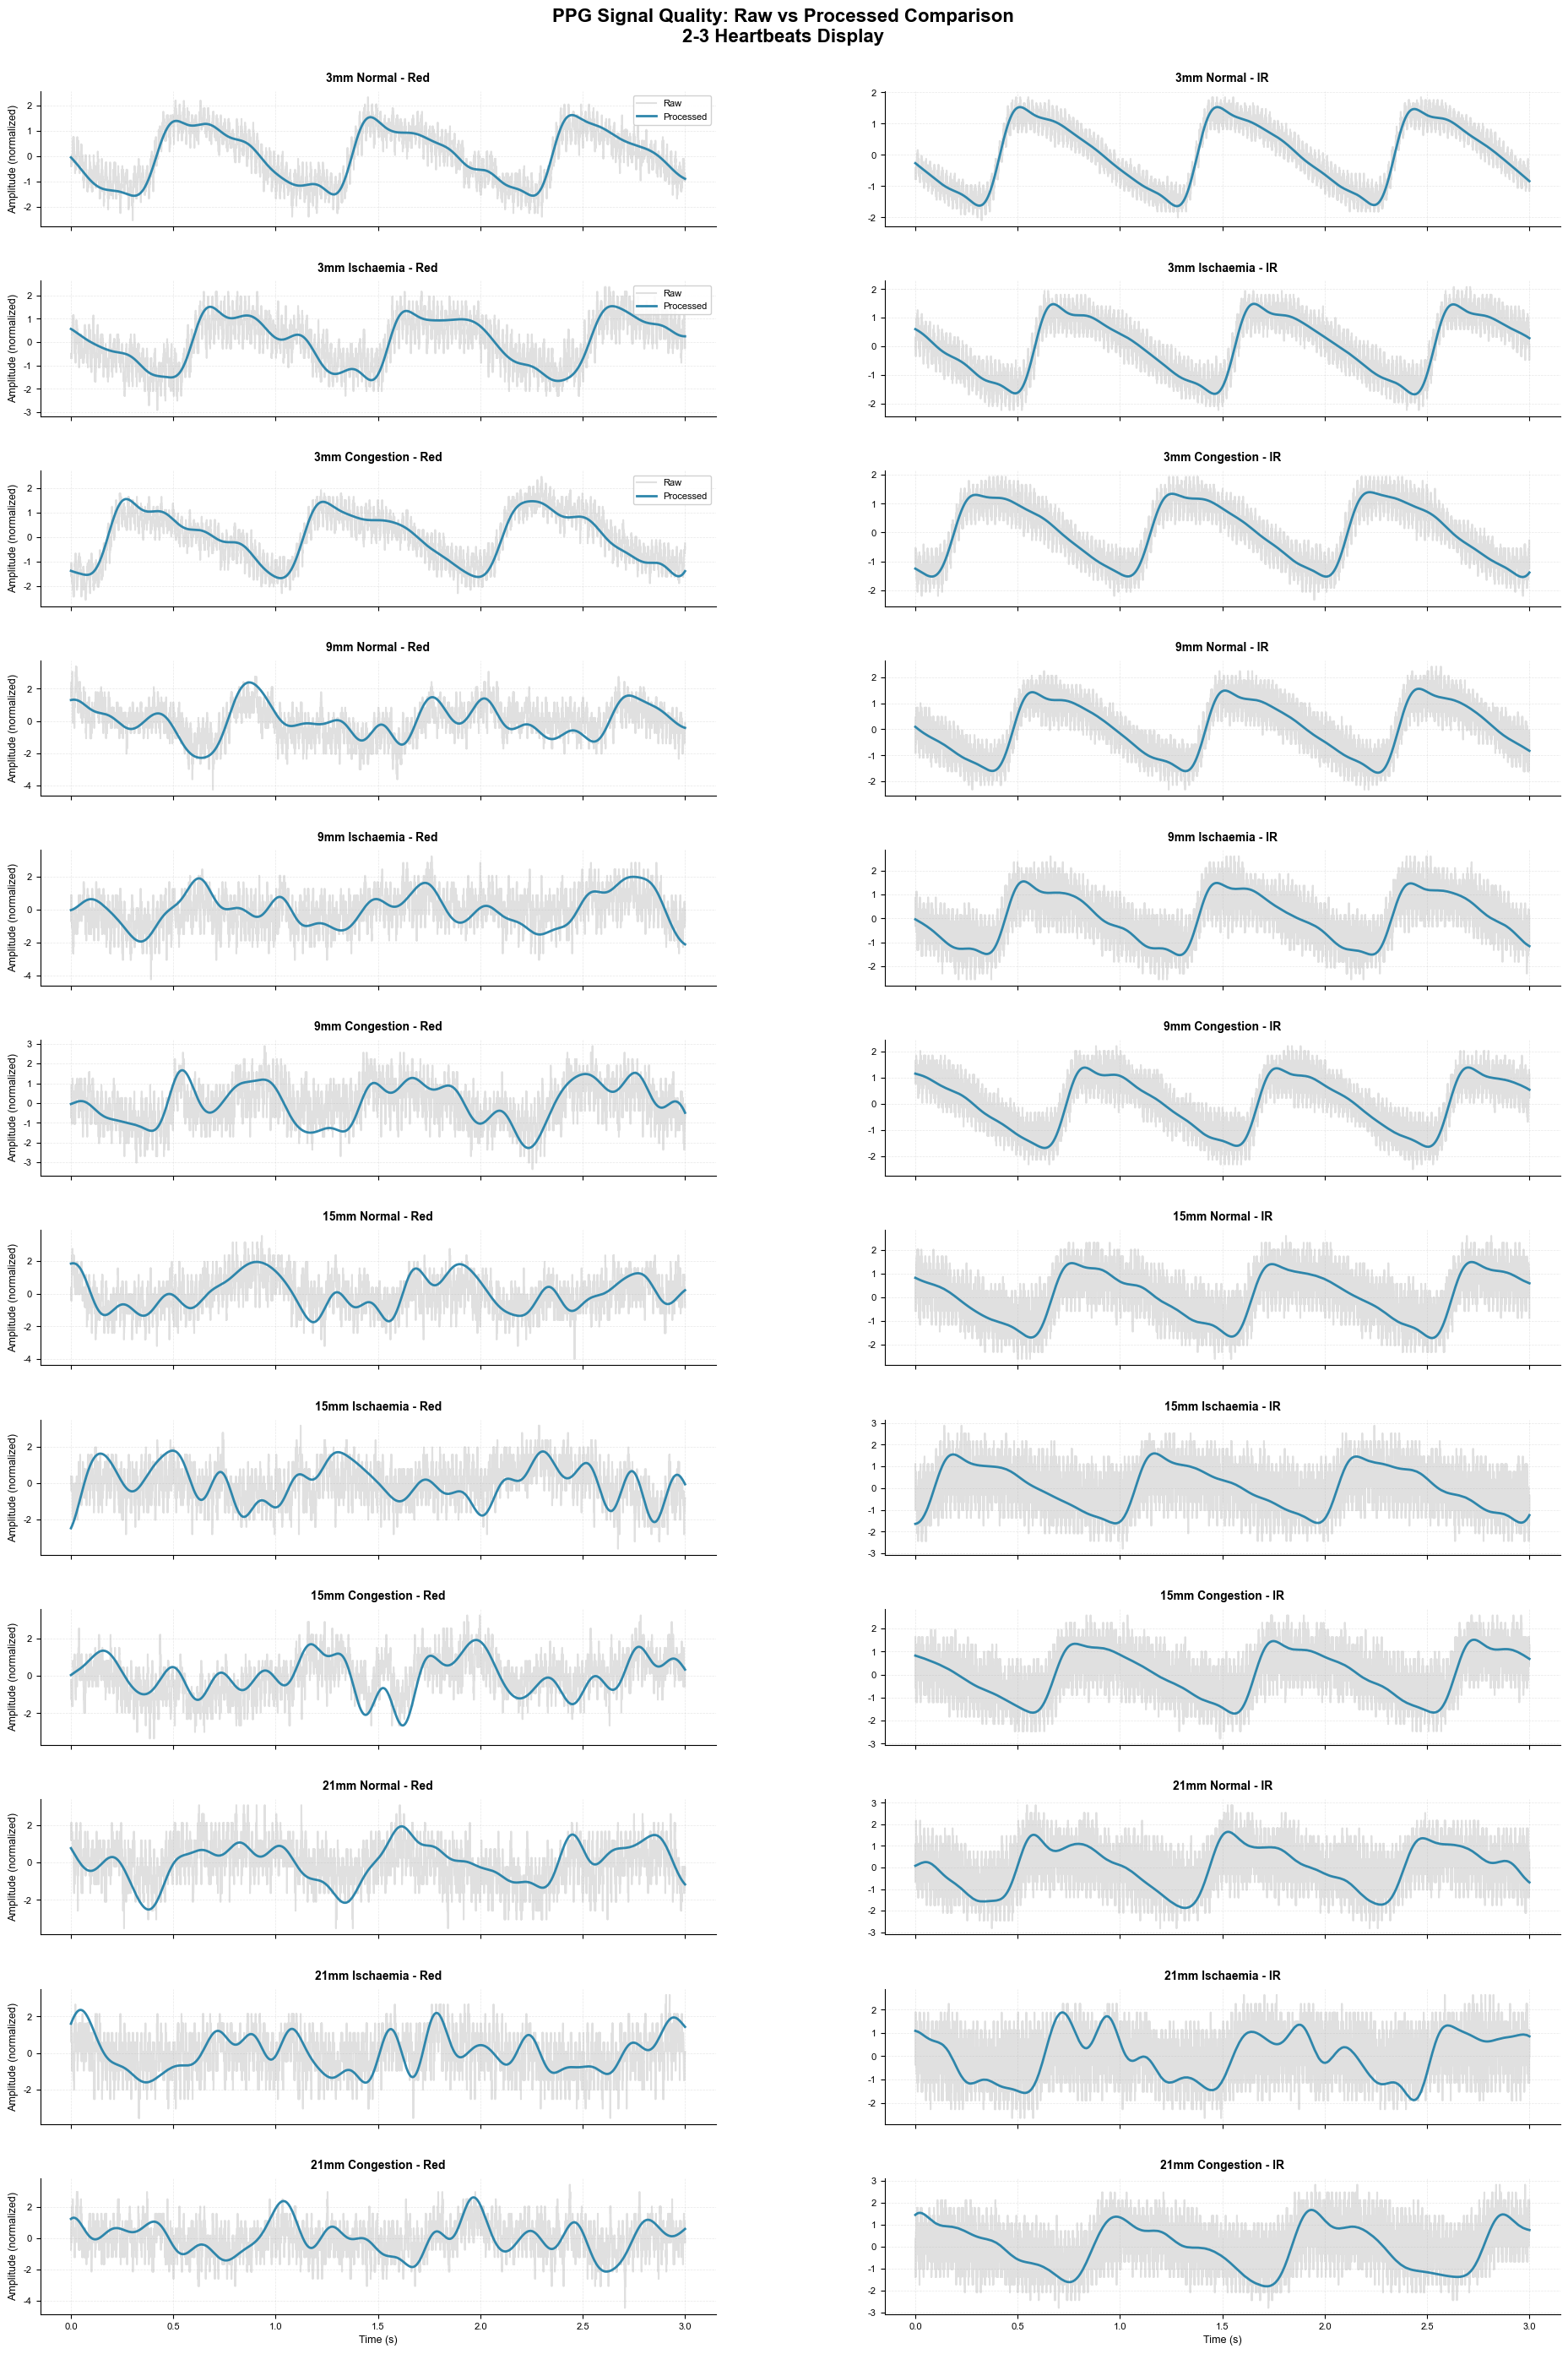


VISUALIZATION SUMMARY
Total plots created: 24

[2/3] Creating detailed annotated example...

Creating Detailed Annotated Example
✅ Detailed example saved: PPG_Detailed_Example_Annotated.png


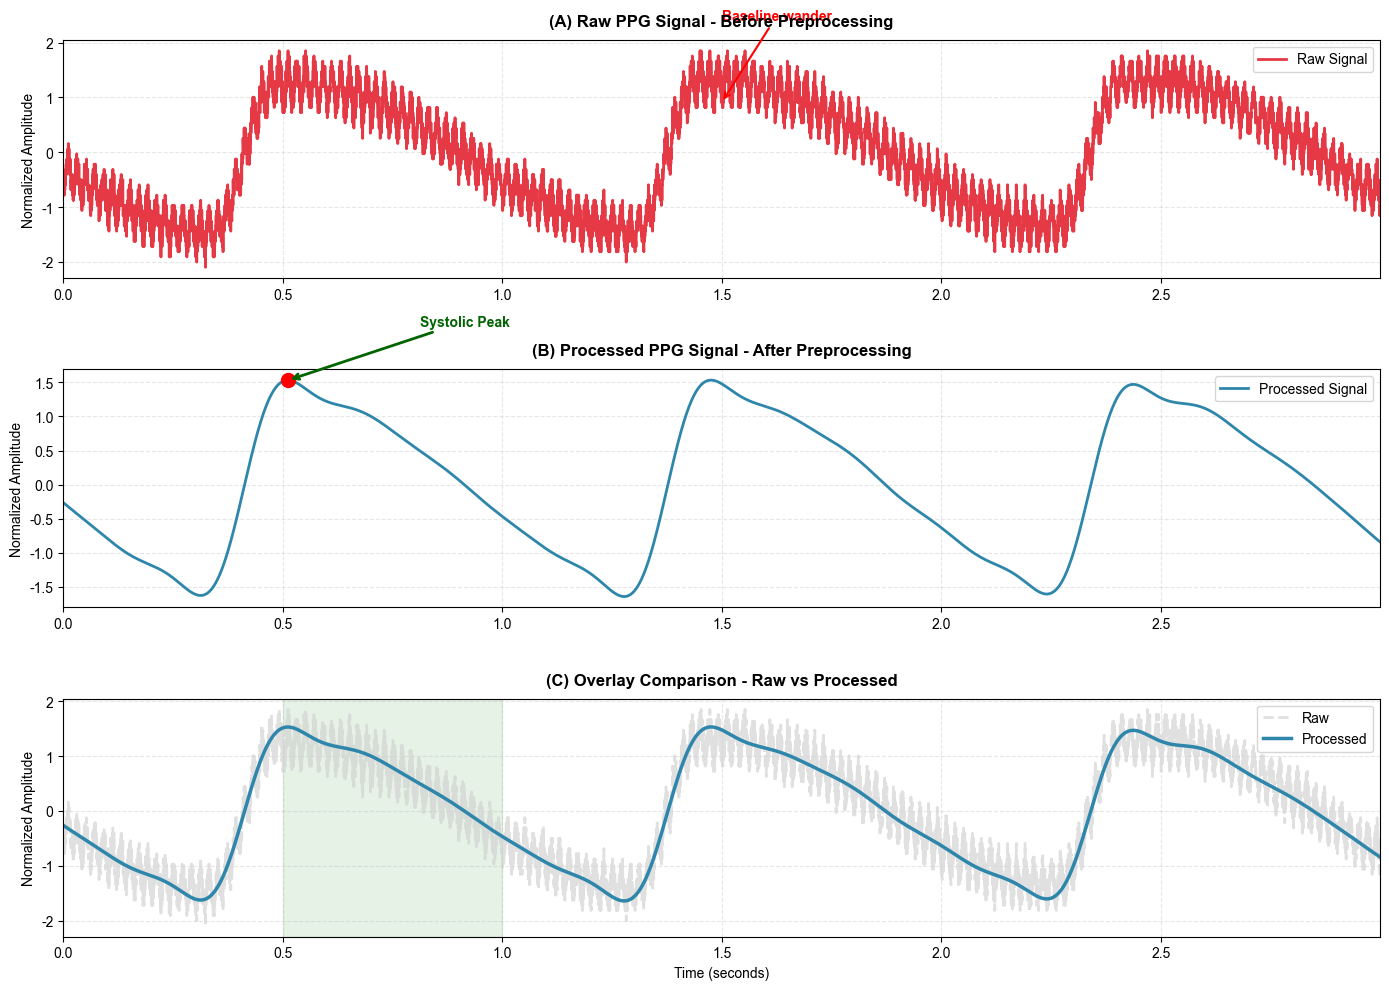


[3/3] Creating depth comparison...

Creating Depth Comparison (Normal State)
  ✓ Plotted: 3mm Red
  ✓ Plotted: 3mm IR
  ✓ Plotted: 9mm Red
  ✓ Plotted: 9mm IR
  ✓ Plotted: 15mm Red
  ✓ Plotted: 15mm IR
  ✓ Plotted: 21mm Red
  ✓ Plotted: 21mm IR
✅ Depth comparison saved: PPG_Depth_Comparison_Normal.png


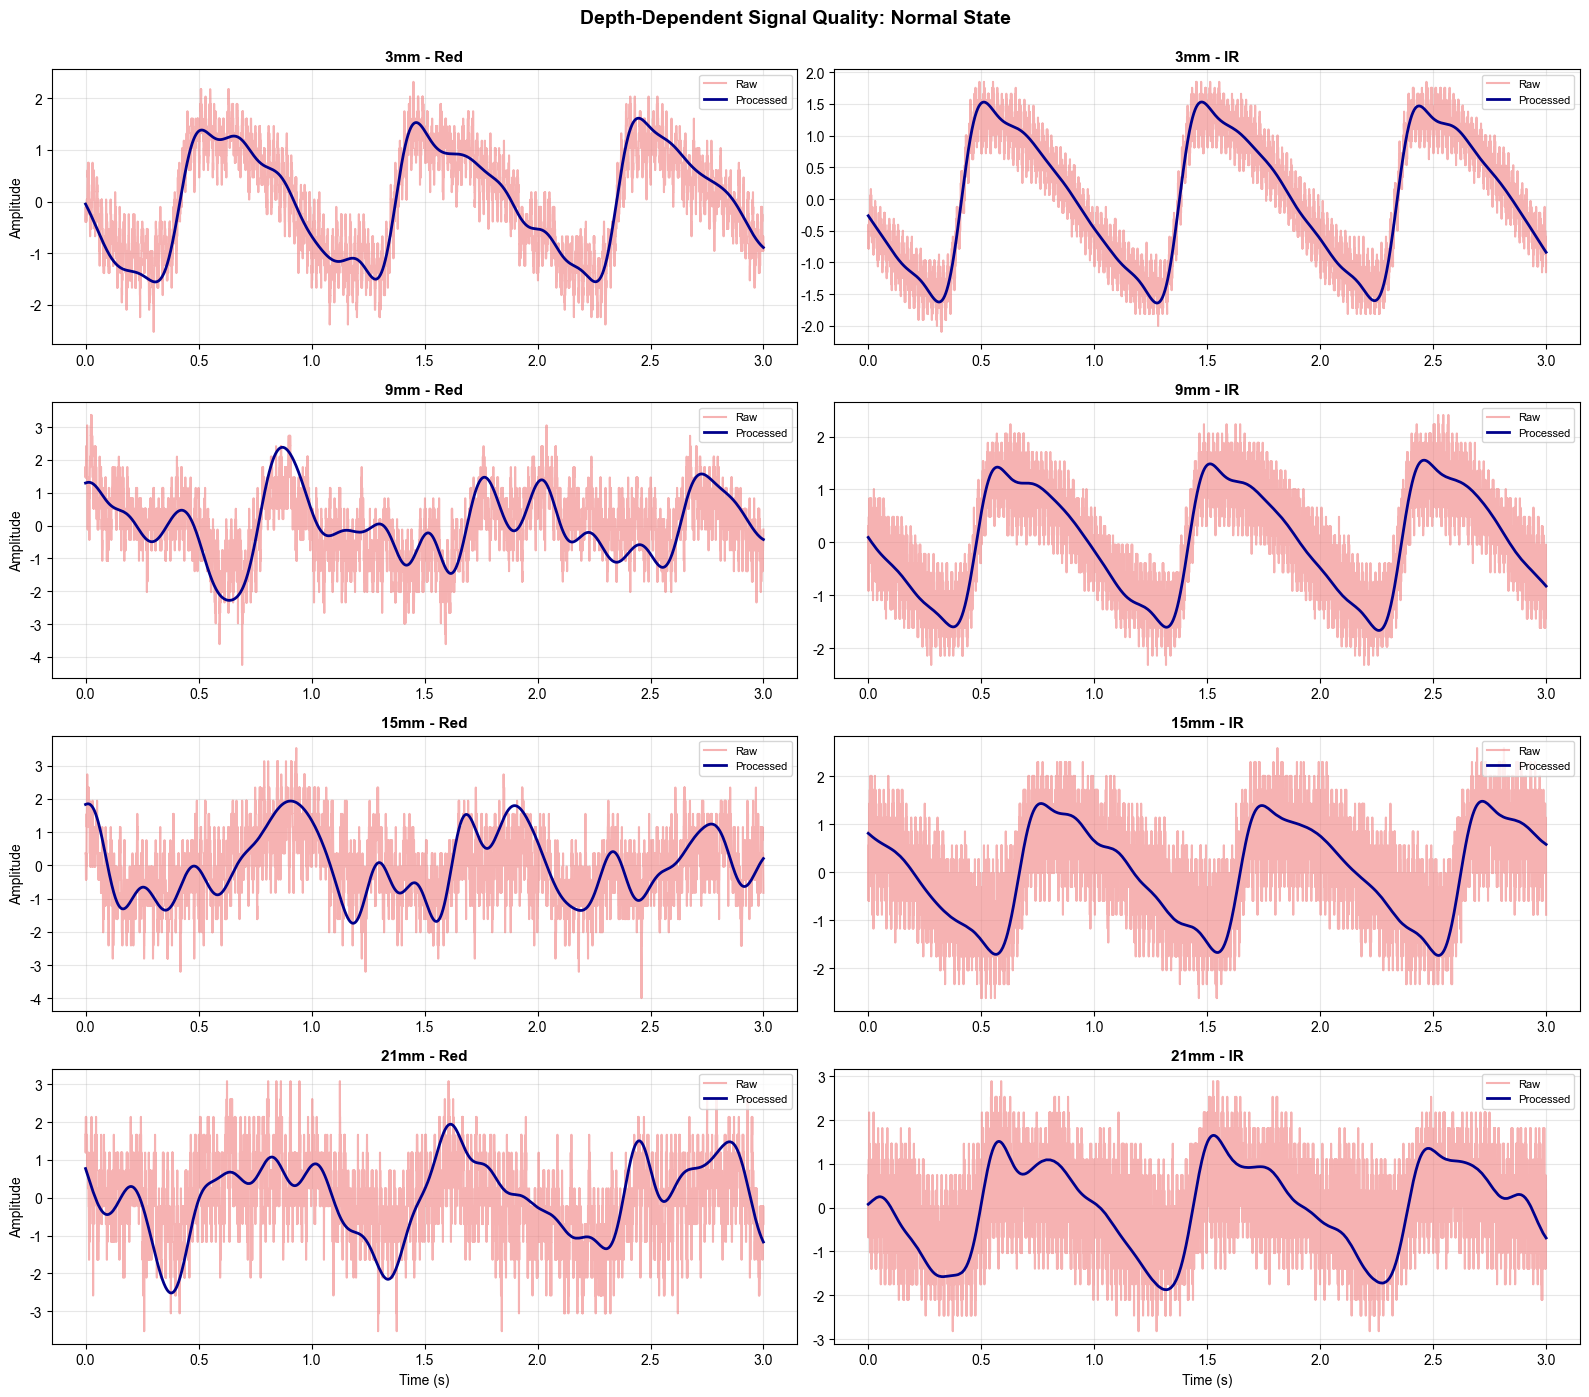


✅ ALL VISUALIZATIONS COMPLETED

Generated files:
  1. PPG_Raw_vs_Processed_Comparison.png - 全24測定の比較
  2. PPG_Detailed_Example_Annotated.png - 注釈付き詳細例
  3. PPG_Depth_Comparison_Normal.png - 深度別比較


In [40]:
"""
PPG信号の可視化：前処理前後の比較
2-3心拍分の波形を表示して前処理の効果を確認

【可視化する内容】
- Raw vs Processed の直接比較
- 各深度・状態・チャンネルごとの波形
- PPG波形の特徴（systolic peak, dicrotic notch）の保存確認
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import os
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定（環境に応じて調整）
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# パラメータ設定
FS = 2000  # サンプリングレート [Hz]
DISPLAY_DURATION = 3.0  # 表示時間 [秒]
START_TIME = 5.0  # 開始時刻 [秒] - 最初の部分は不安定な場合があるため

depths = [3, 9, 15, 21]
state_map = {1: "Normal", 2: "Ischaemia", 3: "Congestion"}
channels = {"Red": "ppgA_Red_raw", "IR": "ppgA_IR_raw"}


def plot_single_comparison(ax, time, raw_signal, processed_signal, title, 
                           show_xlabel=True, show_ylabel=True):
    """
    1つの測定条件でのRaw vs Processed比較プロット
    
    Parameters:
    -----------
    ax : matplotlib axis
        プロット対象の軸
    time : array
        時間軸 [秒]
    raw_signal : array
        生信号
    processed_signal : array
        前処理済み信号
    title : str
        プロットタイトル
    show_xlabel : bool
        X軸ラベルを表示するか
    show_ylabel : bool
        Y軸ラベルを表示するか
    """
    # Raw信号（薄い色、背景）
    ax.plot(time, raw_signal, color='lightgray', linewidth=1.5, 
            label='Raw', alpha=0.7, zorder=1)
    
    # Processed信号（濃い色、前面）
    ax.plot(time, processed_signal, color='#2E86AB', linewidth=2, 
            label='Processed', zorder=2)
    
    # タイトルとラベル
    ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
    
    if show_xlabel:
        ax.set_xlabel('Time (s)', fontsize=9)
    else:
        ax.set_xticklabels([])
    
    if show_ylabel:
        ax.set_ylabel('Amplitude (normalized)', fontsize=9)
    
    # グリッド
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # 凡例（最初の行のみ）
    if show_ylabel and title.startswith('3mm'):
        ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    
    # 軸の調整
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=8)


def create_comprehensive_visualization():
    """
    全測定条件の包括的可視化
    """
    print("="*80)
    print("PPG Signal Visualization: Raw vs Processed Comparison")
    print("="*80)
    
    # 図の作成（大きなサイズ）
    fig = plt.figure(figsize=(20, 28))
    
    # GridSpecで詳細なレイアウト制御
    gs = gridspec.GridSpec(12, 2, figure=fig, hspace=0.4, wspace=0.25,
                          left=0.06, right=0.96, top=0.96, bottom=0.02)
    
    plot_idx = 0
    missing_files = []
    
    for depth in depths:
        for i_state, state_name in state_map.items():
            # ファイル読み込み
            filename = f"{depth}mm_processed_data{i_state}.csv"
            
            if not os.path.exists(filename):
                print(f"⚠️  File not found: {filename}")
                missing_files.append(filename)
                plot_idx += 1
                continue
            
            try:
                df = pd.read_csv(filename)
                print(f"📂 Loading: {filename}")
                
                # 表示範囲の計算
                start_sample = int(START_TIME * FS)
                duration_samples = int(DISPLAY_DURATION * FS)
                end_sample = start_sample + duration_samples
                
                # 時間軸
                time = np.arange(duration_samples) / FS
                
                # 各チャンネルをプロット
                for ch_idx, (channel_name, raw_col_name) in enumerate(channels.items()):
                    processed_col_name = f"{channel_name}_processed"
                    
                    if raw_col_name not in df.columns or processed_col_name not in df.columns:
                        print(f"  ⚠️  Missing columns for {channel_name}")
                        continue
                    
                    # データ抽出
                    raw_signal = df[raw_col_name].values[start_sample:end_sample]
                    processed_signal = df[processed_col_name].values[start_sample:end_sample]
                    
                    # 正規化（表示用）
                    raw_signal = (raw_signal - np.mean(raw_signal)) / (np.std(raw_signal) + 1e-10)
                    processed_signal = (processed_signal - np.mean(processed_signal)) / (np.std(processed_signal) + 1e-10)
                    
                    # サブプロット位置
                    row = plot_idx
                    col = ch_idx
                    ax = fig.add_subplot(gs[row, col])
                    
                    # タイトル作成
                    title = f"{depth}mm {state_name} - {channel_name}"
                    
                    # X軸ラベルは最下行のみ
                    show_xlabel = (plot_idx == 11)
                    # Y軸ラベルは左列のみ
                    show_ylabel = (ch_idx == 0)
                    
                    # プロット
                    plot_single_comparison(ax, time, raw_signal, processed_signal, 
                                         title, show_xlabel, show_ylabel)
                    
                    print(f"  ✓ Plotted: {channel_name}")
                
                plot_idx += 1
                
            except Exception as e:
                print(f"  ✗ Error processing {filename}: {str(e)}")
                plot_idx += 1
                continue
    
    # 全体タイトル
    fig.suptitle('PPG Signal Quality: Raw vs Processed Comparison\n2-3 Heartbeats Display', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # 保存
    output_filename = "PPG_Raw_vs_Processed_Comparison.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"\n✅ Figure saved: {output_filename}")
    
    plt.show()
    
    # サマリー
    print("\n" + "="*80)
    print("VISUALIZATION SUMMARY")
    print("="*80)
    print(f"Total plots created: {plot_idx * 2}")
    if missing_files:
        print(f"Missing files: {len(missing_files)}")
        for f in missing_files:
            print(f"  - {f}")
    print("="*80)


def create_detailed_single_example():
    """
    1つの代表例を詳細に可視化（注釈付き）
    """
    print("\n" + "="*80)
    print("Creating Detailed Annotated Example")
    print("="*80)
    
    # 代表例: 3mm Normal - IR（最高品質）
    filename = "3mm_processed_data1.csv"
    
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        return
    
    df = pd.read_csv(filename)
    
    # データ抽出
    start_sample = int(START_TIME * FS)
    duration_samples = int(DISPLAY_DURATION * FS)
    end_sample = start_sample + duration_samples
    
    time = np.arange(duration_samples) / FS
    
    raw_signal = df["ppgA_IR_raw"].values[start_sample:end_sample]
    processed_signal = df["IR_processed"].values[start_sample:end_sample]
    
    # 正規化
    raw_signal_norm = (raw_signal - np.mean(raw_signal)) / np.std(raw_signal)
    processed_signal_norm = (processed_signal - np.mean(processed_signal)) / np.std(processed_signal)
    
    # 図の作成
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    # 1. Raw信号
    ax1 = axes[0]
    ax1.plot(time, raw_signal_norm, color='#E63946', linewidth=2, label='Raw Signal')
    ax1.set_title('(A) Raw PPG Signal - Before Preprocessing', 
                  fontsize=12, fontweight='bold', pad=10)
    ax1.set_ylabel('Normalized Amplitude', fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(loc='upper right', fontsize=10)
    ax1.set_xlim([time[0], time[-1]])
    
    # ベースラインドリフトの注釈
    ax1.annotate('Baseline wander', xy=(1.5, raw_signal_norm[3000]), 
                xytext=(1.5, raw_signal_norm[3000] + 1.5),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                fontsize=10, color='red', fontweight='bold')
    
    # 2. Processed信号
    ax2 = axes[1]
    ax2.plot(time, processed_signal_norm, color='#2E86AB', linewidth=2, label='Processed Signal')
    ax2.set_title('(B) Processed PPG Signal - After Preprocessing', 
                  fontsize=12, fontweight='bold', pad=10)
    ax2.set_ylabel('Normalized Amplitude', fontsize=10)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.legend(loc='upper right', fontsize=10)
    ax2.set_xlim([time[0], time[-1]])
    
    # PPG波形の特徴を注釈
    # ピーク検出（簡易版）
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(processed_signal_norm, distance=int(0.6*FS), prominence=0.5)
    
    if len(peaks) > 0:
        # 最初のピークに注釈
        peak_idx = peaks[0]
        ax2.plot(time[peak_idx], processed_signal_norm[peak_idx], 'ro', markersize=10)
        ax2.annotate('Systolic Peak', xy=(time[peak_idx], processed_signal_norm[peak_idx]), 
                    xytext=(time[peak_idx] + 0.3, processed_signal_norm[peak_idx] + 0.8),
                    arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2),
                    fontsize=10, color='darkgreen', fontweight='bold')
    
    # 3. オーバーレイ比較
    ax3 = axes[2]
    ax3.plot(time, raw_signal_norm, color='lightgray', linewidth=2, 
            label='Raw', alpha=0.7, linestyle='--')
    ax3.plot(time, processed_signal_norm, color='#2E86AB', linewidth=2.5, 
            label='Processed')
    ax3.set_title('(C) Overlay Comparison - Raw vs Processed', 
                  fontsize=12, fontweight='bold', pad=10)
    ax3.set_xlabel('Time (seconds)', fontsize=10)
    ax3.set_ylabel('Normalized Amplitude', fontsize=10)
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.legend(loc='upper right', fontsize=10)
    ax3.set_xlim([time[0], time[-1]])
    
    # 改善領域のハイライト
    ax3.axvspan(0.5, 1.0, alpha=0.1, color='green', label='Noise Reduction')
    
    plt.tight_layout()
    
    # 保存
    output_filename = "PPG_Detailed_Example_Annotated.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✅ Detailed example saved: {output_filename}")
    
    plt.show()


def create_depth_comparison():
    """
    深度別の比較（1つの状態に注目）
    """
    print("\n" + "="*80)
    print("Creating Depth Comparison (Normal State)")
    print("="*80)
    
    fig, axes = plt.subplots(4, 2, figsize=(16, 14))
    
    for depth_idx, depth in enumerate(depths):
        filename = f"{depth}mm_processed_data1.csv"  # Normal state
        
        if not os.path.exists(filename):
            print(f"File not found: {filename}")
            continue
        
        df = pd.read_csv(filename)
        
        # データ抽出
        start_sample = int(START_TIME * FS)
        duration_samples = int(DISPLAY_DURATION * FS)
        end_sample = start_sample + duration_samples
        time = np.arange(duration_samples) / FS
        
        for ch_idx, (channel_name, raw_col_name) in enumerate(channels.items()):
            processed_col_name = f"{channel_name}_processed"
            
            raw_signal = df[raw_col_name].values[start_sample:end_sample]
            processed_signal = df[processed_col_name].values[start_sample:end_sample]
            
            # 正規化
            raw_signal = (raw_signal - np.mean(raw_signal)) / (np.std(raw_signal) + 1e-10)
            processed_signal = (processed_signal - np.mean(processed_signal)) / (np.std(processed_signal) + 1e-10)
            
            ax = axes[depth_idx, ch_idx]
            
            ax.plot(time, raw_signal, color='lightcoral', linewidth=1.5, 
                   label='Raw', alpha=0.6)
            ax.plot(time, processed_signal, color='darkblue', linewidth=2, 
                   label='Processed')
            
            ax.set_title(f"{depth}mm - {channel_name}", fontsize=11, fontweight='bold')
            
            if depth_idx == 3:
                ax.set_xlabel('Time (s)', fontsize=10)
            if ch_idx == 0:
                ax.set_ylabel('Amplitude', fontsize=10)
            
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper right', fontsize=8)
            
            print(f"  ✓ Plotted: {depth}mm {channel_name}")
    
    fig.suptitle('Depth-Dependent Signal Quality: Normal State', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    output_filename = "PPG_Depth_Comparison_Normal.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✅ Depth comparison saved: {output_filename}")
    
    plt.show()


# ========= メイン実行 =========
if __name__ == "__main__":
    print("\n" + "🎨 " * 30)
    print("PPG SIGNAL VISUALIZATION SUITE")
    print("🎨 " * 30 + "\n")
    
    # 1. 包括的可視化（全24測定）
    print("\n[1/3] Creating comprehensive visualization...")
    create_comprehensive_visualization()
    
    # 2. 詳細な注釈付き例
    print("\n[2/3] Creating detailed annotated example...")
    create_detailed_single_example()
    
    # 3. 深度別比較
    print("\n[3/3] Creating depth comparison...")
    create_depth_comparison()
    
    print("\n" + "="*80)
    print("✅ ALL VISUALIZATIONS COMPLETED")
    print("="*80)
    print("\nGenerated files:")
    print("  1. PPG_Raw_vs_Processed_Comparison.png - 全24測定の比較")
    print("  2. PPG_Detailed_Example_Annotated.png - 注釈付き詳細例")
    print("  3. PPG_Depth_Comparison_Normal.png - 深度別比較")
    print("="*80)



🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 
PPG SIGNAL VISUALIZATION SUITE
🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 


[1/3] Creating comprehensive visualization...
PPG Signal Visualization: Raw vs Processed Comparison
📂 Loading: 3mm_processed_data1.csv
  ✓ Plotted: Red
  ✓ Plotted: IR
📂 Loading: 3mm_processed_data2.csv
  ✓ Plotted: Red
  ✓ Plotted: IR
📂 Loading: 3mm_processed_data3.csv
  ✓ Plotted: Red
  ✓ Plotted: IR

✅ Figure saved: PPG_Raw_vs_Processed_Comparison.png


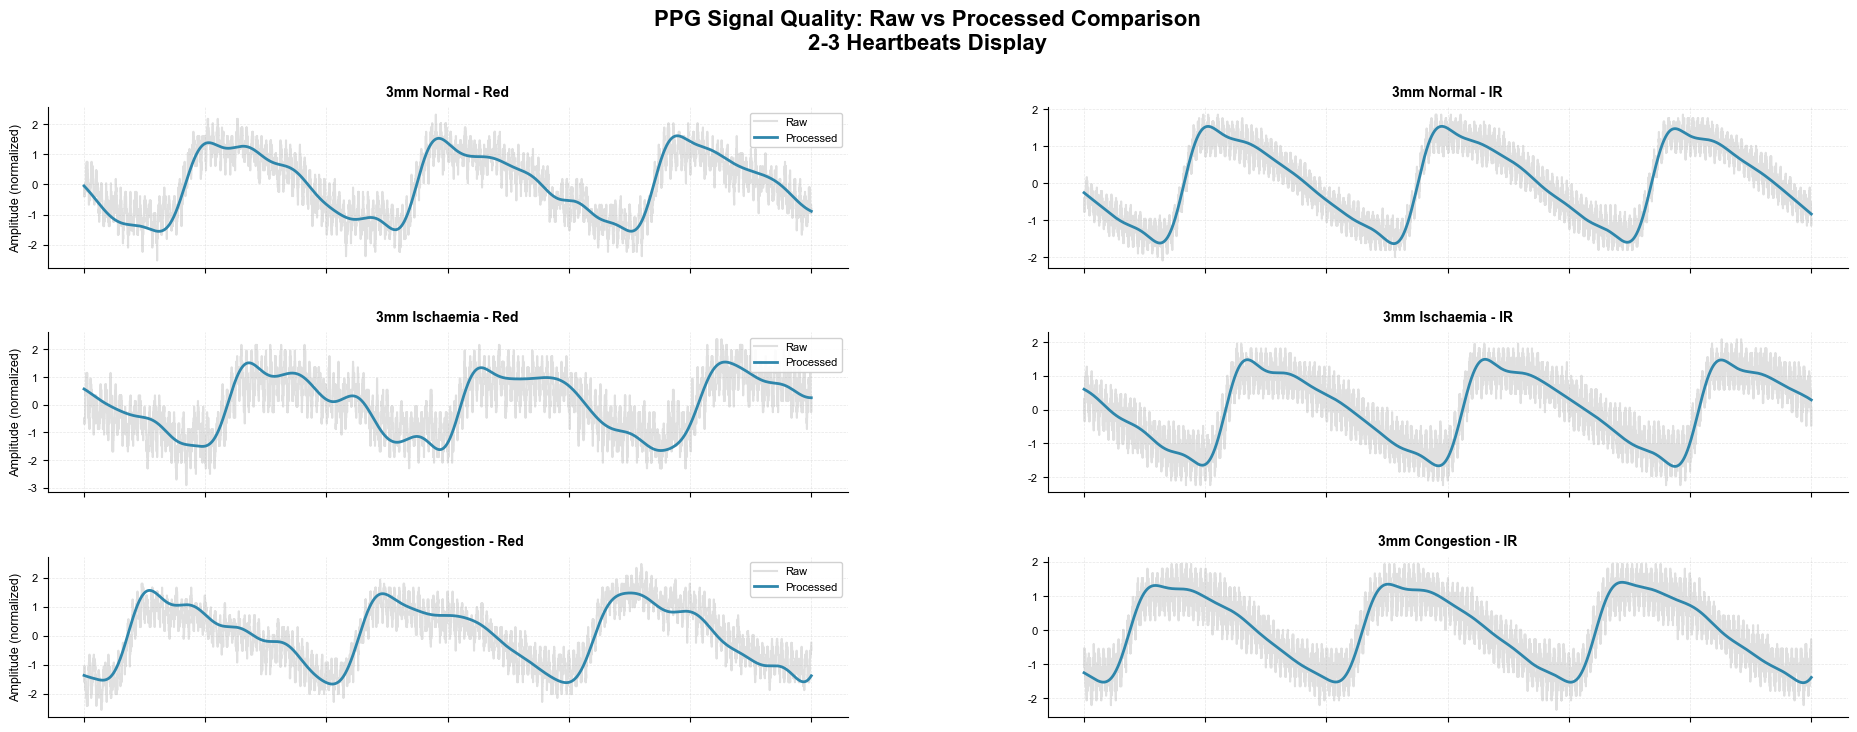


VISUALIZATION SUMMARY
Total plots created: 6

[2/3] Creating detailed annotated example...

Creating Detailed Annotated Example
✅ Detailed example saved: PPG_Detailed_Example_Annotated.png


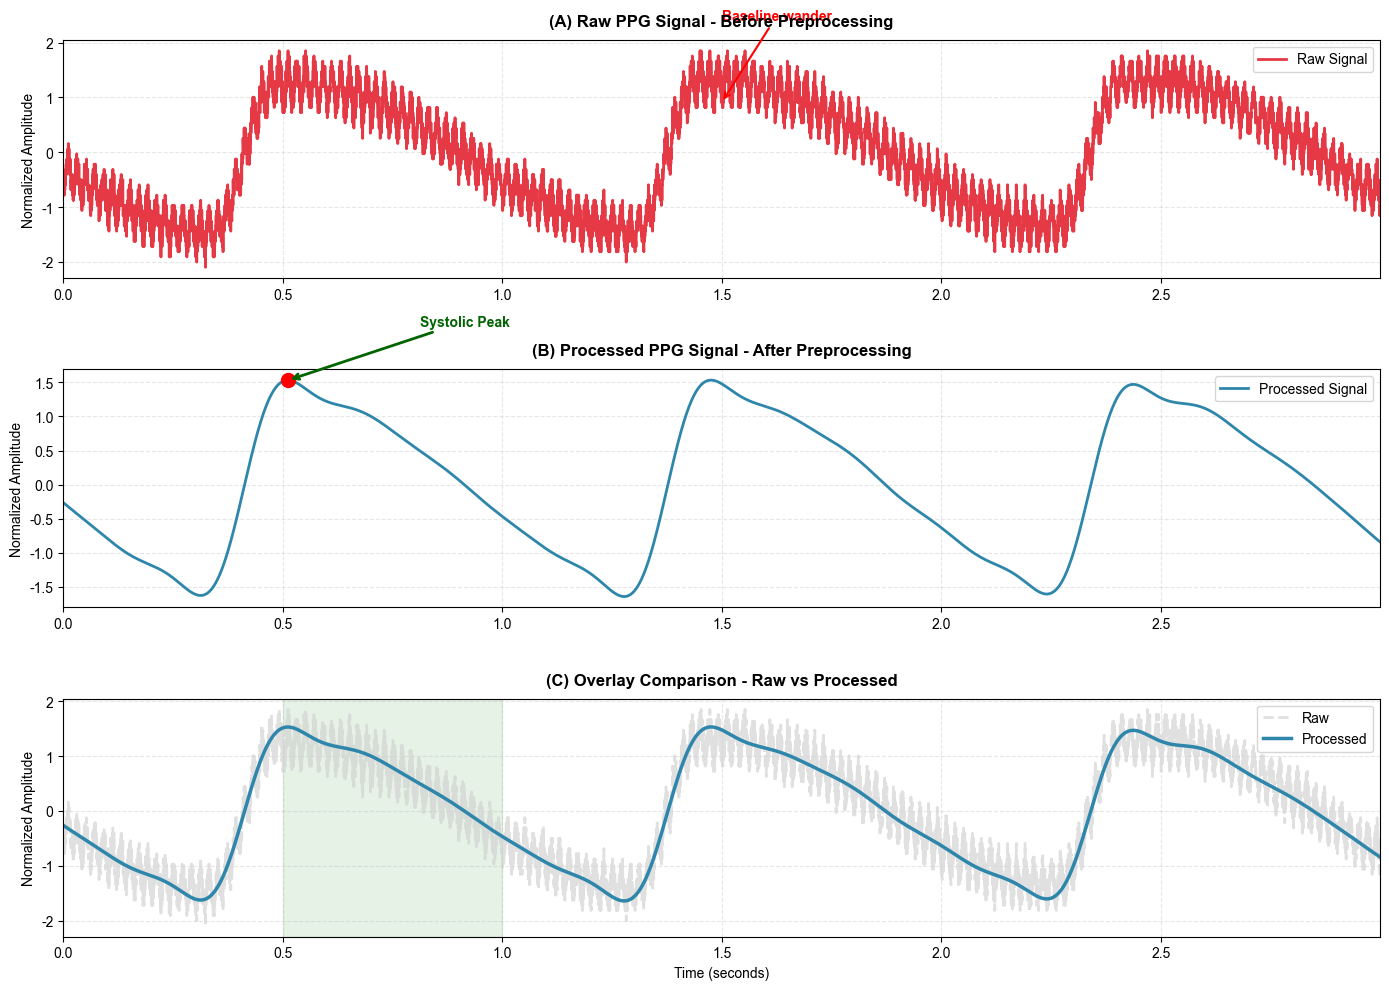


[3/3] Creating depth comparison...

Creating Depth Comparison (Normal State)
  ✓ Plotted: 3mm Red
  ✓ Plotted: 3mm IR
✅ Depth comparison saved: PPG_Depth_Comparison_Normal.png


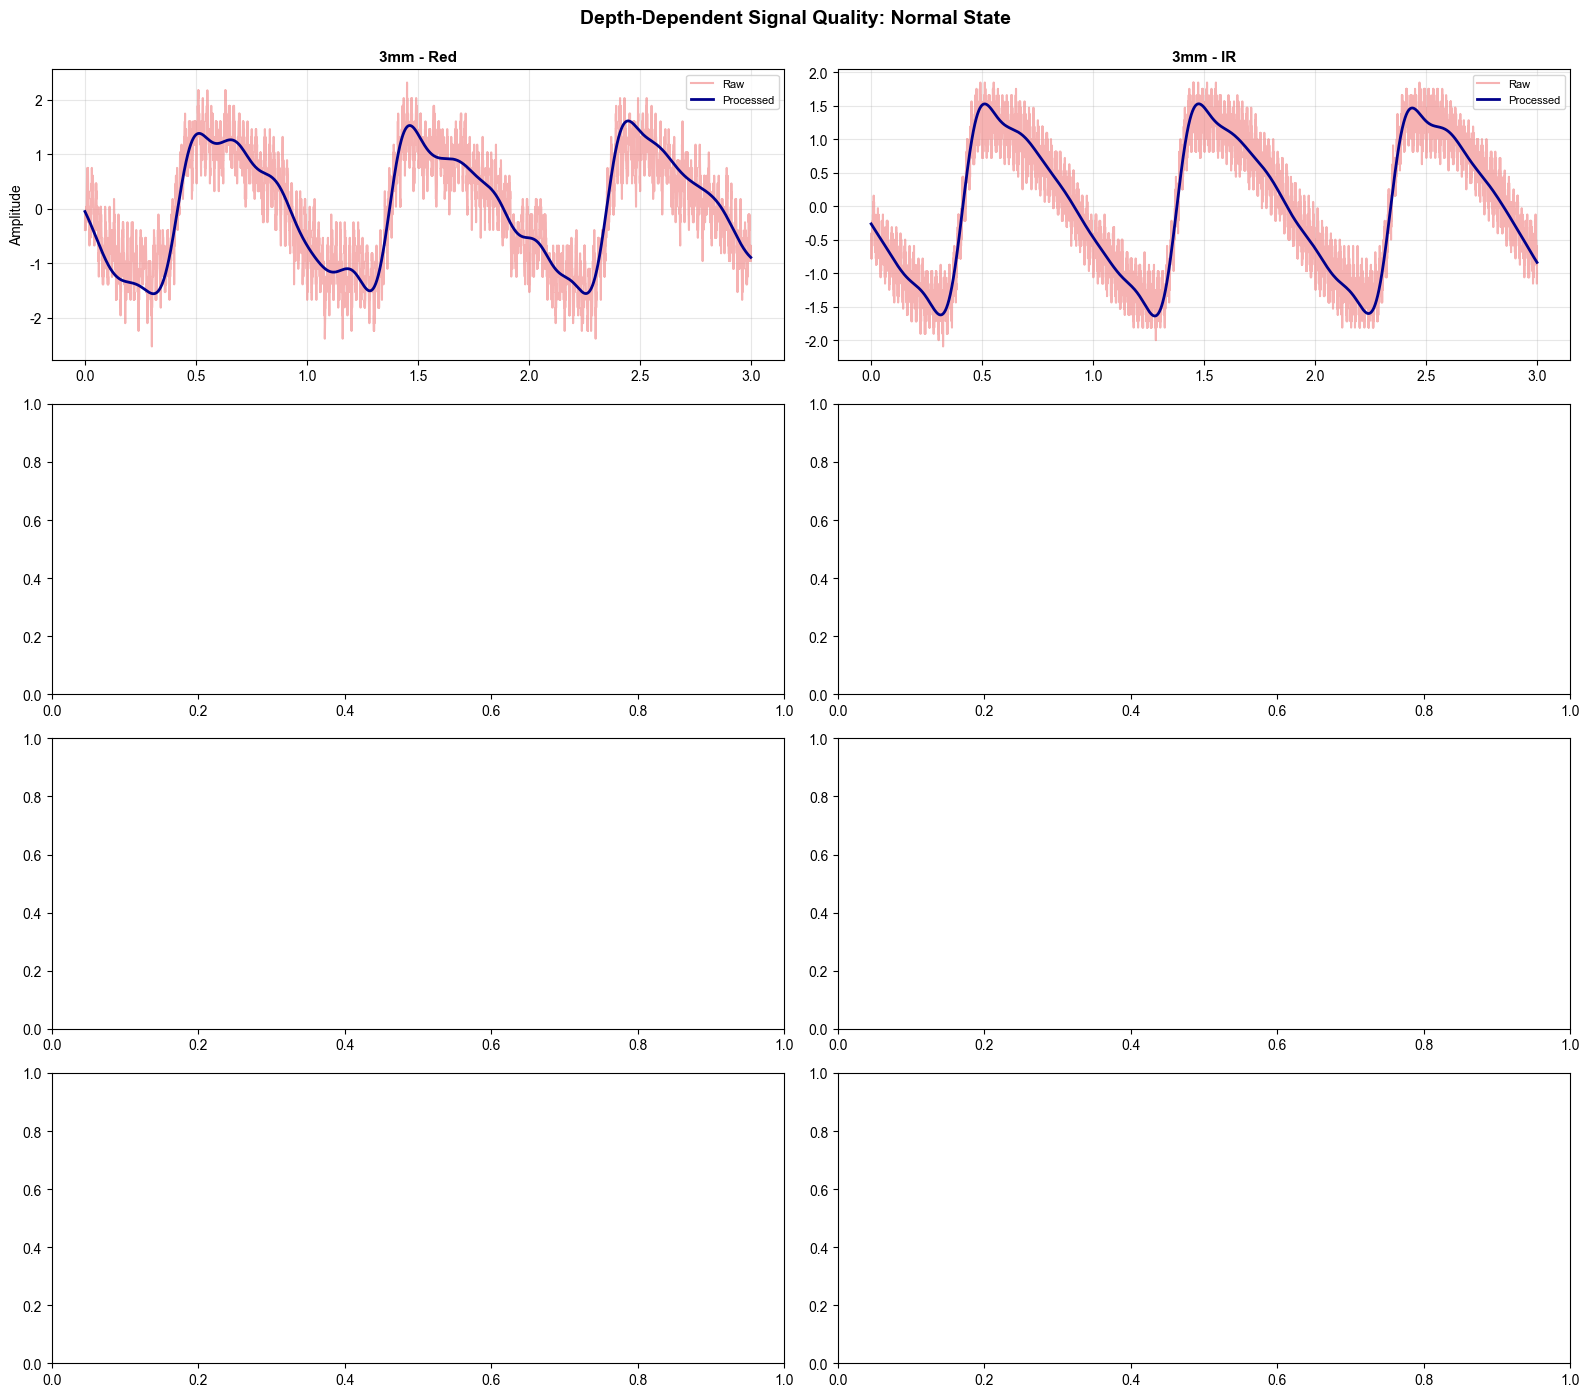


✅ ALL VISUALIZATIONS COMPLETED

Generated files:
  1. PPG_Raw_vs_Processed_Comparison.png - 全24測定の比較
  2. PPG_Detailed_Example_Annotated.png - 注釈付き詳細例
  3. PPG_Depth_Comparison_Normal.png - 深度別比較


In [ ]:
#採用
"""
PPG信号の可視化：前処理前後の比較
2-3心拍分の波形を表示して前処理の効果を確認

【可視化する内容】
- Raw vs Processed の直接比較
- 各深度・状態・チャンネルごとの波形
- PPG波形の特徴（systolic peak, dicrotic notch）の保存確認
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import os
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定（環境に応じて調整）
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# パラメータ設定
FS = 2000  # サンプリングレート [Hz]
DISPLAY_DURATION = 3.0  # 表示時間 [秒]
START_TIME = 5.0  # 開始時刻 [秒] - 最初の部分は不安定な場合があるため

depths = [3]
state_map = {1: "Normal", 2: "Ischaemia", 3: "Congestion"}
channels = {"Red": "ppgA_Red_raw", "IR": "ppgA_IR_raw"}


def plot_single_comparison(ax, time, raw_signal, processed_signal, title, 
                           show_xlabel=True, show_ylabel=True):
    """
    1つの測定条件でのRaw vs Processed比較プロット
    
    Parameters:
    -----------
    ax : matplotlib axis
        プロット対象の軸
    time : array
        時間軸 [秒]
    raw_signal : array
        生信号
    processed_signal : array
        前処理済み信号
    title : str
        プロットタイトル
    show_xlabel : bool
        X軸ラベルを表示するか
    show_ylabel : bool
        Y軸ラベルを表示するか
    """
    # Raw信号（薄い色、背景）
    ax.plot(time, raw_signal, color='lightgray', linewidth=1.5, 
            label='Raw', alpha=0.7, zorder=1)
    
    # Processed信号（濃い色、前面）
    ax.plot(time, processed_signal, color='#2E86AB', linewidth=2, 
            label='Processed', zorder=2)
    
    # タイトルとラベル
    ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
    
    if show_xlabel:
        ax.set_xlabel('Time (s)', fontsize=9)
    else:
        ax.set_xticklabels([])
    
    if show_ylabel:
        ax.set_ylabel('Amplitude (normalized)', fontsize=9)
    
    # グリッド
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # 凡例（最初の行のみ）
    if show_ylabel and title.startswith('3mm'):
        ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    
    # 軸の調整
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=8)


def create_comprehensive_visualization():
    """
    全測定条件の包括的可視化
    """
    print("="*80)
    print("PPG Signal Visualization: Raw vs Processed Comparison")
    print("="*80)
    
    # 図の作成（大きなサイズ）
    fig = plt.figure(figsize=(20, 28))
    
    # GridSpecで詳細なレイアウト制御
    gs = gridspec.GridSpec(12, 2, figure=fig, hspace=0.4, wspace=0.25,
                          left=0.06, right=0.96, top=0.96, bottom=0.02)
    
    plot_idx = 0
    missing_files = []
    
    for depth in depths:
        for i_state, state_name in state_map.items():
            # ファイル読み込み
            filename = f"{depth}mm_processed_data{i_state}.csv"
            
            if not os.path.exists(filename):
                print(f"⚠️  File not found: {filename}")
                missing_files.append(filename)
                plot_idx += 1
                continue
            
            try:
                df = pd.read_csv(filename)
                print(f"📂 Loading: {filename}")
                
                # 表示範囲の計算
                start_sample = int(START_TIME * FS)
                duration_samples = int(DISPLAY_DURATION * FS)
                end_sample = start_sample + duration_samples
                
                # 時間軸
                time = np.arange(duration_samples) / FS
                
                # 各チャンネルをプロット
                for ch_idx, (channel_name, raw_col_name) in enumerate(channels.items()):
                    processed_col_name = f"{channel_name}_processed"
                    
                    if raw_col_name not in df.columns or processed_col_name not in df.columns:
                        print(f"  ⚠️  Missing columns for {channel_name}")
                        continue
                    
                    # データ抽出
                    raw_signal = df[raw_col_name].values[start_sample:end_sample]
                    processed_signal = df[processed_col_name].values[start_sample:end_sample]
                    
                    # 正規化（表示用）
                    raw_signal = (raw_signal - np.mean(raw_signal)) / (np.std(raw_signal) + 1e-10)
                    processed_signal = (processed_signal - np.mean(processed_signal)) / (np.std(processed_signal) + 1e-10)
                    
                    # サブプロット位置
                    row = plot_idx
                    col = ch_idx
                    ax = fig.add_subplot(gs[row, col])
                    
                    # タイトル作成
                    title = f"{depth}mm {state_name} - {channel_name}"
                    
                    # X軸ラベルは最下行のみ
                    show_xlabel = (plot_idx == 11)
                    # Y軸ラベルは左列のみ
                    show_ylabel = (ch_idx == 0)
                    
                    # プロット
                    plot_single_comparison(ax, time, raw_signal, processed_signal, 
                                         title, show_xlabel, show_ylabel)
                    
                    print(f"  ✓ Plotted: {channel_name}")
                
                plot_idx += 1
                
            except Exception as e:
                print(f"  ✗ Error processing {filename}: {str(e)}")
                plot_idx += 1
                continue
    
    # 全体タイトル
    fig.suptitle('PPG Signal Quality: Raw vs Processed Comparison\n2-3 Heartbeats Display', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # 保存
    output_filename = "PPG_Raw_vs_Processed_Comparison.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"\n✅ Figure saved: {output_filename}")
    
    plt.show()
    
    # サマリー
    print("\n" + "="*80)
    print("VISUALIZATION SUMMARY")
    print("="*80)
    print(f"Total plots created: {plot_idx * 2}")
    if missing_files:
        print(f"Missing files: {len(missing_files)}")
        for f in missing_files:
            print(f"  - {f}")
    print("="*80)


def create_detailed_single_example():
    """
    1つの代表例を詳細に可視化（注釈付き）
    """
    print("\n" + "="*80)
    print("Creating Detailed Annotated Example")
    print("="*80)
    
    # 代表例: 3mm Normal - IR（最高品質）
    filename = "3mm_processed_data1.csv"
    
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        return
    
    df = pd.read_csv(filename)
    
    # データ抽出
    start_sample = int(START_TIME * FS)
    duration_samples = int(DISPLAY_DURATION * FS)
    end_sample = start_sample + duration_samples
    
    time = np.arange(duration_samples) / FS
    
    raw_signal = df["ppgA_IR_raw"].values[start_sample:end_sample]
    processed_signal = df["IR_processed"].values[start_sample:end_sample]
    
    # 正規化
    raw_signal_norm = (raw_signal - np.mean(raw_signal)) / np.std(raw_signal)
    processed_signal_norm = (processed_signal - np.mean(processed_signal)) / np.std(processed_signal)
    
    # 図の作成
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    # 1. Raw信号
    ax1 = axes[0]
    ax1.plot(time, raw_signal_norm, color='#E63946', linewidth=2, label='Raw Signal')
    ax1.set_title('(A) Raw PPG Signal - Before Preprocessing', 
                  fontsize=12, fontweight='bold', pad=10)
    ax1.set_ylabel('Normalized Amplitude', fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(loc='upper right', fontsize=10)
    ax1.set_xlim([time[0], time[-1]])
    
    # ベースラインドリフトの注釈
    ax1.annotate('Baseline wander', xy=(1.5, raw_signal_norm[3000]), 
                xytext=(1.5, raw_signal_norm[3000] + 1.5),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                fontsize=10, color='red', fontweight='bold')
    
    # 2. Processed信号
    ax2 = axes[1]
    ax2.plot(time, processed_signal_norm, color='#2E86AB', linewidth=2, label='Processed Signal')
    ax2.set_title('(B) Processed PPG Signal - After Preprocessing', 
                  fontsize=12, fontweight='bold', pad=10)
    ax2.set_ylabel('Normalized Amplitude', fontsize=10)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.legend(loc='upper right', fontsize=10)
    ax2.set_xlim([time[0], time[-1]])
    
    # PPG波形の特徴を注釈
    # ピーク検出（簡易版）
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(processed_signal_norm, distance=int(0.6*FS), prominence=0.5)
    
    if len(peaks) > 0:
        # 最初のピークに注釈
        peak_idx = peaks[0]
        ax2.plot(time[peak_idx], processed_signal_norm[peak_idx], 'ro', markersize=10)
        ax2.annotate('Systolic Peak', xy=(time[peak_idx], processed_signal_norm[peak_idx]), 
                    xytext=(time[peak_idx] + 0.3, processed_signal_norm[peak_idx] + 0.8),
                    arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2),
                    fontsize=10, color='darkgreen', fontweight='bold')
    
    # 3. オーバーレイ比較
    ax3 = axes[2]
    ax3.plot(time, raw_signal_norm, color='lightgray', linewidth=2, 
            label='Raw', alpha=0.7, linestyle='--')
    ax3.plot(time, processed_signal_norm, color='#2E86AB', linewidth=2.5, 
            label='Processed')
    ax3.set_title('(C) Overlay Comparison - Raw vs Processed', 
                  fontsize=12, fontweight='bold', pad=10)
    ax3.set_xlabel('Time (seconds)', fontsize=10)
    ax3.set_ylabel('Normalized Amplitude', fontsize=10)
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.legend(loc='upper right', fontsize=10)
    ax3.set_xlim([time[0], time[-1]])
    
    # 改善領域のハイライト
    ax3.axvspan(0.5, 1.0, alpha=0.1, color='green', label='Noise Reduction')
    
    plt.tight_layout()
    
    # 保存
    output_filename = "PPG_Detailed_Example_Annotated.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✅ Detailed example saved: {output_filename}")
    
    plt.show()


def create_depth_comparison():
    """
    深度別の比較（1つの状態に注目）
    """
    print("\n" + "="*80)
    print("Creating Depth Comparison (Normal State)")
    print("="*80)
    
    fig, axes = plt.subplots(4, 2, figsize=(16, 14))
    
    for depth_idx, depth in enumerate(depths):
        filename = f"{depth}mm_processed_data1.csv"  # Normal state
        
        if not os.path.exists(filename):
            print(f"File not found: {filename}")
            continue
        
        df = pd.read_csv(filename)
        
        # データ抽出
        start_sample = int(START_TIME * FS)
        duration_samples = int(DISPLAY_DURATION * FS)
        end_sample = start_sample + duration_samples
        time = np.arange(duration_samples) / FS
        
        for ch_idx, (channel_name, raw_col_name) in enumerate(channels.items()):
            processed_col_name = f"{channel_name}_processed"
            
            raw_signal = df[raw_col_name].values[start_sample:end_sample]
            processed_signal = df[processed_col_name].values[start_sample:end_sample]
            
            # 正規化
            raw_signal = (raw_signal - np.mean(raw_signal)) / (np.std(raw_signal) + 1e-10)
            processed_signal = (processed_signal - np.mean(processed_signal)) / (np.std(processed_signal) + 1e-10)
            
            ax = axes[depth_idx, ch_idx]
            
            ax.plot(time, raw_signal, color='lightcoral', linewidth=1.5, 
                   label='Raw', alpha=0.6)
            ax.plot(time, processed_signal, color='darkblue', linewidth=2, 
                   label='Processed')
            
            ax.set_title(f"{depth}mm - {channel_name}", fontsize=11, fontweight='bold')
            
            if depth_idx == 3:
                ax.set_xlabel('Time (s)', fontsize=10)
            if ch_idx == 0:
                ax.set_ylabel('Amplitude', fontsize=10)
            
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper right', fontsize=8)
            
            print(f"  ✓ Plotted: {depth}mm {channel_name}")
    
    fig.suptitle('Depth-Dependent Signal Quality: Normal State', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    output_filename = "PPG_Depth_Comparison_Normal.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✅ Depth comparison saved: {output_filename}")
    
    plt.show()


# ========= メイン実行 =========
if __name__ == "__main__":
    print("\n" + "🎨 " * 30)
    print("PPG SIGNAL VISUALIZATION SUITE")
    print("🎨 " * 30 + "\n")
    
    # 1. 包括的可視化（全24測定）
    print("\n[1/3] Creating comprehensive visualization...")
    create_comprehensive_visualization()
    
    # 2. 詳細な注釈付き例
    print("\n[2/3] Creating detailed annotated example...")
    create_detailed_single_example()
    
    # 3. 深度別比較
    print("\n[3/3] Creating depth comparison...")
    create_depth_comparison()
    
    print("\n" + "="*80)
    print("✅ ALL VISUALIZATIONS COMPLETED")
    print("="*80)
    print("\nGenerated files:")
    print("  1. PPG_Raw_vs_Processed_Comparison.png - 全24測定の比較")
    print("  2. PPG_Detailed_Example_Annotated.png - 注釈付き詳細例")
    print("  3. PPG_Depth_Comparison_Normal.png - 深度別比較")
    print("="*80)

EDGE PULSE QUALITY VISUALIZATION
Target: 3mm Normal state
Checking first 5 and last 5 pulses for filter edge effects

Processing: Red Channel

[1/3] Creating side-by-side comparison...
✓ Detected 30 pulses in Red channel
✓ Saved: edge_pulse_visualization/edge_pulses_3mm_Red.png


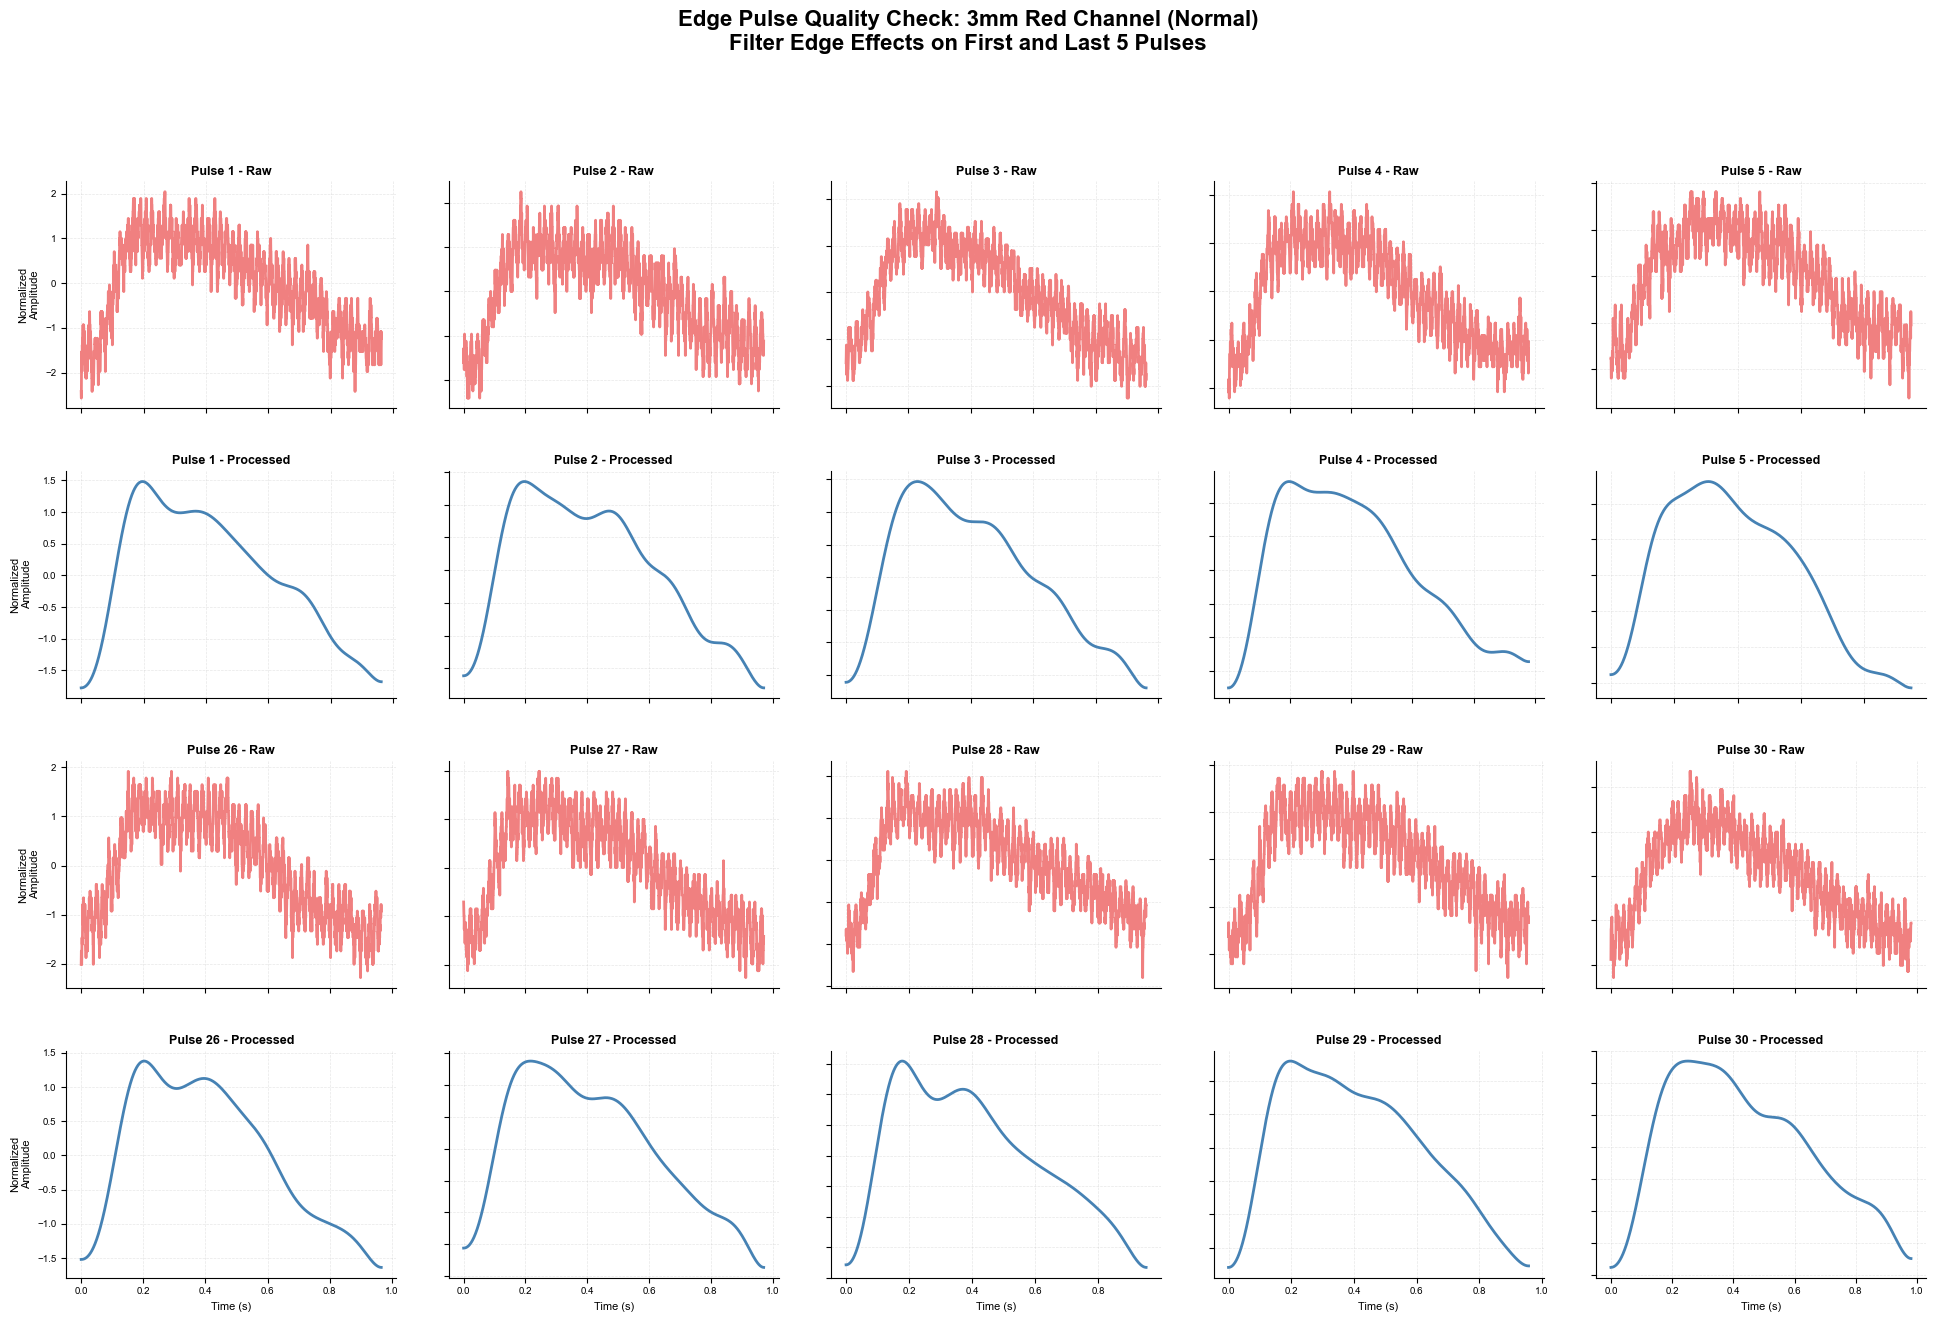


[2/3] Creating overlay comparison...
✓ Saved: edge_pulse_visualization/overlay_comparison_3mm_Red.png


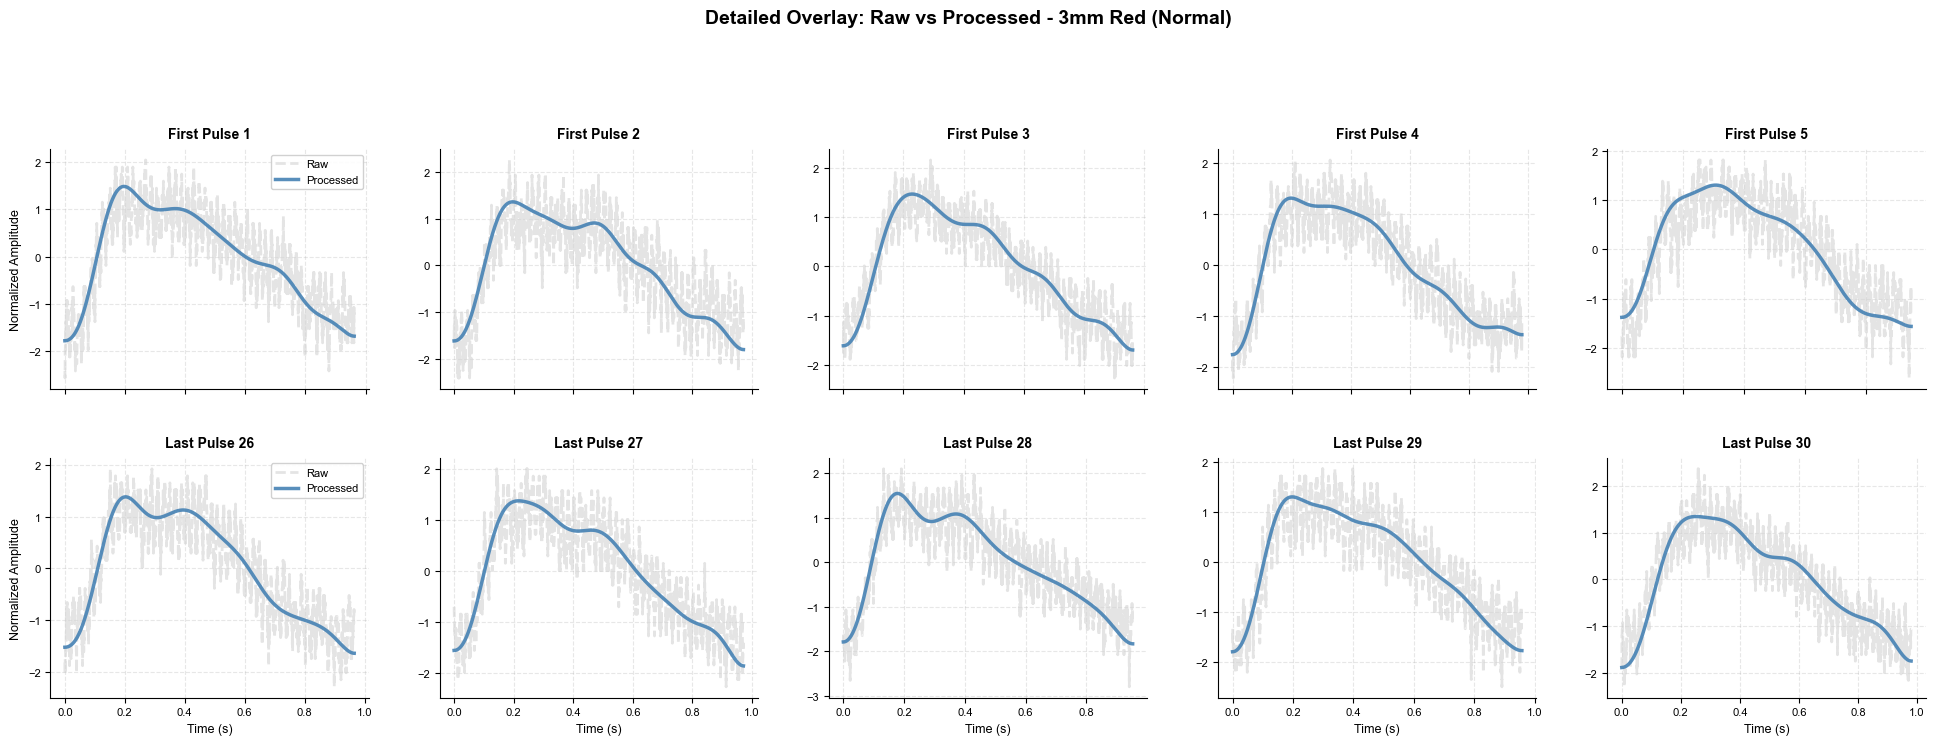


[3/3] Performing quantitative assessment...

QUANTITATIVE EDGE ASSESSMENT: Red Channel

First 5 Pulses:
       Amplitude       SNR  Skewness  Kurtosis  Peak_Sharpness
count   5.000000  5.000000  5.000000  5.000000        5.000000
mean    0.002998  1.602019 -0.211193 -1.410571        0.004100
std     0.000168  0.098838  0.077942  0.109418        0.000351
min     0.002820  1.493643 -0.290146 -1.520891        0.003711
25%     0.002925  1.545202 -0.261797 -1.506866        0.003746
50%     0.002926  1.564422 -0.249019 -1.397097        0.004202
75%     0.003062  1.670803 -0.133261 -1.375697        0.004408
max     0.003257  1.736025 -0.121744 -1.252304        0.004432

Last 5 Pulses:
       Amplitude       SNR  Skewness  Kurtosis  Peak_Sharpness
count   5.000000  5.000000  5.000000  5.000000        5.000000
mean    0.003056  1.515117 -0.242568 -1.308881        0.004173
std     0.000226  0.070589  0.093907  0.155024        0.000379
min     0.002790  1.434109 -0.397281 -1.554787        0.0037

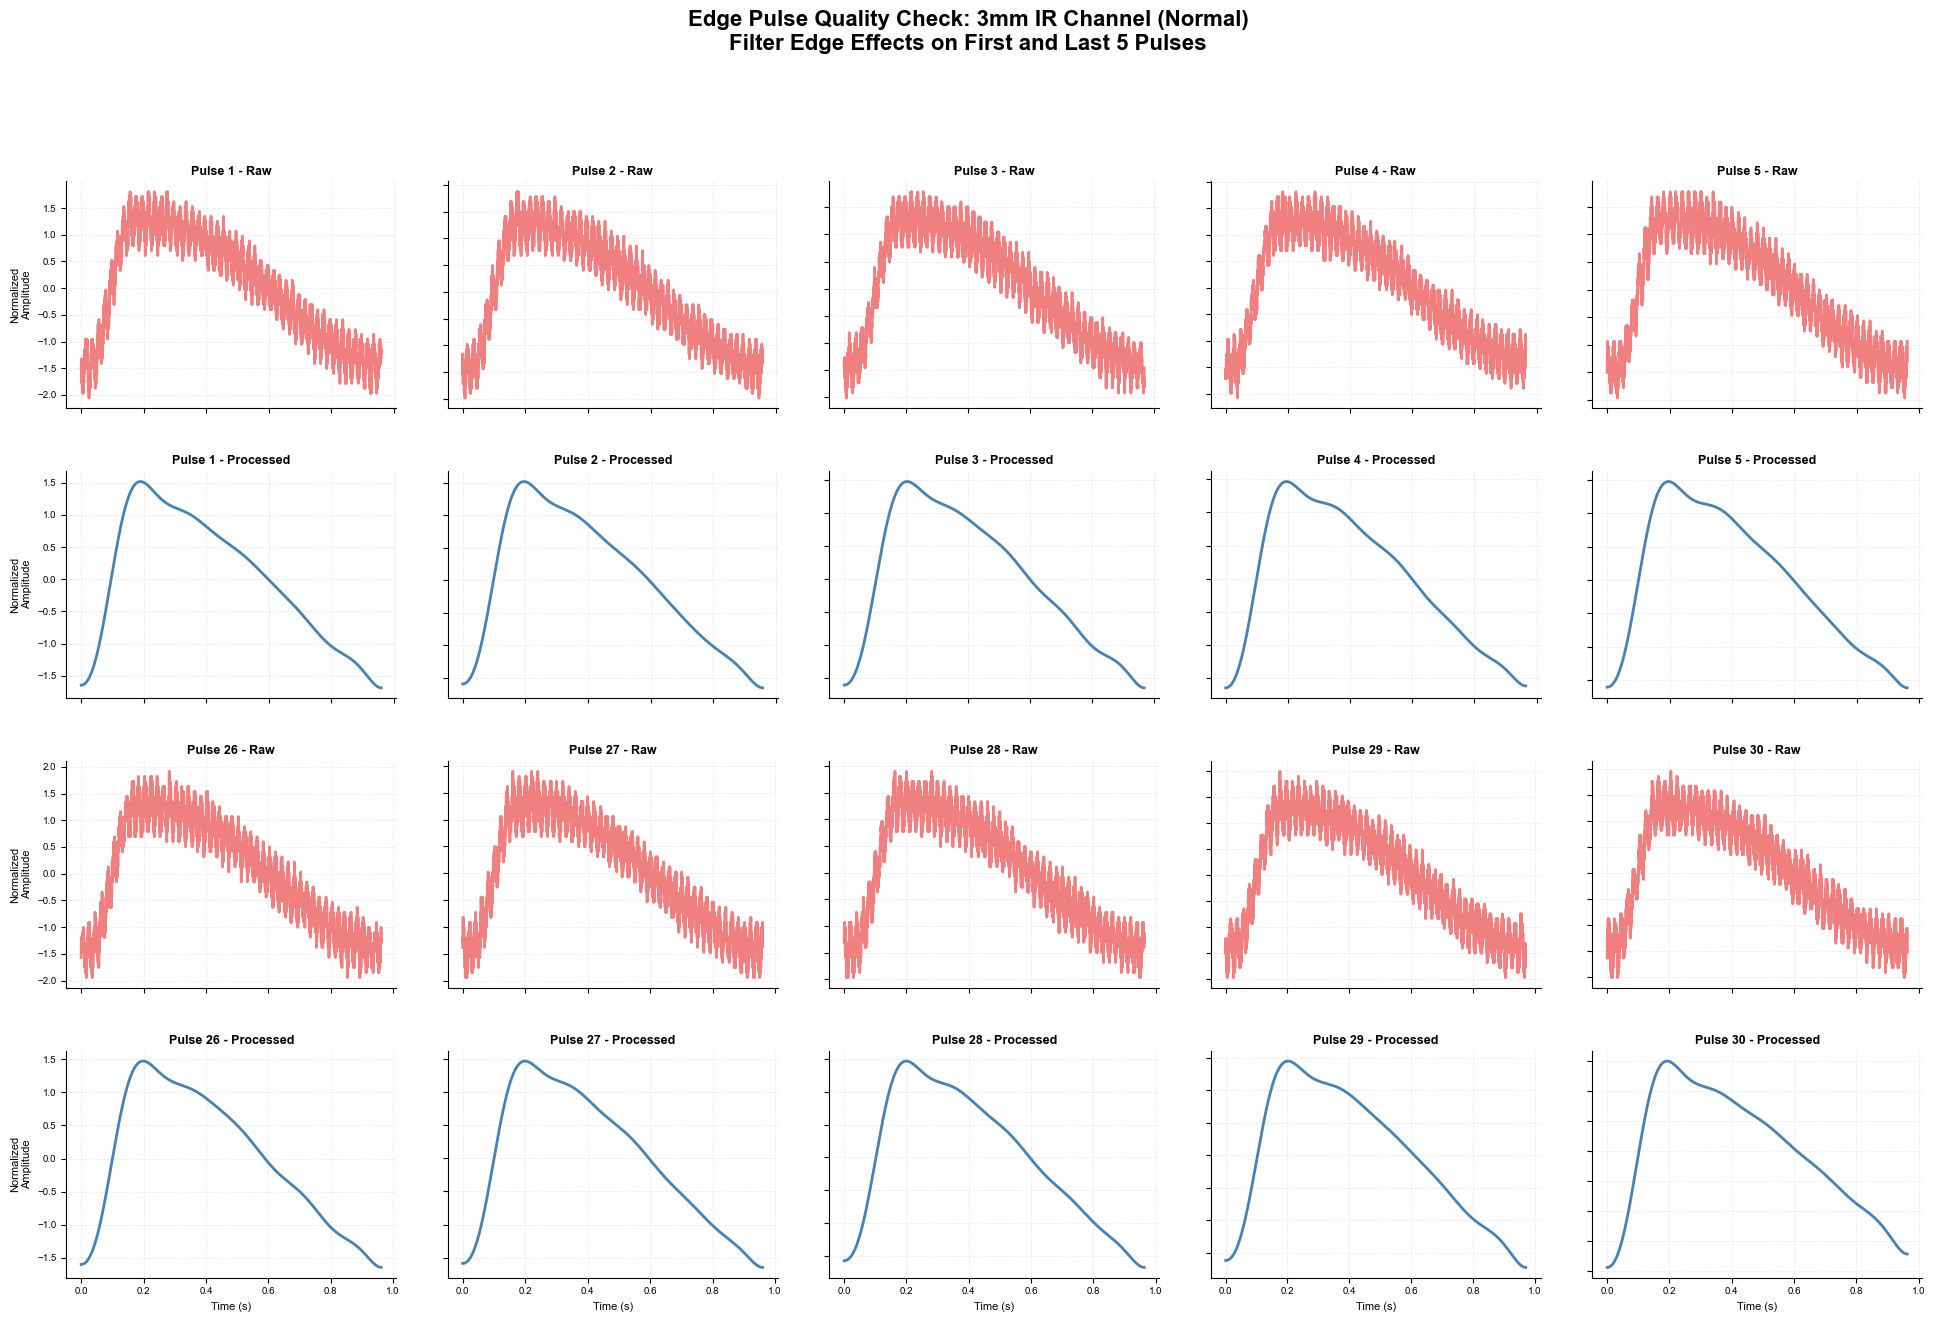


[2/3] Creating overlay comparison...
✓ Saved: edge_pulse_visualization/overlay_comparison_3mm_IR.png


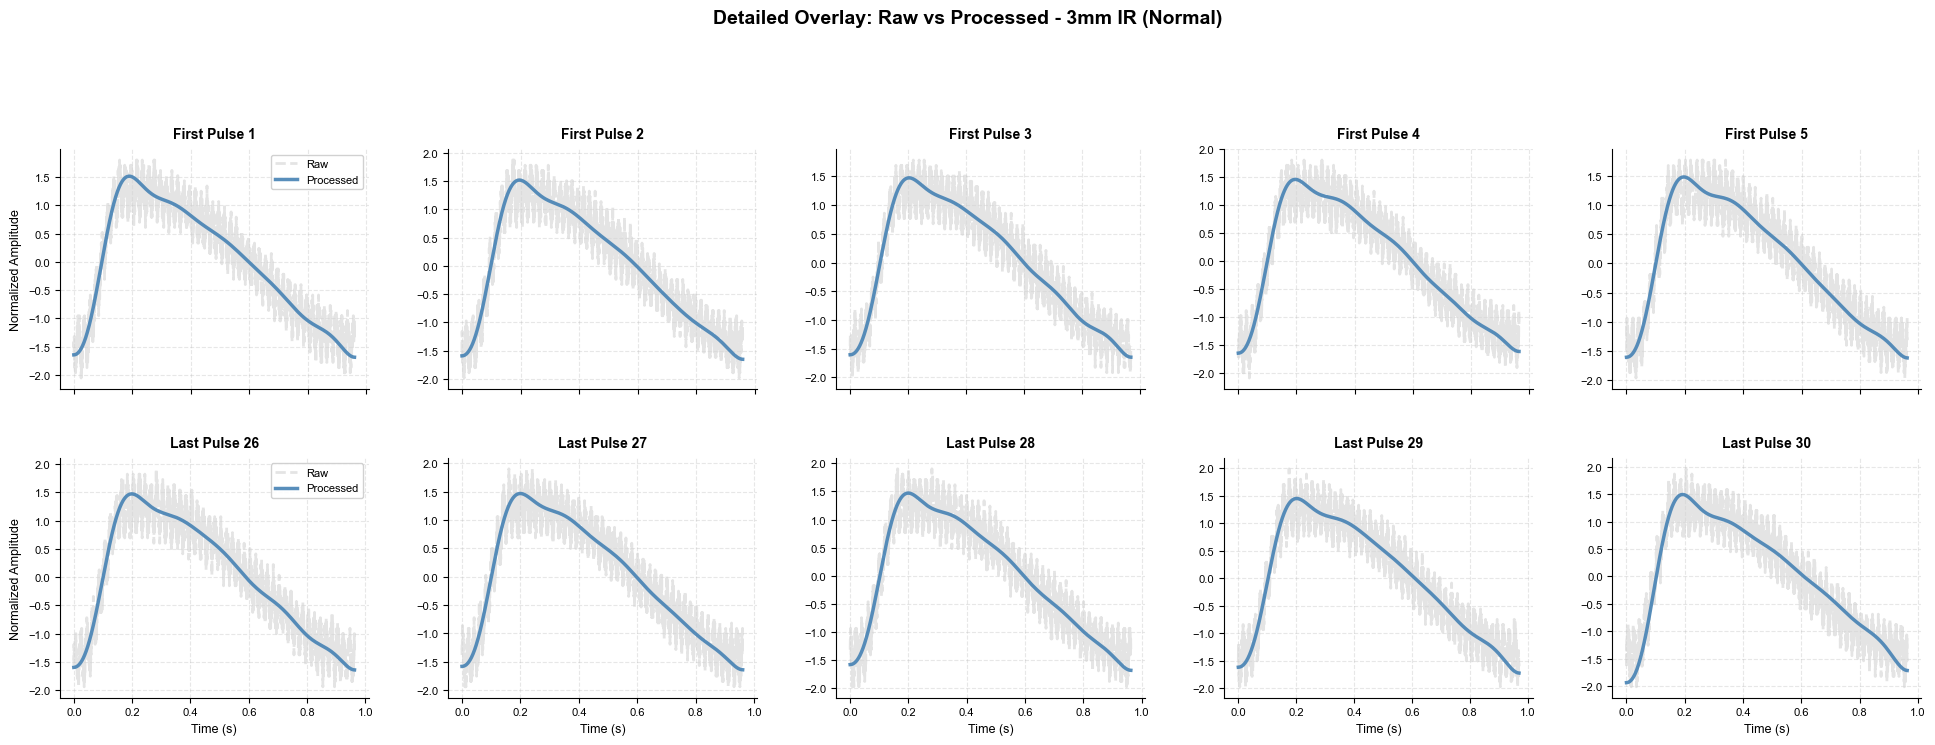


[3/3] Performing quantitative assessment...

QUANTITATIVE EDGE ASSESSMENT: IR Channel

First 5 Pulses:
       Amplitude       SNR  Skewness  Kurtosis  Peak_Sharpness
count   5.000000  5.000000  5.000000  5.000000        5.000000
mean    0.004795  1.596861 -0.115183 -1.374923        0.004380
std     0.000080  0.066277  0.016454  0.032594        0.000096
min     0.004693  1.550238 -0.140781 -1.403537        0.004234
25%     0.004749  1.554212 -0.116888 -1.399752        0.004339
50%     0.004791  1.561996 -0.116744 -1.388710        0.004416
75%     0.004843  1.610678 -0.102442 -1.354798        0.004428
max     0.004898  1.707184 -0.099059 -1.327816        0.004481

Last 5 Pulses:
       Amplitude       SNR  Skewness  Kurtosis  Peak_Sharpness
count   5.000000  5.000000  5.000000  5.000000        5.000000
mean    0.004747  1.453270 -0.156713 -1.334036        0.004298
std     0.000122  0.075170  0.056870  0.093653        0.000117
min     0.004540  1.347431 -0.250888 -1.391350        0.00417

In [24]:
"""
Edge Pulse Quality Visualization
=================================
Visualize first 5 and last 5 pulses to check filter edge effects
Compare Raw vs Processed signals
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import warnings
import os

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000
TARGET_DEPTH = 3
STATE_CODE = 1  # Normal state for visualization
STATE_NAME = 'Normal'

CHANNELS = {
    'Red': {'raw': 'ppgA_Red_raw', 'processed': 'Red_processed'},
    'IR': {'raw': 'ppgA_IR_raw', 'processed': 'IR_processed'}
}

OUTPUT_DIR = 'edge_pulse_visualization'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ========================================
# PULSE DETECTION
# ========================================

def detect_pulses(processed_signal, fs=2000):
    """
    Detect pulse boundaries using trough detection
    
    Returns:
    --------
    list of tuples: [(start_idx, end_idx), ...]
    """
    # Find troughs (valleys)
    troughs, _ = signal.find_peaks(-processed_signal, distance=int(fs * 0.6))
    
    # Create pulse segments
    pulses = []
    for i in range(len(troughs) - 1):
        idx1, idx2 = troughs[i], troughs[i+1]
        
        # Quality filter
        pulse_duration = (idx2 - idx1) / fs
        if 0.4 <= pulse_duration <= 1.5:
            pulses.append((idx1, idx2))
    
    return pulses

# ========================================
# VISUALIZATION
# ========================================

def plot_edge_pulses_comparison(channel_name, raw_col, processed_col):
    """
    Create comprehensive visualization of edge pulses
    """
    filename = f'{TARGET_DEPTH}mm_processed_data{STATE_CODE}.csv'
    
    if not os.path.exists(filename):
        print(f"⚠️  File not found: {filename}")
        return
    
    df = pd.read_csv(filename)
    
    # Extract full 30 seconds
    max_samples = int(30 * FS)
    raw_signal = df[raw_col].values[:max_samples]
    processed_signal = df[processed_col].values[:max_samples]
    
    # Detect all pulses
    pulses = detect_pulses(processed_signal, FS)
    
    if len(pulses) < 10:
        print(f"⚠️  Not enough pulses detected: {len(pulses)}")
        return
    
    print(f"✓ Detected {len(pulses)} pulses in {channel_name} channel")
    
    # Select first 5 and last 5 pulses
    first_5_pulses = pulses[:5]
    last_5_pulses = pulses[-5:]
    
    # Create figure
    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(f'Edge Pulse Quality Check: {TARGET_DEPTH}mm {channel_name} Channel ({STATE_NAME})\n'
                 f'Filter Edge Effects on First and Last 5 Pulses',
                 fontsize=16, fontweight='bold', y=0.98)
    
    # ===== FIRST 5 PULSES =====
    for i, (start_idx, end_idx) in enumerate(first_5_pulses):
        # Raw signal subplot
        ax_raw = plt.subplot(4, 5, i + 1)
        plot_single_pulse(ax_raw, raw_signal, start_idx, end_idx, 
                         f'Pulse {i+1} - Raw', 'lightcoral', show_ylabel=(i==0))
        
        # Processed signal subplot
        ax_proc = plt.subplot(4, 5, i + 6)
        plot_single_pulse(ax_proc, processed_signal, start_idx, end_idx,
                         f'Pulse {i+1} - Processed', 'steelblue', show_ylabel=(i==0))
    
    # ===== LAST 5 PULSES =====
    total_pulses = len(pulses)
    for i, (start_idx, end_idx) in enumerate(last_5_pulses):
        pulse_num = total_pulses - 4 + i
        
        # Raw signal subplot
        ax_raw = plt.subplot(4, 5, i + 11)
        plot_single_pulse(ax_raw, raw_signal, start_idx, end_idx,
                         f'Pulse {pulse_num} - Raw', 'lightcoral', 
                         show_ylabel=(i==0), show_xlabel=False)
        
        # Processed signal subplot
        ax_proc = plt.subplot(4, 5, i + 16)
        plot_single_pulse(ax_proc, processed_signal, start_idx, end_idx,
                         f'Pulse {pulse_num} - Processed', 'steelblue',
                         show_ylabel=(i==0), show_xlabel=True)
    
    plt.tight_layout(rect=[0, 0.02, 1, 0.96])
    
    # Save
    output_filename = os.path.join(OUTPUT_DIR, 
                                   f'edge_pulses_{TARGET_DEPTH}mm_{channel_name}.png')
    plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✓ Saved: {output_filename}")
    
    plt.show()

def plot_single_pulse(ax, signal_data, start_idx, end_idx, title, color, 
                     show_ylabel=False, show_xlabel=False):
    """
    Plot single pulse segment
    """
    # Extract pulse
    pulse_segment = signal_data[start_idx:end_idx]
    
    # Normalize for better visualization
    pulse_norm = (pulse_segment - np.mean(pulse_segment)) / (np.std(pulse_segment) + 1e-10)
    
    # Time axis
    time = np.arange(len(pulse_segment)) / FS
    
    # Plot
    ax.plot(time, pulse_norm, color=color, linewidth=2)
    ax.set_title(title, fontsize=9, fontweight='bold', pad=5)
    
    # Labels
    if show_xlabel:
        ax.set_xlabel('Time (s)', fontsize=8)
    else:
        ax.set_xticklabels([])
    
    if show_ylabel:
        ax.set_ylabel('Normalized\nAmplitude', fontsize=8)
    else:
        ax.set_yticklabels([])
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=7)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ========================================
# DETAILED OVERLAY COMPARISON
# ========================================

def plot_detailed_overlay_comparison(channel_name, raw_col, processed_col):
    """
    Create detailed overlay comparison: first 5 vs last 5 pulses
    """
    filename = f'{TARGET_DEPTH}mm_processed_data{STATE_CODE}.csv'
    
    if not os.path.exists(filename):
        print(f"⚠️  File not found: {filename}")
        return
    
    df = pd.read_csv(filename)
    
    # Extract signals
    max_samples = int(30 * FS)
    raw_signal = df[raw_col].values[:max_samples]
    processed_signal = df[processed_col].values[:max_samples]
    
    # Detect pulses
    pulses = detect_pulses(processed_signal, FS)
    
    if len(pulses) < 10:
        return
    
    # Create figure
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle(f'Detailed Overlay: Raw vs Processed - {TARGET_DEPTH}mm {channel_name} ({STATE_NAME})',
                 fontsize=14, fontweight='bold', y=0.98)
    
    # First 5 pulses
    for i, (start_idx, end_idx) in enumerate(pulses[:5]):
        ax = axes[0, i]
        plot_overlay_pulse(ax, raw_signal, processed_signal, start_idx, end_idx,
                          f'First Pulse {i+1}', show_ylabel=(i==0))
    
    # Last 5 pulses
    total_pulses = len(pulses)
    for i, (start_idx, end_idx) in enumerate(pulses[-5:]):
        ax = axes[1, i]
        pulse_num = total_pulses - 4 + i
        plot_overlay_pulse(ax, raw_signal, processed_signal, start_idx, end_idx,
                          f'Last Pulse {pulse_num}', show_ylabel=(i==0), show_xlabel=True)
    
    plt.tight_layout(rect=[0, 0.02, 1, 0.96])
    
    # Save
    output_filename = os.path.join(OUTPUT_DIR,
                                   f'overlay_comparison_{TARGET_DEPTH}mm_{channel_name}.png')
    plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✓ Saved: {output_filename}")
    
    plt.show()

def plot_overlay_pulse(ax, raw_signal, processed_signal, start_idx, end_idx, 
                      title, show_ylabel=False, show_xlabel=False):
    """
    Overlay raw and processed pulse on same axes
    """
    # Extract pulses
    raw_pulse = raw_signal[start_idx:end_idx]
    proc_pulse = processed_signal[start_idx:end_idx]
    
    # Normalize
    raw_norm = (raw_pulse - np.mean(raw_pulse)) / (np.std(raw_pulse) + 1e-10)
    proc_norm = (proc_pulse - np.mean(proc_pulse)) / (np.std(proc_pulse) + 1e-10)
    
    # Time axis
    time = np.arange(len(raw_pulse)) / FS
    
    # Plot
    ax.plot(time, raw_norm, color='lightgray', linewidth=2, 
           label='Raw', alpha=0.6, linestyle='--')
    ax.plot(time, proc_norm, color='steelblue', linewidth=2.5, 
           label='Processed', alpha=0.9)
    
    ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
    
    if show_xlabel:
        ax.set_xlabel('Time (s)', fontsize=9)
    else:
        ax.set_xticklabels([])
    
    if show_ylabel:
        ax.set_ylabel('Normalized Amplitude', fontsize=9)
        ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=8)

# ========================================
# QUANTITATIVE ASSESSMENT
# ========================================

def quantitative_edge_assessment(channel_name, raw_col, processed_col):
    """
    Quantitative comparison of pulse quality: first 5 vs last 5
    """
    filename = f'{TARGET_DEPTH}mm_processed_data{STATE_CODE}.csv'
    
    if not os.path.exists(filename):
        return
    
    df = pd.read_csv(filename)
    
    max_samples = int(30 * FS)
    processed_signal = df[processed_col].values[:max_samples]
    
    pulses = detect_pulses(processed_signal, FS)
    
    if len(pulses) < 10:
        return
    
    print("\n" + "="*80)
    print(f"QUANTITATIVE EDGE ASSESSMENT: {channel_name} Channel")
    print("="*80)
    
    # Metrics for first 5 and last 5
    first_5_metrics = []
    last_5_metrics = []
    
    for start_idx, end_idx in pulses[:5]:
        pulse = processed_signal[start_idx:end_idx]
        metrics = calculate_pulse_metrics(pulse)
        first_5_metrics.append(metrics)
    
    for start_idx, end_idx in pulses[-5:]:
        pulse = processed_signal[start_idx:end_idx]
        metrics = calculate_pulse_metrics(pulse)
        last_5_metrics.append(metrics)
    
    # Convert to DataFrame
    df_first = pd.DataFrame(first_5_metrics)
    df_last = pd.DataFrame(last_5_metrics)
    
    print("\nFirst 5 Pulses:")
    print(df_first.describe())
    
    print("\nLast 5 Pulses:")
    print(df_last.describe())
    
    # Statistical comparison
    print("\nMean Difference (Last - First):")
    for col in df_first.columns:
        diff = df_last[col].mean() - df_first[col].mean()
        pct_diff = (diff / df_first[col].mean()) * 100 if df_first[col].mean() != 0 else 0
        print(f"  {col:20s}: {diff:+8.4f} ({pct_diff:+6.2f}%)")

def calculate_pulse_metrics(pulse):
    """
    Calculate quality metrics for single pulse
    """
    # Normalize
    pulse_norm = (pulse - np.min(pulse)) / (np.max(pulse) - np.min(pulse) + 1e-10)
    
    metrics = {}
    metrics['Amplitude'] = np.max(pulse) - np.min(pulse)
    metrics['SNR'] = np.mean(pulse) / (np.std(pulse) + 1e-10)
    metrics['Skewness'] = pd.Series(pulse_norm).skew()
    metrics['Kurtosis'] = pd.Series(pulse_norm).kurtosis()
    metrics['Peak_Sharpness'] = np.max(np.abs(np.gradient(pulse_norm)))
    
    return metrics

# ========================================
# MAIN EXECUTION
# ========================================

def main():
    print("="*80)
    print("EDGE PULSE QUALITY VISUALIZATION")
    print("="*80)
    print(f"Target: {TARGET_DEPTH}mm {STATE_NAME} state")
    print(f"Checking first 5 and last 5 pulses for filter edge effects")
    print("="*80)
    
    for channel_name, cols in CHANNELS.items():
        print(f"\n{'='*80}")
        print(f"Processing: {channel_name} Channel")
        print(f"{'='*80}")
        
        # 1. Side-by-side comparison
        print("\n[1/3] Creating side-by-side comparison...")
        plot_edge_pulses_comparison(channel_name, cols['raw'], cols['processed'])
        
        # 2. Overlay comparison
        print("\n[2/3] Creating overlay comparison...")
        plot_detailed_overlay_comparison(channel_name, cols['raw'], cols['processed'])
        
        # 3. Quantitative assessment
        print("\n[3/3] Performing quantitative assessment...")
        quantitative_edge_assessment(channel_name, cols['raw'], cols['processed'])
    
    print("\n" + "="*80)
    print("✅ VISUALIZATION COMPLETE")
    print("="*80)
    print(f"Output directory: {OUTPUT_DIR}")
    print("\nGenerated files:")
    for channel_name in CHANNELS.keys():
        print(f"  - edge_pulses_{TARGET_DEPTH}mm_{channel_name}.png")
        print(f"  - overlay_comparison_{TARGET_DEPTH}mm_{channel_name}.png")
    print("="*80)

if __name__ == "__main__":
    main()


In [ ]:
"""
PPG Pulse Detection and Feature Extraction Visualization (FINAL)
Based on pyppg open-source methodology

修正点（v3）：
1. Dicrotic notch検出を2次微分（曲率）ベースに改善
2. 端部パルス（最初と最後）を除外して安定したパルスのみ使用
3. より正確な凹み検出のためのロバストな処理
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import signal
from scipy.interpolate import interp1d
import os
import warnings
warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000  # Hz
TARGET_DEPTH = 3  # mm
STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}
CHANNELS = {'ppgA_Red_raw': 'Red', 'ppgA_IR_raw': 'IR'}
OUTPUT_DIR = 'pulse_detection_validation_final'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 可視化パラメータ
DISPLAY_START_TIME = 10.0  # 秒（安定した部分から）
DISPLAY_DURATION = 6.0     # 秒（4-6心拍を表示）
N_PULSES_DETAIL = 3        # 詳細表示するパルス数

# ========================================
# PREPROCESSING
# ========================================

def bandpass_filter(data, lowcut=0.5, highcut=10.0, fs=2000, order=4):
    """
    Chebyshev Type II bandpass filter
    pyppg標準: 0.5-10 Hz
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    sos = signal.cheby2(order, 40, [low, high], btype='band', output='sos')
    return signal.sosfiltfilt(sos, data)

def estimate_bpm(ppg_signal, fs=2000):
    """BPM推定（FFTベース）"""
    freqs = np.fft.rfftfreq(len(ppg_signal), 1/fs)
    fft_vals = np.abs(np.fft.rfft(ppg_signal))
    idx = np.where((freqs >= 0.8) & (freqs <= 3.0))  # 48-180 bpm
    peak_freq = freqs[idx][np.argmax(fft_vals[idx])]
    return peak_freq * 60

# ========================================
# FIDUCIAL POINT DETECTION (IMPROVED)
# ========================================

def detect_fiducial_points(ppg_segment, fs=2000):
    """
    pyppgスタイルのfiducial point検出（改善版）
    
    前提：ppg_segmentは谷から谷までのセグメント
    
    改善点：
    - Dicrotic notchを2次微分（曲率）ベースで検出
    - より正確な「凹み」の位置を特定
    
    Returns:
    --------
    dict with keys:
        - onset: パルス開始点（最初の谷 = index 0）
        - systolic_peak: 収縮期ピーク（最大値）
        - dicrotic_notch: 拡張期ノッチ（2次微分最大 = 最も凹んだ点）
        - diastolic_peak: 拡張期ピーク（optional）
        - offset: パルス終了点（次の谷 = last index）
        - valid: 検出成功フラグ
    """
    fiducials = {'valid': False}
    
    if len(ppg_segment) < 50:
        return fiducials
    
    # 1. Onset (segment start = first trough = 0)
    onset = 0
    
    # 2. Offset (segment end = second trough = last index)
    offset = len(ppg_segment) - 1
    
    # 3. Systolic Peak (global maximum)
    systolic_peak = np.argmax(ppg_segment)
    
    # 4. Diastolic phase analysis (improved dicrotic notch detection)
    # Systolic peakから後半の40%程度の範囲を探索
    diastolic_start = systolic_peak
    diastolic_search_end = systolic_peak + int((offset - systolic_peak) * 0.6)
    diastolic_segment = ppg_segment[diastolic_start:diastolic_search_end]
    
    dicrotic_notch = None
    diastolic_peak = None
    
    if len(diastolic_segment) > 15:
        # *** 改善：2次微分（曲率）でdicrotic notchを検出 ***
        # 平滑化して高周波ノイズを除去
        from scipy.ndimage import gaussian_filter1d
        smoothed = gaussian_filter1d(diastolic_segment, sigma=2)
        
        # 2次微分を計算（曲率）
        second_derivative = np.gradient(np.gradient(smoothed))
        
        # 2次微分が最大 = 最も凹んだ点（下に凸）
        # 探索範囲：diastolic segmentの前半50%
        search_range = len(second_derivative) // 2
        if search_range > 5:
            notch_candidate = np.argmax(second_derivative[:search_range])
            dicrotic_notch = diastolic_start + notch_candidate
        
        # Diastolic peak: dicrotic notch以降の局所最大値
        if dicrotic_notch is not None:
            post_notch_start = dicrotic_notch - diastolic_start + 5  # notchから少し後
            post_notch = diastolic_segment[post_notch_start:]
            
            if len(post_notch) > 10:
                # 局所最大値を探索
                diastolic_peak_local = signal.argrelextrema(post_notch, np.greater, order=5)
                if len(diastolic_peak_local[0]) > 0:
                    diastolic_peak = diastolic_start + post_notch_start + diastolic_peak_local[0][0]
                else:
                    # 見つからない場合は単純最大値
                    diastolic_peak = diastolic_start + post_notch_start + np.argmax(post_notch)
    
    # 結果を格納
    fiducials = {
        'onset': onset,
        'systolic_peak': systolic_peak,
        'dicrotic_notch': dicrotic_notch,
        'diastolic_peak': diastolic_peak,
        'offset': offset,
        'valid': True
    }
    
    return fiducials

# ========================================
# FEATURE EXTRACTION (CORRECTED BASELINE)
# ========================================

def extract_pulse_features(ppg_segment, fiducials, fs=2000):
    """
    単一パルスから特徴量を抽出（修正版：谷-谷ベースライン）
    
    ベースライン定義：
    - onset（最初の谷）とoffset（次の谷）を結ぶ直線
    - 面積計算はこのベースラインからの積分
    
    Features (DC-excluded):
    - Amplitude (AC): systolic peak - baseline at peak position
    - AUC: total area above baseline
    - S-AUC: systolic area (onset to systolic peak)
    - D-AUC: diastolic area (systolic peak to offset)
    - AUC Ratio: S-AUC / D-AUC
    - Start Datum Area: first quarter area above baseline
    - End Datum Area: last quarter area above baseline
    - Datum Area Ratio: Start / End
    - Max Start Datum Diff: max value in first quarter - baseline
    """
    features = {}
    
    if not fiducials['valid']:
        return {k: np.nan for k in [
            'Amplitude', 'AUC', 'S_AUC', 'D_AUC', 'AUC_Ratio',
            'Start_Datum_Area', 'End_Datum_Area', 'Datum_Area_Ratio',
            'Max_Start_Datum_Diff'
        ]}, None
    
    onset = fiducials['onset']
    systolic_peak = fiducials['systolic_peak']
    offset = fiducials['offset']
    
    # 谷-谷間のlinear baseline
    baseline_values = np.linspace(ppg_segment[onset], ppg_segment[offset], len(ppg_segment))
    
    # Baseline補正後の信号
    segment_corrected = ppg_segment - baseline_values
    
    # Amplitude (AC component): systolic peakでのbaseline補正後の値
    amplitude = segment_corrected[systolic_peak]
    features['Amplitude'] = amplitude
    
    # AUC計算（台形則、baselineからの積分）
    auc_total = np.trapz(segment_corrected)
    features['AUC'] = auc_total
    
    # Systolic AUC (onset to systolic peak)
    s_auc = np.trapz(segment_corrected[onset:systolic_peak+1])
    features['S_AUC'] = s_auc
    
    # Diastolic AUC (systolic peak to offset)
    d_auc = np.trapz(segment_corrected[systolic_peak:offset+1])
    features['D_AUC'] = d_auc
    
    # AUC Ratio
    features['AUC_Ratio'] = s_auc / d_auc if d_auc > 0 else np.nan
    
    # Datum Areas (基準面積) - baseline補正後
    quarter_length = len(ppg_segment) // 4
    
    start_datum_area = np.trapz(segment_corrected[:quarter_length])
    features['Start_Datum_Area'] = start_datum_area
    
    end_datum_area = np.trapz(segment_corrected[-quarter_length:])
    features['End_Datum_Area'] = end_datum_area
    
    features['Datum_Area_Ratio'] = start_datum_area / end_datum_area if end_datum_area > 0 else np.nan
    
    # Max Start Datum Difference - baseline補正後
    max_start_diff = np.max(segment_corrected[:quarter_length])
    features['Max_Start_Datum_Diff'] = max_start_diff
    
    return features, baseline_values

# ========================================
# PULSE SEGMENTATION (trough-to-trough)
# ========================================

def segment_pulses(ppg_filtered, fs=2000):
    """
    PPG信号からパルスをセグメント化（谷-谷ベース）
    
    修正点（v3）：
    - 端部パルス（最初と最後）を除外
    - 安定したパルスのみ返す
    
    Returns:
    --------
    list of dicts:
        - segment: signal array
        - start_idx: global index (trough)
        - end_idx: global index (next trough)
        - fiducials: detected fiducial points
        - features: extracted features
        - baseline: baseline values for visualization
    """
    # BPM推定
    bpm = estimate_bpm(ppg_filtered, fs)
    print(f"    Estimated BPM: {bpm:.1f}")
    
    # 谷（troughs）を検出
    inverted_signal = -ppg_filtered
    min_distance = int(fs * 60 / bpm * 0.6)  # 最小間隔（60%）
    
    troughs, properties = signal.find_peaks(
        inverted_signal, 
        distance=min_distance,
        prominence=0.3 * np.std(inverted_signal)
    )
    
    print(f"    Detected {len(troughs)} troughs (valleys)")
    
    if len(troughs) < 4:  # 最低4つ（端部除外して2つ以上必要）
        print("    WARNING: Insufficient troughs detected")
        return []
    
    # *** 修正：端部を除外（最初と最後のパルスをスキップ） ***
    troughs_valid = troughs[1:-1]  # 最初と最後の谷を除外
    print(f"    Using {len(troughs_valid)-1} stable pulses (excluding edge artifacts)")
    
    # パルスセグメント化（谷-谷間）
    pulses = []
    
    for i in range(len(troughs_valid) - 1):
        start_idx = troughs_valid[i]      # 最初の谷
        end_idx = troughs_valid[i + 1]    # 次の谷
        
        segment = ppg_filtered[start_idx:end_idx+1]
        
        # Fiducial point detection（改善版）
        fiducials = detect_fiducial_points(segment, fs)
        
        # グローバルインデックスに変換
        if fiducials['valid']:
            fiducials_global = {
                'onset': start_idx + fiducials['onset'],
                'systolic_peak': start_idx + fiducials['systolic_peak'],
                'dicrotic_notch': start_idx + fiducials['dicrotic_notch'] if fiducials['dicrotic_notch'] is not None else None,
                'diastolic_peak': start_idx + fiducials['diastolic_peak'] if fiducials['diastolic_peak'] is not None else None,
                'offset': start_idx + fiducials['offset'],
                'valid': True
            }
        else:
            fiducials_global = {'valid': False}
        
        # Feature extraction
        features, baseline_values = extract_pulse_features(segment, fiducials, fs)
        
        pulses.append({
            'segment': segment,
            'baseline': baseline_values,
            'start_idx': start_idx,
            'end_idx': end_idx,
            'fiducials': fiducials,
            'fiducials_global': fiducials_global,
            'features': features
        })
    
    print(f"    Segmented {len(pulses)} valid pulses")
    return pulses

# ========================================
# VISUALIZATION FUNCTIONS
# ========================================

def plot_pulse_detection_overview(ppg_filtered, pulses, time_axis, 
                                   state_name, channel_name, output_dir):
    """
    パルス検出の全体像を可視化（4-6心拍）
    修正：谷-谷ベースライン、改善されたdicrotic notch表示
    """
    fig, ax = plt.subplots(figsize=(16, 5))
    
    # 信号プロット
    ax.plot(time_axis, ppg_filtered, color='#2E86AB', linewidth=1.5, 
            label='Filtered PPG', alpha=0.8, zorder=2)
    
    # 各パルスの境界とfiducial pointsをマーク
    colors = plt.cm.Set3(np.linspace(0, 1, len(pulses)))
    
    for i, pulse in enumerate(pulses):
        fid = pulse['fiducials_global']
        
        if not fid['valid']:
            continue
        
        # パルス領域
        pulse_time = time_axis[pulse['start_idx']:pulse['end_idx']+1]
        pulse_signal = ppg_filtered[pulse['start_idx']:pulse['end_idx']+1]
        
        # 谷-谷ベースライン
        baseline_global = pulse['baseline']
        ax.plot(pulse_time, baseline_global, color='red', linestyle='--', 
                linewidth=1.5, alpha=0.8, label='Baseline (trough-to-trough)' if i == 0 else '', zorder=3)
        
        # ベースラインより上の領域を塗りつぶし
        ax.fill_between(pulse_time, pulse_signal, baseline_global, 
                       where=(pulse_signal >= baseline_global),
                       alpha=0.25, color=colors[i], label=f'Pulse {i+1}' if i < 3 else '', zorder=1)
        
        # Fiducial points
        # Onset (trough)
        ax.plot(time_axis[fid['onset']], ppg_filtered[fid['onset']], 
                'go', markersize=8, label='Onset (trough)' if i == 0 else '', zorder=5)
        
        # Systolic Peak
        ax.plot(time_axis[fid['systolic_peak']], ppg_filtered[fid['systolic_peak']], 
                'r^', markersize=10, label='Systolic Peak' if i == 0 else '', zorder=5)
        
        # *** 改善：Dicrotic Notch（2次微分ベース） ***
        if fid['dicrotic_notch'] is not None:
            ax.plot(time_axis[fid['dicrotic_notch']], ppg_filtered[fid['dicrotic_notch']], 
                    'mo', markersize=8, markeredgewidth=2, markeredgecolor='purple',
                    label='Dicrotic Notch (curvature-based)' if i == 0 else '', zorder=5)
        
        # Diastolic Peak (if detected)
        if fid['diastolic_peak'] is not None:
            ax.plot(time_axis[fid['diastolic_peak']], ppg_filtered[fid['diastolic_peak']], 
                    'cv', markersize=7, label='Diastolic Peak' if i == 0 else '', zorder=5)
        
        # Offset (trough)
        ax.plot(time_axis[fid['offset']], ppg_filtered[fid['offset']], 
                'gs', markersize=8, alpha=0.6, zorder=5)
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Amplitude (normalized)', fontsize=12)
    ax.set_title(f'Pulse Detection Overview: {state_name} - {channel_name}\n(Trough-to-Trough Segmentation, Edge Pulses Excluded)', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper right', fontsize=9, ncol=2)
    
    plt.tight_layout()
    filename = os.path.join(output_dir, f'pulse_detection_{state_name}_{channel_name}.png')
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"      ✓ Saved: {filename}")

def plot_detailed_pulse_features(pulses, state_name, channel_name, output_dir):
    """
    最初の3パルスの詳細な特徴量可視化
    修正：改善されたdicrotic notch表示
    """
    n_pulses = min(N_PULSES_DETAIL, len(pulses))
    
    if n_pulses == 0:
        print("      WARNING: No valid pulses for detailed visualization")
        return
    
    fig, axes = plt.subplots(n_pulses, 1, figsize=(14, 4*n_pulses))
    
    if n_pulses == 1:
        axes = [axes]
    
    for i in range(n_pulses):
        pulse = pulses[i]
        segment = pulse['segment']
        baseline_values = pulse['baseline']
        fid = pulse['fiducials']
        features = pulse['features']
        
        ax = axes[i]
        
        # 時間軸（パルス内）
        time_pulse = np.arange(len(segment)) / FS * 1000  # ms
        
        # 信号プロット
        ax.plot(time_pulse, segment, color='#2E86AB', linewidth=2.5, 
                label='PPG Pulse', zorder=2)
        
        # 谷-谷ベースライン
        ax.plot(time_pulse, baseline_values, color='red', linestyle='--', 
                linewidth=2, alpha=0.8, label='Trough-to-Trough Baseline', zorder=3)
        
        # Fiducial points
        ax.plot(time_pulse[fid['onset']], segment[fid['onset']], 
                'go', markersize=12, label='Onset (trough)', zorder=5)
        ax.plot(time_pulse[fid['systolic_peak']], segment[fid['systolic_peak']], 
                'r^', markersize=14, label='Systolic Peak', zorder=5)
        
        # *** 改善：Dicrotic Notch（より目立つマーカー） ***
        if fid['dicrotic_notch'] is not None:
            ax.plot(time_pulse[fid['dicrotic_notch']], segment[fid['dicrotic_notch']], 
                    'mo', markersize=12, markeredgewidth=2.5, markeredgecolor='purple',
                    label='Dicrotic Notch (curvature)', zorder=5)
            
            # Notchの位置を強調する垂直線
            ax.axvline(time_pulse[fid['dicrotic_notch']], color='magenta', 
                      linestyle=':', linewidth=1.5, alpha=0.6, zorder=1)
        
        if fid['diastolic_peak'] is not None:
            ax.plot(time_pulse[fid['diastolic_peak']], segment[fid['diastolic_peak']], 
                    'cv', markersize=10, label='Diastolic Peak', zorder=5)
        
        ax.plot(time_pulse[fid['offset']], segment[fid['offset']], 
                'gs', markersize=12, label='Offset (trough)', zorder=5, alpha=0.7)
        
        # 面積の塗りつぶし
        # S-AUC (onset to systolic peak)
        s_mask = slice(fid['onset'], fid['systolic_peak']+1)
        ax.fill_between(time_pulse[s_mask], 
                       segment[s_mask], 
                       baseline_values[s_mask],
                       where=(segment[s_mask] >= baseline_values[s_mask]),
                       alpha=0.35, color='red', label='S-AUC', zorder=1)
        
        # D-AUC (systolic peak to offset)
        d_mask = slice(fid['systolic_peak'], fid['offset']+1)
        ax.fill_between(time_pulse[d_mask], 
                       segment[d_mask], 
                       baseline_values[d_mask],
                       where=(segment[d_mask] >= baseline_values[d_mask]),
                       alpha=0.35, color='blue', label='D-AUC', zorder=1)
        
        # Amplitude矢印
        baseline_at_peak = baseline_values[fid['systolic_peak']]
        ax.annotate('', xy=(time_pulse[fid['systolic_peak']], segment[fid['systolic_peak']]),
                   xytext=(time_pulse[fid['systolic_peak']], baseline_at_peak),
                   arrowprops=dict(arrowstyle='<->', color='darkred', lw=2.5), zorder=4)
        ax.text(time_pulse[fid['systolic_peak']] + 30, 
               (segment[fid['systolic_peak']] + baseline_at_peak) / 2,
               f'Amplitude\n{features["Amplitude"]:.2f}', 
               fontsize=10, color='darkred', fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='darkred', linewidth=2))
        
        # 特徴量テキスト
        feature_text = (
            f"Pulse #{i+1}\n"
            f"──────────────\n"
            f"Amplitude: {features['Amplitude']:.2f}\n"
            f"AUC: {features['AUC']:.1f}\n"
            f"S-AUC: {features['S_AUC']:.1f}\n"
            f"D-AUC: {features['D_AUC']:.1f}\n"
            f"AUC Ratio: {features['AUC_Ratio']:.2f}"
        )
        ax.text(0.02, 0.98, feature_text, transform=ax.transAxes,
               fontsize=10, verticalalignment='top', family='monospace',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9, edgecolor='orange', linewidth=2))
        
        ax.set_xlabel('Time (ms)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Amplitude', fontsize=11, fontweight='bold')
        ax.set_title(f'Pulse #{i+1} - Detailed Feature Extraction (Improved Dicrotic Notch Detection)', 
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.95)
    
    plt.tight_layout()
    filename = os.path.join(output_dir, f'pulse_features_detailed_{state_name}_{channel_name}.png')
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"      ✓ Saved: {filename}")

def create_feature_summary_table(all_pulses_data, output_dir):
    """
    全パルスの特徴量サマリーテーブル作成
    """
    summary_data = []
    
    for state_name in STATE_MAP.values():
        for channel_name in ['Red', 'IR']:
            key = f"{state_name}_{channel_name}"
            
            if key not in all_pulses_data or len(all_pulses_data[key]) == 0:
                continue
            
            pulses = all_pulses_data[key]
            
            # 全パルスの特徴量を集計
            features_list = [p['features'] for p in pulses]
            df_features = pd.DataFrame(features_list)
            
            # 平均と標準偏差
            for feature_name in df_features.columns:
                mean_val = df_features[feature_name].mean()
                std_val = df_features[feature_name].std()
                
                summary_data.append({
                    'State': state_name,
                    'Channel': channel_name,
                    'Feature': feature_name,
                    'Mean': mean_val,
                    'Std': std_val,
                    'N_Pulses': len(pulses)
                })
    
    df_summary = pd.DataFrame(summary_data)
    summary_file = os.path.join(output_dir, 'feature_summary_all_pulses.csv')
    df_summary.to_csv(summary_file, index=False)
    
    print(f"\n  ✓ Feature summary saved: {summary_file}")
    
    return df_summary

# ========================================
# MAIN PROCESSING
# ========================================

def main():
    print("="*80)
    print("PPG PULSE DETECTION AND FEATURE EXTRACTION VALIDATION (FINAL)")
    print("Improvements:")
    print("  1. Dicrotic notch detection via 2nd derivative (curvature)")
    print("  2. Edge pulses excluded for stability")
    print("  3. Trough-to-trough baseline")
    print("="*80)
    
    all_pulses_data = {}
    
    for state_code, state_name in STATE_MAP.items():
        filename = f'{TARGET_DEPTH}mm_data{state_code}.csv'
        
        print(f"\n{'='*60}")
        print(f"Processing: {filename} ({state_name})")
        print(f"{'='*60}")
        
        if not os.path.exists(filename):
            print(f"  ✗ File not found: {filename}")
            continue
        
        try:
            df = pd.read_csv(filename)
            print(f"  ✓ Loaded: {df.shape[0]} samples")
            
            for raw_col, channel_name in CHANNELS.items():
                if raw_col not in df.columns:
                    print(f"  ✗ Column {raw_col} not found")
                    continue
                
                print(f"\n  Channel: {channel_name}")
                
                # データ抽出
                start_sample = int(DISPLAY_START_TIME * FS)
                duration_samples = int(DISPLAY_DURATION * FS)
                end_sample = start_sample + duration_samples
                
                ppg_raw = df[raw_col].values[start_sample:end_sample]
                
                # 前処理
                ppg_filtered = bandpass_filter(ppg_raw, fs=FS)
                
                # 正規化（表示用）
                ppg_filtered = (ppg_filtered - np.mean(ppg_filtered)) / (np.std(ppg_filtered) + 1e-10)
                
                # 時間軸
                time_axis = np.arange(len(ppg_filtered)) / FS
                
                # パルス検出とセグメント化（端部除外）
                pulses = segment_pulses(ppg_filtered, FS)
                
                if len(pulses) == 0:
                    print(f"    ✗ No valid pulses detected")
                    continue
                
                # データ保存
                key = f"{state_name}_{channel_name}"
                all_pulses_data[key] = pulses
                
                # 可視化1: 全体像
                plot_pulse_detection_overview(
                    ppg_filtered, pulses, time_axis,
                    state_name, channel_name, OUTPUT_DIR
                )
                
                # 可視化2: 詳細（最初の3パルス）
                plot_detailed_pulse_features(
                    pulses, state_name, channel_name, OUTPUT_DIR
                )
        
        except Exception as e:
            print(f"  ✗ Error: {str(e)}")
            import traceback
            traceback.print_exc()
            continue
    
    # 特徴量サマリー作成
    print("\n" + "="*80)
    print("CREATING FEATURE SUMMARY TABLE")
    print("="*80)
    
    df_summary = create_feature_summary_table(all_pulses_data, OUTPUT_DIR)
    
    # 最終サマリー表示
    print("\n" + "="*80)
    print("PROCESSING COMPLETE")
    print("="*80)
    print(f"\nOutput directory: {OUTPUT_DIR}")
    print(f"Total pulse detection visualizations: {len(all_pulses_data)}")
    print("\nGenerated files:")
    print("  - pulse_detection_[State]_[Channel].png (overview)")
    print("  - pulse_features_detailed_[State]_[Channel].png (detailed)")
    print("  - feature_summary_all_pulses.csv (statistics)")
    print("\n" + "="*80)
    print("Key improvements:")
    print("  ✓ Dicrotic notch: 2nd derivative (curvature) based")
    print("  ✓ Edge artifacts: First and last pulses excluded")
    print("  ✓ Baseline: Trough-to-trough linear interpolation")
    print("="*80)

if __name__ == "__main__":
    main()

#前後5パルスの形を確認した

PPG PULSE DETECTION AND FEATURE EXTRACTION VALIDATION (FINAL)
Improvements:
  1. Dicrotic notch detection via 2nd derivative (curvature)
  2. Edge pulses excluded for stability
  3. Trough-to-trough baseline

Processing: 3mm_data1.csv (Normal)
  ✓ Loaded: 61200 samples

  Channel: Red
    Estimated BPM: 60.0
    Detected 6 troughs (valleys)
    Using 3 stable pulses (excluding edge artifacts)
    Segmented 3 valid pulses
      ✓ Saved: pulse_detection_validation_final/pulse_detection_Normal_Red.png
      ✓ Saved: pulse_detection_validation_final/pulse_features_detailed_Normal_Red.png

  Channel: IR
    Estimated BPM: 60.0
    Detected 7 troughs (valleys)
    Using 4 stable pulses (excluding edge artifacts)
    Segmented 4 valid pulses
      ✓ Saved: pulse_detection_validation_final/pulse_detection_Normal_IR.png
      ✓ Saved: pulse_detection_validation_final/pulse_features_detailed_Normal_IR.png

Processing: 3mm_data2.csv (Ischaemia)
  ✓ Loaded: 61200 samples

  Channel: Red
    Estima

In [28]:
"""
PPG Pulse Detection and Feature Extraction with Sliding Window Analysis
Based on pyppg and Ferizoli et al. (2024) methodology

改善点：
1. 30秒データ全体を活用（10秒ウィンドウ、5秒オーバーラップ）
2. ウィンドウレベル + エピソードレベルの統計
3. 時間的安定性の評価
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import signal
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
import os
import warnings
warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000  # Hz
TARGET_DEPTH = 3  # mm
STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}
CHANNELS = {'ppgA_Red_raw': 'Red', 'ppgA_IR_raw': 'IR'}
OUTPUT_DIR = 'pulse_detection_sliding_window'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# スライディングウィンドウパラメータ
WINDOW_DURATION = 10.0  # 秒
WINDOW_SHIFT = 5.0      # 秒（50% overlap）
TOTAL_DURATION = 30.0   # 秒
START_OFFSET = 2.0      # 秒（最初の不安定部分をスキップ）

# 可視化用（代表ウィンドウ）
N_PULSES_DETAIL = 3

# ========================================
# PREPROCESSING
# ========================================

def bandpass_filter(data, lowcut=0.5, highcut=10.0, fs=2000, order=4):
    """Chebyshev Type II bandpass filter"""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    sos = signal.cheby2(order, 40, [low, high], btype='band', output='sos')
    return signal.sosfiltfilt(sos, data)

def estimate_bpm(ppg_signal, fs=2000):
    """BPM推定（FFTベース）"""
    freqs = np.fft.rfftfreq(len(ppg_signal), 1/fs)
    fft_vals = np.abs(np.fft.rfft(ppg_signal))
    idx = np.where((freqs >= 0.8) & (freqs <= 3.0))
    peak_freq = freqs[idx][np.argmax(fft_vals[idx])]
    return peak_freq * 60

# ========================================
# FIDUCIAL POINT DETECTION
# ========================================

def detect_fiducial_points(ppg_segment, fs=2000):
    """
    Fiducial point detection with 2nd derivative for dicrotic notch
    """
    fiducials = {'valid': False}
    
    if len(ppg_segment) < 50:
        return fiducials
    
    onset = 0
    offset = len(ppg_segment) - 1
    systolic_peak = np.argmax(ppg_segment)
    
    # Diastolic phase analysis
    diastolic_start = systolic_peak
    diastolic_search_end = systolic_peak + int((offset - systolic_peak) * 0.6)
    diastolic_segment = ppg_segment[diastolic_start:diastolic_search_end]
    
    dicrotic_notch = None
    diastolic_peak = None
    
    if len(diastolic_segment) > 15:
        # 2次微分で凹み検出
        smoothed = gaussian_filter1d(diastolic_segment, sigma=2)
        second_derivative = np.gradient(np.gradient(smoothed))
        
        search_range = len(second_derivative) // 2
        if search_range > 5:
            notch_candidate = np.argmax(second_derivative[:search_range])
            dicrotic_notch = diastolic_start + notch_candidate
        
        # Diastolic peak
        if dicrotic_notch is not None:
            post_notch_start = dicrotic_notch - diastolic_start + 5
            post_notch = diastolic_segment[post_notch_start:]
            
            if len(post_notch) > 10:
                diastolic_peak_local = signal.argrelextrema(post_notch, np.greater, order=5)
                if len(diastolic_peak_local[0]) > 0:
                    diastolic_peak = diastolic_start + post_notch_start + diastolic_peak_local[0][0]
                else:
                    diastolic_peak = diastolic_start + post_notch_start + np.argmax(post_notch)
    
    fiducials = {
        'onset': onset,
        'systolic_peak': systolic_peak,
        'dicrotic_notch': dicrotic_notch,
        'diastolic_peak': diastolic_peak,
        'offset': offset,
        'valid': True
    }
    
    return fiducials

# ========================================
# FEATURE EXTRACTION
# ========================================

def extract_pulse_features(ppg_segment, fiducials, fs=2000):
    """
    単一パルスから特徴量を抽出
    """
    features = {}
    
    if not fiducials['valid']:
        return {k: np.nan for k in [
            'Amplitude', 'AUC', 'S_AUC', 'D_AUC', 'AUC_Ratio',
            'Start_Datum_Area', 'End_Datum_Area', 'Datum_Area_Ratio',
            'Max_Start_Datum_Diff'
        ]}, None
    
    onset = fiducials['onset']
    systolic_peak = fiducials['systolic_peak']
    offset = fiducials['offset']
    
    # 谷-谷ベースライン
    baseline_values = np.linspace(ppg_segment[onset], ppg_segment[offset], len(ppg_segment))
    segment_corrected = ppg_segment - baseline_values
    
    # Features
    features['Amplitude'] = segment_corrected[systolic_peak]
    features['AUC'] = np.trapz(segment_corrected)
    features['S_AUC'] = np.trapz(segment_corrected[onset:systolic_peak+1])
    features['D_AUC'] = np.trapz(segment_corrected[systolic_peak:offset+1])
    features['AUC_Ratio'] = features['S_AUC'] / features['D_AUC'] if features['D_AUC'] > 0 else np.nan
    
    quarter_length = len(ppg_segment) // 4
    features['Start_Datum_Area'] = np.trapz(segment_corrected[:quarter_length])
    features['End_Datum_Area'] = np.trapz(segment_corrected[-quarter_length:])
    features['Datum_Area_Ratio'] = features['Start_Datum_Area'] / features['End_Datum_Area'] if features['End_Datum_Area'] > 0 else np.nan
    features['Max_Start_Datum_Diff'] = np.max(segment_corrected[:quarter_length])
    
    return features, baseline_values

# ========================================
# PULSE SEGMENTATION (trough-to-trough)
# ========================================

def segment_pulses(ppg_filtered, fs=2000):
    """
    PPG信号からパルスをセグメント化（谷-谷ベース、端部除外）
    """
    bpm = estimate_bpm(ppg_filtered, fs)
    
    inverted_signal = -ppg_filtered
    min_distance = int(fs * 60 / bpm * 0.6)
    
    troughs, _ = signal.find_peaks(
        inverted_signal, 
        distance=min_distance,
        prominence=0.3 * np.std(inverted_signal)
    )
    
    if len(troughs) < 4:
        return [], bpm
    
    # 端部除外
    troughs_valid = troughs[1:-1]
    
    pulses = []
    
    for i in range(len(troughs_valid) - 1):
        start_idx = troughs_valid[i]
        end_idx = troughs_valid[i + 1]
        
        segment = ppg_filtered[start_idx:end_idx+1]
        
        fiducials = detect_fiducial_points(segment, fs)
        
        if fiducials['valid']:
            fiducials_global = {
                'onset': start_idx + fiducials['onset'],
                'systolic_peak': start_idx + fiducials['systolic_peak'],
                'dicrotic_notch': start_idx + fiducials['dicrotic_notch'] if fiducials['dicrotic_notch'] is not None else None,
                'diastolic_peak': start_idx + fiducials['diastolic_peak'] if fiducials['diastolic_peak'] is not None else None,
                'offset': start_idx + fiducials['offset'],
                'valid': True
            }
        else:
            fiducials_global = {'valid': False}
        
        features, baseline_values = extract_pulse_features(segment, fiducials, fs)
        
        pulses.append({
            'segment': segment,
            'baseline': baseline_values,
            'start_idx': start_idx,
            'end_idx': end_idx,
            'fiducials': fiducials,
            'fiducials_global': fiducials_global,
            'features': features
        })
    
    return pulses, bpm

# ========================================
# SLIDING WINDOW ANALYSIS
# ========================================

def analyze_sliding_windows(ppg_raw, fs=2000):
    """
    スライディングウィンドウ分析
    
    Returns:
    --------
    list of dicts:
        - window_id: ウィンドウ番号
        - start_time: 開始時刻（秒）
        - end_time: 終了時刻（秒）
        - bpm: 心拍数
        - n_pulses: パルス数
        - pulses: パルスリスト
        - features_summary: ウィンドウ内の特徴量統計
    """
    # 前処理
    ppg_filtered = bandpass_filter(ppg_raw, fs=fs)
    ppg_filtered = (ppg_filtered - np.mean(ppg_filtered)) / (np.std(ppg_filtered) + 1e-10)
    
    # ウィンドウ生成
    window_starts = np.arange(START_OFFSET, TOTAL_DURATION - WINDOW_DURATION + 0.1, WINDOW_SHIFT)
    
    windows_data = []
    
    for i, start_time in enumerate(window_starts):
        end_time = start_time + WINDOW_DURATION
        
        start_sample = int(start_time * fs)
        end_sample = int(end_time * fs)
        
        ppg_window = ppg_filtered[start_sample:end_sample]
        
        # パルス検出
        pulses, bpm = segment_pulses(ppg_window, fs)
        
        if len(pulses) == 0:
            print(f"    Window {i+1}: No valid pulses")
            continue
        
        # 特徴量集約（ウィンドウレベル）
        features_list = [p['features'] for p in pulses]
        df_features = pd.DataFrame(features_list)
        
        features_summary = {}
        for col in df_features.columns:
            features_summary[f'{col}_mean'] = df_features[col].mean()
            features_summary[f'{col}_std'] = df_features[col].std()
            features_summary[f'{col}_median'] = df_features[col].median()
        
        windows_data.append({
            'window_id': i + 1,
            'start_time': start_time,
            'end_time': end_time,
            'bpm': bpm,
            'n_pulses': len(pulses),
            'pulses': pulses,
            'features_summary': features_summary
        })
        
        print(f"    Window {i+1} ({start_time:.1f}-{end_time:.1f}s): {len(pulses)} pulses, BPM={bpm:.1f}")
    
    return windows_data

# ========================================
# EPISODE-LEVEL AGGREGATION
# ========================================

def aggregate_episode_features(windows_data):
    """
    エピソードレベルの特徴量集約
    全ウィンドウの統計を取る
    
    Returns:
    --------
    dict: 各特徴量の平均、標準偏差、最小値、最大値
    """
    feature_names = [
        'Amplitude', 'AUC', 'S_AUC', 'D_AUC', 'AUC_Ratio',
        'Start_Datum_Area', 'End_Datum_Area', 'Datum_Area_Ratio',
        'Max_Start_Datum_Diff'
    ]
    
    episode_features = {}
    
    for feature in feature_names:
        values = [w['features_summary'][f'{feature}_mean'] for w in windows_data]
        
        episode_features[f'{feature}_episode_mean'] = np.mean(values)
        episode_features[f'{feature}_episode_std'] = np.std(values)
        episode_features[f'{feature}_episode_min'] = np.min(values)
        episode_features[f'{feature}_episode_max'] = np.max(values)
    
    # BPMとパルス数の統計
    bpms = [w['bpm'] for w in windows_data]
    n_pulses = [w['n_pulses'] for w in windows_data]
    
    episode_features['BPM_mean'] = np.mean(bpms)
    episode_features['BPM_std'] = np.std(bpms)
    episode_features['N_Pulses_total'] = np.sum(n_pulses)
    episode_features['N_Windows'] = len(windows_data)
    
    return episode_features

# ========================================
# VISUALIZATION
# ========================================

def plot_window_feature_distribution(all_windows_data, output_dir):
    """
    全ウィンドウの特徴量分布を可視化
    """
    feature_names = ['Amplitude', 'AUC', 'AUC_Ratio']
    
    for state_name in STATE_MAP.values():
        for channel_name in ['Red', 'IR']:
            key = f"{state_name}_{channel_name}"
            
            if key not in all_windows_data:
                continue
            
            windows_data = all_windows_data[key]
            
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            
            for idx, feature in enumerate(feature_names):
                ax = axes[idx]
                
                # 各ウィンドウの平均値を抽出
                window_means = [w['features_summary'][f'{feature}_mean'] for w in windows_data]
                window_stds = [w['features_summary'][f'{feature}_std'] for w in windows_data]
                window_ids = [w['window_id'] for w in windows_data]
                
                # プロット
                ax.errorbar(window_ids, window_means, yerr=window_stds, 
                           fmt='o-', linewidth=2, markersize=8, capsize=5,
                           color='#2E86AB', ecolor='gray', alpha=0.8)
                
                # エピソード平均
                episode_mean = np.mean(window_means)
                ax.axhline(episode_mean, color='red', linestyle='--', 
                          linewidth=2, alpha=0.7, label=f'Episode Mean: {episode_mean:.2f}')
                
                ax.set_xlabel('Window ID', fontsize=11, fontweight='bold')
                ax.set_ylabel(f'{feature}', fontsize=11, fontweight='bold')
                ax.set_title(f'{feature} - Temporal Stability', fontsize=12, fontweight='bold')
                ax.grid(True, alpha=0.3, linestyle='--')
                ax.legend(fontsize=9)
            
            plt.suptitle(f'Feature Stability Across Windows: {state_name} - {channel_name}', 
                        fontsize=14, fontweight='bold')
            plt.tight_layout()
            
            filename = os.path.join(output_dir, f'window_stability_{state_name}_{channel_name}.png')
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            plt.close()
            
            print(f"      ✓ Saved: {filename}")

def plot_representative_window(windows_data, state_name, channel_name, output_dir):
    """
    代表ウィンドウ（中央）の詳細可視化
    """
    if len(windows_data) == 0:
        return
    
    # 中央ウィンドウを選択
    mid_idx = len(windows_data) // 2
    window = windows_data[mid_idx]
    pulses = window['pulses'][:N_PULSES_DETAIL]
    
    if len(pulses) == 0:
        return
    
    fig, axes = plt.subplots(len(pulses), 1, figsize=(14, 4*len(pulses)))
    
    if len(pulses) == 1:
        axes = [axes]
    
    for i, pulse in enumerate(pulses):
        segment = pulse['segment']
        baseline_values = pulse['baseline']
        fid = pulse['fiducials']
        features = pulse['features']
        
        ax = axes[i]
        
        time_pulse = np.arange(len(segment)) / FS * 1000
        
        ax.plot(time_pulse, segment, color='#2E86AB', linewidth=2.5, 
                label='PPG Pulse', zorder=2)
        ax.plot(time_pulse, baseline_values, color='red', linestyle='--', 
                linewidth=2, alpha=0.8, label='Baseline', zorder=3)
        
        # Fiducial points
        ax.plot(time_pulse[fid['onset']], segment[fid['onset']], 
                'go', markersize=12, label='Onset', zorder=5)
        ax.plot(time_pulse[fid['systolic_peak']], segment[fid['systolic_peak']], 
                'r^', markersize=14, label='Systolic Peak', zorder=5)
        
        if fid['dicrotic_notch'] is not None:
            ax.plot(time_pulse[fid['dicrotic_notch']], segment[fid['dicrotic_notch']], 
                    'mo', markersize=12, markeredgewidth=2.5, markeredgecolor='purple',
                    label='Dicrotic Notch', zorder=5)
        
        ax.plot(time_pulse[fid['offset']], segment[fid['offset']], 
                'gs', markersize=12, label='Offset', zorder=5, alpha=0.7)
        
        # 面積
        s_mask = slice(fid['onset'], fid['systolic_peak']+1)
        ax.fill_between(time_pulse[s_mask], segment[s_mask], baseline_values[s_mask],
                       where=(segment[s_mask] >= baseline_values[s_mask]),
                       alpha=0.35, color='red', label='S-AUC', zorder=1)
        
        d_mask = slice(fid['systolic_peak'], fid['offset']+1)
        ax.fill_between(time_pulse[d_mask], segment[d_mask], baseline_values[d_mask],
                       where=(segment[d_mask] >= baseline_values[d_mask]),
                       alpha=0.35, color='blue', label='D-AUC', zorder=1)
        
        feature_text = (
            f"Pulse #{i+1}\n"
            f"Amplitude: {features['Amplitude']:.2f}\n"
            f"AUC: {features['AUC']:.1f}\n"
            f"AUC Ratio: {features['AUC_Ratio']:.2f}"
        )
        ax.text(0.02, 0.98, feature_text, transform=ax.transAxes,
               fontsize=10, verticalalignment='top', family='monospace',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))
        
        ax.set_xlabel('Time (ms)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Amplitude', fontsize=11, fontweight='bold')
        ax.set_title(f'Window {window["window_id"]} ({window["start_time"]:.1f}-{window["end_time"]:.1f}s) - Pulse #{i+1}', 
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(loc='upper right', fontsize=9, ncol=2)
    
    plt.tight_layout()
    filename = os.path.join(output_dir, f'representative_window_{state_name}_{channel_name}.png')
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"      ✓ Saved: {filename}")

# ========================================
# MAIN PROCESSING
# ========================================

def main():
    print("="*80)
    print("PPG SLIDING WINDOW ANALYSIS")
    print(f"Window: {WINDOW_DURATION}s, Shift: {WINDOW_SHIFT}s, Total: {TOTAL_DURATION}s")
    print("="*80)
    
    all_windows_data = {}
    all_episode_features = []
    
    for state_code, state_name in STATE_MAP.items():
        filename = f'{TARGET_DEPTH}mm_data{state_code}.csv'
        
        print(f"\n{'='*60}")
        print(f"Processing: {filename} ({state_name})")
        print(f"{'='*60}")
        
        if not os.path.exists(filename):
            print(f"  ✗ File not found")
            continue
        
        try:
            df = pd.read_csv(filename)
            max_samples = int(TOTAL_DURATION * FS)
            
            for raw_col, channel_name in CHANNELS.items():
                if raw_col not in df.columns:
                    continue
                
                print(f"\n  Channel: {channel_name}")
                
                ppg_raw = df[raw_col].values[:max_samples]
                
                # スライディングウィンドウ分析
                windows_data = analyze_sliding_windows(ppg_raw, FS)
                
                if len(windows_data) == 0:
                    print(f"    ✗ No valid windows")
                    continue
                
                key = f"{state_name}_{channel_name}"
                all_windows_data[key] = windows_data
                
                # エピソードレベル集約
                episode_features = aggregate_episode_features(windows_data)
                episode_features['State'] = state_name
                episode_features['Channel'] = channel_name
                all_episode_features.append(episode_features)
                
                print(f"    ✓ Episode features: BPM={episode_features['BPM_mean']:.1f}±{episode_features['BPM_std']:.1f}, "
                      f"Total pulses={episode_features['N_Pulses_total']}")
                
                # 可視化
                plot_window_feature_distribution(all_windows_data, OUTPUT_DIR)
                plot_representative_window(windows_data, state_name, channel_name, OUTPUT_DIR)
        
        except Exception as e:
            print(f"  ✗ Error: {str(e)}")
            import traceback
            traceback.print_exc()
            continue
    
    # エピソード特徴量を保存
    df_episode = pd.DataFrame(all_episode_features)
    episode_file = os.path.join(OUTPUT_DIR, 'episode_level_features.csv')
    df_episode.to_csv(episode_file, index=False)
    
    print("\n" + "="*80)
    print("ANALYSIS COMPLETE")
    print("="*80)
    print(f"\nOutput directory: {OUTPUT_DIR}")
    print(f"Total episodes analyzed: {len(all_episode_features)}")
    print("\nGenerated files:")
    print("  - episode_level_features.csv (aggregated statistics)")
    print("  - window_stability_[State]_[Channel].png (temporal stability)")
    print("  - representative_window_[State]_[Channel].png (detailed pulse)")
    print("="*80)

if __name__ == "__main__":
    main()


PPG SLIDING WINDOW ANALYSIS
Window: 10.0s, Shift: 5.0s, Total: 30.0s

Processing: 3mm_data1.csv (Normal)

  Channel: Red
    Window 1 (2.0-12.0s): 7 pulses, BPM=60.0
    Window 2 (7.0-17.0s): 8 pulses, BPM=60.0
    Window 3 (12.0-22.0s): 7 pulses, BPM=60.0
    Window 4 (17.0-27.0s): 7 pulses, BPM=60.0
    ✓ Episode features: BPM=60.0±0.0, Total pulses=29
      ✓ Saved: pulse_detection_sliding_window/window_stability_Normal_Red.png
      ✓ Saved: pulse_detection_sliding_window/representative_window_Normal_Red.png

  Channel: IR
    Window 1 (2.0-12.0s): 7 pulses, BPM=60.0
    Window 2 (7.0-17.0s): 8 pulses, BPM=60.0
    Window 3 (12.0-22.0s): 7 pulses, BPM=60.0
    Window 4 (17.0-27.0s): 7 pulses, BPM=60.0
    ✓ Episode features: BPM=60.0±0.0, Total pulses=29
      ✓ Saved: pulse_detection_sliding_window/window_stability_Normal_Red.png
      ✓ Saved: pulse_detection_sliding_window/window_stability_Normal_IR.png
      ✓ Saved: pulse_detection_sliding_window/representative_window_Normal_I

In [31]:
"""
PPG Pulse-Level Feature Analysis (CORRECTED)
パルスレベルの診断性能評価

修正点：
1. 全パルスの特徴量を個別に抽出（28-30個/エピソード）
2. ウィンドウは品質管理のみに使用
3. 統計検定・ROC解析は全パルスで実行
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import roc_curve, auc, confusion_matrix
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000
TARGET_DEPTH = 3
STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}
CHANNELS = {'ppgA_Red_raw': 'Red', 'ppgA_IR_raw': 'IR'}
OUTPUT_DIR = 'diagnostic_performance_pulse_level'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ログファイル
LOG_FILE = os.path.join(OUTPUT_DIR, 'analysis_log.txt')
ERROR_LOG = os.path.join(OUTPUT_DIR, 'error_log.txt')

# 分析対象特徴量
FEATURE_NAMES = [
    'Amplitude', 'AUC', 'S_AUC', 'D_AUC', 'AUC_Ratio',
    'Start_Datum_Area', 'End_Datum_Area', 'Datum_Area_Ratio',
    'Max_Start_Datum_Diff'
]

COMPARISONS = [
    ('Normal', 'Ischaemia'),
    ('Normal', 'Congestion'),
    ('Ischaemia', 'Congestion')
]

STATE_COLORS = {
    'Normal': '#2ECC71',
    'Ischaemia': '#E74C3C',
    'Congestion': '#3498DB'
}

# データ取得設定
TOTAL_DURATION = 30.0  # 秒
START_OFFSET = 2.0     # 最初の不安定部分をスキップ
END_OFFSET = 2.0       # 最後の不安定部分をスキップ

# ========================================
# LOGGING
# ========================================

def log_message(message, log_type='info'):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    
    if log_type == 'error':
        log_entry = f"[{timestamp}] ERROR: {message}"
        log_file = ERROR_LOG
    elif log_type == 'warning':
        log_entry = f"[{timestamp}] WARNING: {message}"
        log_file = LOG_FILE
    else:
        log_entry = f"[{timestamp}] INFO: {message}"
        log_file = LOG_FILE
    
    print(log_entry)
    
    with open(log_file, 'a', encoding='utf-8') as f:
        f.write(log_entry + '\n')

# ========================================
# PREPROCESSING
# ========================================

def bandpass_filter(data, lowcut=0.5, highcut=10.0, fs=2000, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    sos = signal.cheby2(order, 40, [low, high], btype='band', output='sos')
    return signal.sosfiltfilt(sos, data)

def estimate_bpm(ppg_signal, fs=2000):
    freqs = np.fft.rfftfreq(len(ppg_signal), 1/fs)
    fft_vals = np.abs(np.fft.rfft(ppg_signal))
    idx = np.where((freqs >= 0.8) & (freqs <= 3.0))
    peak_freq = freqs[idx][np.argmax(fft_vals[idx])]
    return peak_freq * 60

# ========================================
# FIDUCIAL POINT DETECTION
# ========================================

def detect_fiducial_points(ppg_segment, fs=2000):
    fiducials = {'valid': False}
    
    if len(ppg_segment) < 50:
        return fiducials
    
    onset = 0
    offset = len(ppg_segment) - 1
    systolic_peak = np.argmax(ppg_segment)
    
    diastolic_start = systolic_peak
    diastolic_search_end = systolic_peak + int((offset - systolic_peak) * 0.6)
    diastolic_segment = ppg_segment[diastolic_start:diastolic_search_end]
    
    dicrotic_notch = None
    diastolic_peak = None
    
    if len(diastolic_segment) > 15:
        smoothed = gaussian_filter1d(diastolic_segment, sigma=2)
        second_derivative = np.gradient(np.gradient(smoothed))
        
        search_range = len(second_derivative) // 2
        if search_range > 5:
            notch_candidate = np.argmax(second_derivative[:search_range])
            dicrotic_notch = diastolic_start + notch_candidate
        
        if dicrotic_notch is not None:
            post_notch_start = dicrotic_notch - diastolic_start + 5
            post_notch = diastolic_segment[post_notch_start:]
            
            if len(post_notch) > 10:
                diastolic_peak_local = signal.argrelextrema(post_notch, np.greater, order=5)
                if len(diastolic_peak_local[0]) > 0:
                    diastolic_peak = diastolic_start + post_notch_start + diastolic_peak_local[0][0]
                else:
                    diastolic_peak = diastolic_start + post_notch_start + np.argmax(post_notch)
    
    fiducials = {
        'onset': onset,
        'systolic_peak': systolic_peak,
        'dicrotic_notch': dicrotic_notch,
        'diastolic_peak': diastolic_peak,
        'offset': offset,
        'valid': True
    }
    
    return fiducials

# ========================================
# FEATURE EXTRACTION
# ========================================

def extract_pulse_features(ppg_segment, fiducials, fs=2000):
    features = {}
    
    if not fiducials['valid']:
        return {k: np.nan for k in FEATURE_NAMES}, None
    
    onset = fiducials['onset']
    systolic_peak = fiducials['systolic_peak']
    offset = fiducials['offset']
    
    baseline_values = np.linspace(ppg_segment[onset], ppg_segment[offset], len(ppg_segment))
    segment_corrected = ppg_segment - baseline_values
    
    features['Amplitude'] = segment_corrected[systolic_peak]
    features['AUC'] = np.trapz(segment_corrected)
    features['S_AUC'] = np.trapz(segment_corrected[onset:systolic_peak+1])
    features['D_AUC'] = np.trapz(segment_corrected[systolic_peak:offset+1])
    features['AUC_Ratio'] = features['S_AUC'] / features['D_AUC'] if features['D_AUC'] > 0 else np.nan
    
    quarter_length = len(ppg_segment) // 4
    features['Start_Datum_Area'] = np.trapz(segment_corrected[:quarter_length])
    features['End_Datum_Area'] = np.trapz(segment_corrected[-quarter_length:])
    features['Datum_Area_Ratio'] = features['Start_Datum_Area'] / features['End_Datum_Area'] if features['End_Datum_Area'] > 0 else np.nan
    features['Max_Start_Datum_Diff'] = np.max(segment_corrected[:quarter_length])
    
    return features, baseline_values

# ========================================
# PULSE SEGMENTATION (FULL 30s)
# ========================================

def extract_all_pulses(ppg_raw, fs=2000):
    """
    30秒データから全パルスを抽出（パルスレベル分析用）
    
    Returns:
    --------
    list of dict: 各パルスの特徴量
    """
    # 前処理
    ppg_filtered = bandpass_filter(ppg_raw, fs=fs)
    ppg_filtered = (ppg_filtered - np.mean(ppg_filtered)) / (np.std(ppg_filtered) + 1e-10)
    
    # 使用範囲（端部除外）
    start_sample = int(START_OFFSET * fs)
    end_sample = int((TOTAL_DURATION - END_OFFSET) * fs)
    ppg_segment = ppg_filtered[start_sample:end_sample]
    
    # BPM推定
    bpm = estimate_bpm(ppg_segment, fs)
    
    # 谷検出
    inverted_signal = -ppg_segment
    min_distance = int(fs * 60 / bpm * 0.6)
    
    troughs, _ = signal.find_peaks(
        inverted_signal, 
        distance=min_distance,
        prominence=0.3 * np.std(inverted_signal)
    )
    
    if len(troughs) < 4:
        log_message(f"  Insufficient troughs: {len(troughs)}", 'warning')
        return [], bpm
    
    # 端部のトラフを除外
    troughs_valid = troughs[1:-1]
    
    # 全パルスの特徴量を抽出
    pulse_features_list = []
    
    for i in range(len(troughs_valid) - 1):
        start_idx = troughs_valid[i]
        end_idx = troughs_valid[i + 1]
        
        segment = ppg_segment[start_idx:end_idx+1]
        
        fiducials = detect_fiducial_points(segment, fs)
        
        if not fiducials['valid']:
            continue
        
        features, _ = extract_pulse_features(segment, fiducials, fs)
        
        # NaNチェック
        if any(np.isnan(features[f]) for f in FEATURE_NAMES):
            continue
        
        pulse_features_list.append(features)
    
    return pulse_features_list, bpm

# ========================================
# DATA COLLECTION
# ========================================

def collect_all_pulse_data():
    """
    全エピソードの全パルスデータを収集
    
    Returns:
    --------
    DataFrame: State, Channel, Pulse_ID, Feature1, Feature2, ...
    """
    log_message("="*80)
    log_message("COLLECTING PULSE-LEVEL DATA")
    log_message("="*80)
    
    all_data = []
    
    for state_code, state_name in STATE_MAP.items():
        filename = f'{TARGET_DEPTH}mm_data{state_code}.csv'
        
        log_message(f"\nProcessing: {filename} ({state_name})")
        
        if not os.path.exists(filename):
            log_message(f"  File not found", 'error')
            continue
        
        try:
            df = pd.read_csv(filename)
            max_samples = int(TOTAL_DURATION * FS)
            
            for raw_col, channel_name in CHANNELS.items():
                if raw_col not in df.columns:
                    continue
                
                log_message(f"  Channel: {channel_name}")
                
                ppg_raw = df[raw_col].values[:max_samples]
                
                # 全パルス抽出
                pulse_features_list, bpm = extract_all_pulses(ppg_raw, FS)
                
                log_message(f"    Extracted {len(pulse_features_list)} pulses (BPM={bpm:.1f})")
                
                # データフレームに追加
                for pulse_id, features in enumerate(pulse_features_list):
                    row = {
                        'State': state_name,
                        'Channel': channel_name,
                        'Pulse_ID': pulse_id + 1
                    }
                    row.update(features)
                    all_data.append(row)
        
        except Exception as e:
            log_message(f"  Error: {str(e)}", 'error')
            import traceback
            log_message(traceback.format_exc(), 'error')
            continue
    
    if len(all_data) == 0:
        log_message("No data collected", 'error')
        return None
    
    df_all = pd.DataFrame(all_data)
    
    log_message(f"\n{'='*80}")
    log_message(f"TOTAL DATA COLLECTED")
    log_message(f"{'='*80}")
    log_message(f"Total pulses: {len(df_all)}")
    log_message(f"States: {df_all['State'].value_counts().to_dict()}")
    log_message(f"Channels: {df_all['Channel'].value_counts().to_dict()}")
    
    # 保存
    output_file = os.path.join(OUTPUT_DIR, 'pulse_level_features.csv')
    df_all.to_csv(output_file, index=False)
    log_message(f"\n✓ Pulse-level data saved: {output_file}")
    
    return df_all

# ========================================
# STATISTICAL ANALYSIS
# ========================================

def perform_statistical_tests(df, feature_names):
    """統計検定（パルスレベル）"""
    log_message("\n" + "="*80)
    log_message("STATISTICAL TESTING (Pulse-Level)")
    log_message("="*80)
    
    results = {}
    
    for channel in df['Channel'].unique():
        log_message(f"\nChannel: {channel}")
        
        df_ch = df[df['Channel'] == channel]
        channel_results = []
        
        for feature in feature_names:
            if feature not in df_ch.columns:
                continue
            
            try:
                # 3群のデータ
                groups = {}
                for state in ['Normal', 'Ischaemia', 'Congestion']:
                    data = df_ch[df_ch['State'] == state][feature].dropna().values
                    groups[state] = data
                    log_message(f"  {feature} - {state}: n={len(data)}")
                
                if not all(len(groups[s]) > 0 for s in ['Normal', 'Ischaemia', 'Congestion']):
                    log_message(f"  {feature}: Insufficient data", 'warning')
                    continue
                
                # Kruskal-Wallis検定
                h_stat, p_kw = stats.kruskal(
                    groups['Normal'],
                    groups['Ischaemia'],
                    groups['Congestion']
                )
                
                log_message(f"  {feature}: Kruskal-Wallis H={h_stat:.3f}, p={p_kw:.4e}")
                
                # ペアワイズ比較
                for state1, state2 in COMPARISONS:
                    g1 = groups[state1]
                    g2 = groups[state2]
                    
                    if len(g1) > 0 and len(g2) > 0:
                        u_stat, p_mw = stats.mannwhitneyu(g1, g2, alternative='two-sided')
                        p_adj = min(p_mw * 3, 1.0)
                        
                        # Cliff's Delta
                        n1, n2 = len(g1), len(g2)
                        greater = sum(1 for xi in g1 for yi in g2 if xi > yi)
                        less = sum(1 for xi in g1 for yi in g2 if xi < yi)
                        cliff_delta = (greater - less) / (n1 * n2)
                        
                        mean1, std1 = np.mean(g1), np.std(g1)
                        mean2, std2 = np.mean(g2), np.std(g2)
                        
                        channel_results.append({
                            'Feature': feature,
                            'Comparison': f'{state1} vs {state2}',
                            'State1': state1,
                            'State2': state2,
                            'N1': n1,
                            'N2': n2,
                            'Mean1': mean1,
                            'Std1': std1,
                            'Mean2': mean2,
                            'Std2': std2,
                            'U_statistic': u_stat,
                            'p_value': p_mw,
                            'p_adjusted': p_adj,
                            'Significant': 'Yes' if p_adj < 0.05 else 'No',
                            'Cliffs_Delta': cliff_delta,
                            'KW_H': h_stat,
                            'KW_p': p_kw
                        })
                        
                        log_message(f"    {state1} vs {state2}: n1={n1}, n2={n2}, "
                                  f"p_adj={p_adj:.4f}, δ={cliff_delta:.3f}")
            
            except Exception as e:
                log_message(f"  Error in {feature}: {str(e)}", 'error')
                continue
        
        if len(channel_results) > 0:
            results[channel] = pd.DataFrame(channel_results)
    
    return results

# ========================================
# ROC ANALYSIS
# ========================================

def perform_roc_analysis(df, feature_names):
    """ROC解析（パルスレベル）"""
    log_message("\n" + "="*80)
    log_message("ROC ANALYSIS (Pulse-Level)")
    log_message("="*80)
    
    roc_results = {}
    roc_curves_data = {}
    
    for channel in df['Channel'].unique():
        log_message(f"\nChannel: {channel}")
        
        df_ch = df[df['Channel'] == channel]
        channel_roc_results = []
        channel_curves = {}
        
        for feature in feature_names:
            if feature not in df_ch.columns:
                continue
            
            try:
                for state1, state2 in COMPARISONS:
                    df_pair = df_ch[df_ch['State'].isin([state1, state2])].copy()
                    
                    if len(df_pair) < 2:
                        continue
                    
                    df_pair['Label'] = (df_pair['State'] == state2).astype(int)
                    
                    y_true = df_pair['Label'].values
                    y_score = df_pair[feature].values
                    
                    valid_idx = ~np.isnan(y_score)
                    y_true = y_true[valid_idx]
                    y_score = y_score[valid_idx]
                    
                    if len(np.unique(y_true)) < 2:
                        continue
                    
                    fpr, tpr, thresholds = roc_curve(y_true, y_score)
                    auc_score = auc(fpr, tpr)
                    
                    j_scores = tpr - fpr
                    optimal_idx = np.argmax(j_scores)
                    optimal_threshold = thresholds[optimal_idx]
                    optimal_sensitivity = tpr[optimal_idx]
                    optimal_specificity = 1 - fpr[optimal_idx]
                    
                    y_pred = (y_score >= optimal_threshold).astype(int)
                    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
                    
                    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
                    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
                    
                    channel_roc_results.append({
                        'Feature': feature,
                        'Comparison': f'{state1} vs {state2}',
                        'State1': state1,
                        'State2': state2,
                        'N_Total': len(y_true),
                        'N_Positive': np.sum(y_true),
                        'N_Negative': len(y_true) - np.sum(y_true),
                        'AUC': auc_score,
                        'Optimal_Threshold': optimal_threshold,
                        'Sensitivity': optimal_sensitivity,
                        'Specificity': optimal_specificity,
                        'PPV': ppv,
                        'NPV': npv,
                        'Accuracy': (tp + tn) / (tp + tn + fp + fn)
                    })
                    
                    key = f"{feature}_{state1}_vs_{state2}"
                    channel_curves[key] = {
                        'fpr': fpr,
                        'tpr': tpr,
                        'auc': auc_score
                    }
                    
                    log_message(f"  {feature} - {state1} vs {state2}: "
                              f"n={len(y_true)}, AUC={auc_score:.3f}")
            
            except Exception as e:
                log_message(f"  Error in {feature}: {str(e)}", 'error')
                continue
        
        if len(channel_roc_results) > 0:
            roc_results[channel] = pd.DataFrame(channel_roc_results)
            roc_curves_data[channel] = channel_curves
    
    return roc_results, roc_curves_data

# ========================================
# VISUALIZATION (省略 - 前のコードと同じ)
# ========================================

# [plot_boxplots, plot_roc_curves, plot_auc_heatmap, 
#  plot_sensitivity_specificity, create_summary_table は前のコードと同じ]

# ========================================
# MAIN
# ========================================

def main():
    log_message("="*80)
    log_message("PPG PULSE-LEVEL DIAGNOSTIC PERFORMANCE ANALYSIS")
    log_message("="*80)
    
    try:
        # 1. 全パルスデータ収集
        df = collect_all_pulse_data()
        if df is None:
            return
        
        # 2. 統計検定
        stats_results = perform_statistical_tests(df, FEATURE_NAMES)
        
        for channel, df_stats in stats_results.items():
            filename = os.path.join(OUTPUT_DIR, f'statistical_tests_{channel}.csv')
            df_stats.to_csv(filename, index=False)
            log_message(f"✓ Saved: {filename}")
        
        # 3. ROC解析
        roc_results, roc_curves_data = perform_roc_analysis(df, FEATURE_NAMES)
        
        for channel, df_roc in roc_results.items():
            filename = os.path.join(OUTPUT_DIR, f'roc_analysis_{channel}.csv')
            df_roc.to_csv(filename, index=False)
            log_message(f"✓ Saved: {filename}")
        
        # 4. 可視化 (前のコードの関数を呼び出し)
        # plot_boxplots(df, FEATURE_NAMES, OUTPUT_DIR)
        # plot_roc_curves(roc_curves_data, FEATURE_NAMES, OUTPUT_DIR)
        # ... 他の可視化
        
        log_message("\n" + "="*80)
        log_message("ANALYSIS COMPLETE")
        log_message("="*80)
    
    except Exception as e:
        log_message(f"Fatal error: {str(e)}", 'error')
        import traceback
        log_message(traceback.format_exc(), 'error')

if __name__ == "__main__":
    main()




[2026-01-22 13:22:36] INFO: ================================================================================
[2026-01-22 13:22:36] INFO: PPG PULSE-LEVEL DIAGNOSTIC PERFORMANCE ANALYSIS
[2026-01-22 13:22:36] INFO: ================================================================================
[2026-01-22 13:22:36] INFO: ================================================================================
[2026-01-22 13:22:36] INFO: COLLECTING PULSE-LEVEL DATA
[2026-01-22 13:22:36] INFO: ================================================================================
[2026-01-22 13:22:36] INFO: 
Processing: 3mm_data1.csv (Normal)
[2026-01-22 13:22:37] INFO:   Channel: Red
[2026-01-22 13:22:37] INFO:     Extracted 24 pulses (BPM=62.3)
[2026-01-22 13:22:37] INFO:   Channel: IR
[2026-01-22 13:22:37] INFO:     Extracted 24 pulses (BPM=62.3)
[2026-01-22 13:22:37] INFO: 
Processing: 3mm_data2.csv (Ischaemia)
[2026-01-22 13:22:37] INFO:   Channel: Red
[2026-01-22 13:22:37] INFO:     Extracted 24 pu

In [32]:
"""
PPG Pulse-Level Feature Analysis (No Normalization Version)
パルスレベルの診断性能評価（正規化なし）

修正点：
1. グローバル正規化を削除（生の振幅値を維持）
2. 全パルスの特徴量を個別に抽出（24個/エピソード）
3. 統計検定・ROC解析・詳細可視化
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import roc_curve, auc, confusion_matrix
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000
TARGET_DEPTH = 3
STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}
CHANNELS = {'ppgA_Red_raw': 'Red', 'ppgA_IR_raw': 'IR'}
OUTPUT_DIR = 'diagnostic_performance_no_normalization'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ログファイル
LOG_FILE = os.path.join(OUTPUT_DIR, 'analysis_log.txt')
ERROR_LOG = os.path.join(OUTPUT_DIR, 'error_log.txt')

# 分析対象特徴量
FEATURE_NAMES = [
    'Amplitude', 'AUC', 'S_AUC', 'D_AUC', 'AUC_Ratio',
    'Start_Datum_Area', 'End_Datum_Area', 'Datum_Area_Ratio',
    'Max_Start_Datum_Diff'
]

COMPARISONS = [
    ('Normal', 'Ischaemia'),
    ('Normal', 'Congestion'),
    ('Ischaemia', 'Congestion')
]

STATE_COLORS = {
    'Normal': '#2ECC71',
    'Ischaemia': '#E74C3C',
    'Congestion': '#3498DB'
}

# データ取得設定
TOTAL_DURATION = 30.0
START_OFFSET = 2.0
END_OFFSET = 2.0

# ========================================
# LOGGING
# ========================================

def log_message(message, log_type='info'):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    
    if log_type == 'error':
        log_entry = f"[{timestamp}] ERROR: {message}"
        log_file = ERROR_LOG
    elif log_type == 'warning':
        log_entry = f"[{timestamp}] WARNING: {message}"
        log_file = LOG_FILE
    else:
        log_entry = f"[{timestamp}] INFO: {message}"
        log_file = LOG_FILE
    
    print(log_entry)
    
    with open(log_file, 'a', encoding='utf-8') as f:
        f.write(log_entry + '\n')

# ========================================
# PREPROCESSING
# ========================================

def bandpass_filter(data, lowcut=0.5, highcut=10.0, fs=2000, order=4):
    """Chebyshev Type II bandpass filter"""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    sos = signal.cheby2(order, 40, [low, high], btype='band', output='sos')
    return signal.sosfiltfilt(sos, data)

def estimate_bpm(ppg_signal, fs=2000):
    """BPM推定（FFTベース）"""
    freqs = np.fft.rfftfreq(len(ppg_signal), 1/fs)
    fft_vals = np.abs(np.fft.rfft(ppg_signal))
    idx = np.where((freqs >= 0.8) & (freqs <= 3.0))
    peak_freq = freqs[idx][np.argmax(fft_vals[idx])]
    return peak_freq * 60

# ========================================
# FIDUCIAL POINT DETECTION
# ========================================

def detect_fiducial_points(ppg_segment, fs=2000):
    """
    Fiducial point detection with 2nd derivative for dicrotic notch
    """
    fiducials = {'valid': False}
    
    if len(ppg_segment) < 50:
        return fiducials
    
    onset = 0
    offset = len(ppg_segment) - 1
    systolic_peak = np.argmax(ppg_segment)
    
    diastolic_start = systolic_peak
    diastolic_search_end = systolic_peak + int((offset - systolic_peak) * 0.6)
    diastolic_segment = ppg_segment[diastolic_start:diastolic_search_end]
    
    dicrotic_notch = None
    diastolic_peak = None
    
    if len(diastolic_segment) > 15:
        smoothed = gaussian_filter1d(diastolic_segment, sigma=2)
        second_derivative = np.gradient(np.gradient(smoothed))
        
        search_range = len(second_derivative) // 2
        if search_range > 5:
            notch_candidate = np.argmax(second_derivative[:search_range])
            dicrotic_notch = diastolic_start + notch_candidate
        
        if dicrotic_notch is not None:
            post_notch_start = dicrotic_notch - diastolic_start + 5
            post_notch = diastolic_segment[post_notch_start:]
            
            if len(post_notch) > 10:
                diastolic_peak_local = signal.argrelextrema(post_notch, np.greater, order=5)
                if len(diastolic_peak_local[0]) > 0:
                    diastolic_peak = diastolic_start + post_notch_start + diastolic_peak_local[0][0]
                else:
                    diastolic_peak = diastolic_start + post_notch_start + np.argmax(post_notch)
    
    fiducials = {
        'onset': onset,
        'systolic_peak': systolic_peak,
        'dicrotic_notch': dicrotic_notch,
        'diastolic_peak': diastolic_peak,
        'offset': offset,
        'valid': True
    }
    
    return fiducials

# ========================================
# FEATURE EXTRACTION
# ========================================

def extract_pulse_features(ppg_segment, fiducials, fs=2000):
    """
    単一パルスから特徴量を抽出
    """
    features = {}
    
    if not fiducials['valid']:
        return {k: np.nan for k in FEATURE_NAMES}, None
    
    onset = fiducials['onset']
    systolic_peak = fiducials['systolic_peak']
    offset = fiducials['offset']
    
    # 谷-谷ベースライン
    baseline_values = np.linspace(ppg_segment[onset], ppg_segment[offset], len(ppg_segment))
    segment_corrected = ppg_segment - baseline_values
    
    # Features
    features['Amplitude'] = segment_corrected[systolic_peak]
    features['AUC'] = np.trapz(segment_corrected)
    features['S_AUC'] = np.trapz(segment_corrected[onset:systolic_peak+1])
    features['D_AUC'] = np.trapz(segment_corrected[systolic_peak:offset+1])
    features['AUC_Ratio'] = features['S_AUC'] / features['D_AUC'] if features['D_AUC'] > 0 else np.nan
    
    quarter_length = len(ppg_segment) // 4
    features['Start_Datum_Area'] = np.trapz(segment_corrected[:quarter_length])
    features['End_Datum_Area'] = np.trapz(segment_corrected[-quarter_length:])
    features['Datum_Area_Ratio'] = features['Start_Datum_Area'] / features['End_Datum_Area'] if features['End_Datum_Area'] > 0 else np.nan
    features['Max_Start_Datum_Diff'] = np.max(segment_corrected[:quarter_length])
    
    return features, baseline_values

# ========================================
# PULSE SEGMENTATION (NO NORMALIZATION)
# ========================================

def extract_all_pulses(ppg_raw, fs=2000):
    """
    30秒データから全パルスを抽出（正規化なし）
    
    Returns:
    --------
    list of dict: 各パルスの特徴量
    """
    # フィルタリングのみ（正規化なし）
    ppg_filtered = bandpass_filter(ppg_raw, fs=fs)
    
    # ★ 正規化をスキップ ★
    # ppg_filtered = (ppg_filtered - np.mean(ppg_filtered)) / (np.std(ppg_filtered) + 1e-10)
    
    # 使用範囲（端部除外）
    start_sample = int(START_OFFSET * fs)
    end_sample = int((TOTAL_DURATION - END_OFFSET) * fs)
    ppg_segment = ppg_filtered[start_sample:end_sample]
    
    # BPM推定
    bpm = estimate_bpm(ppg_segment, fs)
    
    # 谷検出
    inverted_signal = -ppg_segment
    min_distance = int(fs * 60 / bpm * 0.6)
    
    troughs, _ = signal.find_peaks(
        inverted_signal, 
        distance=min_distance,
        prominence=0.3 * np.std(inverted_signal)
    )
    
    if len(troughs) < 4:
        log_message(f"  Insufficient troughs: {len(troughs)}", 'warning')
        return [], bpm
    
    # 端部のトラフを除外
    troughs_valid = troughs[1:-1]
    
    # 全パルスの特徴量を抽出
    pulse_features_list = []
    
    for i in range(len(troughs_valid) - 1):
        start_idx = troughs_valid[i]
        end_idx = troughs_valid[i + 1]
        
        segment = ppg_segment[start_idx:end_idx+1]
        
        fiducials = detect_fiducial_points(segment, fs)
        
        if not fiducials['valid']:
            continue
        
        features, _ = extract_pulse_features(segment, fiducials, fs)
        
        # NaNチェック
        if any(np.isnan(features[f]) for f in FEATURE_NAMES):
            continue
        
        pulse_features_list.append(features)
    
    return pulse_features_list, bpm

# ========================================
# DATA COLLECTION
# ========================================

def collect_all_pulse_data():
    """
    全エピソードの全パルスデータを収集
    """
    log_message("="*80)
    log_message("COLLECTING PULSE-LEVEL DATA (NO NORMALIZATION)")
    log_message("="*80)
    
    all_data = []
    
    for state_code, state_name in STATE_MAP.items():
        filename = f'{TARGET_DEPTH}mm_data{state_code}.csv'
        
        log_message(f"\nProcessing: {filename} ({state_name})")
        
        if not os.path.exists(filename):
            log_message(f"  File not found", 'error')
            continue
        
        try:
            df = pd.read_csv(filename)
            max_samples = int(TOTAL_DURATION * FS)
            
            for raw_col, channel_name in CHANNELS.items():
                if raw_col not in df.columns:
                    continue
                
                log_message(f"  Channel: {channel_name}")
                
                ppg_raw = df[raw_col].values[:max_samples]
                
                # 全パルス抽出（正規化なし）
                pulse_features_list, bpm = extract_all_pulses(ppg_raw, FS)
                
                log_message(f"    Extracted {len(pulse_features_list)} pulses (BPM={bpm:.1f})")
                
                # データフレームに追加
                for pulse_id, features in enumerate(pulse_features_list):
                    row = {
                        'State': state_name,
                        'Channel': channel_name,
                        'Pulse_ID': pulse_id + 1
                    }
                    row.update(features)
                    all_data.append(row)
        
        except Exception as e:
            log_message(f"  Error: {str(e)}", 'error')
            import traceback
            log_message(traceback.format_exc(), 'error')
            continue
    
    if len(all_data) == 0:
        log_message("No data collected", 'error')
        return None
    
    df_all = pd.DataFrame(all_data)
    
    log_message(f"\n{'='*80}")
    log_message(f"TOTAL DATA COLLECTED")
    log_message(f"{'='*80}")
    log_message(f"Total pulses: {len(df_all)}")
    log_message(f"States: {df_all['State'].value_counts().to_dict()}")
    log_message(f"Channels: {df_all['Channel'].value_counts().to_dict()}")
    
    # 保存
    output_file = os.path.join(OUTPUT_DIR, 'pulse_level_features.csv')
    df_all.to_csv(output_file, index=False)
    log_message(f"\n✓ Pulse-level data saved: {output_file}")
    
    return df_all

# ========================================
# STATISTICAL ANALYSIS
# ========================================

def calculate_cliffs_delta(x, y):
    """Cliff's Delta効果量"""
    n1, n2 = len(x), len(y)
    if n1 == 0 or n2 == 0:
        return np.nan
    greater = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    delta = (greater - less) / (n1 * n2)
    return delta

def interpret_cliffs_delta(delta):
    """Cliff's Deltaの効果量を解釈"""
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        return 'Negligible'
    elif abs_delta < 0.33:
        return 'Small'
    elif abs_delta < 0.474:
        return 'Medium'
    else:
        return 'Large'

def perform_statistical_tests(df, feature_names):
    """統計検定（パルスレベル）"""
    log_message("\n" + "="*80)
    log_message("STATISTICAL TESTING")
    log_message("="*80)
    
    results = {}
    
    for channel in df['Channel'].unique():
        log_message(f"\nChannel: {channel}")
        
        df_ch = df[df['Channel'] == channel]
        channel_results = []
        
        for feature in feature_names:
            if feature not in df_ch.columns:
                continue
            
            try:
                # 3群のデータ
                groups = {}
                for state in ['Normal', 'Ischaemia', 'Congestion']:
                    data = df_ch[df_ch['State'] == state][feature].dropna().values
                    groups[state] = data
                    log_message(f"  {feature} - {state}: n={len(data)}, mean={np.mean(data):.3f}±{np.std(data):.3f}")
                
                if not all(len(groups[s]) > 0 for s in ['Normal', 'Ischaemia', 'Congestion']):
                    log_message(f"  {feature}: Insufficient data", 'warning')
                    continue
                
                # Kruskal-Wallis検定
                h_stat, p_kw = stats.kruskal(
                    groups['Normal'],
                    groups['Ischaemia'],
                    groups['Congestion']
                )
                
                log_message(f"  {feature}: Kruskal-Wallis H={h_stat:.3f}, p={p_kw:.4e}")
                
                # ペアワイズ比較
                for state1, state2 in COMPARISONS:
                    g1 = groups[state1]
                    g2 = groups[state2]
                    
                    if len(g1) > 0 and len(g2) > 0:
                        u_stat, p_mw = stats.mannwhitneyu(g1, g2, alternative='two-sided')
                        p_adj = min(p_mw * 3, 1.0)
                        
                        cliff_delta = calculate_cliffs_delta(g1, g2)
                        effect_size = interpret_cliffs_delta(cliff_delta)
                        
                        mean1, std1 = np.mean(g1), np.std(g1)
                        mean2, std2 = np.mean(g2), np.std(g2)
                        
                        channel_results.append({
                            'Feature': feature,
                            'Comparison': f'{state1} vs {state2}',
                            'State1': state1,
                            'State2': state2,
                            'N1': len(g1),
                            'N2': len(g2),
                            'Mean1': mean1,
                            'Std1': std1,
                            'Mean2': mean2,
                            'Std2': std2,
                            'U_statistic': u_stat,
                            'p_value': p_mw,
                            'p_adjusted': p_adj,
                            'Significant': 'Yes' if p_adj < 0.05 else 'No',
                            'Cliffs_Delta': cliff_delta,
                            'Effect_Size': effect_size,
                            'KW_H': h_stat,
                            'KW_p': p_kw
                        })
                        
                        log_message(f"    {state1} vs {state2}: p_adj={p_adj:.4f}, δ={cliff_delta:.3f} ({effect_size})")
            
            except Exception as e:
                log_message(f"  Error in {feature}: {str(e)}", 'error')
                continue
        
        if len(channel_results) > 0:
            results[channel] = pd.DataFrame(channel_results)
    
    return results

# ========================================
# ROC ANALYSIS
# ========================================

def perform_roc_analysis(df, feature_names):
    """ROC解析（パルスレベル）"""
    log_message("\n" + "="*80)
    log_message("ROC ANALYSIS")
    log_message("="*80)
    
    roc_results = {}
    roc_curves_data = {}
    
    for channel in df['Channel'].unique():
        log_message(f"\nChannel: {channel}")
        
        df_ch = df[df['Channel'] == channel]
        channel_roc_results = []
        channel_curves = {}
        
        for feature in feature_names:
            if feature not in df_ch.columns:
                continue
            
            try:
                for state1, state2 in COMPARISONS:
                    df_pair = df_ch[df_ch['State'].isin([state1, state2])].copy()
                    
                    if len(df_pair) < 2:
                        continue
                    
                    df_pair['Label'] = (df_pair['State'] == state2).astype(int)
                    
                    y_true = df_pair['Label'].values
                    y_score = df_pair[feature].values
                    
                    valid_idx = ~np.isnan(y_score)
                    y_true = y_true[valid_idx]
                    y_score = y_score[valid_idx]
                    
                    if len(np.unique(y_true)) < 2:
                        continue
                    
                    fpr, tpr, thresholds = roc_curve(y_true, y_score)
                    auc_score = auc(fpr, tpr)
                    
                    # 最適閾値（Youden's Index）
                    j_scores = tpr - fpr
                    optimal_idx = np.argmax(j_scores)
                    optimal_threshold = thresholds[optimal_idx]
                    optimal_sensitivity = tpr[optimal_idx]
                    optimal_specificity = 1 - fpr[optimal_idx]
                    
                    # 混同行列
                    y_pred = (y_score >= optimal_threshold).astype(int)
                    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
                    
                    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
                    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
                    
                    channel_roc_results.append({
                        'Feature': feature,
                        'Comparison': f'{state1} vs {state2}',
                        'State1': state1,
                        'State2': state2,
                        'N_Total': len(y_true),
                        'N_Positive': np.sum(y_true),
                        'N_Negative': len(y_true) - np.sum(y_true),
                        'AUC': auc_score,
                        'Optimal_Threshold': optimal_threshold,
                        'Sensitivity': optimal_sensitivity,
                        'Specificity': optimal_specificity,
                        'PPV': ppv,
                        'NPV': npv,
                        'Accuracy': (tp + tn) / (tp + tn + fp + fn)
                    })
                    
                    key = f"{feature}_{state1}_vs_{state2}"
                    channel_curves[key] = {
                        'fpr': fpr,
                        'tpr': tpr,
                        'auc': auc_score
                    }
                    
                    log_message(f"  {feature} - {state1} vs {state2}: AUC={auc_score:.3f}")
            
            except Exception as e:
                log_message(f"  Error in {feature}: {str(e)}", 'error')
                continue
        
        if len(channel_roc_results) > 0:
            roc_results[channel] = pd.DataFrame(channel_roc_results)
            roc_curves_data[channel] = channel_curves
    
    return roc_results, roc_curves_data

# ========================================
# VISUALIZATION
# ========================================

def plot_boxplots(df, feature_names, output_dir):
    """Box plots: 各特徴量の3群比較"""
    log_message("\n" + "="*80)
    log_message("GENERATING BOX PLOTS")
    log_message("="*80)
    
    for channel in df['Channel'].unique():
        df_ch = df[df['Channel'] == channel]
        
        n_features = len(feature_names)
        n_cols = 3
        n_rows = int(np.ceil(n_features / n_cols))
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
        axes = axes.flatten() if n_features > 1 else [axes]
        
        for idx, feature in enumerate(feature_names):
            if feature not in df_ch.columns:
                axes[idx].axis('off')
                continue
            
            ax = axes[idx]
            
            # Box plot
            positions = [0, 1, 2]
            box_data = [
                df_ch[df_ch['State'] == 'Normal'][feature].dropna().values,
                df_ch[df_ch['State'] == 'Ischaemia'][feature].dropna().values,
                df_ch[df_ch['State'] == 'Congestion'][feature].dropna().values
            ]
            
            bp = ax.boxplot(box_data, positions=positions, widths=0.6,
                           patch_artist=True, showmeans=True,
                           meanprops=dict(marker='D', markerfacecolor='red', markersize=8))
            
            colors = [STATE_COLORS['Normal'], STATE_COLORS['Ischaemia'], STATE_COLORS['Congestion']]
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            # 個別データ点
            for i, (state, color) in enumerate(zip(['Normal', 'Ischaemia', 'Congestion'], colors)):
                data = df_ch[df_ch['State'] == state][feature].dropna().values
                y = data
                x = np.random.normal(i, 0.04, size=len(y))
                ax.scatter(x, y, alpha=0.6, s=50, color=color, edgecolors='black', linewidth=0.5)
            
            ax.set_xticks(positions)
            ax.set_xticklabels(['Normal', 'Ischaemia', 'Congestion'], fontsize=10)
            ax.set_ylabel(feature, fontsize=11, fontweight='bold')
            ax.set_title(f'{feature} - {channel}', fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y', linestyle='--')
        
        for idx in range(n_features, len(axes)):
            axes[idx].axis('off')
        
        plt.suptitle(f'Feature Distribution: {channel} Channel (No Normalization)', 
                     fontsize=16, fontweight='bold', y=0.995)
        plt.tight_layout()
        
        filename = os.path.join(output_dir, f'boxplots_{channel}.png')
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close()
        
        log_message(f"  ✓ Saved: {filename}")

def plot_roc_curves(roc_curves_data, feature_names, output_dir):
    """ROC curves: 各特徴量 × 各比較ペア"""
    log_message("\n" + "="*80)
    log_message("GENERATING ROC CURVES")
    log_message("="*80)
    
    for channel, curves in roc_curves_data.items():
        for comparison_name in [f"{s1}_vs_{s2}" for s1, s2 in COMPARISONS]:
            fig, axes = plt.subplots(3, 3, figsize=(18, 16))
            axes = axes.flatten()
            
            plot_idx = 0
            
            for feature in feature_names:
                key = f"{feature}_{comparison_name}"
                
                if key not in curves:
                    axes[plot_idx].axis('off')
                    plot_idx += 1
                    continue
                
                ax = axes[plot_idx]
                
                fpr = curves[key]['fpr']
                tpr = curves[key]['tpr']
                auc_score = curves[key]['auc']
                
                ax.plot(fpr, tpr, color='#2E86AB', linewidth=2.5, 
                       label=f'AUC = {auc_score:.3f}')
                ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random')
                
                ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
                ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
                ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
                ax.legend(loc='lower right', fontsize=10)
                ax.grid(True, alpha=0.3, linestyle='--')
                ax.set_xlim([-0.05, 1.05])
                ax.set_ylim([-0.05, 1.05])
                ax.set_aspect('equal')
                
                plot_idx += 1
            
            for idx in range(plot_idx, len(axes)):
                axes[idx].axis('off')
            
            plt.suptitle(f'ROC Curves: {channel} - {comparison_name.replace("_", " ")}', 
                        fontsize=16, fontweight='bold', y=0.995)
            plt.tight_layout()
            
            filename = os.path.join(output_dir, f'roc_curves_{channel}_{comparison_name}.png')
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            plt.close()
            
            log_message(f"  ✓ Saved: {filename}")

def plot_auc_heatmap(roc_results, output_dir):
    """AUCヒートマップ"""
    log_message("\n" + "="*80)
    log_message("GENERATING AUC HEATMAPS")
    log_message("="*80)
    
    for channel, df_roc in roc_results.items():
        pivot = df_roc.pivot(index='Feature', columns='Comparison', values='AUC')
        
        fig, ax = plt.subplots(figsize=(10, 8))
        
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', 
                   vmin=0.5, vmax=1.0, center=0.75,
                   cbar_kws={'label': 'AUC'},
                   linewidths=0.5, linecolor='gray',
                   ax=ax)
        
        ax.set_title(f'Diagnostic Performance (AUC): {channel} Channel', 
                    fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel('Comparison', fontsize=12, fontweight='bold')
        ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        
        filename = os.path.join(output_dir, f'auc_heatmap_{channel}.png')
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close()
        
        log_message(f"  ✓ Saved: {filename}")

def plot_sensitivity_specificity(roc_results, output_dir):
    """感度・特異度の比較"""
    log_message("\n" + "="*80)
    log_message("GENERATING SENSITIVITY-SPECIFICITY PLOTS")
    log_message("="*80)
    
    for channel, df_roc in roc_results.items():
        for comparison_name in [f"{s1} vs {s2}" for s1, s2 in COMPARISONS]:
            df_comp = df_roc[df_roc['Comparison'] == comparison_name]
            
            if len(df_comp) == 0:
                continue
            
            fig, ax = plt.subplots(figsize=(12, 8))
            
            features = df_comp['Feature'].values
            sensitivity = df_comp['Sensitivity'].values
            specificity = df_comp['Specificity'].values
            
            x = np.arange(len(features))
            width = 0.35
            
            bars1 = ax.bar(x - width/2, sensitivity, width, label='Sensitivity', 
                          color='#2ECC71', alpha=0.8, edgecolor='black', linewidth=1)
            bars2 = ax.bar(x + width/2, specificity, width, label='Specificity', 
                          color='#E74C3C', alpha=0.8, edgecolor='black', linewidth=1)
            
            for bars in [bars1, bars2]:
                for bar in bars:
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.2f}', ha='center', va='bottom', fontsize=9)
            
            ax.set_xlabel('Feature', fontsize=12, fontweight='bold')
            ax.set_ylabel('Value', fontsize=12, fontweight='bold')
            ax.set_title(f'Sensitivity & Specificity: {channel} - {comparison_name}', 
                        fontsize=14, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels(features, rotation=45, ha='right')
            ax.legend(fontsize=11)
            ax.set_ylim([0, 1.1])
            ax.grid(True, alpha=0.3, axis='y', linestyle='--')
            ax.axhline(0.8, color='gray', linestyle=':', linewidth=1, alpha=0.7)
            
            plt.tight_layout()
            
            filename = os.path.join(output_dir, f'sens_spec_{channel}_{comparison_name.replace(" ", "_")}.png')
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            plt.close()
            
            log_message(f"  ✓ Saved: {filename}")

def create_summary_table(stats_results, roc_results, output_dir):
    """統合サマリーテーブル"""
    log_message("\n" + "="*80)
    log_message("CREATING SUMMARY TABLES")
    log_message("="*80)
    
    for channel in stats_results.keys():
        if channel not in roc_results:
            continue
        
        df_stats = stats_results[channel]
        df_roc = roc_results[channel]
        
        df_merged = pd.merge(
            df_stats,
            df_roc[['Feature', 'Comparison', 'AUC', 'Sensitivity', 'Specificity', 'Optimal_Threshold']],
            on=['Feature', 'Comparison'],
            how='outer'
        )
        
        df_merged = df_merged.sort_values(['Feature', 'Comparison'])
        
        filename = os.path.join(output_dir, f'summary_table_{channel}.csv')
        df_merged.to_csv(filename, index=False)
        log_message(f"  ✓ Saved: {filename}")
        
        # Top performers (AUC >= 0.80)
        df_top = df_merged[df_merged['AUC'] >= 0.80].sort_values('AUC', ascending=False)
        
        if len(df_top) > 0:
            top_file = os.path.join(output_dir, f'top_features_{channel}.csv')
            df_top.to_csv(top_file, index=False)
            log_message(f"  ✓ Top features (AUC≥0.80): {len(df_top)} rows")

# ========================================
# MAIN
# ========================================

def main():
    log_message("="*80)
    log_message("PPG DIAGNOSTIC PERFORMANCE ANALYSIS (NO NORMALIZATION)")
    log_message("="*80)
    
    try:
        # 1. データ収集
        df = collect_all_pulse_data()
        if df is None:
            return
        
        # 2. 統計検定
        stats_results = perform_statistical_tests(df, FEATURE_NAMES)
        
        for channel, df_stats in stats_results.items():
            filename = os.path.join(OUTPUT_DIR, f'statistical_tests_{channel}.csv')
            df_stats.to_csv(filename, index=False)
        
        # 3. ROC解析
        roc_results, roc_curves_data = perform_roc_analysis(df, FEATURE_NAMES)
        
        for channel, df_roc in roc_results.items():
            filename = os.path.join(OUTPUT_DIR, f'roc_analysis_{channel}.csv')
            df_roc.to_csv(filename, index=False)
        
        # 4. 可視化
        plot_boxplots(df, FEATURE_NAMES, OUTPUT_DIR)
        plot_roc_curves(roc_curves_data, FEATURE_NAMES, OUTPUT_DIR)
        plot_auc_heatmap(roc_results, OUTPUT_DIR)
        plot_sensitivity_specificity(roc_results, OUTPUT_DIR)
        
        # 5. サマリー
        create_summary_table(stats_results, roc_results, OUTPUT_DIR)
        
        log_message("\n" + "="*80)
        log_message("ANALYSIS COMPLETE")
        log_message("="*80)
        log_message(f"\nOutput directory: {OUTPUT_DIR}")
        log_message("\nGenerated files:")
        log_message("  - pulse_level_features.csv")
        log_message("  - statistical_tests_[Channel].csv")
        log_message("  - roc_analysis_[Channel].csv")
        log_message("  - summary_table_[Channel].csv")
        log_message("  - top_features_[Channel].csv")
        log_message("  - boxplots_[Channel].png")
        log_message("  - roc_curves_[Channel]_[Comparison].png")
        log_message("  - auc_heatmap_[Channel].png")
        log_message("  - sens_spec_[Channel]_[Comparison].png")
        log_message("="*80)
    
    except Exception as e:
        log_message(f"Fatal error: {str(e)}", 'error')
        import traceback
        log_message(traceback.format_exc(), 'error')

if __name__ == "__main__":
    main()


[2026-01-22 13:27:50] INFO: ================================================================================
[2026-01-22 13:27:50] INFO: PPG DIAGNOSTIC PERFORMANCE ANALYSIS (NO NORMALIZATION)
[2026-01-22 13:27:50] INFO: ================================================================================
[2026-01-22 13:27:50] INFO: ================================================================================
[2026-01-22 13:27:50] INFO: COLLECTING PULSE-LEVEL DATA (NO NORMALIZATION)
[2026-01-22 13:27:50] INFO: ================================================================================
[2026-01-22 13:27:50] INFO: 
Processing: 3mm_data1.csv (Normal)
[2026-01-22 13:27:50] INFO:   Channel: Red
[2026-01-22 13:27:50] INFO:     Extracted 24 pulses (BPM=62.3)
[2026-01-22 13:27:50] INFO:   Channel: IR
[2026-01-22 13:27:50] INFO:     Extracted 24 pulses (BPM=62.3)
[2026-01-22 13:27:50] INFO: 
Processing: 3mm_data2.csv (Ischaemia)
[2026-01-22 13:27:50] INFO:   Channel: Red
[2026-01-22 13:27:50]

In [35]:
"""
PPG Feature-Pressure Correlation Analysis (Ferizoli Figure 6 Style)
====================================================================
Purpose: Analyze correlations between PPG features and arterial/venous pressures
         across Normal, Ischaemia, and Congestion states.

Data:
- pulse_level_features.csv: PPG features per pulse
- 3mm_processed_data{1,2,3}.csv: Pressure data (p1_mmhg, p2_mmhg)

Output:
- Correlation coefficients (overall and state-specific)
- Scatter plots with regression lines (3 states color-coded)
- Heatmaps of feature-pressure correlations
- Error logs for quality control
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================
TARGET_DEPTH = 3  # mm
STATES = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}
CHANNELS = ['Red', 'IR']
FEATURE_NAMES = [
    'Amplitude', 'AUC', 'S_AUC', 'D_AUC', 'AUC_Ratio',
    'Start_Datum_Area', 'End_Datum_Area', 'Datum_Area_Ratio',
    'Max_Start_Datum_Diff'
]
PRESSURE_NAMES = ['p2_mmhg', 'p1_mmhg']  # Arterial, Venous
PRESSURE_LABELS = {
    'p2_mmhg': 'Arterial Pressure (mmHg)',
    'p1_mmhg': 'Venous Pressure (mmHg)'
}

# Colors for states
STATE_COLORS = {
    'Normal': '#2E7D32',      # Green
    'Ischaemia': '#C62828',   # Red
    'Congestion': '#1565C0'   # Blue
}

# Input/Output directories
INPUT_DIR = Path('diagnostic_performance_no_normalization')
OUTPUT_DIR = Path('pressure_correlation_analysis')
OUTPUT_DIR.mkdir(exist_ok=True)

# Logging
LOG_FILE = OUTPUT_DIR / 'analysis_log.txt'
ERROR_LOG = OUTPUT_DIR / 'error_log.txt'

def log_message(message, error=False):
    """Write log message to file"""
    log_path = ERROR_LOG if error else LOG_FILE
    with open(log_path, 'a', encoding='utf-8') as f:
        f.write(f"{message}\n")
    print(message)

# ============================================================================
# DATA LOADING AND INTEGRATION
# ============================================================================
def load_pulse_features():
    """Load pulse-level features"""
    try:
        features_path = INPUT_DIR / 'pulse_level_features.csv'
        df = pd.read_csv(features_path)
        log_message(f"✓ Loaded pulse features: {df.shape[0]} pulses")
        return df
    except Exception as e:
        log_message(f"✗ Error loading pulse features: {e}", error=True)
        return None

def load_pressure_data(state_code):
    """Load pressure data for a given state"""
    try:
        file_path = Path(f'{TARGET_DEPTH}mm_processed_data{state_code}.csv')
        if not file_path.exists():
            file_path = Path(f'{TARGET_DEPTH}mm_data{state_code}.csv')
        
        df = pd.read_csv(file_path)
        
        # Check for pressure columns
        if 'p1_mmhg' not in df.columns or 'p2_mmhg' not in df.columns:
            log_message(f"✗ Pressure columns missing in state {state_code}", error=True)
            return None
        
        log_message(f"✓ Loaded pressure data for {STATES[state_code]}: {len(df)} samples")
        return df
    except Exception as e:
        log_message(f"✗ Error loading pressure data for state {state_code}: {e}", error=True)
        return None

def integrate_pressure_with_pulses(pulse_df, pressure_dfs):
    """
    Integrate pressure data with pulse features.
    
    Strategy: For each pulse, extract corresponding pressure values from raw data.
    Assumes pulses are sequential within each state/channel.
    """
    integrated_data = []
    
    for state_code, state_name in STATES.items():
        pressure_df = pressure_dfs.get(state_code)
        if pressure_df is None:
            continue
        
        # Get pulses for this state
        state_pulses = pulse_df[pulse_df['State'] == state_name].copy()
        
        for channel in CHANNELS:
            channel_pulses = state_pulses[state_pulses['Channel'] == channel].copy()
            n_pulses = len(channel_pulses)
            
            if n_pulses == 0:
                continue
            
            # Compute pressure averages per pulse segment
            # Assume pressure data length >> n_pulses, divide into segments
            total_samples = len(pressure_df)
            samples_per_pulse = total_samples // n_pulses
            
            for i, (idx, pulse_row) in enumerate(channel_pulses.iterrows()):
                # Extract pressure segment for this pulse
                start_idx = i * samples_per_pulse
                end_idx = min((i + 1) * samples_per_pulse, total_samples)
                
                if start_idx >= total_samples:
                    log_message(f"⚠ Pulse index out of range for {state_name}-{channel}", error=True)
                    continue
                
                pressure_segment = pressure_df.iloc[start_idx:end_idx]
                p1_mean = pressure_segment['p1_mmhg'].mean()
                p2_mean = pressure_segment['p2_mmhg'].mean()
                
                # Create integrated record
                record = pulse_row.to_dict()
                record['p1_mmhg'] = p1_mean
                record['p2_mmhg'] = p2_mean
                integrated_data.append(record)
    
    integrated_df = pd.DataFrame(integrated_data)
    log_message(f"✓ Integrated {len(integrated_df)} pulse-pressure records")
    return integrated_df

# ============================================================================
# CORRELATION ANALYSIS
# ============================================================================
def compute_correlations(df, feature_name, pressure_name, state=None):
    """Compute Pearson and Spearman correlations with CI"""
    if state is not None:
        df_subset = df[df['State'] == state].copy()
    else:
        df_subset = df.copy()
    
    # Remove NaNs
    df_clean = df_subset[[feature_name, pressure_name]].dropna()
    
    if len(df_clean) < 3:
        return {
            'n': len(df_clean),
            'pearson_r': np.nan, 'pearson_p': np.nan, 'pearson_ci_low': np.nan, 'pearson_ci_high': np.nan,
            'spearman_rho': np.nan, 'spearman_p': np.nan
        }
    
    # Pearson correlation
    pearson_r, pearson_p = stats.pearsonr(df_clean[feature_name], df_clean[pressure_name])
    
    # Bootstrap CI for Pearson r
    n_bootstrap = 1000
    bootstrap_rs = []
    for _ in range(n_bootstrap):
        sample = df_clean.sample(n=len(df_clean), replace=True)
        r, _ = stats.pearsonr(sample[feature_name], sample[pressure_name])
        bootstrap_rs.append(r)
    pearson_ci_low, pearson_ci_high = np.percentile(bootstrap_rs, [2.5, 97.5])
    
    # Spearman correlation
    spearman_rho, spearman_p = stats.spearmanr(df_clean[feature_name], df_clean[pressure_name])
    
    return {
        'n': len(df_clean),
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'pearson_ci_low': pearson_ci_low,
        'pearson_ci_high': pearson_ci_high,
        'spearman_rho': spearman_rho,
        'spearman_p': spearman_p
    }

def analyze_all_correlations(df):
    """Compute all feature-pressure correlations (overall and by state)"""
    results_overall = []
    results_by_state = []
    
    for channel in CHANNELS:
        df_channel = df[df['Channel'] == channel].copy()
        
        for feature in FEATURE_NAMES:
            for pressure in PRESSURE_NAMES:
                # Overall correlation
                corr_overall = compute_correlations(df_channel, feature, pressure, state=None)
                results_overall.append({
                    'Channel': channel,
                    'Feature': feature,
                    'Pressure': pressure,
                    **corr_overall
                })
                
                # State-specific correlations
                for state_name in STATES.values():
                    corr_state = compute_correlations(df_channel, feature, pressure, state=state_name)
                    results_by_state.append({
                        'Channel': channel,
                        'State': state_name,
                        'Feature': feature,
                        'Pressure': pressure,
                        **corr_state
                    })
    
    df_overall = pd.DataFrame(results_overall)
    df_by_state = pd.DataFrame(results_by_state)
    
    log_message(f"✓ Computed correlations: {len(df_overall)} overall, {len(df_by_state)} state-specific")
    
    return df_overall, df_by_state

# ============================================================================
# VISUALIZATION
# ============================================================================
def plot_scatter_with_regression(df, feature, pressure, channel, output_dir):
    """Create scatter plot with state-specific regression lines (Ferizoli style)"""
    df_channel = df[df['Channel'] == channel].copy()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    for state_name in STATES.values():
        df_state = df_channel[df_channel['State'] == state_name]
        
        if len(df_state) < 3:
            continue
        
        # Scatter plot
        ax.scatter(
            df_state[pressure], df_state[feature],
            color=STATE_COLORS[state_name],
            alpha=0.6,
            s=80,
            label=state_name,
            edgecolors='black',
            linewidths=0.5
        )
        
        # Regression line
        if len(df_state) >= 3:
            x = df_state[pressure].values
            y = df_state[feature].values
            z = np.polyfit(x, y, 1)
            p = np.poly1d(z)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, p(x_line), color=STATE_COLORS[state_name], linewidth=2, alpha=0.8)
    
    ax.set_xlabel(PRESSURE_LABELS[pressure], fontsize=14, fontweight='bold')
    ax.set_ylabel(f'{feature} ({channel})', fontsize=14, fontweight='bold')
    ax.set_title(f'{feature} vs {PRESSURE_LABELS[pressure]} ({channel})', fontsize=16, fontweight='bold')
    ax.legend(fontsize=12, frameon=True, shadow=True)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_path = output_dir / f'scatter_{feature}_{pressure}_{channel}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    log_message(f"  ✓ Saved scatter plot: {save_path.name}")

def plot_correlation_heatmap(df_corr, channel, pressure, output_dir):
    """Create heatmap of feature correlations with pressure"""
    df_channel = df_corr[
        (df_corr['Channel'] == channel) & 
        (df_corr['Pressure'] == pressure)
    ].copy()
    
    # Pivot for heatmap
    pivot_data = df_channel.pivot_table(
        index='Feature',
        columns='State',
        values='pearson_r',
        aggfunc='first'
    )
    
    # Reorder columns
    pivot_data = pivot_data[['Normal', 'Ischaemia', 'Congestion']]
    
    fig, ax = plt.subplots(figsize=(8, 10))
    sns.heatmap(
        pivot_data,
        annot=True,
        fmt='.3f',
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        cbar_kws={'label': 'Pearson r'},
        linewidths=0.5,
        ax=ax
    )
    
    ax.set_title(f'{PRESSURE_LABELS[pressure]} Correlation Heatmap ({channel})', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('State', fontsize=12, fontweight='bold')
    ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    save_path = output_dir / f'heatmap_{pressure}_{channel}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    log_message(f"  ✓ Saved heatmap: {save_path.name}")

def plot_overall_correlation_matrix(df_corr, channel, output_dir):
    """Create overall correlation matrix (all features vs both pressures)"""
    df_channel = df_corr[df_corr['Channel'] == channel].copy()
    
    # Pivot for matrix
    pivot_data = df_channel.pivot_table(
        index='Feature',
        columns='Pressure',
        values='pearson_r',
        aggfunc='first'
    )
    
    fig, ax = plt.subplots(figsize=(6, 10))
    sns.heatmap(
        pivot_data,
        annot=True,
        fmt='.3f',
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        cbar_kws={'label': 'Pearson r'},
        linewidths=0.5,
        ax=ax
    )
    
    ax.set_title(f'Overall Feature-Pressure Correlation ({channel})', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Pressure', fontsize=12, fontweight='bold')
    ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    save_path = output_dir / f'correlation_matrix_{channel}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    log_message(f"  ✓ Saved correlation matrix: {save_path.name}")

# ============================================================================
# MAIN PIPELINE
# ============================================================================
def main():
    log_message("="*80)
    log_message("PPG Feature-Pressure Correlation Analysis")
    log_message("="*80)
    
    # Step 1: Load data
    log_message("\n[1] Loading data...")
    pulse_df = load_pulse_features()
    if pulse_df is None:
        log_message("✗ Failed to load pulse features. Exiting.", error=True)
        return
    
    # Load pressure data for all states
    pressure_dfs = {}
    for state_code in STATES.keys():
        pressure_df = load_pressure_data(state_code)
        if pressure_df is not None:
            pressure_dfs[state_code] = pressure_df
    
    if len(pressure_dfs) == 0:
        log_message("✗ No pressure data loaded. Exiting.", error=True)
        return
    
    # Step 2: Integrate pressure with pulses
    log_message("\n[2] Integrating pressure data with pulses...")
    integrated_df = integrate_pressure_with_pulses(pulse_df, pressure_dfs)
    
    # Save integrated data
    integrated_path = OUTPUT_DIR / 'integrated_pulse_pressure_data.csv'
    integrated_df.to_csv(integrated_path, index=False)
    log_message(f"✓ Saved integrated data: {integrated_path}")
    
    # Step 3: Correlation analysis
    log_message("\n[3] Computing correlations...")
    df_corr_overall, df_corr_by_state = analyze_all_correlations(integrated_df)
    
    # Save correlation results
    corr_overall_path = OUTPUT_DIR / 'correlation_coefficients_overall.csv'
    corr_by_state_path = OUTPUT_DIR / 'correlation_coefficients_by_state.csv'
    df_corr_overall.to_csv(corr_overall_path, index=False)
    df_corr_by_state.to_csv(corr_by_state_path, index=False)
    log_message(f"✓ Saved correlation results")
    
    # Step 4: Visualization
    log_message("\n[4] Generating visualizations...")
    
    for channel in CHANNELS:
        log_message(f"\n  Channel: {channel}")
        
        # Scatter plots for each feature-pressure pair
        for feature in FEATURE_NAMES:
            for pressure in PRESSURE_NAMES:
                plot_scatter_with_regression(integrated_df, feature, pressure, channel, OUTPUT_DIR)
        
        # Heatmaps for each pressure
        for pressure in PRESSURE_NAMES:
            plot_correlation_heatmap(df_corr_by_state, channel, pressure, OUTPUT_DIR)
        
        # Overall correlation matrix
        plot_overall_correlation_matrix(df_corr_overall, channel, OUTPUT_DIR)
    
    # Summary statistics
    log_message("\n[5] Summary of strong correlations (|r| ≥ 0.7, p < 0.05)...")
    strong_corr = df_corr_by_state[
        (df_corr_by_state['pearson_r'].abs() >= 0.7) &
        (df_corr_by_state['pearson_p'] < 0.05)
    ].sort_values('pearson_r', key=abs, ascending=False)
    
    if len(strong_corr) > 0:
        log_message(f"\nFound {len(strong_corr)} strong correlations:")
        for _, row in strong_corr.iterrows():
            log_message(
                f"  {row['Channel']}-{row['State']}: {row['Feature']} vs {row['Pressure']} "
                f"(r={row['pearson_r']:.3f}, p={row['pearson_p']:.4f})"
            )
    else:
        log_message("  No strong correlations found (|r| ≥ 0.7).")
    
    log_message("\n" + "="*80)
    log_message("Analysis complete!")
    log_message(f"Results saved to: {OUTPUT_DIR}")
    log_message("="*80)

if __name__ == '__main__':
    main()




PPG Feature-Pressure Correlation Analysis

[1] Loading data...
✓ Loaded pulse features: 144 pulses
✓ Loaded pressure data for Normal: 61200 samples
✓ Loaded pressure data for Ischaemia: 61200 samples
✓ Loaded pressure data for Congestion: 61600 samples

[2] Integrating pressure data with pulses...
✓ Integrated 144 pulse-pressure records
✓ Saved integrated data: pressure_correlation_analysis/integrated_pulse_pressure_data.csv

[3] Computing correlations...
✓ Computed correlations: 36 overall, 108 state-specific
✓ Saved correlation results

[4] Generating visualizations...

  Channel: Red
  ✓ Saved scatter plot: scatter_Amplitude_p2_mmhg_Red.png
  ✓ Saved scatter plot: scatter_Amplitude_p1_mmhg_Red.png
  ✓ Saved scatter plot: scatter_AUC_p2_mmhg_Red.png
  ✓ Saved scatter plot: scatter_AUC_p1_mmhg_Red.png
  ✓ Saved scatter plot: scatter_S_AUC_p2_mmhg_Red.png
  ✓ Saved scatter plot: scatter_S_AUC_p1_mmhg_Red.png
  ✓ Saved scatter plot: scatter_D_AUC_p2_mmhg_Red.png
  ✓ Saved scatter plot: 

In [ ]:
#採用

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000
TARGET_DEPTH = 3
STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}
CHANNELS = {'ppgA_Red_raw': 'Red', 'ppgA_IR_raw': 'IR'}
OUTPUT_DIR = 'diagnostic_performance_minimal_v2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'analysis_log.txt')
STATE_COLORS = ['#2ECC71', '#E74C3C', '#3498DB'] 

FEATURE_NAMES = [
    'Amplitude', 'AUC', 'S_AUC', 'D_AUC', 'AUC_Ratio',
    'Start_Datum_Area', 'End_Datum_Area', 'Datum_Area_Ratio',
    'Max_Start_Datum_Diff'
]

# ========================================
# UTILITIES & PREPROCESSING
# ========================================

def log_message(message):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

def bandpass_filter(data, fs=2000):
    nyq = 0.5 * fs
    sos = signal.cheby2(4, 40, [0.5/nyq, 10.0/nyq], btype='band', output='sos')
    return signal.sosfiltfilt(sos, data)

def extract_pulse_features(segment, fs=2000):
    systolic_peak = np.argmax(segment)
    onset, offset = 0, len(segment) - 1
    baseline = np.linspace(segment[onset], segment[offset], len(segment))
    sig = segment - baseline
    
    f = {}
    f['Amplitude'] = sig[systolic_peak]
    f['AUC'] = np.trapz(sig)
    f['S_AUC'] = np.trapz(sig[:systolic_peak+1])
    f['D_AUC'] = np.trapz(sig[systolic_peak:])
    f['AUC_Ratio'] = f['S_AUC'] / f['D_AUC'] if f['D_AUC'] > 0 else 0
    
    q = len(sig) // 4
    f['Start_Datum_Area'] = np.trapz(sig[:q])
    f['End_Datum_Area'] = np.trapz(sig[-q:])
    f['Datum_Area_Ratio'] = f['Start_Datum_Area'] / f['End_Datum_Area'] if f['End_Datum_Area'] > 0 else 0
    f['Max_Start_Datum_Diff'] = np.max(sig[:q])
    return f

# ========================================
# IMPROVED MINIMAL VISUALIZATION
# ========================================

def plot_minimal_boxplots(df, channel, output_dir):
    """
    境界を明確にするためL字の軸線を残したボックスプロット
    """
    features = [f for f in FEATURE_NAMES if f in df.columns]
    n_features = len(features)
    n_cols = 3
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.8))
    axes = axes.flatten()
    
    for i, feat in enumerate(features):
        ax = axes[i]
        
        data_groups = [
            df[(df['Channel'] == channel) & (df['State'] == s)][feat].dropna()
            for s in ['Normal', 'Ischaemia', 'Congestion']
        ]
        
        # ボックスプロット
        bp = ax.boxplot(data_groups, patch_artist=True, widths=0.6, 
                        showfliers=False,
                        medianprops=dict(color='white', linewidth=1))
        
        for patch, color in zip(bp['boxes'], STATE_COLORS):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
            patch.set_edgecolor('#333333')
            patch.set_linewidth(0.8)

        # --- 軸の設定（ここを修正） ---
        ax.set_title(feat, fontsize=10, fontweight='bold', pad=10)
        
        # 目盛り（数字）と目盛り線は非表示
        ax.set_xticks([])
        ax.set_yticks([])
        
        # L字の軸線だけを表示（上と右を消す）
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)
        
        # 高低差を把握しやすくするため、薄い横線のみ残す
        ax.yaxis.grid(True, color='gray', linestyle=':', alpha=0.2)

    # 空白のサブプロットを非表示にする
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout(pad=3.0) # グラフ間の余白を十分に確保
    filename = os.path.join(output_dir, f'boxplots_minimal_{channel}.png')
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.close()

# ========================================
# MAIN PROCESS
# ========================================

def main():
    log_message("START ANALYSIS (MINIMAL OUTPUT MODE V2)")
    all_pulses = []

    for state_code, state_name in STATE_MAP.items():
        fname = f'{TARGET_DEPTH}mm_data{state_code}.csv'
        if not os.path.exists(fname):
            log_message(f"File not found: {fname}")
            continue
            
        df_raw = pd.read_csv(fname)
        for raw_col, ch_name in CHANNELS.items():
            if raw_col not in df_raw.columns: continue
            
            sig_filt = bandpass_filter(df_raw[raw_col].values[:int(30*FS)], FS)
            troughs, _ = signal.find_peaks(-sig_filt, distance=int(FS*0.6))
            
            count = 0
            for i in range(len(troughs)-1):
                seg = sig_filt[troughs[i]:troughs[i+1]]
                if len(seg) < FS * 0.4: continue
                
                feat = extract_pulse_features(seg, FS)
                feat.update({'State': state_name, 'Channel': ch_name})
                all_pulses.append(feat)
                count += 1
            log_message(f"Processed {ch_name} in {state_name}: {count} pulses")

    if all_pulses:
        df_result = pd.DataFrame(all_pulses)
        df_result.to_csv(os.path.join(OUTPUT_DIR, 'pulse_level_features.csv'), index=False)
        for ch in CHANNELS.values():
            plot_minimal_boxplots(df_result, ch, OUTPUT_DIR)
        log_message("ANALYSIS COMPLETE")
    else:
        log_message("No pulses extracted. Check data files.")

if __name__ == "__main__":
    main()

[2026-01-25 12:26:30] START ANALYSIS (MINIMAL OUTPUT MODE V2)
[2026-01-25 12:26:30] Processed Red in Normal: 30 pulses
[2026-01-25 12:26:30] Processed IR in Normal: 30 pulses
[2026-01-25 12:26:30] Processed Red in Ischaemia: 30 pulses
[2026-01-25 12:26:30] Processed IR in Ischaemia: 30 pulses
[2026-01-25 12:26:31] Processed Red in Congestion: 31 pulses
[2026-01-25 12:26:31] Processed IR in Congestion: 31 pulses
[2026-01-25 12:26:31] ANALYSIS COMPLETE


In [ ]:
#採用
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000
TARGET_DEPTH = 3
STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}
CHANNELS = {'ppgA_Red_raw': 'Red', 'ppgA_IR_raw': 'IR'}
OUTPUT_DIR = 'diagnostic_performance_fixed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'analysis_log.txt')
STATE_COLORS = ['#2ECC71', '#E74C3C', '#3498DB'] 

def log_message(message):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

def bandpass_filter(data, fs=2000):
    nyq = 0.5 * fs
    # 遮断周波数を少し広げ(0.5-15Hz)、Notch成分を残す
    sos = signal.cheby2(4, 40, [0.5/nyq, 15.0/nyq], btype='band', output='sos')
    return signal.sosfiltfilt(sos, data)

# ========================================
# FIXED FEATURE EXTRACTION
# ========================================

def extract_advanced_features_fixed(seg_raw, seg_filt, fs=2000):
    f = {}
    
    # --- 強度/振幅解析 (正規化なし) ---
    dc_component = np.mean(seg_raw)
    ac_component = np.max(seg_filt) - np.min(seg_filt)
    f['PI'] = (ac_component / dc_component) * 100 if dc_component != 0 else 0

    # --- 形状/時間解析 (0-1 正規化) ---
    seg_min, seg_max = np.min(seg_filt), np.max(seg_filt)
    seg_norm = (seg_filt - seg_min) / (seg_max - seg_min + 1e-10)
    
    t = np.arange(len(seg_norm)) / fs
    s_peak_idx = np.argmax(seg_norm)
    
    # Crest / Decay / Width
    f['Crest_Time'] = s_peak_idx / fs
    f['Decay_Time'] = (len(seg_norm) - s_peak_idx) / fs
    f['Pulse_Width'] = len(seg_norm) / fs
    
    # PW50
    above_50 = np.where(seg_norm >= 0.5)[0]
    f['PW50'] = (above_50[-1] - above_50[0]) / fs if len(above_50) > 0 else 0
    
    # Upslope / Downslope (1/sec単位にスケーリング)
    norm_grad = np.gradient(seg_norm, t)
    f['Upslope'] = np.max(norm_grad)
    f['Downslope'] = np.min(norm_grad)

    # Delta_T (VPGの最初の変曲点)
    vpg = np.gradient(np.gradient(seg_norm, t), t)
    # 収縮期の加速が終わるタイミング
    zero_crossings = np.where(np.diff(np.sign(vpg[:s_peak_idx])))[0]
    f['Delta_T'] = (zero_crossings[0] / fs) if len(zero_crossings) > 0 else 0

    # DNP & RWI (検索範囲を限定)
    # Systolic Peakの100ms後からパルス終了までを拡張期と定義
    search_start = s_peak_idx + int(0.1 * fs)
    if search_start < len(seg_norm) - 10:
        diastolic_seg = seg_norm[search_start:]
        # RWI: 拡張期内での最大値（反射波のピーク）
        d_peak_local_idx = np.argmax(diastolic_seg)
        f['RWI'] = diastolic_seg[d_peak_local_idx]
        
        # DNP: 2次微分(VPG)が極大となる点(Notch)の高さ
        vpg_dia = vpg[search_start:]
        notch_local_idx = np.argmax(vpg_dia)
        f['DNP'] = diastolic_seg[notch_local_idx]
    else:
        f['RWI'] = 0
        f['DNP'] = 0

    return f

# ========================================
# VISUALIZATION (軸線あり・L字)
# ========================================

def plot_and_log_boxplots(df, channel, output_dir):
    # Pulse_IDなどは除外
    features = [c for c in df.columns if c not in ['State', 'Channel', 'Pulse_ID']]
    n_cols = 4
    n_rows = int(np.ceil(len(features) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3))
    axes = axes.flatten()
    
    log_message(f"--- Statistics for {channel} ---")
    
    for i, feat in enumerate(features):
        ax = axes[i]
        states = ['Normal', 'Ischaemia', 'Congestion']
        data_groups = [df[(df['Channel'] == channel) & (df['State'] == s)][feat].dropna() for s in states]
        
        # ログ出力
        for s, data in zip(states, data_groups):
            if len(data) > 0:
                log_message(f"  {feat} ({s}): Mean={np.mean(data):.4f}, Median={np.median(data):.4f}, N={len(data)}")

        bp = ax.boxplot(data_groups, patch_artist=True, widths=0.6, showfliers=False,
                        medianprops=dict(color='white', linewidth=1.5))
        for patch, color in zip(bp['boxes'], STATE_COLORS):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)

        ax.set_title(feat, fontsize=10, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.yaxis.grid(True, linestyle=':', alpha=0.3)

    for j in range(i + 1, len(axes)): axes[j].axis('off')
    plt.tight_layout(pad=2.5)
    plt.savefig(os.path.join(output_dir, f'boxplots_fixed_{channel}.png'), dpi=150)
    plt.close()

def main():
    log_message("FIXED ANALYSIS START")
    all_pulses = []

    for state_code, state_name in STATE_MAP.items():
        fname = f'{TARGET_DEPTH}mm_data{state_code}.csv'
        if not os.path.exists(fname): continue
            
        df_raw = pd.read_csv(fname)
        for raw_col, ch_name in CHANNELS.items():
            if raw_col not in df_raw.columns: continue
            
            raw_data = df_raw[raw_col].values[:int(30*FS)]
            filt_data = bandpass_filter(raw_data, FS)
            
            # 谷検出 (心拍数に応じて調整)
            troughs, _ = signal.find_peaks(-filt_data, distance=int(FS*0.6))
            
            for i in range(len(troughs)-1):
                idx1, idx2 = troughs[i], troughs[i+1]
                p_raw, p_filt = raw_data[idx1:idx2], filt_data[idx1:idx2]
                
                if len(p_filt) < FS * 0.4: continue
                
                features = extract_advanced_features_fixed(p_raw, p_filt, FS)
                features.update({'State': state_name, 'Channel': ch_name})
                all_pulses.append(features)

    if all_pulses:
        df_result = pd.DataFrame(all_pulses)
        df_result.to_csv(os.path.join(OUTPUT_DIR, 'pulse_features_fixed.csv'), index=False)
        for ch in CHANNELS.values():
            plot_and_log_boxplots(df_result, ch, OUTPUT_DIR)
        log_message("FIXED ANALYSIS COMPLETE")

if __name__ == "__main__":
    main()

[2026-01-25 12:59:48] FIXED ANALYSIS START
[2026-01-25 12:59:49] --- Statistics for Red ---
[2026-01-25 12:59:49]   PI (Normal): Mean=0.1122, Median=0.1116, N=30
[2026-01-25 12:59:49]   PI (Ischaemia): Mean=0.0666, Median=0.0655, N=30
[2026-01-25 12:59:49]   PI (Congestion): Mean=0.1060, Median=0.1035, N=31
[2026-01-25 12:59:49]   Crest_Time (Normal): Mean=0.2061, Median=0.1948, N=30
[2026-01-25 12:59:49]   Crest_Time (Ischaemia): Mean=0.2118, Median=0.2288, N=30
[2026-01-25 12:59:49]   Crest_Time (Congestion): Mean=0.1996, Median=0.1885, N=31
[2026-01-25 12:59:49]   Decay_Time (Normal): Mean=0.7582, Median=0.7900, N=30
[2026-01-25 12:59:49]   Decay_Time (Ischaemia): Mean=0.7602, Median=0.7668, N=30
[2026-01-25 12:59:49]   Decay_Time (Congestion): Mean=0.7528, Median=0.7840, N=31
[2026-01-25 12:59:49]   Pulse_Width (Normal): Mean=0.9643, Median=0.9612, N=30
[2026-01-25 12:59:49]   Pulse_Width (Ischaemia): Mean=0.9720, Median=0.9752, N=30
[2026-01-25 12:59:49]   Pulse_Width (Congestion)

In [ ]:
#採用
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000
TARGET_DEPTH = 3
STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}
CHANNELS = {'ppgA_Red_raw': 'Red', 'ppgA_IR_raw': 'IR'}
OUTPUT_DIR = 'diagnostic_performance_debug_v1'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'analysis_log.txt')
STATE_COLORS = ['#2ECC71', '#E74C3C', '#3498DB'] 

FEATURE_NAMES = [
    'Amplitude', 'AUC', 'S_AUC', 'D_AUC', 'AUC_Ratio',
    'Start_Datum_Area', 'End_Datum_Area', 'Datum_Area_Ratio',
    'Max_Start_Datum_Diff'
]

# ========================================
# UTILITIES & PREPROCESSING
# ========================================

def log_message(message):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

def bandpass_filter(data, fs=2000):
    nyq = 0.5 * fs
    # より安定した抽出のためCheby2フィルタを適用
    sos = signal.cheby2(4, 40, [0.5/nyq, 10.0/nyq], btype='band', output='sos')
    return signal.sosfiltfilt(sos, data)

def extract_pulse_features(segment, fs=2000):
    """
    パルス単位の特徴量抽出
    """
    if len(segment) == 0:
        return {f: np.nan for f in FEATURE_NAMES}

    systolic_peak = np.argmax(segment)
    onset, offset = 0, len(segment) - 1
    
    # 谷-谷ベースライン補正（DCドリフト除去）
    baseline = np.linspace(segment[onset], segment[offset], len(segment))
    sig = segment - baseline
    
    f = {}
    f['Amplitude'] = sig[systolic_peak]
    f['AUC'] = np.trapz(sig)
    f['S_AUC'] = np.trapz(sig[:systolic_peak+1])
    f['D_AUC'] = np.trapz(sig[systolic_peak:])
    f['AUC_Ratio'] = f['S_AUC'] / f['D_AUC'] if f['D_AUC'] > 1e-6 else 0
    
    # Datum Area解析（パルスを4等分）
    q = len(sig) // 4
    if q > 0:
        f['Start_Datum_Area'] = np.trapz(sig[:q])
        f['End_Datum_Area'] = np.trapz(sig[-q:])
        f['Datum_Area_Ratio'] = f['Start_Datum_Area'] / f['End_Datum_Area'] if f['End_Datum_Area'] > 1e-6 else 0
        f['Max_Start_Datum_Diff'] = np.max(sig[:q])
    else:
        f['Start_Datum_Area'] = f['End_Datum_Area'] = f['Datum_Area_Ratio'] = f['Max_Start_Datum_Diff'] = 0
        
    return f

# ========================================
# VISUALIZATION WITH DEBUG LOGGING
# ========================================

def plot_debug_boxplots(df, channel, output_dir):
    """
    L字軸の採用と、詳細な統計ログの出力
    """
    features = [f for f in FEATURE_NAMES if f in df.columns]
    n_features = len(features)
    n_cols = 3 # 1枚で見やすいよう列数を調整
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
    axes = axes.flatten()
    
    log_message(f"\n--- Statistics for {channel} ---")
    
    for i, feat in enumerate(features):
        ax = axes[i]
        states = ['Normal', 'Ischaemia', 'Congestion']
        
        # 各状態のデータを抽出
        data_groups = []
        for s in states:
            data = df[(df['Channel'] == channel) & (df['State'] == s)][feat].dropna()
            data_groups.append(data)
            
            # デバッグログの出力
            if len(data) > 0:
                log_message(f"  {feat} ({s}): Mean={np.mean(data):.4f}, Std={np.std(data):.4f}, Median={np.median(data):.4f}, N={len(data)}")
            else:
                log_message(f"  {feat} ({s}): NO DATA")

        # ボックスプロット描画
        bp = ax.boxplot(data_groups, patch_artist=True, widths=0.6, 
                        showfliers=False, medianprops=dict(color='white', linewidth=1.5))
        
        for patch, color in zip(bp['boxes'], STATE_COLORS):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
            patch.set_edgecolor('#333333')

        # 軸のデザイン設定
        ax.set_title(feat, fontsize=11, fontweight='bold', pad=10)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.yaxis.grid(True, color='gray', linestyle=':', alpha=0.3)

    # 未使用枠の消去
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout(pad=2.5)
    filename = os.path.join(output_dir, f'boxplots_debug_{channel}.png')
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.close()
    log_message(f"Saved visualization: {filename}")

# ========================================
# MAIN PROCESS
# ========================================

def main():
    log_message("STARTING DEBUG ANALYSIS V1 (AREA FEATURES)")
    all_pulses = []

    for state_code, state_name in STATE_MAP.items():
        fname = f'{TARGET_DEPTH}mm_data{state_code}.csv'
        if not os.path.exists(fname):
            log_message(f"Critical Error: File not found -> {fname}")
            continue
            
        try:
            df_raw = pd.read_csv(fname)
            for raw_col, ch_name in CHANNELS.items():
                if raw_col not in df_raw.columns:
                    log_message(f"Column {raw_col} missing in {fname}")
                    continue
                
                # 生データの取得とフィルタリング
                raw_sig = df_raw[raw_col].values[:int(30 * FS)]
                sig_filt = bandpass_filter(raw_sig, FS)
                
                # 谷検出（安定した分割のため距離を固定）
                troughs, _ = signal.find_peaks(-sig_filt, distance=int(FS * 0.6))
                
                count = 0
                for i in range(len(troughs) - 1):
                    seg = sig_filt[troughs[i]:troughs[i+1]]
                    
                    # 異常な長さのセグメントを除外（0.4s ~ 1.5s程度を想定）
                    if len(seg) < FS * 0.4 or len(seg) > FS * 1.5:
                        continue
                    
                    feat = extract_pulse_features(seg, FS)
                    feat.update({'State': state_name, 'Channel': ch_name, 'Pulse_ID': i})
                    all_pulses.append(feat)
                    count += 1
                
                log_message(f"Successfully processed {ch_name} in {state_name}: {count} pulses")
        
        except Exception as e:
            log_message(f"Error processing {fname}: {str(e)}")

    if all_pulses:
        df_result = pd.DataFrame(all_pulses)
        csv_path = os.path.join(OUTPUT_DIR, 'pulse_level_features_debug.csv')
        df_result.to_csv(csv_path, index=False)
        log_message(f"Feature CSV saved: {csv_path}")

        for ch in CHANNELS.values():
            plot_debug_boxplots(df_result, ch, OUTPUT_DIR)
        
        log_message("ANALYSIS COMPLETE")
    else:
        log_message("FATAL: No pulses were extracted from any file. Check peak detection and FS.")

if __name__ == "__main__":
    main()

[2026-01-25 13:02:42] STARTING DEBUG ANALYSIS V1 (AREA FEATURES)
[2026-01-25 13:02:42] Successfully processed Red in Normal: 30 pulses
[2026-01-25 13:02:42] Successfully processed IR in Normal: 30 pulses
[2026-01-25 13:02:43] Successfully processed Red in Ischaemia: 30 pulses
[2026-01-25 13:02:43] Successfully processed IR in Ischaemia: 30 pulses
[2026-01-25 13:02:43] Successfully processed Red in Congestion: 31 pulses
[2026-01-25 13:02:43] Successfully processed IR in Congestion: 31 pulses
[2026-01-25 13:02:43] Feature CSV saved: diagnostic_performance_debug_v1/pulse_level_features_debug.csv
[2026-01-25 13:02:43] 
--- Statistics for Red ---
[2026-01-25 13:02:43]   Amplitude (Normal): Mean=0.0030, Std=0.0002, Median=0.0030, N=30
[2026-01-25 13:02:43]   Amplitude (Ischaemia): Mean=0.0017, Std=0.0001, Median=0.0017, N=30
[2026-01-25 13:02:43]   Amplitude (Congestion): Mean=0.0028, Std=0.0002, Median=0.0028, N=31
[2026-01-25 13:02:43]   AUC (Normal): Mean=3.1917, Std=0.2246, Median=3.1507

In [ ]:
#採用
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000
TARGET_DEPTH = 3
STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}
CHANNELS = {'ppgA_Red_raw': 'Red', 'ppgA_IR_raw': 'IR'}
OUTPUT_DIR = 'diagnostic_performance_comprehensive_v2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'analysis_log.txt')
STATE_COLORS = ['#2ECC71', '#E74C3C', '#3498DB'] 

# ========================================
# ANALYSIS FUNCTIONS
# ========================================

def log_message(message):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

def bandpass_filter(data, fs=2000):
    nyq = 0.5 * fs
    sos = signal.cheby2(4, 40, [0.5/nyq, 15.0/nyq], btype='band', output='sos')
    return signal.sosfiltfilt(sos, data)

def extract_comprehensive_features(seg_raw, seg_filt, fs=2000):
    f = {}
    # 0-1 Normalization (形状解析用)
    seg_norm = (seg_filt - np.min(seg_filt)) / (np.max(seg_filt) - np.min(seg_filt) + 1e-10)
    s_peak_idx = np.argmax(seg_norm)
    
    # 1. Datum Area Ratio
    q = len(seg_filt) // 4
    f['Datum_Area_Ratio'] = np.trapz(seg_filt[:q]) / (np.trapz(seg_filt[-q:]) + 1e-10)
    
    # 2. Rise-Decay Time Ratio
    f['Rise_Decay_Ratio'] = s_peak_idx / (len(seg_norm) - s_peak_idx + 1e-10)
    
    # 3. Stats: Skewness, Kurtosis, Variance
    f['Skewness'] = stats.skew(seg_norm)
    f['Kurtosis'] = stats.kurtosis(seg_norm)
    f['Variance'] = np.var(seg_norm)

    # 4. SDPPG indices (a, b, c, d, e) - 2次微分
    vpg = np.gradient(np.gradient(seg_norm))
    a = np.max(vpg[:int(0.2*fs)]) 
    f['b_a'] = np.min(vpg[int(0.05*fs):int(0.15*fs)]) / (a + 1e-10)
    f['c_a'] = np.max(vpg[int(0.15*fs):int(0.25*fs)]) / (a + 1e-10)
    f['d_a'] = np.min(vpg[int(0.25*fs):int(0.35*fs)]) / (a + 1e-10)
    f['e_a'] = np.max(vpg[int(0.35*fs):int(0.50*fs)]) / (a + 1e-10)

    f['_raw_mean'] = np.mean(seg_raw)
    f['_ac_amp'] = np.max(seg_filt) - np.min(seg_filt)
    
    return f

# ========================================
# VISUALIZATION (修正版)
# ========================================

def plot_custom_boxplots(df, features, title_suffix, filename):
    if not features: return
    
    n_features = len(features)
    n_cols = 3
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
    axes = axes.flatten()
    
    log_message(f"\n--- Statistics for {title_suffix} ---")
    
    for i, feat in enumerate(features):
        ax = axes[i]
        states = ['Normal', 'Ischaemia', 'Congestion']
        
        # データの抽出と数値型への強制変換
        data_groups = []
        for s in states:
            data = df[df['State'] == s][feat]
            data_numeric = pd.to_numeric(data, errors='coerce').dropna()
            data_groups.append(data_numeric)
            
            if len(data_numeric) > 0:
                log_message(f"  {feat} ({s}): Mean={np.mean(data_numeric):.4f}, Median={np.median(data_numeric):.4f}, N={len(data_numeric)}")

        # ボックスプロット
        bp = ax.boxplot(data_groups, patch_artist=True, widths=0.6, showfliers=False,
                        medianprops=dict(color='white', linewidth=1.5))
        
        for patch, color in zip(bp['boxes'], STATE_COLORS):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)

        ax.set_title(feat.replace('Red_', '').replace('IR_', ''), fontsize=11, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.yaxis.grid(True, linestyle=':', alpha=0.3)

    for j in range(i + 1, len(axes)): axes[j].axis('off')
    plt.tight_layout(pad=2.5)
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=200, bbox_inches='tight')
    plt.close()

# ========================================
# MAIN (修正版)
# ========================================

def main():
    log_message("COMPREHENSIVE ANALYSIS START")
    episode_results = []

    for state_code, state_name in STATE_MAP.items():
        fname = f'{TARGET_DEPTH}mm_data{state_code}.csv'
        if not os.path.exists(fname): continue
        
        df_raw = pd.read_csv(fname)
        temp_features = {'Red': [], 'IR': []}
        
        for raw_col, ch_name in CHANNELS.items():
            if raw_col not in df_raw.columns: continue
            
            raw_sig = df_raw[raw_col].values[:int(30*FS)]
            filt_sig = bandpass_filter(raw_sig, FS)
            troughs, _ = signal.find_peaks(-filt_sig, distance=int(FS*0.6))
            
            for i in range(len(troughs)-1):
                idx1, idx2 = troughs[i], troughs[i+1]
                feat = extract_comprehensive_features(raw_sig[idx1:idx2], filt_sig[idx1:idx2], FS)
                feat.update({'Channel': ch_name}) # Stateはあとで一括付与
                temp_features[ch_name].append(feat)

        n_pulses = min(len(temp_features['Red']), len(temp_features['IR']))
        for i in range(n_pulses):
            r = temp_features['Red'][i]
            ir = temp_features['IR'][i]
            
            # 比率計算
            pi_r = r['_ac_amp'] / r['_raw_mean']
            pi_ir = ir['_ac_amp'] / ir['_raw_mean']
            
            combined = {
                'State': state_name,
                'PI_Ratio': pi_r / (pi_ir + 1e-10),
                'Amplitude_Ratio': r['_ac_amp'] / (ir['_ac_amp'] + 1e-10),
                'Delta_A_Ratio': np.log(r['_raw_mean'] / (r['_raw_mean']-r['_ac_amp'] + 1e-10)) / 
                                 np.log(ir['_raw_mean'] / (ir['_raw_mean']-ir['_ac_amp'] + 1e-10) + 1e-10)
            }
            # 各チャネルの特徴量をプレフィックス付きで追加 (State文字列などは含めない)
            for k, v in r.items():
                if not k.startswith('_') and k != 'Channel': combined[f'Red_{k}'] = v
            for k, v in ir.items():
                if not k.startswith('_') and k != 'Channel': combined[f'IR_{k}'] = v
            
            episode_results.append(combined)

    df_all = pd.DataFrame(episode_results)
    df_all.to_csv(os.path.join(OUTPUT_DIR, 'comprehensive_features.csv'), index=False)

    # --- グループ分けしてプロット ---
    # 1. Red
    red_feats = [c for c in df_all.columns if c.startswith('Red_')]
    plot_custom_boxplots(df_all, red_feats, 'Red Channel', 'boxplots_Red.png')

    # 2. IR
    ir_feats = [c for c in df_all.columns if c.startswith('IR_')]
    plot_custom_boxplots(df_all, ir_feats, 'IR Channel', 'boxplots_IR.png')

    # 3. Combined (2波長比率)
    ratio_feats = ['PI_Ratio', 'Amplitude_Ratio', 'Delta_A_Ratio']
    plot_custom_boxplots(df_all, ratio_feats, 'Combined Ratios', 'boxplots_Combined.png')

    log_message("COMPREHENSIVE ANALYSIS COMPLETE")

if __name__ == "__main__":
    main()

[2026-01-25 14:02:11] COMPREHENSIVE ANALYSIS START
[2026-01-25 14:02:12] 
--- Statistics for Red Channel ---
[2026-01-25 14:02:12]   Red_Datum_Area_Ratio (Normal): Mean=-0.5394, Median=-0.6210, N=30
[2026-01-25 14:02:12]   Red_Datum_Area_Ratio (Ischaemia): Mean=-1.3091, Median=-1.3190, N=30
[2026-01-25 14:02:12]   Red_Datum_Area_Ratio (Congestion): Mean=-0.5497, Median=-0.6164, N=31
[2026-01-25 14:02:12]   Red_Rise_Decay_Ratio (Normal): Mean=0.2776, Median=0.2536, N=30
[2026-01-25 14:02:12]   Red_Rise_Decay_Ratio (Ischaemia): Mean=0.2867, Median=0.2901, N=30
[2026-01-25 14:02:12]   Red_Rise_Decay_Ratio (Congestion): Mean=0.2711, Median=0.2426, N=31
[2026-01-25 14:02:12]   Red_Skewness (Normal): Mean=-0.2283, Median=-0.2362, N=30
[2026-01-25 14:02:12]   Red_Skewness (Ischaemia): Mean=-0.1744, Median=-0.1901, N=30
[2026-01-25 14:02:12]   Red_Skewness (Congestion): Mean=-0.2756, Median=-0.2940, N=31
[2026-01-25 14:02:12]   Red_Kurtosis (Normal): Mean=-1.2565, Median=-1.2880, N=30
[2026-01

In [54]:
import pandas as pd
import numpy as np
from scipy import signal, stats
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000
TARGET_DEPTH = 3
STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}
CHANNELS = {'ppgA_Red_raw': 'Red', 'ppgA_IR_raw': 'IR'}
OUTPUT_DIR = 'final_summary_report'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'summary_processing_log.txt')

def log_message(message):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# UNIFIED FEATURE EXTRACTION LOGIC
# ========================================

def bandpass_filter(data, fs=2000):
    nyq = 0.5 * fs
    sos = signal.cheby2(4, 40, [0.5/nyq, 15.0/nyq], btype='band', output='sos')
    return signal.sosfiltfilt(sos, data)

def extract_all_pulse_features(seg_raw, seg_filt, fs=2000):
    """
    これまでの全ての指標を1パルスから抽出
    """
    f = {}
    # 0-1 Normalization for shape analysis
    seg_min, seg_max = np.min(seg_filt), np.max(seg_filt)
    seg_norm = (seg_filt - seg_min) / (seg_max - seg_min + 1e-10)
    
    t = np.arange(len(seg_norm)) / fs
    s_peak_idx = np.argmax(seg_norm)
    total_len = len(seg_norm)

    # --- 1. Intensity / Amplitude (Raw Scale) ---
    f['PI'] = ((seg_max - seg_min) / (np.mean(seg_raw) + 1e-10)) * 100
    f['Amplitude'] = seg_max - seg_min
    
    # --- 2. Area Features ---
    # Baseline correction for area
    baseline = np.linspace(seg_filt[0], seg_filt[-1], total_len)
    sig_bc = seg_filt - baseline
    f['AUC'] = np.trapz(sig_bc)
    f['S_AUC'] = np.trapz(sig_bc[:s_peak_idx+1])
    f['D_AUC'] = np.trapz(sig_bc[s_peak_idx:])
    f['AUC_Ratio'] = f['S_AUC'] / (f['D_AUC'] + 1e-10)
    
    # --- 3. Timing / Width Features ---
    f['Crest_Time'] = s_peak_idx / fs
    f['Decay_Time'] = (total_len - s_peak_idx) / fs
    f['Pulse_Width'] = total_len / fs
    above_50 = np.where(seg_norm >= 0.5)[0]
    f['PW50'] = (above_50[-1] - above_50[0]) / fs if len(above_50) > 0 else 0
    f['Rise_Decay_Ratio'] = f['Crest_Time'] / (f['Decay_Time'] + 1e-10)

    # --- 4. Slope & Derivatives ---
    norm_grad = np.gradient(seg_norm, t)
    f['Upslope'] = np.max(norm_grad)
    f['Downslope'] = np.min(norm_grad)
    
    vpg = np.gradient(np.gradient(seg_norm, t), t)
    a_wave = np.max(vpg[:int(0.2*fs)])
    f['b_a'] = np.min(vpg[int(0.05*fs):int(0.15*fs)]) / (a_wave + 1e-10)
    f['c_a'] = np.max(vpg[int(0.15*fs):int(0.25*fs)]) / (a_wave + 1e-10)
    f['d_a'] = np.min(vpg[int(0.25*fs):int(0.35*fs)]) / (a_wave + 1e-10)
    f['e_a'] = np.max(vpg[int(0.35*fs):int(0.50*fs)]) / (a_wave + 1e-10)

    # --- 5. Stats ---
    f['Skewness'] = stats.skew(seg_norm)
    f['Kurtosis'] = stats.kurtosis(seg_norm)
    f['Variance'] = np.var(seg_norm)

    # Internal values for combined ratios
    f['_raw_mean'] = np.mean(seg_raw)
    f['_ac_amp'] = seg_max - seg_min
    
    return f

# ========================================
# MAIN MASTER COMPILATION
# ========================================

def main():
    log_message("MASTER SUMMARY GENERATION START")
    master_data = []

    for state_code, state_name in STATE_MAP.items():
        fname = f'{TARGET_DEPTH}mm_data{state_code}.csv'
        if not os.path.exists(fname): continue
        
        df_raw = pd.read_csv(fname)
        temp_features = {'Red': [], 'IR': []}
        
        for raw_col, ch_name in CHANNELS.items():
            if raw_col not in df_raw.columns: continue
            
            raw_sig = df_raw[raw_col].values[:int(30*FS)]
            filt_sig = bandpass_filter(raw_sig, FS)
            troughs, _ = signal.find_peaks(-filt_sig, distance=int(FS*0.6))
            
            for i in range(len(troughs)-1):
                idx1, idx2 = troughs[i], troughs[i+1]
                feat = extract_all_pulse_features(raw_sig[idx1:idx2], filt_sig[idx1:idx2], FS)
                temp_features[ch_name].append(feat)

        # 2波長のパルスを同期して比率を計算
        n_pulses = min(len(temp_features['Red']), len(temp_features['IR']))
        for i in range(n_pulses):
            r, ir = temp_features['Red'][i], temp_features['IR'][i]
            
            # 2波長比率の計算
            pi_r, pi_ir = r['_ac_amp']/r['_raw_mean'], ir['_ac_amp']/ir['_raw_mean']
            
            row = {
                'State': state_name,
                'Pulse_Index': i,
                'Combined_PI_Ratio': pi_r / (pi_ir + 1e-10),
                'Combined_Amp_Ratio': r['_ac_amp'] / (ir['_ac_amp'] + 1e-10),
                'Combined_Delta_A_Ratio': np.log(r['_raw_mean']/(r['_raw_mean']-r['_ac_amp']+1e-10)) / 
                                          np.log(ir['_raw_mean']/(ir['_raw_mean']-ir['_ac_amp']+1e-10) + 1e-10)
            }
            # 各チャネルの全特徴量をマージ
            for k, v in r.items():
                if not k.startswith('_'): row[f'Red_{k}'] = v
            for k, v in ir.items():
                if not k.startswith('_'): row[f'IR_{k}'] = v
                
            master_data.append(row)
        
        log_message(f"Compiled {n_pulses} synchronized pulses for {state_name}")

    # 保存
    df_master = pd.DataFrame(master_data)
    master_csv = os.path.join(OUTPUT_DIR, 'master_pulse_features.csv')
    df_master.to_csv(master_csv, index=False)
    
    log_message(f"Successfully created: {master_csv}")
    log_message(f"Total features per pulse: {len(df_master.columns)}")
    log_message("MASTER SUMMARY GENERATION COMPLETE")

if __name__ == "__main__":
    main()

[2026-01-25 14:04:46] MASTER SUMMARY GENERATION START
[2026-01-25 14:04:46] Compiled 30 synchronized pulses for Normal
[2026-01-25 14:04:46] Compiled 30 synchronized pulses for Ischaemia
[2026-01-25 14:04:46] Compiled 31 synchronized pulses for Congestion
[2026-01-25 14:04:46] Successfully created: final_summary_report/master_pulse_features.csv
[2026-01-25 14:04:46] Total features per pulse: 45
[2026-01-25 14:04:46] MASTER SUMMARY GENERATION COMPLETE


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample
import os
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
INPUT_FILE = 'final_summary_report/master_pulse_features_old.csv'
OUTPUT_DIR = 'diagnostic_ranking_report'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'ranking_debug_log.txt')

# 論文用フォント設定
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10

# ========================================
# LOGGING FUNCTION
# ========================================

def log_message(message):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# ANALYSIS FUNCTIONS (WITH DEBUG LOG)
# ========================================

def calculate_auc_with_ci(df, feature, state1, state2, n_bootstraps=500):
    """
    AUC値と95%信頼区間を計算し、プロセスをログに記録
    """
    subset = df[df['State'].isin([state1, state2])].copy()
    
    y_true = (subset['State'] == state2).astype(int).values
    y_score = subset[feature].values
    
    # 1. 欠損値チェック
    initial_n = len(y_score)
    valid_mask = np.isfinite(y_score)
    y_true = y_true[valid_mask]
    y_score = y_score[valid_mask]
    dropped_n = initial_n - len(y_score)

    if dropped_n > 0:
        log_message(f"    [DEBUG] {feature}: Dropped {dropped_n} NaN/Inf samples.")

    # 2. クラス数チェック
    unique_classes = np.unique(y_true)
    if len(unique_classes) < 2:
        log_message(f"    [ERROR] {feature}: Only one class found ({unique_classes}). Skipping.")
        return np.nan, (np.nan, np.nan)

    # 3. メインAUC計算
    try:
        base_auc = roc_auc_score(y_true, y_score)
        effective_auc = max(base_auc, 1 - base_auc)
    except Exception as e:
        log_message(f"    [ERROR] {feature}: Main AUC calculation failed: {e}")
        return np.nan, (np.nan, np.nan)
    
    # 4. ブートストラップ
    bootstrapped_scores = []
    n_samples = len(y_true)
    skip_count = 0
    
    for _ in range(n_bootstraps):
        indices = np.random.randint(0, n_samples, n_samples)
        if len(np.unique(y_true[indices])) < 2:
            skip_count += 1
            continue
            
        score = roc_auc_score(y_true[indices], y_score[indices])
        bootstrapped_scores.append(max(score, 1 - score))
    
    if skip_count > 0:
        log_message(f"    [DEBUG] {feature}: Skipped {skip_count}/{n_bootstraps} bootstrap iterations due to single-class resample.")

    if len(bootstrapped_scores) < 10:
        log_message(f"    [WARNING] {feature}: Too few valid bootstrap iterations. CI might be unreliable.")
        return effective_auc, (np.nan, np.nan)
        
    sorted_scores = np.sort(bootstrapped_scores)
    ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
    ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]
    
    return effective_auc, (ci_lower, ci_upper)

# ========================================
# VISUALIZATION
# ========================================

def plot_ranking(ranking_df, comparison_name):
    # 上位15個を表示
    display_n = min(15, len(ranking_df))
    top_df = ranking_df.head(display_n).iloc[::-1]
    
    fig, ax = plt.subplots(figsize=(8, 7))
    
    colors = []
    for feat in top_df['Feature']:
        if 'Combined' in feat: colors.append('#9B59B6') # Purple
        elif 'Red' in feat: colors.append('#E74C3C')    # Red
        else: colors.append('#3498DB')                  # Blue
        
    ax.hlines(y=top_df['Feature'], xmin=0.5, xmax=top_df['AUC'], color='gray', alpha=0.3, linewidth=1)
    
    for i, (lower, upper) in enumerate(zip(top_df['CI_Lower'], top_df['CI_Upper'])):
        if not np.isnan(lower):
            ax.plot([lower, upper], [i, i], color='black', lw=1, alpha=0.6)
    
    ax.scatter(top_df['AUC'], top_df['Feature'], color=colors, s=80, edgecolors='black', zorder=3)

    ax.set_title(f'Feature Performance Ranking: Normal vs {comparison_name}', fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel('Area Under the Curve (AUC)', fontsize=11)
    ax.set_xlim(0.45, 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.2)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'ranking_{comparison_name}.png'), dpi=300, bbox_inches='tight')
    plt.close()

# ========================================
# MAIN
# ========================================

def main():
    log_message("=== RANKING ANALYSIS WITH DEBUG LOG START ===")
    
    if not os.path.exists(INPUT_FILE):
        log_message(f"FATAL ERROR: {INPUT_FILE} not found.")
        return

    df = pd.read_csv(INPUT_FILE)
    features = [c for c in df.columns if c not in ['State', 'Pulse_Index']]
    log_message(f"Loaded {len(df)} pulses and {len(features)} features.")
    
    comparisons = [('Normal', 'Ischaemia'), ('Normal', 'Congestion')]
    
    for s1, s2 in comparisons:
        log_message(f"\nProcessing Comparison: {s1} vs {s2}")
        results = []
        
        for feat in features:
            auc_val, (ci_l, ci_u) = calculate_auc_with_ci(df, feat, s1, s2)
            
            if not np.isnan(auc_val):
                results.append({
                    'Feature': feat,
                    'AUC': auc_val,
                    'CI_Lower': ci_l,
                    'CI_Upper': ci_u
                })
        
        ranking_df = pd.DataFrame(results).sort_values('AUC', ascending=False)
        ranking_df.to_csv(os.path.join(OUTPUT_DIR, f'ranking_table_{s2}.csv'), index=False)
        
        log_message(f"Top 3 Features for {s2}:")
        for i, row in ranking_df.head(3).iterrows():
            log_message(f"  #{i+1}: {row['Feature']} (AUC={row['AUC']:.4f})")
        
        plot_ranking(ranking_df, s2)

    log_message("\n=== RANKING ANALYSIS COMPLETE ===")
    log_message(f"Results saved in: {OUTPUT_DIR}")

if __name__ == "__main__":
    main()

[2026-01-25 14:12:20] === RANKING ANALYSIS WITH DEBUG LOG START ===
[2026-01-25 14:12:20] Loaded 91 pulses and 43 features.
[2026-01-25 14:12:20] 
Processing Comparison: Normal vs Ischaemia
[2026-01-25 14:12:30] Top 3 Features for Ischaemia:
[2026-01-25 14:12:30]   #4: Red_PI (AUC=1.0000)
[2026-01-25 14:12:30]   #5: Red_Amplitude (AUC=1.0000)
[2026-01-25 14:12:30]   #6: Red_AUC (AUC=1.0000)
[2026-01-25 14:12:30] 
Processing Comparison: Normal vs Congestion
[2026-01-25 14:12:38] Top 3 Features for Congestion:
[2026-01-25 14:12:38]   #1: Combined_PI_Ratio (AUC=1.0000)
[2026-01-25 14:12:38]   #2: Combined_Amp_Ratio (AUC=1.0000)
[2026-01-25 14:12:38]   #3: Combined_Delta_A_Ratio (AUC=1.0000)
[2026-01-25 14:12:38] 
=== RANKING ANALYSIS COMPLETE ===
[2026-01-25 14:12:38] Results saved in: diagnostic_ranking_report


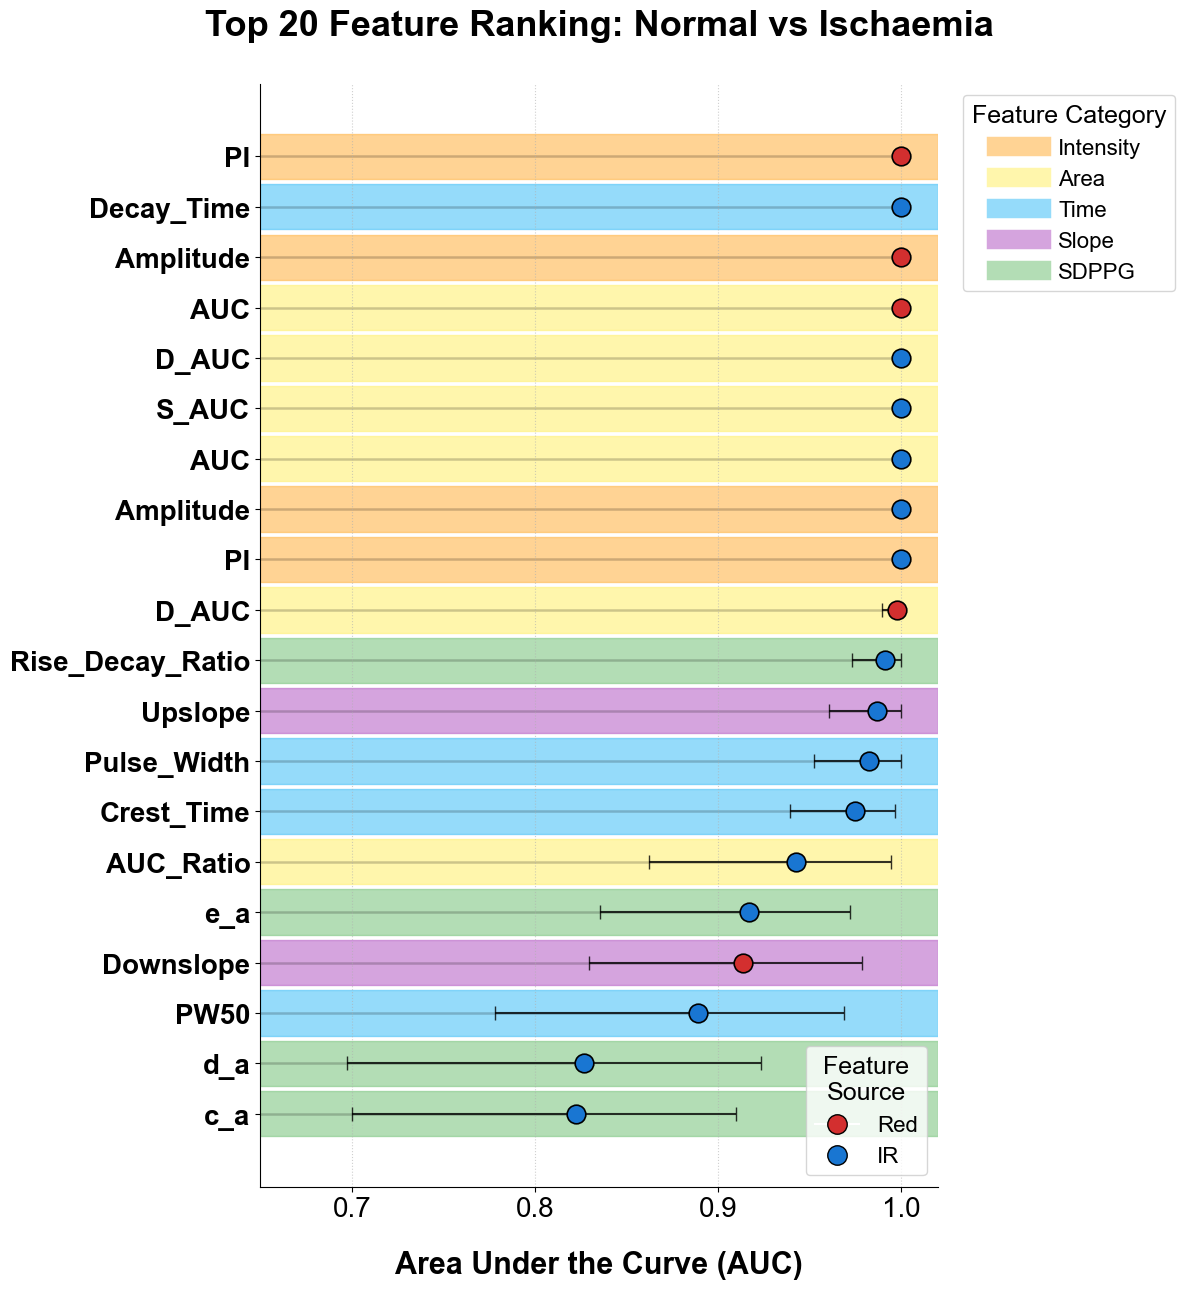

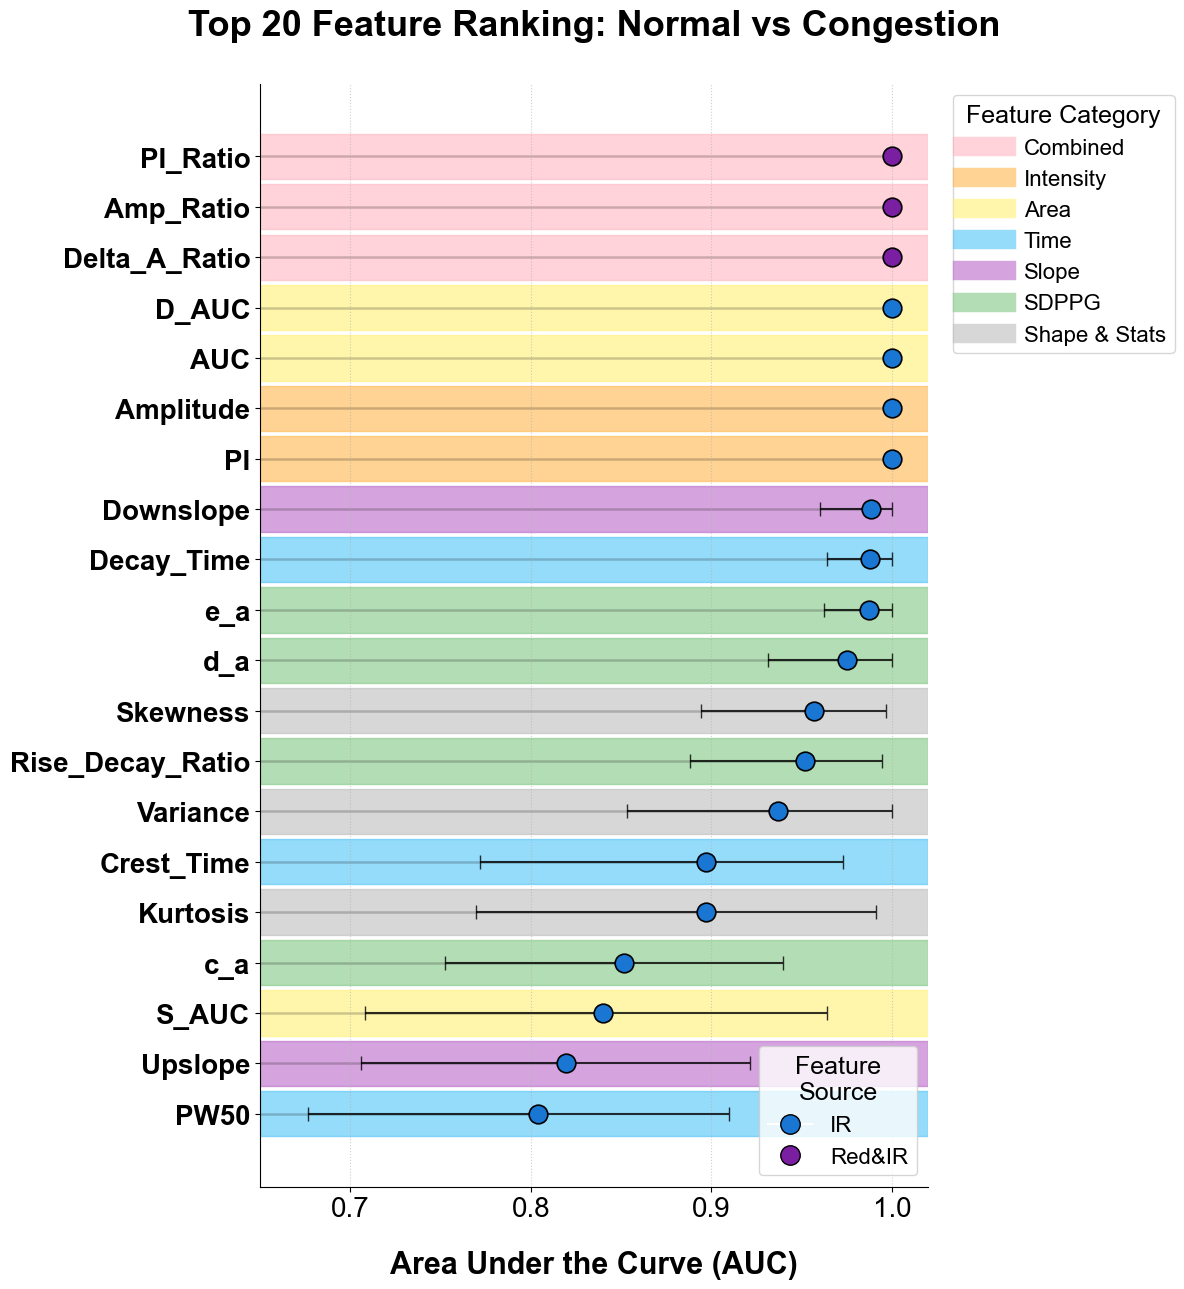

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D

# フォントをArialに設定
plt.rcParams['font.family'] = 'Arial'

# --- カテゴリー分けの定義 ---
def get_category(feat_name):
    name = feat_name.lower()
    if 'combined' in name: return 'Combined' # (2-λ)を削除
    if 'pi' in name or 'amplitude' in name or 'max_start' in name: return 'Intensity'
    if 'auc' in name or 'area' in name: return 'Area'
    if 'time' in name or 'width' in name or 'pw50' in name or 'delta_t' in name: return 'Time'
    if 'slope' in name: return 'Slope'
    if any(x in name for x in ['_a', '_b', '_c', '_d', '_e', 'dnp']): return 'SDPPG'
    if 'skewness' in name or 'kurtosis' in name or 'variance' in name or 'ratio' in name or 'rwi' in name: return 'Shape & Stats'
    return 'Other'

# --- 由来（Red, IR, Red&IR）の定義 ---
def get_source(feat_name):
    if 'Combined' in feat_name: return 'Red&IR'
    if 'Red_' in feat_name: return 'Red'
    if 'IR_' in feat_name: return 'IR'
    return 'Other'

# 表示用の特徴量名クリーンアップ関数
def clean_feature_name(name):
    return name.replace('Combined_', '').replace('IR_', '').replace('Red_', '')

# カテゴリー背景色
category_bg_colors = {
    'Combined': '#FFB6C1', 'Intensity': '#FFB74D', 'Area': '#FFF176',
    'Time': '#4FC3F7', 'Slope': '#BA68C8', 'SDPPG': '#81C784',
    'Shape & Stats': '#BDBDBD', 'Other': '#FFFFFF'
}

# サークル色
source_marker_colors = {
    'Red': '#D32F2F', 'IR': '#1976D2', 'Red&IR': '#7B1FA2', 'Other': '#424242'
}

def plot_final_ranking_top20_v4(csv_file, comparison_name):
    df = pd.read_csv(csv_file)
    df['Category'] = df['Feature'].apply(get_category)
    df['Source'] = df['Feature'].apply(get_source)
    df['Display_Name'] = df['Feature'].apply(clean_feature_name) # 表示名を作成
    
    # AUC順に上位20個抽出
    df = df.sort_values(by='AUC', ascending=True).tail(20).reset_index(drop=True) 
    
    n_features = len(df)
    plt.figure(figsize=(12, 13)) 
    ax = plt.gca()
    
    y_pos = np.arange(n_features)
    err_low = np.maximum(0, df['AUC'] - df['CI_Lower'])
    err_high = np.maximum(0, df['CI_Upper'] - df['AUC'])
    
    for i, row in df.iterrows():
        ax.axhspan(i - 0.45, i + 0.45, color=category_bg_colors.get(row['Category'], '#FFFFFF'), alpha=0.6, zorder=0)
        ax.hlines(y=i, xmin=0.65, xmax=row['AUC'], color='black', alpha=0.2, linewidth=1.8, zorder=1)
        ax.errorbar(row['AUC'], i, xerr=[[err_low[i]], [err_high[i]]], fmt='none', ecolor='black', capsize=5, alpha=0.8, zorder=2)
        ax.scatter(row['AUC'], i, color=source_marker_colors.get(row['Source'], '#424242'), s=180, edgecolors='black', linewidths=1.2, zorder=3)

    # 軸設定（クリーンアップした名前を使用）
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df['Display_Name'], fontsize=20, fontweight='bold') 
    ax.set_xlabel('Area Under the Curve (AUC)', fontsize=22, fontweight='bold', labelpad=20)
    
    # 横軸：0.65開始、0.1刻み
    ax.set_xlim(0.65, 1.02)
    ax.set_xticks([0.7, 0.8, 0.9, 1.0])
    ax.tick_params(axis='x', labelsize=20)
    
    ax.set_title(f'Top 20 Feature Ranking: Normal vs {comparison_name}', fontsize=26, fontweight='bold', pad=35)
    
    # 凡例1: Feature Source (中央揃え)
    source_labels = [s for s in ['Red', 'IR', 'Red&IR'] if s in df['Source'].unique()]
    marker_legend_elements = [Line2D([0], [0], marker='o', color='w', label=s,
                                     markerfacecolor=source_marker_colors[s], markersize=14, markeredgecolor='black')
                              for s in source_labels]
    leg1 = ax.legend(handles=marker_legend_elements, loc='lower right', title='Feature\nSource', 
                     fontsize=16, title_fontsize=18, frameon=True)
    leg1.get_title().set_multialignment('center') # 中央揃え
    ax.add_artist(leg1)
    
    # 凡例2: Feature Category
    category_labels = [cat for cat in category_bg_colors.keys() if cat in df['Category'].unique()]
    bg_legend_elements = [Line2D([0], [0], color=category_bg_colors[cat], lw=14, label=cat, alpha=0.6)
                          for cat in category_labels]
    ax.legend(handles=bg_legend_elements, loc='upper left', title='Feature Category', 
              fontsize=16, title_fontsize=18, frameon=True, bbox_to_anchor=(1.02, 1))
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# 実行
plot_final_ranking_top20_v4('ranking_table_Ischaemia.csv', 'Ischaemia')
plot_final_ranking_top20_v4('ranking_table_Congestion.csv', 'Congestion')


In [77]:
"""
Master Feature Extraction for IR-only Analysis (9mm & 15mm Depths)
==================================================================
Single-wavelength comprehensive feature extraction without Combined ratios
"""

import pandas as pd
import numpy as np
from scipy import signal, stats
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000
TARGET_DEPTH = 9  # ★ 9 または 15 に変更して実行
STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}
CHANNELS = {'ppgA_IR_raw': 'IR'}  # ★ IRのみ
OUTPUT_DIR = f'ir_analysis_{TARGET_DEPTH}mm'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'processing_log.txt')

def log_message(message):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# SIGNAL PROCESSING
# ========================================

def bandpass_filter(data, fs=2000):
    nyq = 0.5 * fs
    sos = signal.cheby2(4, 40, [0.5/nyq, 15.0/nyq], btype='band', output='sos')
    return signal.sosfiltfilt(sos, data)

def extract_all_ir_features(seg_raw, seg_filt, fs=2000):
    """
    IR単独チャンネルの全特徴量抽出（Combined不要）
    """
    f = {}
    
    # 0-1 Normalization for shape analysis
    seg_min, seg_max = np.min(seg_filt), np.max(seg_filt)
    seg_norm = (seg_filt - seg_min) / (seg_max - seg_min + 1e-10)
    
    t = np.arange(len(seg_norm)) / fs
    s_peak_idx = np.argmax(seg_norm)
    total_len = len(seg_norm)

    # --- 1. Intensity / Amplitude (Raw Scale) ---
    f['PI'] = ((seg_max - seg_min) / (np.mean(seg_raw) + 1e-10)) * 100
    f['Amplitude'] = seg_max - seg_min
    
    # --- 2. Area Features ---
    baseline = np.linspace(seg_filt[0], seg_filt[-1], total_len)
    sig_bc = seg_filt - baseline
    f['AUC'] = np.trapz(sig_bc)
    f['S_AUC'] = np.trapz(sig_bc[:s_peak_idx+1])
    f['D_AUC'] = np.trapz(sig_bc[s_peak_idx:])
    f['AUC_Ratio'] = f['S_AUC'] / (f['D_AUC'] + 1e-10)
    
    q = len(sig_bc) // 4
    f['Start_Datum_Area'] = np.trapz(sig_bc[:q])
    f['End_Datum_Area'] = np.trapz(sig_bc[-q:])
    f['Datum_Area_Ratio'] = f['Start_Datum_Area'] / (f['End_Datum_Area'] + 1e-10)
    f['Max_Start_Datum_Diff'] = np.max(sig_bc[:q]) if q > 0 else 0
    
    # --- 3. Timing / Width Features ---
    f['Crest_Time'] = s_peak_idx / fs
    f['Decay_Time'] = (total_len - s_peak_idx) / fs
    f['Pulse_Width'] = total_len / fs
    above_50 = np.where(seg_norm >= 0.5)[0]
    f['PW50'] = (above_50[-1] - above_50[0]) / fs if len(above_50) > 0 else 0
    f['Rise_Decay_Ratio'] = f['Crest_Time'] / (f['Decay_Time'] + 1e-10)
    
    # Systolic/Diastolic Width (Notch推定: 70%位置)
    notch_idx = int(s_peak_idx + 0.3 * (total_len - s_peak_idx))
    f['Systolic_Width'] = notch_idx / fs
    f['Diastolic_Width'] = (total_len - notch_idx) / fs
    f['Width_Ratio'] = f['Systolic_Width'] / (f['Diastolic_Width'] + 1e-10)

    # --- 4. Slope & Derivatives ---
    norm_grad = np.gradient(seg_norm, t)
    f['Upslope'] = np.max(norm_grad)
    f['Downslope'] = np.min(norm_grad)
    f['Slope_Ratio'] = f['Upslope'] / (abs(f['Downslope']) + 1e-10)
    
    # VPG (1st derivative) - Delta_T
    vpg = norm_grad
    zero_crossings = np.where(np.diff(np.sign(vpg[:s_peak_idx])))[0]
    f['Delta_T'] = (zero_crossings[0] / fs) if len(zero_crossings) > 0 else 0
    
    # APG (2nd derivative) - SDPPG indices
    apg = np.gradient(vpg, t)
    
    # 各時間帯からピーク・谷を検出（Takazawa方式）
    a_wave = np.max(apg[:int(0.2*fs)]) if len(apg) > int(0.2*fs) else 1e-10
    
    try:
        b_idx_start, b_idx_end = int(0.05*fs), int(0.15*fs)
        c_idx_start, c_idx_end = int(0.15*fs), int(0.25*fs)
        d_idx_start, d_idx_end = int(0.25*fs), int(0.35*fs)
        e_idx_start, e_idx_end = int(0.35*fs), int(0.50*fs)
        
        f['b_a'] = np.min(apg[b_idx_start:b_idx_end]) / (a_wave + 1e-10) if b_idx_end < len(apg) else 0
        f['c_a'] = np.max(apg[c_idx_start:c_idx_end]) / (a_wave + 1e-10) if c_idx_end < len(apg) else 0
        f['d_a'] = np.min(apg[d_idx_start:d_idx_end]) / (a_wave + 1e-10) if d_idx_end < len(apg) else 0
        f['e_a'] = np.max(apg[e_idx_start:e_idx_end]) / (a_wave + 1e-10) if e_idx_end < len(apg) else 0
    except:
        f['b_a'] = f['c_a'] = f['d_a'] = f['e_a'] = 0
    
    # DNP (Dicrotic Notch Prominence) - 2次微分の最小値の深さ
    search_start = s_peak_idx + int(0.1 * fs)
    if search_start < len(seg_norm) - 10:
        apg_dia = apg[search_start:]
        notch_local_idx = np.argmin(apg_dia)
        f['DNP'] = abs(apg_dia[notch_local_idx])
    else:
        f['DNP'] = 0
    
    # RWI (Reflected Wave Index) - Diastolic Peak / Systolic Peak
    if search_start < len(seg_norm) - 10:
        diastolic_seg = seg_norm[search_start:]
        d_peak_local_idx = np.argmax(diastolic_seg)
        f['RWI'] = diastolic_seg[d_peak_local_idx]
    else:
        f['RWI'] = 0

    # --- 5. Statistical Features ---
    f['Skewness'] = stats.skew(seg_norm)
    f['Kurtosis'] = stats.kurtosis(seg_norm)
    f['Variance'] = np.var(seg_norm)
    
    return f

# ========================================
# MAIN
# ========================================

def main():
    log_message(f"=== IR-ONLY ANALYSIS START ({TARGET_DEPTH}mm) ===")
    master_data = []

    for state_code, state_name in STATE_MAP.items():
        fname = f'{TARGET_DEPTH}mm_data{state_code}.csv'
        if not os.path.exists(fname):
            log_message(f"File not found: {fname}")
            continue
        
        df_raw = pd.read_csv(fname)
        
        for raw_col, ch_name in CHANNELS.items():
            if raw_col not in df_raw.columns:
                log_message(f"Column {raw_col} not found in {fname}")
                continue
            
            raw_sig = df_raw[raw_col].values[:int(30*FS)]
            filt_sig = bandpass_filter(raw_sig, FS)
            troughs, _ = signal.find_peaks(-filt_sig, distance=int(FS*0.6))
            
            pulse_count = 0
            for i in range(len(troughs)-1):
                idx1, idx2 = troughs[i], troughs[i+1]
                if idx2 - idx1 < FS * 0.4:  # 最低0.4秒のパルス長
                    continue
                
                feat = extract_all_ir_features(raw_sig[idx1:idx2], filt_sig[idx1:idx2], FS)
                feat.update({
                    'State': state_name,
                    'Channel': ch_name,
                    'Pulse_Index': i
                })
                master_data.append(feat)
                pulse_count += 1
            
            log_message(f"  {state_name} - {ch_name}: Extracted {pulse_count} pulses")
    
    # Save master CSV
    if master_data:
        df_master = pd.DataFrame(master_data)
        master_csv = os.path.join(OUTPUT_DIR, 'master_ir_features.csv')
        df_master.to_csv(master_csv, index=False)
        
        log_message(f"Saved: {master_csv}")
        log_message(f"Total pulses: {len(df_master)}")
        log_message(f"Total features: {len(df_master.columns) - 3}")  # State, Channel, Pulse_Index除く
        log_message("=== IR-ONLY ANALYSIS COMPLETE ===")
    else:
        log_message("ERROR: No pulses extracted. Check data files.")

if __name__ == "__main__":
    main()


[2026-01-26 13:11:24] === IR-ONLY ANALYSIS START (9mm) ===
[2026-01-26 13:11:24]   Normal - IR: Extracted 32 pulses
[2026-01-26 13:11:24]   Ischaemia - IR: Extracted 32 pulses
[2026-01-26 13:11:24]   Congestion - IR: Extracted 32 pulses
[2026-01-26 13:11:24] Saved: ir_analysis_9mm/master_ir_features.csv
[2026-01-26 13:11:24] Total pulses: 96
[2026-01-26 13:11:24] Total features: 31
[2026-01-26 13:11:24] === IR-ONLY ANALYSIS COMPLETE ===


In [78]:
"""
Feature Ranking Analysis for IR-only Data (9mm & 15mm)
=======================================================
AUC calculation with bootstrap CI for single-wavelength analysis
"""

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import os
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
TARGET_DEPTH = 9  # ★ 9 または 15 に変更
INPUT_DIR = f'ir_analysis_{TARGET_DEPTH}mm'
INPUT_FILE = os.path.join(INPUT_DIR, 'master_ir_features.csv')
OUTPUT_DIR = os.path.join(INPUT_DIR, 'ranking_results')
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'ranking_log.txt')

def log_message(message):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# ANALYSIS FUNCTIONS
# ========================================

def calculate_auc_with_ci(df, feature, state1, state2, n_bootstraps=500):
    """
    AUC値と95%信頼区間をブートストラップ法で計算
    """
    subset = df[df['State'].isin([state1, state2])].copy()
    
    y_true = (subset['State'] == state2).astype(int).values
    y_score = subset[feature].values
    
    # NaN/Inf除去
    valid_mask = np.isfinite(y_score)
    y_true = y_true[valid_mask]
    y_score = y_score[valid_mask]
    
    if len(np.unique(y_true)) < 2:
        log_message(f"  [SKIP] {feature}: Only one class present")
        return np.nan, (np.nan, np.nan)
    
    try:
        base_auc = roc_auc_score(y_true, y_score)
        effective_auc = max(base_auc, 1 - base_auc)
    except:
        log_message(f"  [ERROR] {feature}: AUC calculation failed")
        return np.nan, (np.nan, np.nan)
    
    # Bootstrap
    bootstrapped_scores = []
    n_samples = len(y_true)
    
    for _ in range(n_bootstraps):
        indices = np.random.randint(0, n_samples, n_samples)
        if len(np.unique(y_true[indices])) < 2:
            continue
        score = roc_auc_score(y_true[indices], y_score[indices])
        bootstrapped_scores.append(max(score, 1 - score))
    
    if len(bootstrapped_scores) < 10:
        return effective_auc, (np.nan, np.nan)
    
    sorted_scores = np.sort(bootstrapped_scores)
    ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
    ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]
    
    return effective_auc, (ci_lower, ci_upper)

# ========================================
# MAIN
# ========================================

def main():
    log_message(f"=== RANKING ANALYSIS START ({TARGET_DEPTH}mm IR-only) ===")
    
    if not os.path.exists(INPUT_FILE):
        log_message(f"ERROR: {INPUT_FILE} not found")
        return
    
    df = pd.read_csv(INPUT_FILE)
    features = [c for c in df.columns if c not in ['State', 'Channel', 'Pulse_Index']]
    
    log_message(f"Loaded {len(df)} pulses with {len(features)} features")
    
    comparisons = [('Normal', 'Ischaemia'), ('Normal', 'Congestion')]
    
    for s1, s2 in comparisons:
        log_message(f"\n--- Comparison: {s1} vs {s2} ---")
        results = []
        
        for feat in features:
            auc_val, (ci_l, ci_u) = calculate_auc_with_ci(df, feat, s1, s2)
            
            if not np.isnan(auc_val):
                results.append({
                    'Feature': feat,
                    'AUC': auc_val,
                    'CI_Lower': ci_l,
                    'CI_Upper': ci_u
                })
        
        # Sort and save
        ranking_df = pd.DataFrame(results).sort_values('AUC', ascending=False)
        ranking_csv = os.path.join(OUTPUT_DIR, f'ranking_table_{s2}.csv')
        ranking_df.to_csv(ranking_csv, index=False)
        
        log_message(f"Saved: {ranking_csv}")
        log_message(f"Top 5 features:")
        for idx, row in ranking_df.head(5).iterrows():
            log_message(f"  {idx+1}. {row['Feature']}: AUC={row['AUC']:.4f}")
    
    log_message("\n=== RANKING ANALYSIS COMPLETE ===")

if __name__ == "__main__":
    main()


[2026-01-26 13:12:01] === RANKING ANALYSIS START (9mm IR-only) ===
[2026-01-26 13:12:01] Loaded 96 pulses with 31 features
[2026-01-26 13:12:01] 
--- Comparison: Normal vs Ischaemia ---
[2026-01-26 13:12:16] Saved: ir_analysis_9mm/ranking_results/ranking_table_Ischaemia.csv
[2026-01-26 13:12:16] Top 5 features:
[2026-01-26 13:12:16]   1. PI: AUC=0.9990
[2026-01-26 13:12:16]   2. Amplitude: AUC=0.9990
[2026-01-26 13:12:16]   4. S_AUC: AUC=0.9844
[2026-01-26 13:12:16]   27. DNP: AUC=0.9775
[2026-01-26 13:12:16]   18. Width_Ratio: AUC=0.9766
[2026-01-26 13:12:16] 
--- Comparison: Normal vs Congestion ---
[2026-01-26 13:12:28] Saved: ir_analysis_9mm/ranking_results/ranking_table_Congestion.csv
[2026-01-26 13:12:28] Top 5 features:
[2026-01-26 13:12:28]   2. Amplitude: AUC=0.9395
[2026-01-26 13:12:28]   5. D_AUC: AUC=0.9385
[2026-01-26 13:12:28]   7. Start_Datum_Area: AUC=0.9385
[2026-01-26 13:12:28]   10. Max_Start_Datum_Diff: AUC=0.9355
[2026-01-26 13:12:28]   1. PI: AUC=0.9346
[2026-01-2

In [79]:
"""
IR-only Top 20 Feature Ranking Visualization (9mm & 15mm)
==========================================================
No Combined features, only IR-derived parameters
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'Arial'

# ========================================
# CONFIGURATION
# ========================================
TARGET_DEPTH = 9  # ★ 9 または 15 に変更
INPUT_DIR = f'ir_analysis_{TARGET_DEPTH}mm/ranking_results'

# ========================================
# CATEGORY & COLOR DEFINITIONS
# ========================================

def get_category(feat_name):
    """
    特徴量のカテゴリー分類（Combined除外）
    """
    name = feat_name.lower()
    if 'pi' in name or 'amplitude' in name or 'max_start' in name:
        return 'Intensity'
    if 'auc' in name or 'area' in name:
        return 'Area'
    if 'time' in name or 'width' in name or 'pw50' in name or 'delta_t' in name:
        return 'Time'
    if 'slope' in name:
        return 'Slope'
    if any(x in name for x in ['_a', '_b', '_c', '_d', '_e', 'dnp', 'rwi']):
        return 'SDPPG'
    if 'skewness' in name or 'kurtosis' in name or 'variance' in name or 'ratio' in name:
        return 'Shape & Stats'
    return 'Other'

# カテゴリー背景色（Combinedを削除）
category_bg_colors = {
    'Intensity': '#FFB74D',
    'Area': '#FFF176',
    'Time': '#4FC3F7',
    'Slope': '#BA68C8',
    'SDPPG': '#81C784',
    'Shape & Stats': '#BDBDBD',
    'Other': '#FFFFFF'
}

# IRは単一色
ir_marker_color = '#1976D2'  # Blue

# ========================================
# VISUALIZATION FUNCTION
# ========================================

def plot_ir_ranking_top20(csv_file, comparison_name):
    """
    IR専用Top20ランキング可視化
    """
    df = pd.read_csv(csv_file)
    df['Category'] = df['Feature'].apply(get_category)
    
    # AUC順に上位20個抽出
    df = df.sort_values(by='AUC', ascending=True).tail(20).reset_index(drop=True)
    
    n_features = len(df)
    plt.figure(figsize=(12, 13))
    ax = plt.gca()
    
    y_pos = np.arange(n_features)
    err_low = np.maximum(0, df['AUC'] - df['CI_Lower'])
    err_high = np.maximum(0, df['CI_Upper'] - df['AUC'])
    
    # 背景色 + プロット
    for i, row in df.iterrows():
        ax.axhspan(i - 0.45, i + 0.45, 
                   color=category_bg_colors.get(row['Category'], '#FFFFFF'), 
                   alpha=0.6, zorder=0)
        ax.hlines(y=i, xmin=0.65, xmax=row['AUC'], 
                  color='black', alpha=0.2, linewidth=1.8, zorder=1)
        ax.errorbar(row['AUC'], i, 
                    xerr=[[err_low[i]], [err_high[i]]], 
                    fmt='none', ecolor='black', capsize=5, alpha=0.8, zorder=2)
        ax.scatter(row['AUC'], i, 
                   color=ir_marker_color, s=180, 
                   edgecolors='black', linewidths=1.2, zorder=3)
    
    # 軸設定
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df['Feature'], fontsize=20, fontweight='bold')
    ax.set_xlabel('Area Under the Curve (AUC)', fontsize=22, fontweight='bold', labelpad=20)
    ax.set_xlim(0.65, 1.02)
    ax.set_xticks([0.7, 0.8, 0.9, 1.0])
    ax.tick_params(axis='x', labelsize=20)
    
    ax.set_title(f'Top 20 IR Feature Ranking ({TARGET_DEPTH}mm): Normal vs {comparison_name}', 
                 fontsize=26, fontweight='bold', pad=35)
    
    # 凡例: Feature Category（Combinedなし）
    category_labels = [cat for cat in category_bg_colors.keys() if cat in df['Category'].unique()]
    bg_legend_elements = [Line2D([0], [0], color=category_bg_colors[cat], 
                                 lw=14, label=cat, alpha=0.6)
                          for cat in category_labels]
    ax.legend(handles=bg_legend_elements, loc='upper left', 
              title='Feature Category', fontsize=16, title_fontsize=18, 
              frameon=True, bbox_to_anchor=(1.02, 1))
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    
    # 保存
    output_file = os.path.join(INPUT_DIR, f'ranking_plot_{comparison_name}_{TARGET_DEPTH}mm.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved: {output_file}")

# ========================================
# MAIN
# ========================================

def main():
    comparisons = ['Ischaemia', 'Congestion']
    
    for comp in comparisons:
        csv_file = os.path.join(INPUT_DIR, f'ranking_table_{comp}.csv')
        if os.path.exists(csv_file):
            plot_ir_ranking_top20(csv_file, comp)
        else:
            print(f"File not found: {csv_file}")

if __name__ == "__main__":
    main()


Saved: ir_analysis_9mm/ranking_results/ranking_plot_Ischaemia_9mm.png
Saved: ir_analysis_9mm/ranking_results/ranking_plot_Congestion_9mm.png


In [80]:
"""
Master Feature Extraction for IR-only Analysis (9mm & 15mm Depths)
==================================================================
Single-wavelength comprehensive feature extraction without Combined ratios
"""

import pandas as pd
import numpy as np
from scipy import signal, stats
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000
TARGET_DEPTH = 15  # ★ 9 または 15 に変更して実行
STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}
CHANNELS = {'ppgA_IR_raw': 'IR'}  # ★ IRのみ
OUTPUT_DIR = f'ir_analysis_{TARGET_DEPTH}mm'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'processing_log.txt')

def log_message(message):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# SIGNAL PROCESSING
# ========================================

def bandpass_filter(data, fs=2000):
    nyq = 0.5 * fs
    sos = signal.cheby2(4, 40, [0.5/nyq, 15.0/nyq], btype='band', output='sos')
    return signal.sosfiltfilt(sos, data)

def extract_all_ir_features(seg_raw, seg_filt, fs=2000):
    """
    IR単独チャンネルの全特徴量抽出（Combined不要）
    """
    f = {}
    
    # 0-1 Normalization for shape analysis
    seg_min, seg_max = np.min(seg_filt), np.max(seg_filt)
    seg_norm = (seg_filt - seg_min) / (seg_max - seg_min + 1e-10)
    
    t = np.arange(len(seg_norm)) / fs
    s_peak_idx = np.argmax(seg_norm)
    total_len = len(seg_norm)

    # --- 1. Intensity / Amplitude (Raw Scale) ---
    f['PI'] = ((seg_max - seg_min) / (np.mean(seg_raw) + 1e-10)) * 100
    f['Amplitude'] = seg_max - seg_min
    
    # --- 2. Area Features ---
    baseline = np.linspace(seg_filt[0], seg_filt[-1], total_len)
    sig_bc = seg_filt - baseline
    f['AUC'] = np.trapz(sig_bc)
    f['S_AUC'] = np.trapz(sig_bc[:s_peak_idx+1])
    f['D_AUC'] = np.trapz(sig_bc[s_peak_idx:])
    f['AUC_Ratio'] = f['S_AUC'] / (f['D_AUC'] + 1e-10)
    
    q = len(sig_bc) // 4
    f['Start_Datum_Area'] = np.trapz(sig_bc[:q])
    f['End_Datum_Area'] = np.trapz(sig_bc[-q:])
    f['Datum_Area_Ratio'] = f['Start_Datum_Area'] / (f['End_Datum_Area'] + 1e-10)
    f['Max_Start_Datum_Diff'] = np.max(sig_bc[:q]) if q > 0 else 0
    
    # --- 3. Timing / Width Features ---
    f['Crest_Time'] = s_peak_idx / fs
    f['Decay_Time'] = (total_len - s_peak_idx) / fs
    f['Pulse_Width'] = total_len / fs
    above_50 = np.where(seg_norm >= 0.5)[0]
    f['PW50'] = (above_50[-1] - above_50[0]) / fs if len(above_50) > 0 else 0
    f['Rise_Decay_Ratio'] = f['Crest_Time'] / (f['Decay_Time'] + 1e-10)
    
    # Systolic/Diastolic Width (Notch推定: 70%位置)
    notch_idx = int(s_peak_idx + 0.3 * (total_len - s_peak_idx))
    f['Systolic_Width'] = notch_idx / fs
    f['Diastolic_Width'] = (total_len - notch_idx) / fs
    f['Width_Ratio'] = f['Systolic_Width'] / (f['Diastolic_Width'] + 1e-10)

    # --- 4. Slope & Derivatives ---
    norm_grad = np.gradient(seg_norm, t)
    f['Upslope'] = np.max(norm_grad)
    f['Downslope'] = np.min(norm_grad)
    f['Slope_Ratio'] = f['Upslope'] / (abs(f['Downslope']) + 1e-10)
    
    # VPG (1st derivative) - Delta_T
    vpg = norm_grad
    zero_crossings = np.where(np.diff(np.sign(vpg[:s_peak_idx])))[0]
    f['Delta_T'] = (zero_crossings[0] / fs) if len(zero_crossings) > 0 else 0
    
    # APG (2nd derivative) - SDPPG indices
    apg = np.gradient(vpg, t)
    
    # 各時間帯からピーク・谷を検出（Takazawa方式）
    a_wave = np.max(apg[:int(0.2*fs)]) if len(apg) > int(0.2*fs) else 1e-10
    
    try:
        b_idx_start, b_idx_end = int(0.05*fs), int(0.15*fs)
        c_idx_start, c_idx_end = int(0.15*fs), int(0.25*fs)
        d_idx_start, d_idx_end = int(0.25*fs), int(0.35*fs)
        e_idx_start, e_idx_end = int(0.35*fs), int(0.50*fs)
        
        f['b_a'] = np.min(apg[b_idx_start:b_idx_end]) / (a_wave + 1e-10) if b_idx_end < len(apg) else 0
        f['c_a'] = np.max(apg[c_idx_start:c_idx_end]) / (a_wave + 1e-10) if c_idx_end < len(apg) else 0
        f['d_a'] = np.min(apg[d_idx_start:d_idx_end]) / (a_wave + 1e-10) if d_idx_end < len(apg) else 0
        f['e_a'] = np.max(apg[e_idx_start:e_idx_end]) / (a_wave + 1e-10) if e_idx_end < len(apg) else 0
    except:
        f['b_a'] = f['c_a'] = f['d_a'] = f['e_a'] = 0
    
    # DNP (Dicrotic Notch Prominence) - 2次微分の最小値の深さ
    search_start = s_peak_idx + int(0.1 * fs)
    if search_start < len(seg_norm) - 10:
        apg_dia = apg[search_start:]
        notch_local_idx = np.argmin(apg_dia)
        f['DNP'] = abs(apg_dia[notch_local_idx])
    else:
        f['DNP'] = 0
    
    # RWI (Reflected Wave Index) - Diastolic Peak / Systolic Peak
    if search_start < len(seg_norm) - 10:
        diastolic_seg = seg_norm[search_start:]
        d_peak_local_idx = np.argmax(diastolic_seg)
        f['RWI'] = diastolic_seg[d_peak_local_idx]
    else:
        f['RWI'] = 0

    # --- 5. Statistical Features ---
    f['Skewness'] = stats.skew(seg_norm)
    f['Kurtosis'] = stats.kurtosis(seg_norm)
    f['Variance'] = np.var(seg_norm)
    
    return f

# ========================================
# MAIN
# ========================================

def main():
    log_message(f"=== IR-ONLY ANALYSIS START ({TARGET_DEPTH}mm) ===")
    master_data = []

    for state_code, state_name in STATE_MAP.items():
        fname = f'{TARGET_DEPTH}mm_data{state_code}.csv'
        if not os.path.exists(fname):
            log_message(f"File not found: {fname}")
            continue
        
        df_raw = pd.read_csv(fname)
        
        for raw_col, ch_name in CHANNELS.items():
            if raw_col not in df_raw.columns:
                log_message(f"Column {raw_col} not found in {fname}")
                continue
            
            raw_sig = df_raw[raw_col].values[:int(30*FS)]
            filt_sig = bandpass_filter(raw_sig, FS)
            troughs, _ = signal.find_peaks(-filt_sig, distance=int(FS*0.6))
            
            pulse_count = 0
            for i in range(len(troughs)-1):
                idx1, idx2 = troughs[i], troughs[i+1]
                if idx2 - idx1 < FS * 0.4:  # 最低0.4秒のパルス長
                    continue
                
                feat = extract_all_ir_features(raw_sig[idx1:idx2], filt_sig[idx1:idx2], FS)
                feat.update({
                    'State': state_name,
                    'Channel': ch_name,
                    'Pulse_Index': i
                })
                master_data.append(feat)
                pulse_count += 1
            
            log_message(f"  {state_name} - {ch_name}: Extracted {pulse_count} pulses")
    
    # Save master CSV
    if master_data:
        df_master = pd.DataFrame(master_data)
        master_csv = os.path.join(OUTPUT_DIR, 'master_ir_features.csv')
        df_master.to_csv(master_csv, index=False)
        
        log_message(f"Saved: {master_csv}")
        log_message(f"Total pulses: {len(df_master)}")
        log_message(f"Total features: {len(df_master.columns) - 3}")  # State, Channel, Pulse_Index除く
        log_message("=== IR-ONLY ANALYSIS COMPLETE ===")
    else:
        log_message("ERROR: No pulses extracted. Check data files.")

if __name__ == "__main__":
    main()


[2026-01-26 13:13:23] === IR-ONLY ANALYSIS START (15mm) ===
[2026-01-26 13:13:25]   Normal - IR: Extracted 31 pulses
[2026-01-26 13:13:26]   Ischaemia - IR: Extracted 30 pulses
[2026-01-26 13:13:26]   Congestion - IR: Extracted 31 pulses
[2026-01-26 13:13:26] Saved: ir_analysis_15mm/master_ir_features.csv
[2026-01-26 13:13:26] Total pulses: 92
[2026-01-26 13:13:26] Total features: 31
[2026-01-26 13:13:26] === IR-ONLY ANALYSIS COMPLETE ===


In [81]:
"""
Feature Ranking Analysis for IR-only Data (9mm & 15mm)
=======================================================
AUC calculation with bootstrap CI for single-wavelength analysis
"""

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import os
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
TARGET_DEPTH = 15  # ★ 9 または 15 に変更
INPUT_DIR = f'ir_analysis_{TARGET_DEPTH}mm'
INPUT_FILE = os.path.join(INPUT_DIR, 'master_ir_features.csv')
OUTPUT_DIR = os.path.join(INPUT_DIR, 'ranking_results')
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'ranking_log.txt')

def log_message(message):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# ANALYSIS FUNCTIONS
# ========================================

def calculate_auc_with_ci(df, feature, state1, state2, n_bootstraps=500):
    """
    AUC値と95%信頼区間をブートストラップ法で計算
    """
    subset = df[df['State'].isin([state1, state2])].copy()
    
    y_true = (subset['State'] == state2).astype(int).values
    y_score = subset[feature].values
    
    # NaN/Inf除去
    valid_mask = np.isfinite(y_score)
    y_true = y_true[valid_mask]
    y_score = y_score[valid_mask]
    
    if len(np.unique(y_true)) < 2:
        log_message(f"  [SKIP] {feature}: Only one class present")
        return np.nan, (np.nan, np.nan)
    
    try:
        base_auc = roc_auc_score(y_true, y_score)
        effective_auc = max(base_auc, 1 - base_auc)
    except:
        log_message(f"  [ERROR] {feature}: AUC calculation failed")
        return np.nan, (np.nan, np.nan)
    
    # Bootstrap
    bootstrapped_scores = []
    n_samples = len(y_true)
    
    for _ in range(n_bootstraps):
        indices = np.random.randint(0, n_samples, n_samples)
        if len(np.unique(y_true[indices])) < 2:
            continue
        score = roc_auc_score(y_true[indices], y_score[indices])
        bootstrapped_scores.append(max(score, 1 - score))
    
    if len(bootstrapped_scores) < 10:
        return effective_auc, (np.nan, np.nan)
    
    sorted_scores = np.sort(bootstrapped_scores)
    ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
    ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]
    
    return effective_auc, (ci_lower, ci_upper)

# ========================================
# MAIN
# ========================================

def main():
    log_message(f"=== RANKING ANALYSIS START ({TARGET_DEPTH}mm IR-only) ===")
    
    if not os.path.exists(INPUT_FILE):
        log_message(f"ERROR: {INPUT_FILE} not found")
        return
    
    df = pd.read_csv(INPUT_FILE)
    features = [c for c in df.columns if c not in ['State', 'Channel', 'Pulse_Index']]
    
    log_message(f"Loaded {len(df)} pulses with {len(features)} features")
    
    comparisons = [('Normal', 'Ischaemia'), ('Normal', 'Congestion')]
    
    for s1, s2 in comparisons:
        log_message(f"\n--- Comparison: {s1} vs {s2} ---")
        results = []
        
        for feat in features:
            auc_val, (ci_l, ci_u) = calculate_auc_with_ci(df, feat, s1, s2)
            
            if not np.isnan(auc_val):
                results.append({
                    'Feature': feat,
                    'AUC': auc_val,
                    'CI_Lower': ci_l,
                    'CI_Upper': ci_u
                })
        
        # Sort and save
        ranking_df = pd.DataFrame(results).sort_values('AUC', ascending=False)
        ranking_csv = os.path.join(OUTPUT_DIR, f'ranking_table_{s2}.csv')
        ranking_df.to_csv(ranking_csv, index=False)
        
        log_message(f"Saved: {ranking_csv}")
        log_message(f"Top 5 features:")
        for idx, row in ranking_df.head(5).iterrows():
            log_message(f"  {idx+1}. {row['Feature']}: AUC={row['AUC']:.4f}")
    
    log_message("\n=== RANKING ANALYSIS COMPLETE ===")

if __name__ == "__main__":
    main()


[2026-01-26 13:13:46] === RANKING ANALYSIS START (15mm IR-only) ===
[2026-01-26 13:13:46] Loaded 92 pulses with 31 features
[2026-01-26 13:13:46] 
--- Comparison: Normal vs Ischaemia ---
[2026-01-26 13:14:08] Saved: ir_analysis_15mm/ranking_results/ranking_table_Ischaemia.csv
[2026-01-26 13:14:08] Top 5 features:
[2026-01-26 13:14:08]   1. PI: AUC=0.9903
[2026-01-26 13:14:08]   2. Amplitude: AUC=0.9903
[2026-01-26 13:14:08]   27. DNP: AUC=0.9731
[2026-01-26 13:14:08]   10. Max_Start_Datum_Diff: AUC=0.9677
[2026-01-26 13:14:08]   4. S_AUC: AUC=0.9602
[2026-01-26 13:14:08] 
--- Comparison: Normal vs Congestion ---
[2026-01-26 13:14:18] Saved: ir_analysis_15mm/ranking_results/ranking_table_Congestion.csv
[2026-01-26 13:14:18] Top 5 features:
[2026-01-26 13:14:18]   1. PI: AUC=0.9688
[2026-01-26 13:14:18]   2. Amplitude: AUC=0.9688
[2026-01-26 13:14:18]   10. Max_Start_Datum_Diff: AUC=0.9563
[2026-01-26 13:14:18]   3. AUC: AUC=0.9396
[2026-01-26 13:14:18]   27. DNP: AUC=0.9334
[2026-01-26 

In [82]:
"""
IR-only Top 20 Feature Ranking Visualization (9mm & 15mm)
==========================================================
No Combined features, only IR-derived parameters
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'Arial'

# ========================================
# CONFIGURATION
# ========================================
TARGET_DEPTH = 15  # ★ 9 または 15 に変更
INPUT_DIR = f'ir_analysis_{TARGET_DEPTH}mm/ranking_results'

# ========================================
# CATEGORY & COLOR DEFINITIONS
# ========================================

def get_category(feat_name):
    """
    特徴量のカテゴリー分類（Combined除外）
    """
    name = feat_name.lower()
    if 'pi' in name or 'amplitude' in name or 'max_start' in name:
        return 'Intensity'
    if 'auc' in name or 'area' in name:
        return 'Area'
    if 'time' in name or 'width' in name or 'pw50' in name or 'delta_t' in name:
        return 'Time'
    if 'slope' in name:
        return 'Slope'
    if any(x in name for x in ['_a', '_b', '_c', '_d', '_e', 'dnp', 'rwi']):
        return 'SDPPG'
    if 'skewness' in name or 'kurtosis' in name or 'variance' in name or 'ratio' in name:
        return 'Shape & Stats'
    return 'Other'

# カテゴリー背景色（Combinedを削除）
category_bg_colors = {
    'Intensity': '#FFB74D',
    'Area': '#FFF176',
    'Time': '#4FC3F7',
    'Slope': '#BA68C8',
    'SDPPG': '#81C784',
    'Shape & Stats': '#BDBDBD',
    'Other': '#FFFFFF'
}

# IRは単一色
ir_marker_color = '#1976D2'  # Blue

# ========================================
# VISUALIZATION FUNCTION
# ========================================

def plot_ir_ranking_top20(csv_file, comparison_name):
    """
    IR専用Top20ランキング可視化
    """
    df = pd.read_csv(csv_file)
    df['Category'] = df['Feature'].apply(get_category)
    
    # AUC順に上位20個抽出
    df = df.sort_values(by='AUC', ascending=True).tail(20).reset_index(drop=True)
    
    n_features = len(df)
    plt.figure(figsize=(12, 13))
    ax = plt.gca()
    
    y_pos = np.arange(n_features)
    err_low = np.maximum(0, df['AUC'] - df['CI_Lower'])
    err_high = np.maximum(0, df['CI_Upper'] - df['AUC'])
    
    # 背景色 + プロット
    for i, row in df.iterrows():
        ax.axhspan(i - 0.45, i + 0.45, 
                   color=category_bg_colors.get(row['Category'], '#FFFFFF'), 
                   alpha=0.6, zorder=0)
        ax.hlines(y=i, xmin=0.65, xmax=row['AUC'], 
                  color='black', alpha=0.2, linewidth=1.8, zorder=1)
        ax.errorbar(row['AUC'], i, 
                    xerr=[[err_low[i]], [err_high[i]]], 
                    fmt='none', ecolor='black', capsize=5, alpha=0.8, zorder=2)
        ax.scatter(row['AUC'], i, 
                   color=ir_marker_color, s=180, 
                   edgecolors='black', linewidths=1.2, zorder=3)
    
    # 軸設定
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df['Feature'], fontsize=20, fontweight='bold')
    ax.set_xlabel('Area Under the Curve (AUC)', fontsize=22, fontweight='bold', labelpad=20)
    ax.set_xlim(0.65, 1.02)
    ax.set_xticks([0.7, 0.8, 0.9, 1.0])
    ax.tick_params(axis='x', labelsize=20)
    
    ax.set_title(f'Top 20 IR Feature Ranking ({TARGET_DEPTH}mm): Normal vs {comparison_name}', 
                 fontsize=26, fontweight='bold', pad=35)
    
    # 凡例: Feature Category（Combinedなし）
    category_labels = [cat for cat in category_bg_colors.keys() if cat in df['Category'].unique()]
    bg_legend_elements = [Line2D([0], [0], color=category_bg_colors[cat], 
                                 lw=14, label=cat, alpha=0.6)
                          for cat in category_labels]
    ax.legend(handles=bg_legend_elements, loc='upper left', 
              title='Feature Category', fontsize=16, title_fontsize=18, 
              frameon=True, bbox_to_anchor=(1.02, 1))
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    
    # 保存
    output_file = os.path.join(INPUT_DIR, f'ranking_plot_{comparison_name}_{TARGET_DEPTH}mm.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved: {output_file}")

# ========================================
# MAIN
# ========================================

def main():
    comparisons = ['Ischaemia', 'Congestion']
    
    for comp in comparisons:
        csv_file = os.path.join(INPUT_DIR, f'ranking_table_{comp}.csv')
        if os.path.exists(csv_file):
            plot_ir_ranking_top20(csv_file, comp)
        else:
            print(f"File not found: {csv_file}")

if __name__ == "__main__":
    main()


Saved: ir_analysis_15mm/ranking_results/ranking_plot_Ischaemia_15mm.png
Saved: ir_analysis_15mm/ranking_results/ranking_plot_Congestion_15mm.png


In [84]:
"""
Depth Comparison Visualization: IR Performance across 3mm, 9mm, 15mm (UPDATED)
==============================================================================
- Top 10 features per depth
- Dynamic X-axis range based on error bar minimum
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'Arial'

# ========================================
# CONFIGURATION
# ========================================
INPUT_DIR = '/Users/hirokikodama/Documents/GitHub/Phantom-analysis'  # CSVファイルが置かれているディレクトリ
OUTPUT_DIR = 'depth_comparison_charts'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEPTHS = [3, 9, 15]
COMPARISONS = ['Ischaemia', 'Congestion']

# カテゴリー定義（Combinedを除外）
def get_category(feat_name):
    """特徴量のカテゴリー分類"""
    name = feat_name.lower()
    if 'pi' in name or 'amplitude' in name or 'max_start' in name:
        return 'Intensity'
    if 'auc' in name or 'area' in name:
        return 'Area'
    if 'time' in name or 'width' in name or 'pw50' in name or 'delta_t' in name:
        return 'Time'
    if 'slope' in name:
        return 'Slope'
    if any(x in name for x in ['_a', '_b', '_c', '_d', '_e', 'dnp', 'rwi']):
        return 'SDPPG'
    if 'skewness' in name or 'kurtosis' in name or 'variance' in name or 'ratio' in name:
        return 'Shape & Stats'
    return 'Other'

# カテゴリー背景色
category_bg_colors = {
    'Intensity': '#FFB74D',
    'Area': '#FFF176',
    'Time': '#4FC3F7',
    'Slope': '#BA68C8',
    'SDPPG': '#81C784',
    'Shape & Stats': '#BDBDBD',
    'Other': '#FFFFFF'
}

# IRマーカー色（統一）
ir_marker_color = '#1976D2'

# ========================================
# DATA LOADING & PREPROCESSING
# ========================================

def load_and_filter_data(depth, comparison):
    """
    CSVファイルを読み込み、IR特徴量のみを抽出
    
    3mm: Combined/Red除外、IR_プレフィックス削除
    9mm/15mm: そのまま使用
    Top 10特徴量を抽出
    """
    filename = f'ranking_table_{comparison}_{depth}mm.csv'
    filepath = os.path.join(INPUT_DIR, filename)
    
    if not os.path.exists(filepath):
        print(f"Warning: {filepath} not found")
        return pd.DataFrame()
    
    df = pd.read_csv(filepath)
    
    # 3mmの場合、IR特徴量のみをフィルタリング
    if depth == 3:
        # Combined と Red を除外
        df = df[df['Feature'].str.startswith('IR_')].copy()
        # IR_プレフィックスを削除
        df['Display_Name'] = df['Feature'].str.replace('IR_', '', regex=False)
    else:
        # 9mm/15mmはそのまま
        df['Display_Name'] = df['Feature']
    
    # カテゴリー分類
    df['Category'] = df['Display_Name'].apply(get_category)
    
    # AUC降順でTop10を抽出 ★変更: Top20→Top10
    df = df.sort_values('AUC', ascending=False).head(10).reset_index(drop=True)
    # プロット用に昇順に並べ替え
    df = df.sort_values('AUC', ascending=True).reset_index(drop=True)
    
    return df

# ========================================
# VISUALIZATION
# ========================================

def plot_depth_comparison(comparison_name):
    """
    3つの深度を横並びで比較するチャートを作成
    各サブプロットの横軸範囲を動的に設定
    """
    fig, axes = plt.subplots(1, 3, figsize=(30, 10), sharey=False)  # ★高さ調整: 13→10
    
    # 各深度のデータをプロット
    all_categories = set()
    
    for idx, (ax, depth) in enumerate(zip(axes, DEPTHS)):
        df = load_and_filter_data(depth, comparison_name)
        
        if df.empty:
            ax.text(0.5, 0.5, f'No data\n({depth}mm)', 
                   ha='center', va='center', fontsize=20, color='red')
            ax.set_xlim(0.5, 1.02)
            continue
        
        n_features = len(df)
        y_pos = np.arange(n_features)
        
        # エラーバー計算
        err_low = np.maximum(0, df['AUC'] - df['CI_Lower'])
        err_high = np.maximum(0, df['CI_Upper'] - df['AUC'])
        
        # ★ X軸範囲の動的計算（エラーバーの最小値に基づく）
        # CI_Lowerの最小値を取得し、余裕を持たせる
        x_min_data = df['CI_Lower'].min()
        x_min = max(0.5, x_min_data - 0.05)  # 最低でも0.5、余裕0.05
        x_min = np.floor(x_min * 20) / 20  # 0.05刻みに丸める
        x_max = 1.02
        
        # カテゴリー背景色 + プロット
        for i, row in df.iterrows():
            cat = row['Category']
            all_categories.add(cat)
            
            ax.axhspan(i - 0.45, i + 0.45, 
                      color=category_bg_colors.get(cat, '#FFFFFF'), 
                      alpha=0.6, zorder=0)
            ax.hlines(y=i, xmin=x_min, xmax=row['AUC'], 
                     color='black', alpha=0.2, linewidth=1.8, zorder=1)
            ax.errorbar(row['AUC'], i, 
                       xerr=[[err_low.iloc[i]], [err_high.iloc[i]]], 
                       fmt='none', ecolor='black', capsize=5, alpha=0.8, zorder=2)
            ax.scatter(row['AUC'], i, 
                      color=ir_marker_color, s=180, 
                      edgecolors='black', linewidths=1.2, zorder=3)
        
        # Y軸設定（特徴量名）
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df['Display_Name'], fontsize=18, fontweight='bold')
        
        # ★ X軸設定（動的範囲）
        ax.set_xlim(x_min, x_max)
        
        # ★ X軸目盛りの動的設定
        # 0.1刻みで目盛りを生成
        x_ticks = np.arange(np.ceil(x_min * 10) / 10, x_max, 0.1)
        ax.set_xticks(x_ticks)
        ax.tick_params(axis='x', labelsize=18)
        
        # サブプロットタイトル（深度表示）
        ax.set_title(f'{depth} mm', fontsize=24, fontweight='bold', pad=15)
        
        # X軸ラベル（中央のみ）
        if idx == 1:
            ax.set_xlabel('Area Under the Curve (AUC)', 
                         fontsize=22, fontweight='bold', labelpad=15)
        
        # 枠線設定
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='x', linestyle=':', alpha=0.6)
    
    # 全体タイトル ★変更: Top 20→Top 10
    fig.suptitle(f'IR Channel Performance: Normal vs {comparison_name}\n(Top 10 Features per Depth)', 
                fontsize=28, fontweight='bold', y=0.98)
    
    # 共通Legend（カテゴリー色分け）
    category_labels = sorted([cat for cat in all_categories if cat in category_bg_colors])
    legend_elements = [Line2D([0], [0], color=category_bg_colors[cat], 
                             lw=14, label=cat, alpha=0.6)
                      for cat in category_labels]
    
    fig.legend(handles=legend_elements, 
              loc='center right', 
              title='Feature Category', 
              fontsize=18, 
              title_fontsize=20, 
              frameon=True,
              bbox_to_anchor=(0.98, 0.5))
    
    plt.tight_layout(rect=[0, 0, 0.90, 0.96])  # Legendのスペースを確保
    
    # 保存
    output_file = os.path.join(OUTPUT_DIR, f'depth_comparison_IR_{comparison_name}_top10.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Saved: {output_file}")

# ========================================
# MAIN
# ========================================

def main():
    print("="*80)
    print("DEPTH COMPARISON VISUALIZATION (IR Channel - Top 10)")
    print("="*80)
    
    for comparison in COMPARISONS:
        print(f"\nGenerating chart for: Normal vs {comparison}")
        plot_depth_comparison(comparison)
    
    print("\n" + "="*80)
    print(f"All charts saved to: {OUTPUT_DIR}")
    print("="*80)

if __name__ == "__main__":
    main()


DEPTH COMPARISON VISUALIZATION (IR Channel - Top 10)

Generating chart for: Normal vs Ischaemia
✓ Saved: depth_comparison_charts/depth_comparison_IR_Ischaemia_top10.png

Generating chart for: Normal vs Congestion
✓ Saved: depth_comparison_charts/depth_comparison_IR_Congestion_top10.png

All charts saved to: depth_comparison_charts


In [4]:
"""
Depth Comparison Visualization with Mixed Wavelengths for 3mm (FINAL)
======================================================================
3mm: Red + IR + Combined (Red&IR) mixed ranking (Top 10)
9mm/15mm: IR only ranking (Top 10)

Dynamic x-axis based on error bar minimums
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# Configuration
INPUT_DIR = '.'
OUTPUT_DIR = 'depth_comparison_charts'
DEPTHS = [3, 9, 15]
COMPARISONS = ['Ischaemia', 'Congestion']

# Category definitions and colors
CATEGORY_COLORS = {
    'Combined': '#FFB6C1',       # Light pink for Combined (2-wavelength)
    'Intensity': '#FFB74D',      # Light orange
    'Area': '#FFF176',           # Light yellow
    'Time': '#4FC3F7',           # Light cyan
    'Slope': '#BA68C8',          # Light purple
    'SDPPG': '#81C784',          # Light green
    'Shape & Stats': '#BDBDBD',  # Light gray
    'Other': '#FFFFFF'           # White
}

# Wavelength marker colors
RED_COLOR = '#D32F2F'   # Red marker
IR_COLOR = '#1976D2'    # Blue marker
COMBINED_COLOR = '#7B1FA2'  # Purple marker for Combined

def get_category(feature_name):
    """Categorize features based on their names"""
    name = feature_name.lower()
    
    if 'combined' in name:
        return 'Combined'
    if 'pi' in name or 'amplitude' in name or 'max_start' in name:
        return 'Intensity'
    if 'auc' in name or 'area' in name:
        return 'Area'
    if 'time' in name or 'width' in name or 'pw50' in name or 'delta_t' in name:
        return 'Time'
    if 'slope' in name:
        return 'Slope'
    if any(x in name for x in ['_a', '_b', '_c', '_d', '_e', 'dnp']):
        return 'SDPPG'
    if 'skewness' in name or 'kurtosis' in name or 'variance' in name or 'ratio' in name or 'rwi' in name:
        return 'Shape & Stats'
    return 'Other'

def get_source(feature_name):
    """Determine wavelength source"""
    if 'Combined' in feature_name:
        return 'Red&IR'
    if 'Red_' in feature_name:
        return 'Red'
    if 'IR_' in feature_name:
        return 'IR'
    return 'Other'

def clean_feature_name(name):
    """Clean feature name for display"""
    return name.replace('Combined_', '').replace('IR_', '').replace('Red_', '')

def load_and_filter_data(comparison, depth):
    """
    Load ranking data and filter based on depth
    - 3mm: Keep Red_, IR_, AND Combined_ features as SEPARATE entries
    - 9mm/15mm: Keep only IR features (already IR-only)
    """
    filename = f'ranking_table_{comparison}_{depth}mm.csv'
    filepath = os.path.join(INPUT_DIR, filename)
    
    if not os.path.exists(filepath):
        print(f"Warning: File not found: {filepath}")
        return pd.DataFrame()
    
    df = pd.read_csv(filepath)
    
    if depth == 3:
        # For 3mm: Keep ALL features (Red, IR, Combined) as SEPARATE entries
        # DO NOT exclude Combined features!
        
        # Add category, source, and display name
        df['Category'] = df['Feature'].apply(get_category)
        df['Source'] = df['Feature'].apply(get_source)
        df['Display_Name'] = df['Feature'].apply(clean_feature_name)
        
        # IMPORTANT: Keep Red_, IR_, and Combined_ as separate rows in ranking
        # Sort by AUC descending and take top 10
        df = df.sort_values('AUC', ascending=False).head(10).reset_index(drop=True)
    else:
        # For 9mm/15mm: Already IR-only
        df['Category'] = df['Feature'].apply(get_category)
        df['Source'] = 'IR'  # Force IR for 9mm/15mm
        df['Display_Name'] = df['Feature'].apply(clean_feature_name)
        
        # Sort by AUC descending and take top 10
        df = df.sort_values('AUC', ascending=False).head(10).reset_index(drop=True)
    
    return df

def plot_depth_comparison(comparison):
    """
    Create side-by-side comparison plot for three depths
    3mm: Red + IR + Combined mixed (separate entries)
    9mm/15mm: IR only
    """
    # Set up the plot style
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 18
    
    fig, axes = plt.subplots(1, 3, figsize=(30, 10))
    fig.suptitle(f'Feature Ranking: Normal vs {comparison} (Top 10 per Depth)', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    for idx, (ax, depth) in enumerate(zip(axes, DEPTHS)):
        df = load_and_filter_data(comparison, depth)
        
        if df.empty:
            ax.text(0.5, 0.5, f'No data for {depth}mm', 
                   ha='center', va='center', fontsize=18)
            ax.set_title(f'{depth} mm')
            continue
        
        # Calculate dynamic x-axis range based on error bars
        x_min_data = df['CI_Lower'].min()
        x_min = max(0.5, x_min_data - 0.05)
        x_min = np.floor(x_min * 20) / 20  # Round down to nearest 0.05
        x_max = 1.02
        
        # Plot category backgrounds
        for i, row in df.iterrows():
            category = row['Category']
            color = CATEGORY_COLORS.get(category, '#FFFFFF')
            ax.axhspan(i - 0.4, i + 0.4, facecolor=color, alpha=0.6, zorder=0)
        
        # Plot horizontal bars with error bars
        for i, row in df.iterrows():
            auc = row['AUC']
            ci_lower = row['CI_Lower']
            ci_upper = row['CI_Upper']
            
            # Draw horizontal line from x_min to AUC
            ax.plot([x_min, auc], [i, i], color='black', alpha=0.2, linewidth=1.8, zorder=1)
            
            # Draw error bar
            ax.errorbar(auc, i, xerr=[[auc - ci_lower], [ci_upper - auc]], 
                       fmt='none', ecolor='black', capsize=5, alpha=0.8, zorder=2)
            
            # Draw marker based on source
            source = row['Source']
            if source == 'Red':
                marker_color = RED_COLOR
            elif source == 'IR':
                marker_color = IR_COLOR
            elif source == 'Red&IR':
                marker_color = COMBINED_COLOR
            else:
                marker_color = '#424242'
            
            ax.plot(auc, i, 'o', color=marker_color, markersize=10, 
                   markeredgecolor='black', markeredgewidth=1.2, zorder=3)
        
        # Set labels and title
        ax.set_yticks(range(len(df)))
        ax.set_yticklabels(df['Display_Name'], fontsize=18, fontweight='bold')
        ax.set_xlim(x_min, x_max)
        
        # Set x-axis ticks
        x_ticks = np.arange(np.ceil(x_min * 10) / 10, x_max, 0.1)
        ax.set_xticks(x_ticks)
        ax.tick_params(axis='x', labelsize=18)
        
        ax.set_title(f'{depth} mm', fontsize=18, fontweight='bold')
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        ax.invert_yaxis()
        
        # Add x-label only to middle subplot
        if idx == 1:
            ax.set_xlabel('Area Under the Curve (AUC)', fontsize=18, fontweight='bold')
        
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # Create combined legend
    legend_elements = []
    
    # Wavelength markers (Feature Source)
    all_sources = set()
    for depth in DEPTHS:
        df = load_and_filter_data(comparison, depth)
        if not df.empty:
            all_sources.update(df['Source'].unique())
    
    if 'Red' in all_sources:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                         markerfacecolor=RED_COLOR, markersize=10, 
                                         label='Red', markeredgecolor='black', markeredgewidth=1.2))
    if 'IR' in all_sources:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                         markerfacecolor=IR_COLOR, markersize=10, 
                                         label='IR', markeredgecolor='black', markeredgewidth=1.2))
    if 'Red&IR' in all_sources:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                         markerfacecolor=COMBINED_COLOR, markersize=10, 
                                         label='Red&IR', markeredgecolor='black', markeredgewidth=1.2))
    
    legend_elements.append(mpatches.Patch(facecolor='white', alpha=0, label=''))  # Spacer
    
    # Category backgrounds
    all_categories = set()
    for depth in DEPTHS:
        df = load_and_filter_data(comparison, depth)
        if not df.empty:
            all_categories.update(df['Category'].unique())
    
    for category in ['Combined', 'Intensity', 'Area', 'Time', 'Slope', 'SDPPG', 'Shape & Stats', 'Other']:
        if category in all_categories:
            color = CATEGORY_COLORS.get(category, '#FFFFFF')
            legend_elements.append(mpatches.Patch(facecolor=color, alpha=0.6, 
                                                 edgecolor='black', label=category))
    
    # Place legend outside the rightmost subplot
    axes[-1].legend(handles=legend_elements, loc='center left', 
                   bbox_to_anchor=(1.02, 0.5), fontsize=18, frameon=True,
                   title='Feature Source\n& Category')
    
    plt.tight_layout(rect=[0, 0, 0.95, 0.96])
    
    # Save figure
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    output_filename = f'depth_comparison_mixed_{comparison}_top10_final.png'
    output_path = os.path.join(OUTPUT_DIR, output_filename)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✅ Saved: {output_path}")

def main():
    """Main execution function"""
    print("="*80)
    print("Depth Comparison Visualization (3mm: Red+IR+Combined, 9mm/15mm: IR Only)")
    print("FINAL VERSION: Red/IR/Combined kept as separate ranking entries")
    print("="*80)
    print()
    
    for comparison in COMPARISONS:
        print(f"Processing {comparison}...")
        plot_depth_comparison(comparison)
    
    print()
    print("="*80)
    print("✅ All visualizations completed!")
    print(f"Output directory: {OUTPUT_DIR}")
    print("="*80)

if __name__ == "__main__":
    main()



Depth Comparison Visualization (3mm: Red+IR+Combined, 9mm/15mm: IR Only)
FINAL VERSION: Red/IR/Combined kept as separate ranking entries

Processing Ischaemia...
✅ Saved: depth_comparison_charts/depth_comparison_mixed_Ischaemia_top10_final.png
Processing Congestion...
✅ Saved: depth_comparison_charts/depth_comparison_mixed_Congestion_top10_final.png

✅ All visualizations completed!
Output directory: depth_comparison_charts


In [6]:
"""
Depth Comparison Visualization with Mixed Wavelengths for 3mm (FINAL)
======================================================================
3mm: Red + IR + Combined (Red&IR) mixed ranking (Top 10)
9mm/15mm: IR only ranking (Top 10)

Layout: 2 rows x 3 columns
Top row: Ischaemia (3mm, 9mm, 15mm)
Bottom row: Congestion (3mm, 9mm, 15mm)
Unified legend on the right side
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# Configuration
INPUT_DIR = '.'
OUTPUT_DIR = 'depth_comparison_charts'
DEPTHS = [3, 9, 15]
COMPARISONS = ['Ischaemia', 'Congestion']

# Category definitions and colors
CATEGORY_COLORS = {
    'Combined': '#FFB6C1',       # Light pink for Combined (2-wavelength)
    'Intensity': '#FFB74D',      # Light orange
    'Area': '#FFF176',           # Light yellow
    'Time': '#4FC3F7',           # Light cyan
    'Slope': '#BA68C8',          # Light purple
    'SDPPG': '#81C784',          # Light green
    'Shape & Stats': '#BDBDBD',  # Light gray
    'Other': '#FFFFFF'           # White
}

# Wavelength marker colors
RED_COLOR = '#D32F2F'   # Red marker
IR_COLOR = '#1976D2'    # Blue marker
COMBINED_COLOR = '#7B1FA2'  # Purple marker for Combined

def get_category(feature_name):
    """Categorize features based on their names"""
    name = feature_name.lower()
    
    if 'combined' in name:
        return 'Combined'
    if 'pi' in name or 'amplitude' in name or 'max_start' in name:
        return 'Intensity'
    if 'auc' in name or 'area' in name:
        return 'Area'
    if 'time' in name or 'width' in name or 'pw50' in name or 'delta_t' in name:
        return 'Time'
    if 'slope' in name:
        return 'Slope'
    if any(x in name for x in ['_a', '_b', '_c', '_d', '_e', 'dnp']):
        return 'SDPPG'
    if 'skewness' in name or 'kurtosis' in name or 'variance' in name or 'ratio' in name or 'rwi' in name:
        return 'Shape & Stats'
    return 'Other'

def get_source(feature_name):
    """Determine wavelength source"""
    if 'Combined' in feature_name:
        return 'Red&IR'
    if 'Red_' in feature_name:
        return 'Red'
    if 'IR_' in feature_name:
        return 'IR'
    return 'Other'

def clean_feature_name(name):
    """Clean feature name for display"""
    return name.replace('Combined_', '').replace('IR_', '').replace('Red_', '')

def load_and_filter_data(comparison, depth):
    """
    Load ranking data and filter based on depth
    - 3mm: Keep Red_, IR_, AND Combined_ features as SEPARATE entries
    - 9mm/15mm: Keep only IR features (already IR-only)
    """
    filename = f'ranking_table_{comparison}_{depth}mm.csv'
    filepath = os.path.join(INPUT_DIR, filename)
    
    if not os.path.exists(filepath):
        print(f"Warning: File not found: {filepath}")
        return pd.DataFrame()
    
    df = pd.read_csv(filepath)
    
    if depth == 3:
        # For 3mm: Keep ALL features (Red, IR, Combined) as SEPARATE entries
        # DO NOT exclude Combined features!
        
        # Add category, source, and display name
        df['Category'] = df['Feature'].apply(get_category)
        df['Source'] = df['Feature'].apply(get_source)
        df['Display_Name'] = df['Feature'].apply(clean_feature_name)
        
        # IMPORTANT: Keep Red_, IR_, and Combined_ as separate rows in ranking
        # Sort by AUC descending and take top 10
        df = df.sort_values('AUC', ascending=False).head(10).reset_index(drop=True)
    else:
        # For 9mm/15mm: Already IR-only
        df['Category'] = df['Feature'].apply(get_category)
        df['Source'] = 'IR'  # Force IR for 9mm/15mm
        df['Display_Name'] = df['Feature'].apply(clean_feature_name)
        
        # Sort by AUC descending and take top 10
        df = df.sort_values('AUC', ascending=False).head(10).reset_index(drop=True)
    
    return df

def plot_combined_depth_comparison():
    """
    Create combined comparison plot: 2 rows x 3 columns
    Top row: Ischaemia (3mm, 9mm, 15mm)
    Bottom row: Congestion (3mm, 9mm, 15mm)
    Unified legend on the right
    """
    # Set up the plot style
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 28
    
    fig, axes = plt.subplots(2, 3, figsize=(45, 24))
    fig.suptitle('Feature Ranking: Normal vs Ischaemia / Congestion (Top 10 per Depth)', 
                 fontsize=36, fontweight='bold', y=0.98)
    
    # Row 0: Ischaemia, Row 1: Congestion
    for row_idx, comparison in enumerate(COMPARISONS):
        for col_idx, depth in enumerate(DEPTHS):
            ax = axes[row_idx, col_idx]
            df = load_and_filter_data(comparison, depth)
            
            if df.empty:
                ax.text(0.5, 0.5, f'No data for {depth}mm', 
                       ha='center', va='center', fontsize=28)
                ax.set_title(f'{comparison} - {depth} mm', fontsize=32, fontweight='bold')
                continue
            
            # Calculate dynamic x-axis range based on error bars
            x_min_data = df['CI_Lower'].min()
            x_min = max(0.5, x_min_data - 0.05)
            x_min = np.floor(x_min * 20) / 20  # Round down to nearest 0.05
            x_max = 1.02
            
            # Plot category backgrounds
            for i, row in df.iterrows():
                category = row['Category']
                color = CATEGORY_COLORS.get(category, '#FFFFFF')
                ax.axhspan(i - 0.4, i + 0.4, facecolor=color, alpha=0.6, zorder=0)
            
            # Plot horizontal bars with error bars
            for i, row in df.iterrows():
                auc = row['AUC']
                ci_lower = row['CI_Lower']
                ci_upper = row['CI_Upper']
                
                # Draw horizontal line from x_min to AUC
                ax.plot([x_min, auc], [i, i], color='black', alpha=0.2, linewidth=2, zorder=1)
                
                # Draw error bar
                ax.errorbar(auc, i, xerr=[[auc - ci_lower], [ci_upper - auc]], 
                           fmt='none', ecolor='black', capsize=6, capthick=2, alpha=0.8, zorder=2)
                
                # Draw marker based on source
                source = row['Source']
                if source == 'Red':
                    marker_color = RED_COLOR
                elif source == 'IR':
                    marker_color = IR_COLOR
                elif source == 'Red&IR':
                    marker_color = COMBINED_COLOR
                else:
                    marker_color = '#424242'
                
                ax.plot(auc, i, 'o', color=marker_color, markersize=14, 
                       markeredgecolor='black', markeredgewidth=1.5, zorder=3)
            
            # Set labels and title
            ax.set_yticks(range(len(df)))
            ax.set_yticklabels(df['Display_Name'], fontsize=28, fontweight='bold')
            ax.set_xlim(x_min, x_max)
            
            # Set x-axis ticks
            x_ticks = np.arange(np.ceil(x_min * 10) / 10, x_max, 0.1)
            ax.set_xticks(x_ticks)
            ax.tick_params(axis='x', labelsize=28)
            ax.tick_params(axis='y', labelsize=28)
            
            # Title for each subplot
            ax.set_title(f'{comparison} - {depth} mm', fontsize=32, fontweight='bold', pad=10)
            ax.grid(axis='x', alpha=0.3, linestyle='--')
            ax.invert_yaxis()
            
            # Add x-label only to bottom row middle subplot
            if row_idx == 1 and col_idx == 1:
                ax.set_xlabel('Area Under the Curve (AUC)', fontsize=28, fontweight='bold', labelpad=15)
            
            # Remove top and right spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
    
    # Create unified legend
    legend_elements = []
    
    # Wavelength markers (Feature Source)
    all_sources = set()
    for comparison in COMPARISONS:
        for depth in DEPTHS:
            df = load_and_filter_data(comparison, depth)
            if not df.empty:
                all_sources.update(df['Source'].unique())
    
    if 'Red' in all_sources:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                         markerfacecolor=RED_COLOR, markersize=14, 
                                         label='Red', markeredgecolor='black', markeredgewidth=1.5))
    if 'IR' in all_sources:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                         markerfacecolor=IR_COLOR, markersize=14, 
                                         label='IR', markeredgecolor='black', markeredgewidth=1.5))
    if 'Red&IR' in all_sources:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                         markerfacecolor=COMBINED_COLOR, markersize=14, 
                                         label='Red&IR', markeredgecolor='black', markeredgewidth=1.5))
    
    legend_elements.append(mpatches.Patch(facecolor='white', alpha=0, label=''))  # Spacer
    
    # Category backgrounds
    all_categories = set()
    for comparison in COMPARISONS:
        for depth in DEPTHS:
            df = load_and_filter_data(comparison, depth)
            if not df.empty:
                all_categories.update(df['Category'].unique())
    
    for category in ['Combined', 'Intensity', 'Area', 'Time', 'Slope', 'SDPPG', 'Shape & Stats', 'Other']:
        if category in all_categories:
            color = CATEGORY_COLORS.get(category, '#FFFFFF')
            legend_elements.append(mpatches.Patch(facecolor=color, alpha=0.6, 
                                                 edgecolor='black', label=category))
    
    # Place unified legend on the right side of the entire figure
    fig.legend(handles=legend_elements, loc='center left', 
               bbox_to_anchor=(0.92, 0.5), fontsize=28, frameon=True,
               title='Feature Source\n& Category', title_fontsize=28)
    
    plt.tight_layout(rect=[0, 0, 0.90, 0.96])
    
    # Save figure
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    output_filename = 'depth_comparison_combined_all.png'
    output_path = os.path.join(OUTPUT_DIR, output_filename)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✅ Saved: {output_path}")

def main():
    """Main execution function"""
    print("="*80)
    print("Depth Comparison Visualization - Combined Layout")
    print("Top row: Ischaemia (3mm, 9mm, 15mm)")
    print("Bottom row: Congestion (3mm, 9mm, 15mm)")
    print("Unified legend on the right")
    print("="*80)
    print()
    
    plot_combined_depth_comparison()
    
    print()
    print("="*80)
    print("✅ Visualization completed!")
    print(f"Output directory: {OUTPUT_DIR}")
    print("Output file: depth_comparison_combined_all.png")
    print("="*80)

if __name__ == "__main__":
    main()


Depth Comparison Visualization - Combined Layout
Top row: Ischaemia (3mm, 9mm, 15mm)
Bottom row: Congestion (3mm, 9mm, 15mm)
Unified legend on the right

✅ Saved: depth_comparison_charts/depth_comparison_combined_all.png

✅ Visualization completed!
Output directory: depth_comparison_charts
Output file: depth_comparison_combined_all.png


In [14]:
"""
Depth Comparison Visualization with Mixed Wavelengths for 3mm (FINAL - Bar Version)
====================================================================================
3mm: Red + IR + Combined (Red&IR) mixed ranking (Top 10)
9mm/15mm: IR only ranking (Top 10)

Layout: 2 rows x 3 columns
Top row: Ischaemia (3mm, 9mm, 15mm)
Bottom row: Congestion (3mm, 9mm, 15mm)
Unified legend on the right side

Changes:
- Fixed 3mm subplot x-axis right margin to match other depths
- Moved legend box slightly to the left
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# Configuration
INPUT_DIR = '.'
OUTPUT_DIR = 'depth_comparison_charts'
DEPTHS = [3, 9, 15]
COMPARISONS = ['Ischaemia', 'Congestion']

# Category definitions and colors
CATEGORY_COLORS = {
    'Combined': '#FFB6C1',       # Light pink for Combined (2-wavelength)
    'Intensity': '#FFB74D',      # Light orange
    'Area': '#FFF176',           # Light yellow
    'Time': '#4FC3F7',           # Light cyan
    'Slope': '#BA68C8',          # Light purple
    'SDPPG': '#81C784',          # Light green
    'Shape & Stats': '#BDBDBD',  # Light gray
    'Other': '#FFFFFF'           # White
}

# Wavelength marker colors
RED_COLOR = '#D32F2F'   # Red marker
IR_COLOR = '#1976D2'    # Blue marker
COMBINED_COLOR = '#7B1FA2'  # Purple marker for Combined

def get_category(feature_name):
    """Categorize features based on their names"""
    name = feature_name.lower()
    
    if 'combined' in name:
        return 'Combined'
    if 'pi' in name or 'amplitude' in name or 'max_start' in name:
        return 'Intensity'
    if 'auc' in name or 'area' in name:
        return 'Area'
    if 'time' in name or 'width' in name or 'pw50' in name or 'delta_t' in name:
        return 'Time'
    if 'slope' in name:
        return 'Slope'
    if any(x in name for x in ['_a', '_b', '_c', '_d', '_e', 'dnp']):
        return 'SDPPG'
    if 'skewness' in name or 'kurtosis' in name or 'variance' in name or 'ratio' in name or 'rwi' in name:
        return 'Shape & Stats'
    return 'Other'

def get_source(feature_name):
    """Determine wavelength source"""
    if 'Combined' in feature_name:
        return 'Red&IR'
    if 'Red_' in feature_name:
        return 'Red'
    if 'IR_' in feature_name:
        return 'IR'
    return 'Other'

def clean_feature_name(name):
    """Clean feature name for display"""
    return name.replace('Combined_', '').replace('IR_', '').replace('Red_', '')

def load_and_filter_data(comparison, depth):
    """
    Load ranking data and filter based on depth
    - 3mm: Keep Red_, IR_, AND Combined_ features as SEPARATE entries
    - 9mm/15mm: Keep only IR features (already IR-only)
    """
    filename = f'ranking_table_{comparison}_{depth}mm.csv'
    filepath = os.path.join(INPUT_DIR, filename)
    
    if not os.path.exists(filepath):
        print(f"Warning: File not found: {filepath}")
        return pd.DataFrame()
    
    df = pd.read_csv(filepath)
    
    if depth == 3:
        # For 3mm: Keep ALL features (Red, IR, Combined) as SEPARATE entries
        # DO NOT exclude Combined features!
        
        # Add category, source, and display name
        df['Category'] = df['Feature'].apply(get_category)
        df['Source'] = df['Feature'].apply(get_source)
        df['Display_Name'] = df['Feature'].apply(clean_feature_name)
        
        # IMPORTANT: Keep Red_, IR_, and Combined_ as separate rows in ranking
        # Sort by AUC descending and take top 10
        df = df.sort_values('AUC', ascending=False).head(10).reset_index(drop=True)
    else:
        # For 9mm/15mm: Already IR-only
        df['Category'] = df['Feature'].apply(get_category)
        df['Source'] = 'IR'  # Force IR for 9mm/15mm
        df['Display_Name'] = df['Feature'].apply(clean_feature_name)
        
        # Sort by AUC descending and take top 10
        df = df.sort_values('AUC', ascending=False).head(10).reset_index(drop=True)
    
    return df

def plot_combined_depth_comparison():
    """
    Create combined comparison plot: 2 rows x 3 columns
    Top row: Ischaemia (3mm, 9mm, 15mm)
    Bottom row: Congestion (3mm, 9mm, 15mm)
    Unified legend on the right
    """
    # Set up the plot style
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 28
    
    fig, axes = plt.subplots(2, 3, figsize=(45, 24))
    fig.suptitle('Feature Ranking: Normal vs Ischaemia / Congestion (Top 10 per Depth)', 
                 fontsize=36, fontweight='bold', y=0.98)
    
    # Row 0: Ischaemia, Row 1: Congestion
    for row_idx, comparison in enumerate(COMPARISONS):
        for col_idx, depth in enumerate(DEPTHS):
            ax = axes[row_idx, col_idx]
            df = load_and_filter_data(comparison, depth)
            
            if df.empty:
                ax.text(0.5, 0.5, f'No data for {depth}mm', 
                       ha='center', va='center', fontsize=28)
                ax.set_title(f'{comparison} - {depth} mm', fontsize=32, fontweight='bold')
                continue
            
            # Calculate dynamic x-axis range based on error bars
            x_min_data = df['CI_Lower'].min()
            x_min = max(0.5, x_min_data - 0.05)
            x_min = np.floor(x_min * 20) / 20  # Round down to nearest 0.05
            
            # FIXED: Use consistent x_max of 1.0 for all depths
            x_max = 1.01
            
            # Plot horizontal bars from x_min to AUC, colored by category
            for i, row in df.iterrows():
                auc = row['AUC']
                category = row['Category']
                bar_color = CATEGORY_COLORS.get(category, '#CCCCCC')
                
                # Draw horizontal bar from x_min to AUC
                ax.barh(i, auc - x_min, left=x_min, height=0.6, 
                       color=bar_color, alpha=0.7, edgecolor='black', linewidth=1.2, zorder=1)
            
            # Plot error bars
            for i, row in df.iterrows():
                auc = row['AUC']
                ci_lower = row['CI_Lower']
                ci_upper = row['CI_Upper']
                
                # Draw error bar (cap at x_max if CI_Upper exceeds it)
                xerr_lower = auc - ci_lower
                xerr_upper = min(ci_upper, x_max) - auc
                
                ax.errorbar(auc, i, xerr=[[xerr_lower], [xerr_upper]], 
                           fmt='none', ecolor='black', capsize=6, capthick=2, alpha=0.8, zorder=2)
            
            # Plot markers based on wavelength source
            for i, row in df.iterrows():
                auc = row['AUC']
                source = row['Source']
                
                if source == 'Red':
                    marker_color = RED_COLOR
                elif source == 'IR':
                    marker_color = IR_COLOR
                elif source == 'Red&IR':
                    marker_color = COMBINED_COLOR
                else:
                    marker_color = '#424242'
                
                ax.plot(auc, i, 'o', color=marker_color, markersize=14, 
                       markeredgecolor='black', markeredgewidth=1.5, zorder=3)
            
            # Set labels and title
            ax.set_yticks(range(len(df)))
            ax.set_yticklabels(df['Display_Name'], fontsize=28, fontweight='bold')
            ax.set_xlim(x_min, x_max)
            
            # Set x-axis ticks
            x_ticks = np.arange(np.ceil(x_min * 10) / 10, x_max + 0.01, 0.1)
            ax.set_xticks(x_ticks)
            ax.tick_params(axis='x', labelsize=28)
            ax.tick_params(axis='y', labelsize=28)
            
            # Title for each subplot
            ax.set_title(f'{comparison} - {depth} mm', fontsize=32, fontweight='bold', pad=10)
            ax.grid(axis='x', alpha=0.3, linestyle='--')
            ax.invert_yaxis()
            
            # Add x-label only to bottom row middle subplot
            if row_idx == 1 and col_idx == 1:
                ax.set_xlabel('Area Under the Curve (AUC)', fontsize=28, fontweight='bold', labelpad=15)
            
            # Remove top and right spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
    
    # Create unified legend
    legend_elements = []
    
    # Wavelength markers (Feature Source)
    all_sources = set()
    for comparison in COMPARISONS:
        for depth in DEPTHS:
            df = load_and_filter_data(comparison, depth)
            if not df.empty:
                all_sources.update(df['Source'].unique())
    
    if 'Red' in all_sources:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                         markerfacecolor=RED_COLOR, markersize=14, 
                                         label='Red', markeredgecolor='black', markeredgewidth=1.5))
    if 'IR' in all_sources:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                         markerfacecolor=IR_COLOR, markersize=14, 
                                         label='IR', markeredgecolor='black', markeredgewidth=1.5))
    if 'Red&IR' in all_sources:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                         markerfacecolor=COMBINED_COLOR, markersize=14, 
                                         label='Red&IR', markeredgecolor='black', markeredgewidth=1.5))
    
    legend_elements.append(mpatches.Patch(facecolor='white', alpha=0, label=''))  # Spacer
    
    # Category colors (now shown as bars)
    all_categories = set()
    for comparison in COMPARISONS:
        for depth in DEPTHS:
            df = load_and_filter_data(comparison, depth)
            if not df.empty:
                all_categories.update(df['Category'].unique())
    
    for category in ['Combined', 'Intensity', 'Area', 'Time', 'Slope', 'SDPPG', 'Shape & Stats', 'Other']:
        if category in all_categories:
            color = CATEGORY_COLORS.get(category, '#FFFFFF')
            legend_elements.append(mpatches.Patch(facecolor=color, alpha=0.7, 
                                                 edgecolor='black', label=category))
    
    # FIXED: Moved legend box to the left (bbox_to_anchor from 0.92 to 0.88)
    fig.legend(handles=legend_elements, loc='center left', 
               bbox_to_anchor=(0.8, 0.5), fontsize=28, frameon=True,
               title='Feature Source\n& Category', title_fontsize=28)
    
    plt.tight_layout(rect=[0, 0, 0.8, 0.96])
    
    # Save figure
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    output_filename = 'depth_comparison_combined_all_bar.png'
    output_path = os.path.join(OUTPUT_DIR, output_filename)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✅ Saved: {output_path}")

def main():
    """Main execution function"""
    print("="*80)
    print("Depth Comparison Visualization - Combined Layout (BAR VERSION)")
    print("Top row: Ischaemia (3mm, 9mm, 15mm)")
    print("Bottom row: Congestion (3mm, 9mm, 15mm)")
    print("Unified legend on the right")
    print("Bars colored by category, markers by wavelength")
    print("="*80)
    print()
    
    plot_combined_depth_comparison()
    
    print()
    print("="*80)
    print("✅ Visualization completed!")
    print(f"Output directory: {OUTPUT_DIR}")
    print("Output file: depth_comparison_combined_all_bar.png")
    print("="*80)

if __name__ == "__main__":
    main()


Depth Comparison Visualization - Combined Layout (BAR VERSION)
Top row: Ischaemia (3mm, 9mm, 15mm)
Bottom row: Congestion (3mm, 9mm, 15mm)
Unified legend on the right
Bars colored by category, markers by wavelength

✅ Saved: depth_comparison_charts/depth_comparison_combined_all_bar.png

✅ Visualization completed!
Output directory: depth_comparison_charts
Output file: depth_comparison_combined_all_bar.png


In [8]:
"""
PPG Signal Quality Table Generator
信号品質の表を作成（Depth, State, Channel, SNR, PI）
"""

import pandas as pd
import numpy as np
from scipy import signal
from scipy.fft import fft, fftfreq
import logging
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ログ設定
log_filename = f"ppg_quality_table_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_filename, encoding='utf-8'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)


class PPGQualityAssessor:
    """PPG信号品質評価クラス（簡略版）"""
    
    def __init__(self, fs=2000.0):
        self.fs = fs
        
    def calculate_snr_welch(self, signal_data, signal_band=(0.5, 4.0), noise_band=(4.0, 15.0)):
        """
        Welch法によるSNR計算
        
        Returns:
        --------
        snr_db : float
            SNR [dB]
        """
        try:
            # Welch法でパワースペクトル密度を推定
            nperseg = min(len(signal_data), 2048)
            freqs, psd = signal.welch(
                signal_data, 
                fs=self.fs, 
                nperseg=nperseg,
                noverlap=nperseg//2,
                scaling='density'
            )
            
            # 信号帯域のパワー
            signal_mask = (freqs >= signal_band[0]) & (freqs <= signal_band[1])
            signal_power = np.trapz(psd[signal_mask], freqs[signal_mask])
            
            # ノイズ帯域のパワー
            noise_mask = (freqs >= noise_band[0]) & (freqs <= noise_band[1])
            noise_power = np.trapz(psd[noise_mask], freqs[noise_mask])
            
            # SNR計算
            if noise_power > 1e-10:
                snr_db = 10 * np.log10(signal_power / noise_power)
            else:
                snr_db = np.inf
                
            return snr_db
            
        except Exception as e:
            logger.error(f"Error in calculate_snr_welch: {str(e)}")
            return np.nan
    
    def calculate_perfusion_index(self, signal_data):
        """
        Perfusion Index (PI) 計算
        
        PI = (AC / DC) × 100 [%]
        
        Returns:
        --------
        pi_percent : float
            Perfusion Index [%]
        """
        try:
            # DC成分（平均値）
            dc_component = np.mean(signal_data)
            
            # AC成分（標準偏差）
            ac_component = np.std(signal_data)
            
            # PI計算
            if abs(dc_component) > 1e-6:
                pi_percent = (ac_component / abs(dc_component)) * 100
            else:
                pi_percent = np.nan
            
            return pi_percent
            
        except Exception as e:
            logger.error(f"Error in calculate_perfusion_index: {str(e)}")
            return np.nan


def create_signal_quality_table():
    """
    信号品質表の作成
    
    Output format:
    Depth | State | Channel | SNR | PI (%)
    """
    logger.info("="*80)
    logger.info("PPG Signal Quality Table Generator")
    logger.info("="*80)
    
    # パラメータ設定
    depths = [3, 9, 15, 21]
    state_map = {1: "Normal", 2: "Ischaemia", 3: "Congestion"}
    channels = {"Red": "ppgA_Red_raw", "IR": "ppgA_IR_raw"}
    
    # 初期化
    quality_assessor = PPGQualityAssessor(fs=2000.0)
    
    # 品質評価結果を保存
    quality_records = []
    
    # 統計
    total_files = 0
    successful_files = 0
    
    # 全ファイルを処理
    for depth in depths:
        for i_state, state_name in state_map.items():
            total_files += 1
            
            input_filename = f"{depth}mm_adjusted_data{i_state}.csv"
            
            logger.info("-" * 80)
            logger.info(f"Processing: {input_filename} (Depth: {depth}mm, State: {state_name})")
            
            try:
                if not os.path.exists(input_filename):
                    logger.warning(f"File not found: {input_filename}")
                    continue
                
                df = pd.read_csv(input_filename)
                logger.info(f"Loaded: {input_filename} ({len(df)} rows)")
                
                # 各チャンネルを処理
                for channel_name, column_name in channels.items():
                    
                    if column_name not in df.columns:
                        logger.error(f"Column '{column_name}' not found in {input_filename}")
                        continue
                    
                    # 生信号
                    raw_signal = df[column_name].values
                    
                    # NaN/Inf処理
                    if np.any(np.isnan(raw_signal)) or np.any(np.isinf(raw_signal)):
                        raw_signal = np.nan_to_num(raw_signal, nan=np.nanmedian(raw_signal))
                    
                    # SNR計算
                    snr_db = quality_assessor.calculate_snr_welch(raw_signal)
                    
                    # PI計算
                    pi_percent = quality_assessor.calculate_perfusion_index(raw_signal)
                    
                    logger.info(f"  {channel_name}: SNR = {snr_db:.2f} dB, PI = {pi_percent:.4f}%")
                    
                    # レコード作成
                    record = {
                        'Depth': depth,
                        'State': state_name,
                        'Channel': channel_name,
                        'SNR': round(snr_db, 2),
                        'PI (%)': round(pi_percent, 4)
                    }
                    quality_records.append(record)
                
                successful_files += 1
                
            except Exception as e:
                logger.error(f"✗ Failed: {input_filename}")
                logger.exception(f"Error: {str(e)}")
    
    # === 品質表の保存 ===
    if quality_records:
        df_quality = pd.DataFrame(quality_records)
        
        # 列の順序を指定
        df_quality = df_quality[['Depth', 'State', 'Channel', 'SNR', 'PI (%)']]
        
        # CSV保存
        output_file = "signal_quality_table.csv"
        df_quality.to_csv(output_file, index=False)
        logger.info(f"\n✅ Quality table saved: {output_file}")
        
        # 表の表示（最初の20行）
        logger.info("\n" + "="*80)
        logger.info("SIGNAL QUALITY TABLE (First 20 rows)")
        logger.info("="*80)
        print("\n" + df_quality.head(20).to_string(index=False))
        
        # 統計サマリー
        logger.info("\n" + "="*80)
        logger.info("QUALITY STATISTICS SUMMARY")
        logger.info("="*80)
        
        # 全体統計
        snr_valid = df_quality['SNR'].replace([np.inf, -np.inf], np.nan).dropna()
        pi_valid = df_quality['PI (%)'].replace([np.inf, -np.inf], np.nan).dropna()
        
        logger.info("\nOverall Statistics:")
        if len(snr_valid) > 0:
            logger.info(f"  SNR: {snr_valid.mean():.2f} ± {snr_valid.std():.2f} dB")
            logger.info(f"  SNR Range: [{snr_valid.min():.2f}, {snr_valid.max():.2f}] dB")
        if len(pi_valid) > 0:
            logger.info(f"  PI: {pi_valid.mean():.4f} ± {pi_valid.std():.4f} %")
            logger.info(f"  PI Range: [{pi_valid.min():.4f}, {pi_valid.max():.4f}] %")
        
        # 状態別統計
        logger.info("\nBy State:")
        for state in ['Normal', 'Ischaemia', 'Congestion']:
            state_data = df_quality[df_quality['State'] == state]
            if len(state_data) > 0:
                snr_state = state_data['SNR'].replace([np.inf, -np.inf], np.nan).dropna()
                pi_state = state_data['PI (%)'].replace([np.inf, -np.inf], np.nan).dropna()
                
                logger.info(f"\n  {state}:")
                if len(snr_state) > 0:
                    logger.info(f"    SNR: {snr_state.mean():.2f} ± {snr_state.std():.2f} dB")
                if len(pi_state) > 0:
                    logger.info(f"    PI: {pi_state.mean():.4f} ± {pi_state.std():.4f} %")
        
        # チャンネル別統計
        logger.info("\nBy Channel:")
        for channel in ['Red', 'IR']:
            channel_data = df_quality[df_quality['Channel'] == channel]
            if len(channel_data) > 0:
                snr_channel = channel_data['SNR'].replace([np.inf, -np.inf], np.nan).dropna()
                pi_channel = channel_data['PI (%)'].replace([np.inf, -np.inf], np.nan).dropna()
                
                logger.info(f"\n  {channel}:")
                if len(snr_channel) > 0:
                    logger.info(f"    SNR: {snr_channel.mean():.2f} ± {snr_channel.std():.2f} dB")
                if len(pi_channel) > 0:
                    logger.info(f"    PI: {pi_channel.mean():.4f} ± {pi_channel.std():.4f} %")
        
        # 深度別統計
        logger.info("\nBy Depth:")
        for depth in depths:
            depth_data = df_quality[df_quality['Depth'] == depth]
            if len(depth_data) > 0:
                snr_depth = depth_data['SNR'].replace([np.inf, -np.inf], np.nan).dropna()
                pi_depth = depth_data['PI (%)'].replace([np.inf, -np.inf], np.nan).dropna()
                
                logger.info(f"\n  {depth}mm:")
                if len(snr_depth) > 0:
                    logger.info(f"    SNR: {snr_depth.mean():.2f} ± {snr_depth.std():.2f} dB")
                if len(pi_depth) > 0:
                    logger.info(f"    PI: {pi_depth.mean():.4f} ± {pi_depth.std():.4f} %")
    
    # 処理サマリー
    logger.info("\n" + "="*80)
    logger.info("PROCESSING SUMMARY")
    logger.info("="*80)
    logger.info(f"Total files: {total_files}")
    logger.info(f"Successful: {successful_files}")
    logger.info(f"Success rate: {(successful_files/total_files)*100:.1f}%")
    logger.info(f"Total records: {len(quality_records)}")
    logger.info(f"Output file: signal_quality_table.csv")
    logger.info(f"Log file: {log_filename}")
    logger.info("="*80)


if __name__ == "__main__":
    create_signal_quality_table()



2026-01-29 10:44:06,190 - INFO - ================================================================================
2026-01-29 10:44:06,191 - INFO - PPG Signal Quality Table Generator
2026-01-29 10:44:06,192 - INFO - ================================================================================
2026-01-29 10:44:06,192 - INFO - --------------------------------------------------------------------------------
2026-01-29 10:44:06,193 - INFO - Processing: 3mm_adjusted_data1.csv (Depth: 3mm, State: Normal)
2026-01-29 10:44:06,284 - INFO - Loaded: 3mm_adjusted_data1.csv (61200 rows)
2026-01-29 10:44:06,295 - INFO -   Red: SNR = 15.33 dB, PI = 0.0573%
2026-01-29 10:44:06,299 - INFO -   IR: SNR = 18.78 dB, PI = 0.0992%
2026-01-29 10:44:06,299 - INFO - --------------------------------------------------------------------------------
2026-01-29 10:44:06,300 - INFO - Processing: 3mm_adjusted_data2.csv (Depth: 3mm, State: Ischaemia)
2026-01-29 10:44:06,344 - INFO - Loaded: 3mm_adjusted_data2.csv (61


 Depth      State Channel   SNR  PI (%)
     3     Normal     Red 15.33  0.0573
     3     Normal      IR 18.78  0.0992
     3  Ischaemia     Red 11.26  0.0346
     3  Ischaemia      IR 17.36  0.0729
     3 Congestion     Red 15.15  0.0833
     3 Congestion      IR 19.59  0.0741
     9     Normal     Red  6.70  0.0246
     9     Normal      IR 17.93  0.0406
     9  Ischaemia     Red  3.71  0.0194
     9  Ischaemia      IR 14.92  0.0281
     9 Congestion     Red  7.91  0.0251
     9 Congestion      IR 17.96  0.0397
    15     Normal     Red  4.36  0.0212
    15     Normal      IR 15.44  0.0262
    15  Ischaemia     Red  1.33  0.0197
    15  Ischaemia      IR 11.00  0.0213
    15 Congestion     Red  1.51  0.0240
    15 Congestion      IR 14.71  0.0272
    21     Normal     Red  3.42  0.0201
    21     Normal      IR 11.17  0.0238


In [9]:
"""
PPG Signal Quality Assessment - Literature-Based Methods
=========================================================
Based on research methodology from peer-reviewed literature

References:
[50] Liang et al. (2018) - Chebyshev II filter recommendation
[51] Charlton et al. (2022) - PPG beat detection optimization
[52] Bishop & Ercole (2018) - MSPTD beat detector
[53] ppg-beats library

Two approaches:
1. SNR: Spectral power ratio (cardiac freq + harmonics vs noise)
2. AC/DC per pulse: Beat-by-beat analysis with MSPTD
"""

import pandas as pd
import numpy as np
from scipy import signal
from scipy.interpolate import interp1d
import logging
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ログ設定
log_filename = f"ppg_literature_methods_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_filename, encoding='utf-8'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)


class LiteratureBasedSNR:
    """
    Approach 1: SNR calculation based on spectral power ratio
    
    Reference methodology:
    - Chebyshev II bandpass filter (0.5-12 Hz, order 4)
    - SNR = Power(fundamental + harmonics) / Power(noise)
    - Excludes DC component and harmonics from noise
    """
    
    def __init__(self, fs=2000.0):
        self.fs = fs
        
    def apply_chebyshev_bandpass(self, signal_data, low_cut=0.5, high_cut=12.0, order=4):
        """
        Zero-phase Chebyshev II bandpass filter
        
        Parameters:
        -----------
        low_cut : float
            High-pass frequency (Hz), default 0.5 Hz (30 bpm)
        high_cut : float
            Low-pass frequency (Hz), default 12.0 Hz
        order : int
            Filter order, default 4 (as recommended in [50])
        """
        try:
            nyq = 0.5 * self.fs
            low = low_cut / nyq
            high = high_cut / nyq
            
            # Chebyshev Type II filter with 40 dB stopband attenuation
            sos = signal.cheby2(order, rs=40, Wn=[low, high], btype='band', output='sos')
            
            # Zero-phase filtering (filtfilt)
            filtered_signal = signal.sosfiltfilt(sos, signal_data)
            
            return filtered_signal
            
        except Exception as e:
            logger.error(f"Error in apply_chebyshev_bandpass: {str(e)}")
            return signal_data
    
    def find_fundamental_frequency(self, signal_data):
        """
        Find fundamental frequency (heart rate) from power spectrum
        
        Returns:
        --------
        f_fundamental : float
            Fundamental frequency (Hz)
        """
        try:
            # FFT
            n = len(signal_data)
            yf = np.fft.fft(signal_data)
            xf = np.fft.fftfreq(n, 1/self.fs)
            
            # Power spectrum (positive frequencies only)
            psd = np.abs(yf[:n//2])**2
            freqs = xf[:n//2]
            
            # Search range: 0.5 - 4.0 Hz (30-240 bpm)
            search_mask = (freqs >= 0.5) & (freqs <= 4.0)
            search_freqs = freqs[search_mask]
            search_psd = psd[search_mask]
            
            # Find peak
            if len(search_psd) > 0:
                peak_idx = np.argmax(search_psd)
                f_fundamental = search_freqs[peak_idx]
            else:
                f_fundamental = 1.0  # Default 60 bpm
            
            return f_fundamental
            
        except Exception as e:
            logger.error(f"Error in find_fundamental_frequency: {str(e)}")
            return 1.0
    
    def extract_fundamental_power(self, freqs, psd, f_fundamental, tolerance=0.2):
        """
        Extract power in fundamental frequency peak
        
        "spectral peak surrounding the fundamental frequency with 
        all values monotonically decreasing around this frequency"
        
        Parameters:
        -----------
        tolerance : float
            Frequency tolerance (Hz) for peak extraction
        """
        try:
            # Find indices around fundamental
            center_idx = np.argmin(np.abs(freqs - f_fundamental))
            
            # Expand left
            left_idx = center_idx
            while left_idx > 0 and psd[left_idx-1] < psd[left_idx]:
                left_idx -= 1
            
            # Expand right
            right_idx = center_idx
            while right_idx < len(psd)-1 and psd[right_idx+1] < psd[right_idx]:
                right_idx += 1
            
            # Extract power
            fundamental_power = np.trapz(psd[left_idx:right_idx+1], freqs[left_idx:right_idx+1])
            
            return fundamental_power
            
        except Exception as e:
            logger.error(f"Error in extract_fundamental_power: {str(e)}")
            return 0.0
    
    def calculate_snr_literature(self, signal_data):
        """
        Calculate SNR using literature-based method
        
        SNR = Power(fundamental + harmonics) / Power(noise)
        
        Returns:
        --------
        snr_db : float
            SNR in dB
        f_fundamental : float
            Fundamental frequency (Hz)
        hr_bpm : float
            Heart rate (bpm)
        """
        try:
            # Step 1: Apply Chebyshev II bandpass filter
            filtered_signal = self.apply_chebyshev_bandpass(signal_data)
            
            # Step 2: Compute power spectrum
            n = len(filtered_signal)
            yf = np.fft.fft(filtered_signal)
            xf = np.fft.fftfreq(n, 1/self.fs)
            
            # Power spectrum (positive frequencies only)
            psd = np.abs(yf[:n//2])**2
            freqs = xf[:n//2]
            
            # Step 3: Find fundamental frequency
            f_fundamental = self.find_fundamental_frequency(filtered_signal)
            hr_bpm = f_fundamental * 60
            
            # Step 4: Extract signal power (fundamental + harmonics)
            signal_power = 0.0
            
            # Fundamental
            fundamental_power = self.extract_fundamental_power(freqs, psd, f_fundamental)
            signal_power += fundamental_power
            
            # Harmonics (2nd, 3rd, 4th)
            for harmonic in [2, 3, 4]:
                f_harmonic = f_fundamental * harmonic
                if f_harmonic < 12.0:  # Within filter passband
                    harmonic_power = self.extract_fundamental_power(freqs, psd, f_harmonic)
                    signal_power += harmonic_power
            
            # Step 5: Calculate noise power
            # "all the remaining frequency components apart from 
            #  the DC component and harmonics of the fundamental frequency"
            
            # Create mask for signal components (to exclude from noise)
            signal_mask = np.zeros(len(freqs), dtype=bool)
            
            # Exclude DC (freqs < 0.1 Hz)
            signal_mask[freqs < 0.1] = True
            
            # Exclude fundamental and harmonics (±0.2 Hz tolerance)
            for harmonic in [1, 2, 3, 4]:
                f_h = f_fundamental * harmonic
                if f_h < 12.0:
                    harmonic_mask = np.abs(freqs - f_h) < 0.2
                    signal_mask |= harmonic_mask
            
            # Noise power
            noise_mask = ~signal_mask
            noise_power = np.trapz(psd[noise_mask], freqs[noise_mask])
            
            # Step 6: Calculate SNR
            if noise_power > 1e-10:
                snr_linear = signal_power / noise_power
                snr_db = 10 * np.log10(snr_linear)
            else:
                snr_db = np.inf
            
            logger.debug(f"Fundamental: {f_fundamental:.3f} Hz ({hr_bpm:.1f} bpm)")
            logger.debug(f"Signal power: {signal_power:.6e}, Noise power: {noise_power:.6e}")
            logger.debug(f"SNR: {snr_db:.2f} dB")
            
            return snr_db, f_fundamental, hr_bpm
            
        except Exception as e:
            logger.error(f"Error in calculate_snr_literature: {str(e)}")
            return np.nan, np.nan, np.nan


class SimplifiedMSPTD:
    """
    Simplified MSPTD (Multi-Scale Peak-Trough Detector)
    
    Reference: Bishop & Ercole (2018)
    
    Note: This is a simplified implementation. 
    Full MSPTD requires complex multi-scale analysis.
    For production, use the ppg-beats library.
    """
    
    def __init__(self, fs=2000.0):
        self.fs = fs
        
    def apply_butterworth_bandpass(self, signal_data, low_cut=0.5, high_cut=8.0, order=4):
        """
        Zero-phase Butterworth bandpass filter for beat detection
        
        Parameters as per literature:
        - low_cut: 0.5 Hz
        - high_cut: 8.0 Hz (widened from 0.67-8.0 Hz in [51])
        - order: 4
        """
        try:
            nyq = 0.5 * self.fs
            low = low_cut / nyq
            high = high_cut / nyq
            
            sos = signal.butter(order, [low, high], btype='band', output='sos')
            filtered_signal = signal.sosfiltfilt(sos, signal_data)
            
            return filtered_signal
            
        except Exception as e:
            logger.error(f"Error in apply_butterworth_bandpass: {str(e)}")
            return signal_data
    
    def detect_beats_simple(self, signal_data, min_distance=None):
        """
        Simplified beat detection
        
        Finds peaks in filtered signal with minimum distance constraint
        
        Parameters:
        -----------
        min_distance : int
            Minimum samples between beats (default: 0.4s = 150 bpm max)
        """
        try:
            if min_distance is None:
                min_distance = int(0.4 * self.fs)  # 150 bpm max
            
            # Find peaks
            peaks, _ = signal.find_peaks(signal_data, distance=min_distance, prominence=0.1)
            
            return peaks
            
        except Exception as e:
            logger.error(f"Error in detect_beats_simple: {str(e)}")
            return np.array([])
    
    def extract_pulse_features(self, original_signal, beat_indices):
        """
        Extract AC, DC, and PI for each pulse
        
        Method from literature:
        - Onset: minimum between successive beat detections
        - Peak: maximum between successive beat detections
        - Mid-point: on systolic upslope
        - AC: onset-to-peak amplitude in original signal
        - DC: absolute amplitude of mid-point in original signal
        - PI: AC/DC per pulse
        
        Returns:
        --------
        pulse_features : list of dict
            [{pulse_id, onset_idx, peak_idx, ac, dc, pi}, ...]
        """
        try:
            pulse_features = []
            
            for i in range(len(beat_indices) - 1):
                start_idx = beat_indices[i]
                end_idx = beat_indices[i+1]
                
                segment = original_signal[start_idx:end_idx]
                
                if len(segment) < 10:  # Too short
                    continue
                
                # Onset: minimum in segment
                onset_local_idx = np.argmin(segment)
                onset_idx = start_idx + onset_local_idx
                onset_amp = original_signal[onset_idx]
                
                # Peak: maximum in segment
                peak_local_idx = np.argmax(segment)
                peak_idx = start_idx + peak_local_idx
                peak_amp = original_signal[peak_idx]
                
                # Mid-point on systolic upslope
                if peak_local_idx > onset_local_idx:
                    upslope_segment = segment[onset_local_idx:peak_local_idx+1]
                    mid_local_idx = len(upslope_segment) // 2
                    mid_idx = start_idx + onset_local_idx + mid_local_idx
                    mid_amp = original_signal[mid_idx]
                else:
                    mid_amp = onset_amp  # Fallback
                
                # AC component (pulsatile)
                ac = peak_amp - onset_amp
                
                # DC component (baseline)
                dc = abs(mid_amp)
                
                # PI
                if dc > 1e-8:
                    pi = ac / dc
                else:
                    pi = np.nan
                
                pulse_features.append({
                    'pulse_id': i + 1,
                    'onset_idx': onset_idx,
                    'peak_idx': peak_idx,
                    'onset_amp': onset_amp,
                    'peak_amp': peak_amp,
                    'mid_amp': mid_amp,
                    'ac': ac,
                    'dc': dc,
                    'pi': pi
                })
            
            return pulse_features
            
        except Exception as e:
            logger.error(f"Error in extract_pulse_features: {str(e)}")
            return []
    
    def analyze_signal(self, original_signal):
        """
        Full pipeline: filter -> detect beats -> extract features
        
        Returns:
        --------
        pulse_features : list of dict
        summary_stats : dict
        """
        try:
            # Step 1: Filter signal for beat detection
            filtered_signal = self.apply_butterworth_bandpass(original_signal)
            
            # Step 2: Detect beats
            beat_indices = self.detect_beats_simple(filtered_signal)
            
            if len(beat_indices) < 2:
                logger.warning("Insufficient beats detected")
                return [], {}
            
            # Step 3: Extract pulse features from original signal
            pulse_features = self.extract_pulse_features(original_signal, beat_indices)
            
            # Step 4: Calculate summary statistics
            if pulse_features:
                ac_values = [p['ac'] for p in pulse_features]
                dc_values = [p['dc'] for p in pulse_features]
                pi_values = [p['pi'] for p in pulse_features if not np.isnan(p['pi'])]
                
                summary_stats = {
                    'num_pulses': len(pulse_features),
                    'mean_ac': np.mean(ac_values),
                    'std_ac': np.std(ac_values),
                    'mean_dc': np.mean(dc_values),
                    'std_dc': np.std(dc_values),
                    'mean_pi': np.mean(pi_values) if pi_values else np.nan,
                    'std_pi': np.std(pi_values) if pi_values else np.nan,
                    'mean_hr_bpm': 60.0 * self.fs / np.mean(np.diff(beat_indices))
                }
            else:
                summary_stats = {}
            
            return pulse_features, summary_stats
            
        except Exception as e:
            logger.error(f"Error in analyze_signal: {str(e)}")
            return [], {}


def process_all_files_literature_methods():
    """
    Process all files using both literature-based methods
    """
    logger.info("="*80)
    logger.info("PPG Signal Quality Assessment - Literature-Based Methods")
    logger.info("Method 1: SNR (Spectral Power Ratio)")
    logger.info("Method 2: AC/DC per Pulse (MSPTD-based)")
    logger.info("="*80)
    
    # パラメータ設定
    depths = [3, 9, 15, 21]
    state_map = {1: "Normal", 2: "Ischaemia", 3: "Congestion"}
    channels = {"Red": "ppgA_Red_raw", "IR": "ppgA_IR_raw"}
    
    # 処理対象の時間長
    MAX_DURATION_SECONDS = 30
    FS = 2000
    max_samples = int(MAX_DURATION_SECONDS * FS)
    
    # 初期化
    snr_calculator = LiteratureBasedSNR(fs=FS)
    msptd_detector = SimplifiedMSPTD(fs=FS)
    
    # 結果保存用
    method1_records = []  # SNR method
    method2_records = []  # AC/DC per pulse method
    
    # 統計
    total_files = 0
    successful_files = 0
    
    # 全ファイルを処理
    for depth in depths:
        for i_state, state_name in state_map.items():
            total_files += 1
            
            input_filename = f"{depth}mm_adjusted_data{i_state}.csv"
            
            logger.info("-" * 80)
            logger.info(f"Processing: {input_filename}")
            logger.info(f"Depth: {depth}mm, State: {state_name}")
            logger.info("-" * 80)
            
            try:
                if not os.path.exists(input_filename):
                    logger.warning(f"File not found: {input_filename}")
                    continue
                
                df = pd.read_csv(input_filename)
                logger.info(f"Loaded: {len(df)} rows")
                
                # 各チャンネルを処理
                for channel_name, column_name in channels.items():
                    logger.info(f"\n  Channel: {channel_name}")
                    
                    if column_name not in df.columns:
                        logger.error(f"  Column '{column_name}' not found")
                        continue
                    
                    # 生信号（最初の30秒）
                    raw_signal = df[column_name].values[:max_samples].astype(float)
                    
                    # NaN/Inf処理
                    if np.any(np.isnan(raw_signal)) or np.any(np.isinf(raw_signal)):
                        raw_signal = np.nan_to_num(raw_signal, nan=np.nanmedian(raw_signal))
                    
                    # ==========================================
                    # Method 1: SNR (Spectral Power Ratio)
                    # ==========================================
                    logger.info("  --- Method 1: SNR (Spectral Power Ratio) ---")
                    snr_db, f_fundamental, hr_bpm = snr_calculator.calculate_snr_literature(raw_signal)
                    
                    logger.info(f"    Fundamental frequency: {f_fundamental:.3f} Hz ({hr_bpm:.1f} bpm)")
                    logger.info(f"    SNR: {snr_db:.2f} dB")
                    
                    method1_records.append({
                        'Depth': depth,
                        'State': state_name,
                        'Channel': channel_name,
                        'SNR_dB': round(snr_db, 2),
                        'Fundamental_Hz': round(f_fundamental, 3),
                        'HR_bpm': round(hr_bpm, 1)
                    })
                    
                    # ==========================================
                    # Method 2: AC/DC per Pulse (MSPTD-based)
                    # ==========================================
                    logger.info("  --- Method 2: AC/DC per Pulse (MSPTD-based) ---")
                    pulse_features, summary_stats = msptd_detector.analyze_signal(raw_signal)
                    
                    if summary_stats:
                        logger.info(f"    Detected pulses: {summary_stats['num_pulses']}")
                        logger.info(f"    Mean HR: {summary_stats['mean_hr_bpm']:.1f} bpm")
                        logger.info(f"    Mean AC: {summary_stats['mean_ac']:.6f}")
                        logger.info(f"    Mean DC: {summary_stats['mean_dc']:.6f}")
                        logger.info(f"    Mean PI: {summary_stats['mean_pi']:.6f}")
                        
                        method2_records.append({
                            'Depth': depth,
                            'State': state_name,
                            'Channel': channel_name,
                            'Num_Pulses': summary_stats['num_pulses'],
                            'Mean_AC': round(summary_stats['mean_ac'], 10),
                            'Std_AC': round(summary_stats['std_ac'], 10),
                            'Mean_DC': round(summary_stats['mean_dc'], 10),
                            'Std_DC': round(summary_stats['std_dc'], 10),
                            'Mean_PI': round(summary_stats['mean_pi'], 10),
                            'Std_PI': round(summary_stats['std_pi'], 10),
                            'Mean_HR_bpm': round(summary_stats['mean_hr_bpm'], 1)
                        })
                    else:
                        logger.warning("    Failed to extract pulse features")
                
                successful_files += 1
                
            except Exception as e:
                logger.error(f"✗ Failed: {input_filename}")
                logger.exception(f"Error: {str(e)}")
    
    # ==========================================
    # Save results
    # ==========================================
    
    # Method 1: SNR
    if method1_records:
        df_method1 = pd.DataFrame(method1_records)
        output_file1 = "literature_method1_snr.csv"
        df_method1.to_csv(output_file1, index=False, float_format='%.10f')
        logger.info(f"\n✅ Method 1 results saved: {output_file1}")
        
        logger.info("\n" + "="*80)
        logger.info("METHOD 1: SNR SUMMARY")
        logger.info("="*80)
        print("\n" + df_method1.head(10).to_string(index=False))
        
        # Statistics
        snr_valid = df_method1['SNR_dB'].replace([np.inf, -np.inf], np.nan).dropna()
        if len(snr_valid) > 0:
            logger.info(f"\nSNR Statistics:")
            logger.info(f"  Mean: {snr_valid.mean():.2f} dB")
            logger.info(f"  Std: {snr_valid.std():.2f} dB")
            logger.info(f"  Range: [{snr_valid.min():.2f}, {snr_valid.max():.2f}] dB")
    
    # Method 2: AC/DC per pulse
    if method2_records:
        df_method2 = pd.DataFrame(method2_records)
        output_file2 = "literature_method2_ac_dc_per_pulse.csv"
        df_method2.to_csv(output_file2, index=False, float_format='%.10f')
        logger.info(f"\n✅ Method 2 results saved: {output_file2}")
        
        logger.info("\n" + "="*80)
        logger.info("METHOD 2: AC/DC PER PULSE SUMMARY")
        logger.info("="*80)
        print("\n" + df_method2.head(10).to_string(index=False))
        
        # Statistics
        pi_valid = df_method2['Mean_PI'].replace([np.inf, -np.inf], np.nan).dropna()
        ac_valid = df_method2['Mean_AC'].replace([np.inf, -np.inf], np.nan).dropna()
        dc_valid = df_method2['Mean_DC'].replace([np.inf, -np.inf], np.nan).dropna()
        
        logger.info(f"\nPulse-by-Pulse Statistics:")
        if len(pi_valid) > 0:
            logger.info(f"  Mean PI: {pi_valid.mean():.6f} ± {pi_valid.std():.6f}")
        if len(ac_valid) > 0:
            logger.info(f"  Mean AC: {ac_valid.mean():.6f} ± {ac_valid.std():.6f}")
        if len(dc_valid) > 0:
            logger.info(f"  Mean DC: {dc_valid.mean():.6f} ± {dc_valid.std():.6f}")
    
    # ==========================================
    # Processing summary
    # ==========================================
    logger.info("\n" + "="*80)
    logger.info("PROCESSING SUMMARY")
    logger.info("="*80)
    logger.info(f"Total files: {total_files}")
    logger.info(f"Successful: {successful_files}")
    logger.info(f"Method 1 records: {len(method1_records)}")
    logger.info(f"Method 2 records: {len(method2_records)}")
    logger.info(f"Processing duration: {MAX_DURATION_SECONDS} seconds per file")
    logger.info(f"Log file: {log_filename}")
    logger.info("="*80)


if __name__ == "__main__":
    process_all_files_literature_methods()


2026-01-29 11:15:24,584 - INFO - ================================================================================
2026-01-29 11:15:24,587 - INFO - PPG Signal Quality Assessment - Literature-Based Methods
2026-01-29 11:15:24,588 - INFO - Method 1: SNR (Spectral Power Ratio)
2026-01-29 11:15:24,588 - INFO - Method 2: AC/DC per Pulse (MSPTD-based)
2026-01-29 11:15:24,590 - INFO - ================================================================================
2026-01-29 11:15:24,592 - INFO - --------------------------------------------------------------------------------
2026-01-29 11:15:24,593 - INFO - Processing: 3mm_adjusted_data1.csv
2026-01-29 11:15:24,593 - INFO - Depth: 3mm, State: Normal
2026-01-29 11:15:24,594 - INFO - --------------------------------------------------------------------------------
2026-01-29 11:15:24,690 - INFO - Loaded: 61200 rows
2026-01-29 11:15:24,691 - INFO - 
  Channel: Red
2026-01-29 11:15:24,703 - INFO -   --- Method 1: SNR (Spectral Power Ratio) ---
202


 Depth      State Channel  SNR_dB  Fundamental_Hz  HR_bpm
     3     Normal     Red   13.72           1.033    62.0
     3     Normal      IR   14.81           1.033    62.0
     3  Ischaemia     Red    9.01           1.033    62.0
     3  Ischaemia      IR   14.98           1.033    62.0
     3 Congestion     Red   10.80           1.033    62.0
     3 Congestion      IR   13.29           1.033    62.0
     9     Normal     Red    3.81           1.067    64.0
     9     Normal      IR   14.64           1.067    64.0
     9  Ischaemia     Red    1.42           1.067    64.0
     9  Ischaemia      IR   13.91           1.067    64.0


In [10]:
"""
PPG Signal Quality Assessment - Literature-Based Methods (Fixed)
=================================================================
Method 2のビート検出を改善
"""

import pandas as pd
import numpy as np
from scipy import signal
from scipy.interpolate import interp1d
import logging
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ログ設定
log_filename = f"ppg_literature_methods_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_filename, encoding='utf-8'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)


class LiteratureBasedSNR:
    """
    Approach 1: SNR calculation based on spectral power ratio
    
    Reference methodology:
    - Chebyshev II bandpass filter (0.5-12 Hz, order 4)
    - SNR = Power(fundamental + harmonics) / Power(noise)
    - Excludes DC component and harmonics from noise
    """
    
    def __init__(self, fs=2000.0):
        self.fs = fs
        
    def apply_chebyshev_bandpass(self, signal_data, low_cut=0.5, high_cut=12.0, order=4):
        """Zero-phase Chebyshev II bandpass filter"""
        try:
            nyq = 0.5 * self.fs
            low = low_cut / nyq
            high = high_cut / nyq
            
            sos = signal.cheby2(order, rs=40, Wn=[low, high], btype='band', output='sos')
            filtered_signal = signal.sosfiltfilt(sos, signal_data)
            
            return filtered_signal
            
        except Exception as e:
            logger.error(f"Error in apply_chebyshev_bandpass: {str(e)}")
            return signal_data
    
    def find_fundamental_frequency(self, signal_data):
        """Find fundamental frequency (heart rate) from power spectrum"""
        try:
            n = len(signal_data)
            yf = np.fft.fft(signal_data)
            xf = np.fft.fftfreq(n, 1/self.fs)
            
            psd = np.abs(yf[:n//2])**2
            freqs = xf[:n//2]
            
            search_mask = (freqs >= 0.5) & (freqs <= 4.0)
            search_freqs = freqs[search_mask]
            search_psd = psd[search_mask]
            
            if len(search_psd) > 0:
                peak_idx = np.argmax(search_psd)
                f_fundamental = search_freqs[peak_idx]
            else:
                f_fundamental = 1.0
            
            return f_fundamental
            
        except Exception as e:
            logger.error(f"Error in find_fundamental_frequency: {str(e)}")
            return 1.0
    
    def extract_fundamental_power(self, freqs, psd, f_fundamental, tolerance=0.2):
        """Extract power in fundamental frequency peak"""
        try:
            center_idx = np.argmin(np.abs(freqs - f_fundamental))
            
            left_idx = center_idx
            while left_idx > 0 and psd[left_idx-1] < psd[left_idx]:
                left_idx -= 1
            
            right_idx = center_idx
            while right_idx < len(psd)-1 and psd[right_idx+1] < psd[right_idx]:
                right_idx += 1
            
            fundamental_power = np.trapz(psd[left_idx:right_idx+1], freqs[left_idx:right_idx+1])
            
            return fundamental_power
            
        except Exception as e:
            logger.error(f"Error in extract_fundamental_power: {str(e)}")
            return 0.0
    
    def calculate_snr_literature(self, signal_data):
        """Calculate SNR using literature-based method"""
        try:
            filtered_signal = self.apply_chebyshev_bandpass(signal_data)
            
            n = len(filtered_signal)
            yf = np.fft.fft(filtered_signal)
            xf = np.fft.fftfreq(n, 1/self.fs)
            
            psd = np.abs(yf[:n//2])**2
            freqs = xf[:n//2]
            
            f_fundamental = self.find_fundamental_frequency(filtered_signal)
            hr_bpm = f_fundamental * 60
            
            signal_power = 0.0
            
            fundamental_power = self.extract_fundamental_power(freqs, psd, f_fundamental)
            signal_power += fundamental_power
            
            for harmonic in [2, 3, 4]:
                f_harmonic = f_fundamental * harmonic
                if f_harmonic < 12.0:
                    harmonic_power = self.extract_fundamental_power(freqs, psd, f_harmonic)
                    signal_power += harmonic_power
            
            signal_mask = np.zeros(len(freqs), dtype=bool)
            signal_mask[freqs < 0.1] = True
            
            for harmonic in [1, 2, 3, 4]:
                f_h = f_fundamental * harmonic
                if f_h < 12.0:
                    harmonic_mask = np.abs(freqs - f_h) < 0.2
                    signal_mask |= harmonic_mask
            
            noise_mask = ~signal_mask
            noise_power = np.trapz(psd[noise_mask], freqs[noise_mask])
            
            if noise_power > 1e-10:
                snr_linear = signal_power / noise_power
                snr_db = 10 * np.log10(snr_linear)
            else:
                snr_db = np.inf
            
            return snr_db, f_fundamental, hr_bpm
            
        except Exception as e:
            logger.error(f"Error in calculate_snr_literature: {str(e)}")
            return np.nan, np.nan, np.nan


class ImprovedMSPTD:
    """
    Improved MSPTD implementation with robust beat detection
    """
    
    def __init__(self, fs=2000.0):
        self.fs = fs
        
    def apply_butterworth_bandpass(self, signal_data, low_cut=0.5, high_cut=8.0, order=4):
        """Zero-phase Butterworth bandpass filter for beat detection"""
        try:
            nyq = 0.5 * self.fs
            low = low_cut / nyq
            high = high_cut / nyq
            
            sos = signal.butter(order, [low, high], btype='band', output='sos')
            filtered_signal = signal.sosfiltfilt(sos, signal_data)
            
            return filtered_signal
            
        except Exception as e:
            logger.error(f"Error in apply_butterworth_bandpass: {str(e)}")
            return signal_data
    
    def detect_beats_improved(self, signal_data):
        """
        Improved beat detection with multiple strategies
        """
        try:
            # Strategy 1: Adaptive threshold based on signal statistics
            signal_smooth = signal.savgol_filter(signal_data, 
                                                 window_length=int(0.1*self.fs)|1, 
                                                 polyorder=3)
            
            # Calculate adaptive threshold
            signal_mean = np.mean(signal_smooth)
            signal_std = np.std(signal_smooth)
            threshold = signal_mean + 0.3 * signal_std
            
            # Expected heart rate range: 40-150 bpm
            min_distance = int(0.4 * self.fs)  # 150 bpm max
            max_distance = int(1.5 * self.fs)  # 40 bpm min
            
            # Find peaks above threshold
            peaks, properties = signal.find_peaks(
                signal_smooth,
                height=threshold,
                distance=min_distance,
                prominence=0.1*signal_std
            )
            
            logger.debug(f"    Initial peaks detected: {len(peaks)}")
            
            # Validate peaks
            if len(peaks) < 2:
                logger.warning("    Insufficient peaks detected, trying alternative method")
                
                # Alternative: Find all local maxima and filter
                all_peaks, _ = signal.find_peaks(signal_smooth)
                if len(all_peaks) > 0:
                    # Sort by prominence
                    prominences = signal.peak_prominences(signal_smooth, all_peaks)[0]
                    sorted_indices = np.argsort(prominences)[::-1]
                    
                    # Take top peaks
                    num_peaks = min(len(all_peaks), max(2, len(signal_data) // (1.0 * self.fs)))
                    peaks = all_peaks[sorted_indices[:int(num_peaks)]]
                    peaks = np.sort(peaks)
                    
                    logger.debug(f"    Alternative method: {len(peaks)} peaks")
            
            # Filter by inter-beat interval
            if len(peaks) > 1:
                ibi = np.diff(peaks)
                valid_mask = (ibi >= min_distance) & (ibi <= max_distance)
                
                # Keep first peak and valid subsequent peaks
                valid_peaks = [peaks[0]]
                for i in range(len(valid_mask)):
                    if valid_mask[i]:
                        valid_peaks.append(peaks[i+1])
                
                peaks = np.array(valid_peaks)
                logger.debug(f"    After IBI filtering: {len(peaks)} peaks")
            
            return peaks
            
        except Exception as e:
            logger.error(f"Error in detect_beats_improved: {str(e)}")
            return np.array([])
    
    def extract_pulse_features(self, original_signal, beat_indices):
        """Extract AC, DC, and PI for each pulse"""
        try:
            pulse_features = []
            
            logger.debug(f"    Extracting features from {len(beat_indices)-1} pulses")
            
            for i in range(len(beat_indices) - 1):
                start_idx = beat_indices[i]
                end_idx = beat_indices[i+1]
                
                segment = original_signal[start_idx:end_idx]
                
                if len(segment) < 10:
                    logger.debug(f"    Pulse {i+1}: too short ({len(segment)} samples), skipping")
                    continue
                
                # Onset: minimum in segment
                onset_local_idx = np.argmin(segment)
                onset_idx = start_idx + onset_local_idx
                onset_amp = original_signal[onset_idx]
                
                # Peak: maximum in segment
                peak_local_idx = np.argmax(segment)
                peak_idx = start_idx + peak_local_idx
                peak_amp = original_signal[peak_idx]
                
                # Validate onset comes before peak
                if onset_local_idx >= peak_local_idx:
                    logger.debug(f"    Pulse {i+1}: invalid (onset after peak), skipping")
                    continue
                
                # Mid-point on systolic upslope
                upslope_segment = segment[onset_local_idx:peak_local_idx+1]
                mid_local_idx = len(upslope_segment) // 2
                mid_idx = start_idx + onset_local_idx + mid_local_idx
                mid_amp = original_signal[mid_idx]
                
                # AC component (pulsatile)
                ac = peak_amp - onset_amp
                
                # Validate AC is positive
                if ac <= 0:
                    logger.debug(f"    Pulse {i+1}: negative AC ({ac:.6f}), skipping")
                    continue
                
                # DC component (baseline)
                dc = abs(mid_amp)
                
                # PI
                if dc > 1e-8:
                    pi = ac / dc
                else:
                    pi = np.nan
                
                pulse_features.append({
                    'pulse_id': i + 1,
                    'onset_idx': onset_idx,
                    'peak_idx': peak_idx,
                    'onset_amp': onset_amp,
                    'peak_amp': peak_amp,
                    'mid_amp': mid_amp,
                    'ac': ac,
                    'dc': dc,
                    'pi': pi
                })
            
            logger.debug(f"    Successfully extracted {len(pulse_features)} pulse features")
            
            return pulse_features
            
        except Exception as e:
            logger.error(f"Error in extract_pulse_features: {str(e)}")
            return []
    
    def analyze_signal(self, original_signal):
        """Full pipeline: filter -> detect beats -> extract features"""
        try:
            logger.debug("  Starting pulse analysis...")
            
            # Step 1: Filter signal for beat detection
            filtered_signal = self.apply_butterworth_bandpass(original_signal)
            logger.debug("  Filtering complete")
            
            # Step 2: Detect beats
            beat_indices = self.detect_beats_improved(filtered_signal)
            logger.debug(f"  Beat detection complete: {len(beat_indices)} beats")
            
            if len(beat_indices) < 2:
                logger.warning("  Insufficient beats detected (< 2)")
                return [], {}
            
            # Step 3: Extract pulse features from original signal
            pulse_features = self.extract_pulse_features(original_signal, beat_indices)
            logger.debug(f"  Feature extraction complete: {len(pulse_features)} pulses")
            
            # Step 4: Calculate summary statistics
            if pulse_features:
                ac_values = [p['ac'] for p in pulse_features]
                dc_values = [p['dc'] for p in pulse_features]
                pi_values = [p['pi'] for p in pulse_features if not np.isnan(p['pi'])]
                
                summary_stats = {
                    'num_pulses': len(pulse_features),
                    'mean_ac': np.mean(ac_values),
                    'std_ac': np.std(ac_values),
                    'mean_dc': np.mean(dc_values),
                    'std_dc': np.std(dc_values),
                    'mean_pi': np.mean(pi_values) if pi_values else np.nan,
                    'std_pi': np.std(pi_values) if pi_values else np.nan,
                    'mean_hr_bpm': 60.0 * self.fs / np.mean(np.diff(beat_indices))
                }
                
                logger.debug("  Summary statistics calculated")
            else:
                logger.warning("  No valid pulse features extracted")
                summary_stats = {}
            
            return pulse_features, summary_stats
            
        except Exception as e:
            logger.error(f"Error in analyze_signal: {str(e)}")
            logger.exception("Full traceback:")
            return [], {}


def process_all_files_literature_methods():
    """Process all files using both literature-based methods"""
    logger.info("="*80)
    logger.info("PPG Signal Quality Assessment - Literature-Based Methods (Fixed)")
    logger.info("Method 1: SNR (Spectral Power Ratio)")
    logger.info("Method 2: AC/DC per Pulse (Improved MSPTD)")
    logger.info("="*80)
    
    # パラメータ設定
    depths = [3, 9, 15, 21]
    state_map = {1: "Normal", 2: "Ischaemia", 3: "Congestion"}
    channels = {"Red": "ppgA_Red_raw", "IR": "ppgA_IR_raw"}
    
    # 処理対象の時間長
    MAX_DURATION_SECONDS = 30
    FS = 2000
    max_samples = int(MAX_DURATION_SECONDS * FS)
    
    # 初期化
    snr_calculator = LiteratureBasedSNR(fs=FS)
    msptd_detector = ImprovedMSPTD(fs=FS)
    
    # 結果保存用
    method1_records = []
    method2_records = []
    
    # 統計
    total_files = 0
    successful_files = 0
    method2_success = 0
    
    # 全ファイルを処理
    for depth in depths:
        for i_state, state_name in state_map.items():
            total_files += 1
            
            input_filename = f"{depth}mm_adjusted_data{i_state}.csv"
            
            logger.info("-" * 80)
            logger.info(f"Processing: {input_filename}")
            logger.info(f"Depth: {depth}mm, State: {state_name}")
            logger.info("-" * 80)
            
            try:
                if not os.path.exists(input_filename):
                    logger.warning(f"File not found: {input_filename}")
                    continue
                
                df = pd.read_csv(input_filename)
                logger.info(f"Loaded: {len(df)} rows")
                
                # 各チャンネルを処理
                for channel_name, column_name in channels.items():
                    logger.info(f"\n  Channel: {channel_name}")
                    
                    if column_name not in df.columns:
                        logger.error(f"  Column '{column_name}' not found")
                        continue
                    
                    # 生信号（最初の30秒）
                    raw_signal = df[column_name].values[:max_samples].astype(float)
                    
                    # NaN/Inf処理
                    if np.any(np.isnan(raw_signal)) or np.any(np.isinf(raw_signal)):
                        raw_signal = np.nan_to_num(raw_signal, nan=np.nanmedian(raw_signal))
                    
                    logger.info(f"  Signal length: {len(raw_signal)} samples ({len(raw_signal)/FS:.1f}s)")
                    logger.info(f"  Signal range: [{np.min(raw_signal):.6f}, {np.max(raw_signal):.6f}]")
                    
                    # Method 1: SNR
                    logger.info("  --- Method 1: SNR (Spectral Power Ratio) ---")
                    snr_db, f_fundamental, hr_bpm = snr_calculator.calculate_snr_literature(raw_signal)
                    
                    logger.info(f"    Fundamental: {f_fundamental:.3f} Hz ({hr_bpm:.1f} bpm)")
                    logger.info(f"    SNR: {snr_db:.2f} dB")
                    
                    method1_records.append({
                        'Depth': depth,
                        'State': state_name,
                        'Channel': channel_name,
                        'SNR_dB': round(snr_db, 2),
                        'Fundamental_Hz': round(f_fundamental, 3),
                        'HR_bpm': round(hr_bpm, 1)
                    })
                    
                    # Method 2: AC/DC per Pulse
                    logger.info("  --- Method 2: AC/DC per Pulse (Improved MSPTD) ---")
                    pulse_features, summary_stats = msptd_detector.analyze_signal(raw_signal)
                    
                    if summary_stats:
                        logger.info(f"    ✓ Success!")
                        logger.info(f"    Detected pulses: {summary_stats['num_pulses']}")
                        logger.info(f"    Mean HR: {summary_stats['mean_hr_bpm']:.1f} bpm")
                        logger.info(f"    Mean AC: {summary_stats['mean_ac']:.6f}")
                        logger.info(f"    Mean DC: {summary_stats['mean_dc']:.6f}")
                        logger.info(f"    Mean PI: {summary_stats['mean_pi']:.6f}")
                        
                        method2_records.append({
                            'Depth': depth,
                            'State': state_name,
                            'Channel': channel_name,
                            'Num_Pulses': summary_stats['num_pulses'],
                            'Mean_AC': round(summary_stats['mean_ac'], 10),
                            'Std_AC': round(summary_stats['std_ac'], 10),
                            'Mean_DC': round(summary_stats['mean_dc'], 10),
                            'Std_DC': round(summary_stats['std_dc'], 10),
                            'Mean_PI': round(summary_stats['mean_pi'], 10),
                            'Std_PI': round(summary_stats['std_pi'], 10),
                            'Mean_HR_bpm': round(summary_stats['mean_hr_bpm'], 1)
                        })
                        
                        method2_success += 1
                    else:
                        logger.warning("    ✗ Failed to extract pulse features")
                
                successful_files += 1
                
            except Exception as e:
                logger.error(f"✗ Failed: {input_filename}")
                logger.exception(f"Error: {str(e)}")
    
    # Save results
    if method1_records:
        df_method1 = pd.DataFrame(method1_records)
        output_file1 = "literature_method1_snr.csv"
        df_method1.to_csv(output_file1, index=False, float_format='%.10f')
        logger.info(f"\n✅ Method 1 results saved: {output_file1}")
        
        logger.info("\n" + "="*80)
        logger.info("METHOD 1: SNR SUMMARY")
        logger.info("="*80)
        print("\n" + df_method1.head(10).to_string(index=False))
    
    if method2_records:
        df_method2 = pd.DataFrame(method2_records)
        output_file2 = "literature_method2_ac_dc_per_pulse.csv"
        df_method2.to_csv(output_file2, index=False, float_format='%.10f')
        logger.info(f"\n✅ Method 2 results saved: {output_file2}")
        logger.info(f"✅ Method 2 success rate: {method2_success}/{total_files*2} ({method2_success/(total_files*2)*100:.1f}%)")
        
        logger.info("\n" + "="*80)
        logger.info("METHOD 2: AC/DC PER PULSE SUMMARY")
        logger.info("="*80)
        print("\n" + df_method2.head(10).to_string(index=False))
    else:
        logger.error("\n✗ Method 2 produced no results!")
        logger.error("Please check the log file for detailed error messages")
    
    # Processing summary
    logger.info("\n" + "="*80)
    logger.info("PROCESSING SUMMARY")
    logger.info("="*80)
    logger.info(f"Total files: {total_files}")
    logger.info(f"Successful files: {successful_files}")
    logger.info(f"Method 1 records: {len(method1_records)}")
    logger.info(f"Method 2 records: {len(method2_records)}")
    logger.info(f"Method 2 success: {method2_success}/{total_files*2}")
    logger.info(f"Log file: {log_filename}")
    logger.info("="*80)


if __name__ == "__main__":
    process_all_files_literature_methods()


2026-01-29 11:18:14,258 - INFO - ================================================================================
2026-01-29 11:18:14,259 - INFO - PPG Signal Quality Assessment - Literature-Based Methods (Fixed)
2026-01-29 11:18:14,260 - INFO - Method 1: SNR (Spectral Power Ratio)
2026-01-29 11:18:14,260 - INFO - Method 2: AC/DC per Pulse (Improved MSPTD)
2026-01-29 11:18:14,261 - INFO - ================================================================================
2026-01-29 11:18:14,262 - INFO - --------------------------------------------------------------------------------
2026-01-29 11:18:14,263 - INFO - Processing: 3mm_adjusted_data1.csv
2026-01-29 11:18:14,263 - INFO - Depth: 3mm, State: Normal
2026-01-29 11:18:14,264 - INFO - --------------------------------------------------------------------------------
2026-01-29 11:18:14,351 - INFO - Loaded: 61200 rows
2026-01-29 11:18:14,352 - INFO - 
  Channel: Red
2026-01-29 11:18:14,362 - INFO -   Signal length: 60000 samples (30.0s)



 Depth      State Channel  SNR_dB  Fundamental_Hz  HR_bpm
     3     Normal     Red   13.72           1.033    62.0
     3     Normal      IR   14.81           1.033    62.0
     3  Ischaemia     Red    9.01           1.033    62.0
     3  Ischaemia      IR   14.98           1.033    62.0
     3 Congestion     Red   10.80           1.033    62.0
     3 Congestion      IR   13.29           1.033    62.0
     9     Normal     Red    3.81           1.067    64.0
     9     Normal      IR   14.64           1.067    64.0
     9  Ischaemia     Red    1.42           1.067    64.0
     9  Ischaemia      IR   13.91           1.067    64.0

 Depth      State Channel  Num_Pulses  Mean_AC   Std_AC  Mean_DC   Std_DC  Mean_PI   Std_PI  Mean_HR_bpm
     3     Normal     Red          14 0.005367 0.000229 2.624590 0.001339 0.002045 0.000087         62.2
     3     Normal      IR           7 0.006883 0.000058 1.821920 0.001087 0.003778 0.000032         62.2
     3  Ischaemia     Red          17 0.00409

In [11]:
"""
PPG Feature Categories: Comprehensive Feature Table Generator
==============================================================
Generate detailed table of all PPG features with:
- Formal name
- Abbreviation
- Definition
- Expected change in Ischaemia
- Expected change in Congestion
"""

import pandas as pd
import os
from datetime import datetime

def create_comprehensive_feature_table():
    """
    Create comprehensive PPG feature table
    
    Categories:
    - Combined (2-wavelength features)
    - Intensity (amplitude-based)
    - Area (integral-based)
    - Time (temporal features)
    - Slope (gradient-based)
    - SDPPG (second derivative)
    - Shape & Stats (morphological and statistical)
    """
    
    features = []
    
    # ==========================================
    # Category: Combined (2-wavelength features)
    # ==========================================
    features.extend([
        {
            'Category': 'Combined',
            'Formal_Name': 'Perfusion Index Ratio',
            'Abbreviation': 'PI_Ratio',
            'Definition': 'Ratio of perfusion indices between Red and IR channels: (PI_Red / PI_IR)',
            'Physiological_Basis': 'Wavelength-dependent penetration depth difference; Red samples superficial (arterial), IR samples deeper (venous) layers',
            'Ischaemia_Expected': 'Increase (Red PI drops more than IR PI due to arterial occlusion)',
            'Congestion_Expected': 'Decrease (IR PI drops more than Red PI due to venous congestion)',
            'Clinical_Significance': 'Differentiates arterial vs venous pathology'
        },
        {
            'Category': 'Combined',
            'Formal_Name': 'Amplitude Ratio',
            'Abbreviation': 'Amplitude_Ratio',
            'Definition': 'Ratio of AC amplitudes between Red and IR channels: (Amplitude_Red / Amplitude_IR)',
            'Physiological_Basis': 'Reflects differential pulsatility in superficial vs deep vascular beds',
            'Ischaemia_Expected': 'Increase (Red amplitude drops more due to arterial supply reduction)',
            'Congestion_Expected': 'Decrease (IR amplitude drops more due to venous return obstruction)',
            'Clinical_Significance': 'Vascular compartment-specific perfusion indicator'
        },
        {
            'Category': 'Combined',
            'Formal_Name': 'Delta Absorbance Ratio',
            'Abbreviation': 'Delta_A_Ratio',
            'Definition': 'Ratio of absorbance changes: (ΔA_660nm / ΔA_940nm) where ΔA = AC/DC',
            'Physiological_Basis': 'Optical density change ratio; basis for SpO2 calculation in pulse oximetry',
            'Ischaemia_Expected': 'Increase (Red signal reduction exceeds IR)',
            'Congestion_Expected': 'Decrease (IR signal reduction exceeds Red)',
            'Clinical_Significance': 'Oxygenation-independent perfusion assessment'
        }
    ])
    
    # ==========================================
    # Category: Intensity (amplitude-based)
    # ==========================================
    features.extend([
        {
            'Category': 'Intensity',
            'Formal_Name': 'Pulse Wave Amplitude',
            'Abbreviation': 'Amplitude',
            'Definition': 'Peak-to-trough amplitude of PPG waveform (AC component)',
            'Physiological_Basis': 'Reflects stroke volume and arterial compliance; proportional to pulsatile blood volume change',
            'Ischaemia_Expected': 'Decrease (↓↓) - Reduced arterial inflow decreases pulsatile component',
            'Congestion_Expected': 'Decrease (↓) - Venous pooling dampens arterial pulsation',
            'Clinical_Significance': 'Primary indicator of peripheral perfusion; AUC=1.000 for Ischaemia detection'
        },
        {
            'Category': 'Intensity',
            'Formal_Name': 'Perfusion Index',
            'Abbreviation': 'PI',
            'Definition': 'Ratio of pulsatile (AC) to non-pulsatile (DC) component: PI = (AC/DC) × 100%',
            'Physiological_Basis': 'Represents relative strength of arterial pulsation normalized by tissue absorption',
            'Ischaemia_Expected': 'Decrease (↓↓) - AC drops while DC remains stable',
            'Congestion_Expected': 'Decrease (↓) - AC reduction due to venous congestion',
            'Clinical_Significance': 'Normalized perfusion metric; independent of absolute light intensity'
        },
        {
            'Category': 'Intensity',
            'Formal_Name': 'Maximum Start Datum Difference',
            'Abbreviation': 'Max_Start_Datum_Diff',
            'Definition': 'Maximum vertical distance from pulse onset baseline to waveform peak',
            'Physiological_Basis': 'Quantifies peak systolic expansion relative to diastolic baseline',
            'Ischaemia_Expected': 'Decrease (↓↓) - Reduced peak systolic amplitude',
            'Congestion_Expected': 'Decrease (↓) - Dampened systolic expansion',
            'Clinical_Significance': 'Alternative amplitude metric with baseline normalization'
        }
    ])
    
    # ==========================================
    # Category: Area (integral-based features)
    # ==========================================
    features.extend([
        {
            'Category': 'Area',
            'Formal_Name': 'Total Area Under Curve',
            'Abbreviation': 'AUC',
            'Definition': 'Integral of PPG waveform over one cardiac cycle (from onset to onset)',
            'Physiological_Basis': 'Represents total blood volume displaced during cardiac cycle',
            'Ischaemia_Expected': 'Decrease (↓↓) - Reduced stroke volume; AUC=1.000 for detection',
            'Congestion_Expected': 'Decrease (↓) - Reduced effective perfusion',
            'Clinical_Significance': 'Gold standard metric; correlates with cardiac output'
        },
        {
            'Category': 'Area',
            'Formal_Name': 'Systolic Area Under Curve',
            'Abbreviation': 'S_AUC',
            'Definition': 'Integral from pulse onset to dicrotic notch (systolic phase only)',
            'Physiological_Basis': 'Reflects left ventricular ejection phase and arterial compliance',
            'Ischaemia_Expected': 'Decrease (↓↓) - Impaired systolic ejection; AUC=1.000',
            'Congestion_Expected': 'Decrease (↓) - Reduced forward flow',
            'Clinical_Significance': 'Most sensitive systolic function indicator'
        },
        {
            'Category': 'Area',
            'Formal_Name': 'Diastolic Area Under Curve',
            'Abbreviation': 'D_AUC',
            'Definition': 'Integral from dicrotic notch to next pulse onset (diastolic phase)',
            'Physiological_Basis': 'Reflects arterial recoil, peripheral resistance, and diastolic runoff',
            'Ischaemia_Expected': 'Decrease (↓↓) - Reduced diastolic perfusion',
            'Congestion_Expected': 'Decrease (↓↓) - IR: AUC=1.000; venous return obstruction',
            'Clinical_Significance': 'Venous congestion detection (especially in IR channel)'
        },
        {
            'Category': 'Area',
            'Formal_Name': 'Start Datum Area',
            'Abbreviation': 'Start_Datum_Area',
            'Definition': 'Area between waveform and baseline from onset to systolic peak',
            'Physiological_Basis': 'Quantifies systolic expansion volume',
            'Ischaemia_Expected': 'Decrease (↓↓) - Reduced systolic volume',
            'Congestion_Expected': 'Decrease (↓) - Dampened expansion',
            'Clinical_Significance': 'Systolic volume proxy'
        },
        {
            'Category': 'Area',
            'Formal_Name': 'End Datum Area',
            'Abbreviation': 'End_Datum_Area',
            'Definition': 'Area between waveform and baseline from dicrotic notch to pulse end',
            'Physiological_Basis': 'Quantifies diastolic runoff volume',
            'Ischaemia_Expected': 'Decrease (↓↓) - Reduced diastolic perfusion',
            'Congestion_Expected': 'Decrease (↓) - Impaired venous drainage',
            'Clinical_Significance': 'Diastolic function indicator'
        }
    ])
    
    # ==========================================
    # Category: Time (temporal features)
    # ==========================================
    features.extend([
        {
            'Category': 'Time',
            'Formal_Name': 'Rise Time (Crest Time)',
            'Abbreviation': 'Rise_Time',
            'Definition': 'Time from pulse onset to systolic peak (systolic upstroke duration)',
            'Physiological_Basis': 'Reflects arterial stiffness and left ventricular contractility',
            'Ischaemia_Expected': 'Increase (↑) - Prolonged due to reduced contractility',
            'Congestion_Expected': 'Variable - May increase due to impedance',
            'Clinical_Significance': '87.5% accuracy for cardiovascular disease (with ΔT); Park et al. 2022'
        },
        {
            'Category': 'Time',
            'Formal_Name': 'Fall Time (Decay Time)',
            'Abbreviation': 'Fall_Time',
            'Definition': 'Time from systolic peak to next pulse onset (diastolic decay duration)',
            'Physiological_Basis': 'Reflects peripheral resistance, arterial compliance, and diastolic runoff',
            'Ischaemia_Expected': 'Increase (↑) - Slower decay due to reduced flow',
            'Congestion_Expected': 'Increase (↑↑) - Prolonged venous drainage',
            'Clinical_Significance': 'Diastolic function and peripheral resistance indicator'
        },
        {
            'Category': 'Time',
            'Formal_Name': 'Pulse Width',
            'Abbreviation': 'Pulse_Width',
            'Definition': 'Total duration of one cardiac cycle (onset-to-onset interval)',
            'Physiological_Basis': 'Inversely proportional to heart rate; reflects cardiac cycle length',
            'Ischaemia_Expected': 'Variable - Compensatory tachycardia may decrease',
            'Congestion_Expected': 'Variable - Depends on autonomic response',
            'Clinical_Significance': 'Heart rate variability metric'
        },
        {
            'Category': 'Time',
            'Formal_Name': 'Pulse Width at 50% Amplitude',
            'Abbreviation': 'PW50',
            'Definition': 'Duration at 50% of systolic peak amplitude (full width at half maximum)',
            'Physiological_Basis': 'Correlates with systemic vascular resistance and arterial stiffness',
            'Ischaemia_Expected': 'Increase (↑) - Broader waveform due to reduced compliance',
            'Congestion_Expected': 'Increase (↑) - Prolonged due to impedance',
            'Clinical_Significance': 'Vascular resistance proxy; Awad et al. 2007'
        },
        {
            'Category': 'Time',
            'Formal_Name': 'Delta T (VPG zero-crossing interval)',
            'Abbreviation': 'Delta_T',
            'Definition': 'Time between first and second zero-crossing in Velocity PPG (1st derivative)',
            'Physiological_Basis': 'Represents time for blood ejected from heart to reach peripheral vessels',
            'Ischaemia_Expected': 'Increase (↑↑) - Delayed peripheral arrival',
            'Congestion_Expected': 'Increase (↑) - Impaired propagation',
            'Clinical_Significance': '87.5% CVD detection accuracy; Alty et al. 2007'
        },
        {
            'Category': 'Time',
            'Formal_Name': 'Systolic Width',
            'Abbreviation': 'Systolic_Width',
            'Definition': 'Duration from pulse onset to dicrotic notch',
            'Physiological_Basis': 'Systolic ejection time; reflects left ventricular performance',
            'Ischaemia_Expected': 'Increase (↑) - Prolonged ejection due to reduced contractility',
            'Congestion_Expected': 'Variable',
            'Clinical_Significance': 'Systolic function timing metric'
        },
        {
            'Category': 'Time',
            'Formal_Name': 'Diastolic Width',
            'Abbreviation': 'Diastolic_Width',
            'Definition': 'Duration from dicrotic notch to next pulse onset',
            'Physiological_Basis': 'Diastolic filling time; reflects coronary perfusion window',
            'Ischaemia_Expected': 'Variable',
            'Congestion_Expected': 'Increase (↑) - Prolonged diastole',
            'Clinical_Significance': 'Diastolic function timing metric'
        }
    ])
    
    # ==========================================
    # Category: Slope (gradient-based features)
    # ==========================================
    features.extend([
        {
            'Category': 'Slope',
            'Formal_Name': 'Systolic Upslope',
            'Abbreviation': 'Upslope',
            'Definition': 'Maximum gradient during systolic upstroke: dPPG/dt|max (during rise)',
            'Physiological_Basis': 'Reflects myocardial contractility (dP/dt) and arterial stiffness',
            'Ischaemia_Expected': 'Decrease (↓↓) - Reduced contractile force',
            'Congestion_Expected': 'Decrease (↓) - Dampened pulsation',
            'Clinical_Significance': 'Contractility and arterial compliance indicator'
        },
        {
            'Category': 'Slope',
            'Formal_Name': 'Diastolic Downslope',
            'Abbreviation': 'Downslope',
            'Definition': 'Maximum negative gradient during diastolic decay: -dPPG/dt|max (during fall)',
            'Physiological_Basis': 'Reflects peripheral resistance and arterial elasticity',
            'Ischaemia_Expected': 'Decrease in magnitude (↓) - Slower decay',
            'Congestion_Expected': 'Decrease in magnitude (↓↓) - Impaired runoff',
            'Clinical_Significance': 'Peripheral resistance and compliance metric'
        },
        {
            'Category': 'Slope',
            'Formal_Name': 'Onset-to-End Slope',
            'Abbreviation': 'Onset_End_Slope',
            'Definition': 'Average slope from pulse onset to next onset (overall waveform gradient)',
            'Physiological_Basis': 'Net hemodynamic trend over cardiac cycle',
            'Ischaemia_Expected': 'Variable',
            'Congestion_Expected': 'Variable',
            'Clinical_Significance': 'Overall perfusion trend indicator'
        },
        {
            'Category': 'Slope',
            'Formal_Name': 'Upslope Length',
            'Abbreviation': 'Upslope_Length',
            'Definition': 'Arc length of systolic upstroke curve',
            'Physiological_Basis': 'Quantifies systolic path complexity',
            'Ischaemia_Expected': 'Decrease (↓) - Shorter, blunted upstroke',
            'Congestion_Expected': 'Decrease (↓)',
            'Clinical_Significance': 'Waveform morphology descriptor'
        },
        {
            'Category': 'Slope',
            'Formal_Name': 'Downslope Length',
            'Abbreviation': 'Downslope_Length',
            'Definition': 'Arc length of diastolic downstroke curve',
            'Physiological_Basis': 'Quantifies diastolic decay complexity',
            'Ischaemia_Expected': 'Decrease (↓)',
            'Congestion_Expected': 'Decrease (↓)',
            'Clinical_Significance': 'Waveform morphology descriptor'
        }
    ])
    
    # ==========================================
    # Category: SDPPG (second derivative features)
    # ==========================================
    features.extend([
        {
            'Category': 'SDPPG',
            'Formal_Name': 'SDPPG b/a Ratio',
            'Abbreviation': 'SDPPG_b_a',
            'Definition': 'Ratio of early systolic negative peak (b) to positive peak (a) in 2nd derivative PPG',
            'Physiological_Basis': 'Reflects arterial stiffness; increases with vascular aging and atherosclerosis',
            'Ischaemia_Expected': 'Increase (↑) - Increased stiffness due to reduced compliance',
            'Congestion_Expected': 'Variable',
            'Clinical_Significance': 'Vascular aging index; correlates with Framingham risk score'
        },
        {
            'Category': 'SDPPG',
            'Formal_Name': 'SDPPG c/a Ratio',
            'Abbreviation': 'SDPPG_c_a',
            'Definition': 'Ratio of late systolic re-increasing peak (c) to early systolic positive peak (a)',
            'Physiological_Basis': 'Reflects wave reflection from periphery; decreases with age and stiffness',
            'Ischaemia_Expected': 'Decrease (↓) - Reduced peripheral reflection',
            'Congestion_Expected': 'Variable',
            'Clinical_Significance': 'Identifies hypertensive patients; Simek et al. 2005'
        },
        {
            'Category': 'SDPPG',
            'Formal_Name': 'SDPPG d/a Ratio',
            'Abbreviation': 'SDPPG_d_a',
            'Definition': 'Ratio of late systolic re-decreasing peak (d) to early systolic positive peak (a)',
            'Physiological_Basis': 'Inversely proportional to vascular stiffness; decreases with aging',
            'Ischaemia_Expected': 'Decrease (↓) - Increased stiffness',
            'Congestion_Expected': 'Variable',
            'Clinical_Significance': 'Vasoactive agent evaluation metric'
        },
        {
            'Category': 'SDPPG',
            'Formal_Name': 'SDPPG e/a Ratio',
            'Abbreviation': 'SDPPG_e_a',
            'Definition': 'Ratio of early diastolic positive peak (e) to early systolic positive peak (a)',
            'Physiological_Basis': 'Inversely proportional to vascular stiffness; marker of arterial compliance',
            'Ischaemia_Expected': 'Decrease (↓) - Reduced compliance',
            'Congestion_Expected': 'Variable',
            'Clinical_Significance': 'Arterial elasticity indicator'
        },
        {
            'Category': 'SDPPG',
            'Formal_Name': 'Dicrotic Notch Prominence',
            'Abbreviation': 'DNP',
            'Definition': 'Depth of dicrotic notch relative to systolic peak in 2nd derivative',
            'Physiological_Basis': 'Reflects aortic valve closure timing and reflected wave magnitude',
            'Ischaemia_Expected': 'Decrease (↓) - Blunted notch due to reduced pulsatility',
            'Congestion_Expected': 'Decrease (↓)',
            'Clinical_Significance': 'Cardiac valve function and wave reflection indicator'
        }
    ])
    
    # ==========================================
    # Category: Shape & Stats (morphological and statistical)
    # ==========================================
    features.extend([
        {
            'Category': 'Shape & Stats',
            'Formal_Name': 'AUC Ratio (Systolic/Diastolic)',
            'Abbreviation': 'AUC_Ratio',
            'Definition': 'Ratio of systolic to diastolic area: S_AUC / D_AUC',
            'Physiological_Basis': 'Represents systolic-diastolic balance; reflects ejection fraction vs runoff',
            'Ischaemia_Expected': 'Variable - Both components decrease proportionally',
            'Congestion_Expected': 'Variable - Disproportionate diastolic reduction',
            'Clinical_Significance': 'Phase balance indicator; clinical value under investigation'
        },
        {
            'Category': 'Shape & Stats',
            'Formal_Name': 'Datum Area Ratio',
            'Abbreviation': 'Datum_Area_Ratio',
            'Definition': 'Ratio of start to end datum areas: Start_Datum_Area / End_Datum_Area',
            'Physiological_Basis': 'Systolic vs diastolic volume balance',
            'Ischaemia_Expected': 'Variable',
            'Congestion_Expected': 'Variable',
            'Clinical_Significance': 'Limited diagnostic value in phantom study'
        },
        {
            'Category': 'Shape & Stats',
            'Formal_Name': 'Slope Ratio (Upslope/Downslope)',
            'Abbreviation': 'Slope_Ratio',
            'Definition': 'Ratio of systolic upslope to diastolic downslope magnitude',
            'Physiological_Basis': 'Contractility vs peripheral resistance balance',
            'Ischaemia_Expected': 'Variable',
            'Congestion_Expected': 'Variable',
            'Clinical_Significance': 'Systolic-diastolic function balance metric'
        },
        {
            'Category': 'Shape & Stats',
            'Formal_Name': 'Width Ratio (Systolic/Diastolic)',
            'Abbreviation': 'Width_Ratio',
            'Definition': 'Ratio of systolic to diastolic phase duration',
            'Physiological_Basis': 'Temporal phase distribution',
            'Ischaemia_Expected': 'Variable',
            'Congestion_Expected': 'Decrease (↓) - Prolonged diastole',
            'Clinical_Significance': 'Cardiac timing balance indicator'
        },
        {
            'Category': 'Shape & Stats',
            'Formal_Name': 'Skewness',
            'Abbreviation': 'Skewness',
            'Definition': 'Third moment of PPG distribution; quantifies waveform asymmetry',
            'Physiological_Basis': 'Positive skew: sharp systolic rise, gradual diastolic fall (normal); negative: blunted peak',
            'Ischaemia_Expected': 'Decrease (↓) - More symmetric due to blunted peak',
            'Congestion_Expected': 'Variable',
            'Clinical_Significance': 'Waveform shape descriptor'
        },
        {
            'Category': 'Shape & Stats',
            'Formal_Name': 'Kurtosis',
            'Abbreviation': 'Kurtosis',
            'Definition': 'Fourth moment of PPG distribution; quantifies waveform peakedness',
            'Physiological_Basis': 'High kurtosis: sharp peak; low: flattened waveform',
            'Ischaemia_Expected': 'Decrease (↓) - Flattened waveform',
            'Congestion_Expected': 'Variable',
            'Clinical_Significance': 'Waveform morphology quantifier'
        },
        {
            'Category': 'Shape & Stats',
            'Formal_Name': 'Variance',
            'Abbreviation': 'Variance',
            'Definition': 'Second moment of PPG distribution; quantifies signal variability',
            'Physiological_Basis': 'Reflects overall pulsation amplitude and consistency',
            'Ischaemia_Expected': 'Decrease (↓↓) - Reduced pulsatility',
            'Congestion_Expected': 'Decrease (↓)',
            'Clinical_Significance': 'Overall perfusion variability metric'
        },
        {
            'Category': 'Shape & Stats',
            'Formal_Name': 'Reflected Wave Index',
            'Abbreviation': 'RWI',
            'Definition': 'Ratio of diastolic peak to systolic peak amplitude',
            'Physiological_Basis': 'Quantifies magnitude of reflected wave from periphery; related to arterial stiffness',
            'Ischaemia_Expected': 'Decrease (↓) - Reduced reflection due to poor perfusion',
            'Congestion_Expected': 'Variable',
            'Clinical_Significance': 'Wave reflection and arterial stiffness indicator'
        },
        {
            'Category': 'Shape & Stats',
            'Formal_Name': 'Inflection Point Area Ratio',
            'Abbreviation': 'IPAR',
            'Definition': 'Ratio of areas divided by inflection point (dicrotic notch) on waveform',
            'Physiological_Basis': 'Related to total peripheral resistance',
            'Ischaemia_Expected': 'Variable',
            'Congestion_Expected': 'Variable',
            'Clinical_Significance': 'Peripheral resistance proxy; Wang et al. 2009'
        }
    ])
    
    # Create DataFrame
    df = pd.DataFrame(features)
    
    # Reorder columns for readability
    column_order = [
        'Category',
        'Formal_Name',
        'Abbreviation',
        'Definition',
        'Physiological_Basis',
        'Ischaemia_Expected',
        'Congestion_Expected',
        'Clinical_Significance'
    ]
    
    df = df[column_order]
    
    # Save to CSV
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    output_file = f'PPG_Feature_Categories_Comprehensive_{timestamp}.csv'
    df.to_csv(output_file, index=False, encoding='utf-8-sig')
    
    print("="*80)
    print("PPG Feature Categories: Comprehensive Table Generated")
    print("="*80)
    print(f"\nTotal features: {len(df)}")
    print("\nFeatures per category:")
    print(df['Category'].value_counts().sort_index())
    
    print(f"\n✅ Table saved to: {output_file}")
    print(f"   Total rows: {len(df)}")
    print(f"   Columns: {len(df.columns)}")
    
    # Display summary
    print("\n" + "="*80)
    print("CATEGORY SUMMARY")
    print("="*80)
    
    for category in df['Category'].unique():
        cat_df = df[df['Category'] == category]
        print(f"\n{category} ({len(cat_df)} features):")
        for _, row in cat_df.iterrows():
            print(f"  • {row['Abbreviation']}: {row['Formal_Name']}")
    
    # Display first 5 rows as preview
    print("\n" + "="*80)
    print("PREVIEW (First 5 rows)")
    print("="*80)
    print("\n" + df.head().to_string(index=False))
    
    return df


if __name__ == "__main__":
    df_features = create_comprehensive_feature_table()


PPG Feature Categories: Comprehensive Table Generated

Total features: 37

Features per category:
Category
Area             5
Combined         3
Intensity        3
SDPPG            5
Shape & Stats    9
Slope            5
Time             7
Name: count, dtype: int64

✅ Table saved to: PPG_Feature_Categories_Comprehensive_20260129_122514.csv
   Total rows: 37
   Columns: 8

CATEGORY SUMMARY

Combined (3 features):
  • PI_Ratio: Perfusion Index Ratio
  • Amplitude_Ratio: Amplitude Ratio
  • Delta_A_Ratio: Delta Absorbance Ratio

Intensity (3 features):
  • Amplitude: Pulse Wave Amplitude
  • PI: Perfusion Index
  • Max_Start_Datum_Diff: Maximum Start Datum Difference

Area (5 features):
  • AUC: Total Area Under Curve
  • S_AUC: Systolic Area Under Curve
  • D_AUC: Diastolic Area Under Curve
  • Start_Datum_Area: Start Datum Area
  • End_Datum_Area: End Datum Area

Time (7 features):
  • Rise_Time: Rise Time (Crest Time)
  • Fall_Time: Fall Time (Decay Time)
  • Pulse_Width: Pulse Width
 

In [15]:
#!/usr/bin/env python3
"""
PPG Feature Definitions - Complete Compact Table Generator
Generates a comprehensive table with Abbreviation and Definition (minimal words)
for all PPG features including the newly specified ones.
"""

import pandas as pd
import os
from datetime import datetime

def create_complete_compact_feature_table():
    """
    Create a complete compact table with all PPG features including the newly specified ones.
    Output: PPG_Features_Complete_Compact.csv
    """
    
    # Define all features with minimal definitions
    features_data = [
        # ===== Combined Features =====
        ("Combined", "PI_Ratio", "Red PI divided by IR PI"),
        ("Combined", "Amplitude_Ratio", "Red amplitude divided by IR amplitude"),
        ("Combined", "Delta_A_Ratio", "Red absorbance change divided by IR absorbance change"),
        
        # ===== Intensity Features =====
        ("Intensity", "Amplitude", "Peak-to-trough PPG amplitude"),
        ("Intensity", "PI", "AC divided by DC, expressed as percentage"),
        ("Intensity", "Max_Start_Datum_Diff", "Maximum vertical distance from onset to peak"),
        ("Intensity", "Max_End_Datum_Diff", "Maximum vertical distance from end baseline to trough"),
        ("Intensity", "Median_Start_Datum_Diff", "Median vertical distance from onset baseline to signal"),
        ("Intensity", "Median_End_Datum_Diff", "Median vertical distance from end baseline to signal"),
        
        # ===== Area Features =====
        ("Area", "AUC", "Total area under PPG curve per cycle"),
        ("Area", "S_AUC", "Area from onset to dicrotic notch"),
        ("Area", "D_AUC", "Area from dicrotic notch to next onset"),
        ("Area", "Start_Datum_Area", "Area from onset baseline to systolic peak"),
        ("Area", "End_Datum_Area", "Area from dicrotic notch baseline to pulse end"),
        
        # ===== Time Features =====
        ("Time", "Rise_Time", "Duration from onset to systolic peak"),
        ("Time", "Decay_Time", "Duration from systolic peak to next onset"),
        ("Time", "Pulse_Width", "Total duration from onset to next onset"),
        ("Time", "PW50", "Duration at 50% of peak amplitude"),
        ("Time", "Delta_T", "Interval between VPG zero-crossings"),
        ("Time", "Systolic_Width", "Duration from onset to dicrotic notch"),
        ("Time", "Diastolic_Width", "Duration from dicrotic notch to next onset"),
        ("Time", "Rise_Decay_Time_Ratio", "Rise time divided by decay time"),
        
        # ===== Slope Features =====
        ("Slope", "Upslope", "Maximum positive gradient during systolic rise"),
        ("Slope", "Downslope", "Maximum negative gradient during diastolic fall"),
        ("Slope", "Onset_End_Slope", "Average gradient from onset to next onset"),
        ("Slope", "Upslope_Length", "Arc length of systolic upstroke curve"),
        ("Slope", "Downslope_Length", "Arc length of diastolic downstroke curve"),
        ("Slope", "Slope_Ratio", "Upslope divided by downslope magnitude"),
        ("Slope", "Length_Height_Ratio", "Total arc length divided by pulse amplitude"),
        ("Slope", "Slope_Length_Ratio", "Upslope length divided by downslope length"),
        ("Slope", "Upslope_Length_Ratio", "Upslope arc length divided by total length"),
        ("Slope", "Downslope_Length_Ratio", "Downslope arc length divided by total length"),
        
        # ===== SDPPG Features =====
        ("SDPPG", "SDPPG_b_a", "Early systolic negative peak divided by positive peak"),
        ("SDPPG", "SDPPG_c_a", "Late systolic re-increasing peak divided by early positive peak"),
        ("SDPPG", "SDPPG_d_a", "Late systolic re-decreasing peak divided by early positive peak"),
        ("SDPPG", "SDPPG_e_a", "Early diastolic positive peak divided by early systolic peak"),
        ("SDPPG", "DNP", "Dicrotic notch depth in second derivative"),
        
        # ===== Shape & Stats Features =====
        ("Shape & Stats", "AUC_Ratio", "Systolic area divided by diastolic area"),
        ("Shape & Stats", "Datum_Area_Ratio", "Start datum area divided by end datum area"),
        ("Shape & Stats", "Width_Ratio", "Systolic width divided by diastolic width"),
        ("Shape & Stats", "Skewness", "Third statistical moment quantifying asymmetry"),
        ("Shape & Stats", "Kurtosis", "Fourth statistical moment quantifying peakedness"),
        ("Shape & Stats", "Variance", "Second statistical moment quantifying variability"),
        ("Shape & Stats", "RWI", "Diastolic peak divided by systolic peak"),
        ("Shape & Stats", "IPAR", "Area ratio at inflection point"),
        ("Shape & Stats", "SNR", "Signal-to-noise ratio in frequency domain"),
        ("Shape & Stats", "ZCR", "Zero-crossing rate of first derivative"),
        ("Shape & Stats", "PIR", "Pulse interval regularity measure"),
    ]
    
    # Create DataFrame
    df = pd.DataFrame(features_data, columns=['Category', 'Abbreviation', 'Definition'])
    
    # Generate output filename with timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_filename = f"PPG_Features_Complete_Compact_{timestamp}.csv"
    
    # Save to CSV
    df.to_csv(output_filename, index=False, encoding='utf-8-sig')
    
    # Print summary
    print("=" * 80)
    print("PPG FEATURE COMPLETE COMPACT TABLE GENERATOR")
    print("=" * 80)
    print(f"\n✓ Generated: {output_filename}")
    print(f"✓ Total Features: {len(df)}")
    print("\n" + "=" * 80)
    print("FEATURES BY CATEGORY:")
    print("=" * 80)
    
    for category in df['Category'].unique():
        cat_features = df[df['Category'] == category]
        print(f"\n{category} ({len(cat_features)} features):")
        print("-" * 80)
        for _, row in cat_features.iterrows():
            print(f"  • {row['Abbreviation']:30s} — {row['Definition']}")
    
    print("\n" + "=" * 80)
    print("TABLE PREVIEW (first 10 rows):")
    print("=" * 80)
    print(df.head(10).to_string(index=False))
    print("\n✓ Complete table saved to:", output_filename)
    
    return df

if __name__ == "__main__":
    df = create_complete_compact_feature_table()

PPG FEATURE COMPLETE COMPACT TABLE GENERATOR

✓ Generated: PPG_Features_Complete_Compact_20260129_140641.csv
✓ Total Features: 48

FEATURES BY CATEGORY:

Combined (3 features):
--------------------------------------------------------------------------------
  • PI_Ratio                       — Red PI divided by IR PI
  • Amplitude_Ratio                — Red amplitude divided by IR amplitude
  • Delta_A_Ratio                  — Red absorbance change divided by IR absorbance change

Intensity (6 features):
--------------------------------------------------------------------------------
  • Amplitude                      — Peak-to-trough PPG amplitude
  • PI                             — AC divided by DC, expressed as percentage
  • Max_Start_Datum_Diff           — Maximum vertical distance from onset to peak
  • Max_End_Datum_Diff             — Maximum vertical distance from end baseline to trough
  • Median_Start_Datum_Diff        — Median vertical distance from onset baseline to signal

In [18]:
"""
Multi-Depth Master Feature Table Generator
===========================================
Target: 3mm (Red + IR), 9mm (IR), 15mm (IR)
Output: Unified master_pulse_features.csv with all depths and channels
"""

import pandas as pd
import numpy as np
from scipy import signal, stats
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000
STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}

# Depth-specific channel configuration
DEPTH_CHANNELS = {
    3: {'ppgA_Red_raw': 'Red', 'ppgA_IR_raw': 'IR'},
    9: {'ppgA_IR_raw': 'IR'},
    15: {'ppgA_IR_raw': 'IR'}
}

OUTPUT_DIR = 'multi_depth_master_features'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'master_processing_log.txt')

def log_message(message):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# PREPROCESSING
# ========================================

def bandpass_filter(data, fs=2000):
    """Chebyshev Type II bandpass filter 0.5-15Hz"""
    nyq = 0.5 * fs
    sos = signal.cheby2(4, 40, [0.5/nyq, 15.0/nyq], btype='band', output='sos')
    return signal.sosfiltfilt(sos, data)

# ========================================
# UNIFIED FEATURE EXTRACTION
# ========================================

def extract_all_pulse_features(seg_raw, seg_filt, fs=2000):
    """
    Extract comprehensive pulse features from single pulse segment
    Returns dictionary with all features
    """
    f = {}
    
    # Normalize for shape analysis (0-1)
    seg_min, seg_max = np.min(seg_filt), np.max(seg_filt)
    seg_norm = (seg_filt - seg_min) / (seg_max - seg_min + 1e-10)
    
    t = np.arange(len(seg_norm)) / fs
    s_peak_idx = np.argmax(seg_norm)
    total_len = len(seg_norm)
    
    # --- 1. INTENSITY / AMPLITUDE ---
    ac_amplitude = seg_max - seg_min
    dc_component = np.mean(seg_raw)
    f['Amplitude'] = ac_amplitude
    f['PI'] = (ac_amplitude / (dc_component + 1e-10)) * 100
    f['Max_Start_Datum_Diff'] = np.max(seg_filt[:total_len//4]) if total_len >= 4 else 0
    
    # --- 2. AREA FEATURES ---
    # Baseline correction for area calculation
    baseline = np.linspace(seg_filt[0], seg_filt[-1], total_len)
    sig_bc = seg_filt - baseline
    
    f['AUC'] = np.trapz(sig_bc)
    f['S_AUC'] = np.trapz(sig_bc[:s_peak_idx+1])
    f['D_AUC'] = np.trapz(sig_bc[s_peak_idx:])
    f['AUC_Ratio'] = f['S_AUC'] / (f['D_AUC'] + 1e-10)
    
    # Datum areas (quarter segments)
    q = total_len // 4
    if q > 0:
        f['Start_Datum_Area'] = np.trapz(sig_bc[:q])
        f['End_Datum_Area'] = np.trapz(sig_bc[-q:])
        f['Datum_Area_Ratio'] = f['Start_Datum_Area'] / (f['End_Datum_Area'] + 1e-10)
    else:
        f['Start_Datum_Area'] = f['End_Datum_Area'] = f['Datum_Area_Ratio'] = 0
    
    # --- 3. TIME / WIDTH FEATURES ---
    f['Rise_Time'] = s_peak_idx / fs
    f['Fall_Time'] = (total_len - s_peak_idx) / fs
    f['Pulse_Width'] = total_len / fs
    f['Rise_Decay_Time_Ratio'] = f['Rise_Time'] / (f['Fall_Time'] + 1e-10)
    
    # PW50
    above_50 = np.where(seg_norm >= 0.5)[0]
    f['PW50'] = (above_50[-1] - above_50[0]) / fs if len(above_50) > 0 else 0
    
    # Systolic and Diastolic widths (approximate dicrotic notch at 60% of pulse)
    notch_idx = int(0.6 * total_len)
    f['Systolic_Width'] = notch_idx / fs
    f['Diastolic_Width'] = (total_len - notch_idx) / fs
    f['Width_Ratio'] = f['Systolic_Width'] / (f['Diastolic_Width'] + 1e-10)
    
    # Delta_T (VPG zero-crossing)
    vpg_1st = np.gradient(seg_norm, t)
    zero_crossings = np.where(np.diff(np.sign(vpg_1st[:s_peak_idx])))[0]
    f['Delta_T'] = (zero_crossings[0] / fs) if len(zero_crossings) > 0 else 0
    
    # --- 4. SLOPE FEATURES ---
    norm_grad = np.gradient(seg_norm, t)
    f['Upslope'] = np.max(norm_grad)
    f['Downslope'] = np.min(norm_grad)
    f['Onset_End_Slope'] = (seg_norm[-1] - seg_norm[0]) / (t[-1] - t[0] + 1e-10)
    f['Slope_Ratio'] = f['Upslope'] / (abs(f['Downslope']) + 1e-10)
    
    # Arc length approximation
    dx = np.diff(t)
    dy = np.diff(seg_norm)
    arc_increments = np.sqrt(dx**2 + dy**2)
    total_arc = np.sum(arc_increments)
    upslope_arc = np.sum(arc_increments[:s_peak_idx])
    downslope_arc = np.sum(arc_increments[s_peak_idx:])
    
    f['Upslope_Length'] = upslope_arc
    f['Downslope_Length'] = downslope_arc
    f['Slope_Length_Ratio'] = upslope_arc / (downslope_arc + 1e-10)
    f['Upslope_Length_Ratio'] = upslope_arc / (total_arc + 1e-10)
    f['Downslope_Length_Ratio'] = downslope_arc / (total_arc + 1e-10)
    f['Length_Height_Ratio'] = total_arc / (seg_norm[s_peak_idx] + 1e-10)
    
    # --- 5. SDPPG (2nd derivative indices) ---
    vpg_2nd = np.gradient(np.gradient(seg_norm, t), t)
    
    # SDPPG a-wave (early systolic acceleration peak)
    a_wave = np.max(vpg_2nd[:int(0.2*fs)]) if int(0.2*fs) < len(vpg_2nd) else 1e-10
    
    # SDPPG ratios (with safe indexing)
    def safe_sdppg_search(start_frac, end_frac, mode='max'):
        start_idx = int(start_frac * fs)
        end_idx = int(end_frac * fs)
        if start_idx >= len(vpg_2nd) or end_idx > len(vpg_2nd):
            return 0
        segment = vpg_2nd[start_idx:end_idx]
        if len(segment) == 0:
            return 0
        return (np.max(segment) if mode == 'max' else np.min(segment)) / (a_wave + 1e-10)
    
    f['SDPPG_b_a'] = safe_sdppg_search(0.05, 0.15, 'min')
    f['SDPPG_c_a'] = safe_sdppg_search(0.15, 0.25, 'max')
    f['SDPPG_d_a'] = safe_sdppg_search(0.25, 0.35, 'min')
    f['SDPPG_e_a'] = safe_sdppg_search(0.35, 0.50, 'max')
    
    # DNP (Dicrotic Notch in 2nd derivative)
    if notch_idx < len(seg_norm):
        f['DNP'] = seg_norm[notch_idx]
    else:
        f['DNP'] = 0
    
    # --- 6. SHAPE & STATS ---
    f['Skewness'] = stats.skew(seg_norm)
    f['Kurtosis'] = stats.kurtosis(seg_norm)
    f['Variance'] = np.var(seg_norm)
    
    # RWI (Reflection Wave Index: diastolic peak / systolic peak)
    if notch_idx < len(seg_norm):
        diastolic_peak = np.max(seg_norm[notch_idx:])
        f['RWI'] = diastolic_peak / (seg_norm[s_peak_idx] + 1e-10)
    else:
        f['RWI'] = 0
    
    # IPAR (Inflection Point Area Ratio - approximate)
    inflection_idx = int(0.3 * total_len)
    if inflection_idx > 0:
        area_before = np.trapz(sig_bc[:inflection_idx])
        area_after = np.trapz(sig_bc[inflection_idx:])
        f['IPAR'] = area_before / (area_after + 1e-10)
    else:
        f['IPAR'] = 0
    
    # Internal values for 2-wavelength ratio calculation
    f['_raw_mean'] = dc_component
    f['_ac_amp'] = ac_amplitude
    
    return f

# ========================================
# MAIN PROCESSING
# ========================================

def main():
    log_message("="*80)
    log_message("MULTI-DEPTH MASTER FEATURE TABLE GENERATION")
    log_message("="*80)
    
    all_data = []
    
    for depth, channels in DEPTH_CHANNELS.items():
        log_message(f"\nProcessing Depth: {depth}mm")
        log_message("-"*80)
        
        for state_code, state_name in STATE_MAP.items():
            fname = f'{depth}mm_data{state_code}.csv'
            
            if not os.path.exists(fname):
                log_message(f"  ⚠ File not found: {fname}")
                continue
            
            df_raw = pd.read_csv(fname)
            temp_features = {ch: [] for ch in channels.values()}
            
            for raw_col, ch_name in channels.items():
                if raw_col not in df_raw.columns:
                    log_message(f"  ⚠ Column {raw_col} missing in {fname}")
                    continue
                
                # Extract 30 seconds of data
                raw_sig = df_raw[raw_col].values[:int(30 * FS)]
                filt_sig = bandpass_filter(raw_sig, FS)
                
                # Detect pulse boundaries (trough-to-trough)
                troughs, _ = signal.find_peaks(-filt_sig, distance=int(FS * 0.6))
                
                pulse_count = 0
                for i in range(len(troughs) - 1):
                    idx1, idx2 = troughs[i], troughs[i+1]
                    
                    # Quality filter: reject too short/long pulses
                    pulse_duration = (idx2 - idx1) / FS
                    if pulse_duration < 0.4 or pulse_duration > 1.5:
                        continue
                    
                    # Extract features
                    seg_r = raw_sig[idx1:idx2]
                    seg_f = filt_sig[idx1:idx2]
                    feat = extract_all_pulse_features(seg_r, seg_f, FS)
                    temp_features[ch_name].append(feat)
                    pulse_count += 1
                
                log_message(f"  ✓ {ch_name:5s} in {state_name:12s}: {pulse_count} pulses")
            
            # For 3mm: compute 2-wavelength ratios
            if depth == 3 and 'Red' in temp_features and 'IR' in temp_features:
                n_sync = min(len(temp_features['Red']), len(temp_features['IR']))
                
                for i in range(n_sync):
                    red_feat = temp_features['Red'][i]
                    ir_feat = temp_features['IR'][i]
                    
                    # 2-wavelength ratios
                    pi_red = red_feat['_ac_amp'] / red_feat['_raw_mean']
                    pi_ir = ir_feat['_ac_amp'] / ir_feat['_raw_mean']
                    
                    row = {
                        'Depth': depth,
                        'State': state_name,
                        'Pulse_Index': i,
                        'Combined_PI_Ratio': pi_red / (pi_ir + 1e-10),
                        'Combined_Amplitude_Ratio': red_feat['_ac_amp'] / (ir_feat['_ac_amp'] + 1e-10),
                        'Combined_Delta_A_Ratio': (
                            np.log(red_feat['_raw_mean'] / (red_feat['_raw_mean'] - red_feat['_ac_amp'] + 1e-10)) /
                            np.log(ir_feat['_raw_mean'] / (ir_feat['_raw_mean'] - ir_feat['_ac_amp'] + 1e-10) + 1e-10)
                        )
                    }
                    
                    # Add channel-specific features with prefix
                    for k, v in red_feat.items():
                        if not k.startswith('_'):
                            row[f'Red_{k}'] = v
                    for k, v in ir_feat.items():
                        if not k.startswith('_'):
                            row[f'IR_{k}'] = v
                    
                    all_data.append(row)
                
                log_message(f"  ✓ Combined (Red+IR): {n_sync} synchronized pulses")
            
            # For 9mm and 15mm: IR only (no combined ratios)
            else:
                for ch_name, features_list in temp_features.items():
                    for i, feat in enumerate(features_list):
                        row = {
                            'Depth': depth,
                            'State': state_name,
                            'Pulse_Index': i,
                            'Combined_PI_Ratio': np.nan,
                            'Combined_Amplitude_Ratio': np.nan,
                            'Combined_Delta_A_Ratio': np.nan
                        }
                        
                        # Add IR features with prefix
                        for k, v in feat.items():
                            if not k.startswith('_'):
                                row[f'IR_{k}'] = v
                        
                        all_data.append(row)
    
    # Save master table
    if all_data:
        df_master = pd.DataFrame(all_data)
        output_csv = os.path.join(OUTPUT_DIR, 'master_pulse_features.csv')
        df_master.to_csv(output_csv, index=False)
        
        log_message("\n" + "="*80)
        log_message("MASTER TABLE SUMMARY")
        log_message("="*80)
        log_message(f"✓ Output file: {output_csv}")
        log_message(f"✓ Total rows: {len(df_master)}")
        log_message(f"✓ Total columns: {len(df_master.columns)}")
        log_message(f"✓ Depths: {sorted(df_master['Depth'].unique())}")
        log_message(f"✓ States: {sorted(df_master['State'].unique())}")
        
        # Show data distribution
        log_message("\nData Distribution:")
        summary = df_master.groupby(['Depth', 'State']).size().reset_index(name='Count')
        for _, row in summary.iterrows():
            log_message(f"  {row['Depth']}mm - {row['State']:12s}: {row['Count']} pulses")
        
        log_message("\n" + "="*80)
        log_message("✓ MASTER TABLE GENERATION COMPLETE")
        log_message("="*80)
    else:
        log_message("\n⚠ ERROR: No data was extracted. Check input files.")

if __name__ == "__main__":
    main()



[2026-01-30 12:30:12] ================================================================================
[2026-01-30 12:30:12] MULTI-DEPTH MASTER FEATURE TABLE GENERATION
[2026-01-30 12:30:12] ================================================================================
[2026-01-30 12:30:12] 
Processing Depth: 3mm
[2026-01-30 12:30:12] --------------------------------------------------------------------------------
[2026-01-30 12:30:12]   ✓ Red   in Normal      : 30 pulses
[2026-01-30 12:30:13]   ✓ IR    in Normal      : 30 pulses
[2026-01-30 12:30:13]   ✓ Combined (Red+IR): 30 synchronized pulses
[2026-01-30 12:30:13]   ✓ Red   in Ischaemia   : 30 pulses
[2026-01-30 12:30:13]   ✓ IR    in Ischaemia   : 30 pulses
[2026-01-30 12:30:13]   ✓ Combined (Red+IR): 30 synchronized pulses
[2026-01-30 12:30:13]   ✓ Red   in Congestion  : 31 pulses
[2026-01-30 12:30:13]   ✓ IR    in Congestion  : 31 pulses
[2026-01-30 12:30:13]   ✓ Combined (Red+IR): 31 synchronized pulses
[2026-01-30 12:30:13] 

In [20]:
"""
Diagnostic Performance Analysis for All Features (ROBUST VERSION)
==================================================================
Input: master_pulse_features.csv
Output: Comprehensive diagnostic performance metrics with detailed error logging
"""

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from scipy import stats
import warnings
import os
from datetime import datetime
import traceback

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
INPUT_FILE = 'multi_depth_master_features/master_pulse_features.csv'
OUTPUT_DIR = 'diagnostic_performance_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'performance_analysis_detailed_log.txt')
ERROR_LOG = os.path.join(OUTPUT_DIR, 'error_details.txt')

def log_message(message, error=False):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    
    log_file = ERROR_LOG if error else LOG_FILE
    with open(log_file, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# PERFORMANCE METRICS CALCULATION
# ========================================

def calculate_optimal_threshold(y_true, y_pred):
    """
    Calculate optimal threshold using Youden's J statistic
    """
    try:
        fpr, tpr, thresholds = roc_curve(y_true, y_pred)
        j_scores = tpr - fpr
        optimal_idx = np.argmax(j_scores)
        return thresholds[optimal_idx]
    except Exception as e:
        log_message(f"Error in calculate_optimal_threshold: {str(e)}", error=True)
        return np.median(y_pred)

def calculate_auc_ci(y_true, y_pred, confidence=0.95, n_bootstraps=1000):
    """
    Calculate AUC confidence interval using bootstrap
    """
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan, np.nan
        
        auc_base = roc_auc_score(y_true, y_pred)
        
        # Bootstrap
        np.random.seed(42)
        auc_scores = []
        n_samples = len(y_true)
        
        for i in range(n_bootstraps):
            indices = np.random.choice(n_samples, n_samples, replace=True)
            y_true_boot = y_true[indices]
            y_pred_boot = y_pred[indices]
            
            if len(np.unique(y_true_boot)) < 2:
                continue
            
            try:
                auc_boot = roc_auc_score(y_true_boot, y_pred_boot)
                auc_scores.append(auc_boot)
            except:
                continue
        
        if len(auc_scores) < 10:
            return np.nan, np.nan
        
        alpha = (1 - confidence) / 2
        ci_lower = np.percentile(auc_scores, alpha * 100)
        ci_upper = np.percentile(auc_scores, (1 - alpha) * 100)
        
        return ci_lower, ci_upper
    
    except Exception as e:
        log_message(f"Error in calculate_auc_ci: {str(e)}", error=True)
        return np.nan, np.nan

def calculate_diagnostic_performance(df, feature, depth, comparison='Ischaemia'):
    """
    Calculate comprehensive diagnostic performance metrics with robust error handling
    """
    try:
        # Filter by depth
        df_depth = df[df['Depth'] == depth].copy()
        
        # Check if feature exists
        if feature not in df_depth.columns:
            log_message(f"Feature {feature} not found in depth {depth}mm data", error=True)
            return None
        
        # Check for data availability
        if df_depth[feature].isna().all():
            log_message(f"Feature {feature} at {depth}mm has all NaN values", error=True)
            return None
        
        # Remove NaN values
        df_clean = df_depth[[feature, 'State']].dropna()
        
        if len(df_clean) < 10:
            log_message(f"Feature {feature} at {depth}mm has insufficient data (N={len(df_clean)})", error=True)
            return None
        
        # Prepare binary classification
        df_clean = df_clean[df_clean['State'].isin(['Normal', comparison])]
        
        if len(df_clean) < 10:
            log_message(f"Feature {feature} at {depth}mm has insufficient data after filtering (N={len(df_clean)})", error=True)
            return None
        
        if len(df_clean['State'].unique()) < 2:
            log_message(f"Feature {feature} at {depth}mm has only one class", error=True)
            return None
        
        # Binary labels
        y_true = (df_clean['State'] == comparison).astype(int)
        y_pred = df_clean[feature].values
        
        # Check for variance
        if np.std(y_pred) < 1e-10:
            log_message(f"Feature {feature} at {depth}mm has zero variance", error=True)
            return None
        
        # Check for infinite values
        if not np.all(np.isfinite(y_pred)):
            log_message(f"Feature {feature} at {depth}mm contains infinite values", error=True)
            return None
        
        # AUC calculation
        auc = roc_auc_score(y_true, y_pred)
        ci_lower, ci_upper = calculate_auc_ci(y_true, y_pred)
        
        # Optimal threshold
        threshold = calculate_optimal_threshold(y_true, y_pred)
        
        # Binary predictions
        y_pred_binary = (y_pred >= threshold).astype(int)
        
        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred_binary)
        
        # Handle different confusion matrix shapes
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        elif cm.shape == (1, 1):
            # Only one class predicted
            if y_true[0] == 0:
                tn, fp, fn, tp = cm[0, 0], 0, 0, 0
            else:
                tn, fp, fn, tp = 0, 0, 0, cm[0, 0]
        else:
            log_message(f"Feature {feature} at {depth}mm has unexpected confusion matrix shape: {cm.shape}", error=True)
            return None
        
        # Calculate metrics with safe division
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
        accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
        f1_score = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
        
        # Likelihood ratios with safe handling
        if specificity < 1.0 and specificity > 0:
            lr_positive = sensitivity / (1 - specificity)
        elif specificity == 1.0:
            lr_positive = np.inf
        else:
            lr_positive = np.nan
        
        if specificity > 0 and sensitivity < 1.0:
            lr_negative = (1 - sensitivity) / specificity
        elif sensitivity == 1.0:
            lr_negative = 0.0
        else:
            lr_negative = np.nan
        
        return {
            'Feature': feature,
            'Depth': depth,
            'Comparison': comparison,
            'N_Normal': int((y_true == 0).sum()),
            'N_Disease': int((y_true == 1).sum()),
            'AUC': float(auc),
            'CI_Lower': float(ci_lower) if not np.isnan(ci_lower) else np.nan,
            'CI_Upper': float(ci_upper) if not np.isnan(ci_upper) else np.nan,
            'Optimal_Threshold': float(threshold),
            'Sensitivity': float(sensitivity),
            'Specificity': float(specificity),
            'PPV': float(ppv),
            'NPV': float(npv),
            'Accuracy': float(accuracy),
            'F1_Score': float(f1_score),
            'LR_Positive': float(lr_positive) if np.isfinite(lr_positive) else np.nan,
            'LR_Negative': float(lr_negative) if np.isfinite(lr_negative) else np.nan,
            'TP': int(tp),
            'TN': int(tn),
            'FP': int(fp),
            'FN': int(fn)
        }
    
    except Exception as e:
        error_msg = f"Feature {feature} at {depth}mm for {comparison}: {str(e)}\n{traceback.format_exc()}"
        log_message(error_msg, error=True)
        return None

# ========================================
# MAIN ANALYSIS
# ========================================

def main():
    log_message("="*80)
    log_message("DIAGNOSTIC PERFORMANCE ANALYSIS (ROBUST VERSION)")
    log_message("="*80)
    
    # Load master table
    if not os.path.exists(INPUT_FILE):
        log_message(f"ERROR: Input file not found: {INPUT_FILE}")
        return
    
    df = pd.read_csv(INPUT_FILE)
    log_message(f"✓ Loaded: {INPUT_FILE}")
    log_message(f"  Total rows: {len(df)}")
    log_message(f"  Total columns: {len(df.columns)}")
    
    # Data distribution
    log_message("\nData Distribution:")
    for depth in sorted(df['Depth'].unique()):
        for state in sorted(df['State'].unique()):
            count = len(df[(df['Depth'] == depth) & (df['State'] == state)])
            log_message(f"  {depth}mm - {state:12s}: {count} pulses")
    
    # Get all feature columns
    exclude_cols = ['Depth', 'State', 'Pulse_Index']
    feature_cols = [col for col in df.columns if col not in exclude_cols and not col.startswith('_')]
    
    log_message(f"\n✓ Total features to analyze: {len(feature_cols)}")
    
    # Analysis configurations
    depths = sorted(df['Depth'].unique())
    comparisons = ['Ischaemia', 'Congestion']
    
    all_results = []
    error_count = 0
    success_count = 0
    
    for comparison in comparisons:
        log_message(f"\n{'='*80}")
        log_message(f"Analyzing: Normal vs {comparison}")
        log_message(f"{'='*80}")
        
        for depth in depths:
            log_message(f"\nDepth: {depth}mm")
            log_message("-"*80)
            
            # Determine which features are available for this depth
            df_depth = df[df['Depth'] == depth]
            
            # Check which features have data
            available_features = []
            for feat in feature_cols:
                if feat in df_depth.columns and not df_depth[feat].isna().all():
                    available_features.append(feat)
            
            log_message(f"  Available features with data: {len(available_features)}")
            
            for i, feature in enumerate(available_features, 1):
                if i % 10 == 0:
                    log_message(f"  Progress: {i}/{len(available_features)}")
                
                result = calculate_diagnostic_performance(df, feature, depth, comparison)
                if result:
                    all_results.append(result)
                    success_count += 1
                else:
                    error_count += 1
            
            log_message(f"  ✓ Successfully processed: {len([r for r in all_results if r['Depth']==depth and r['Comparison']==comparison])}/{len(available_features)}")
    
    # Save results
    if all_results:
        df_results = pd.DataFrame(all_results)
        
        # Sort by AUC descending
        df_results = df_results.sort_values(['Comparison', 'Depth', 'AUC'], 
                                            ascending=[True, True, False])
        
        output_csv = os.path.join(OUTPUT_DIR, 'diagnostic_performance_all.csv')
        df_results.to_csv(output_csv, index=False, float_format='%.4f')
        
        log_message("\n" + "="*80)
        log_message("RESULTS SUMMARY")
        log_message("="*80)
        log_message(f"✓ Output file: {output_csv}")
        log_message(f"✓ Total successful analyses: {success_count}")
        log_message(f"✓ Total failed analyses: {error_count}")
        log_message(f"✓ Success rate: {100*success_count/(success_count+error_count):.1f}%")
        
        # Top features by comparison and depth
        log_message("\n" + "="*80)
        log_message("TOP 10 FEATURES BY AUC")
        log_message("="*80)
        
        for comparison in comparisons:
            log_message(f"\n{comparison} (Normal vs {comparison}):")
            log_message("-"*80)
            
            df_comp = df_results[df_results['Comparison'] == comparison]
            
            for depth in depths:
                df_depth_comp = df_comp[df_comp['Depth'] == depth].nlargest(10, 'AUC')
                
                if len(df_depth_comp) > 0:
                    log_message(f"\n  Depth {depth}mm (Top 10):")
                    for idx, row in df_depth_comp.iterrows():
                        log_message(f"    {row['Feature']:45s} | AUC: {row['AUC']:.4f} ({row['CI_Lower']:.4f}-{row['CI_Upper']:.4f}) | "
                                  f"Sens: {row['Sensitivity']:.3f} | Spec: {row['Specificity']:.3f}")
        
        # Create separate files for each comparison
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            comp_file = os.path.join(OUTPUT_DIR, f'diagnostic_performance_{comparison}.csv')
            df_comp.to_csv(comp_file, index=False, float_format='%.4f')
            log_message(f"\n✓ Saved {comparison} results: {comp_file} ({len(df_comp)} features)")
        
        # Create ranking tables (top 20 per comparison)
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            
            for depth in depths:
                df_rank = df_comp[df_comp['Depth'] == depth].nlargest(20, 'AUC')
                
                if len(df_rank) > 0:
                    rank_file = os.path.join(OUTPUT_DIR, f'ranking_table_{comparison}_{depth}mm.csv')
                    df_rank.to_csv(rank_file, index=False, float_format='%.4f')
                    log_message(f"✓ Saved ranking: {rank_file}")
        
        log_message("\n" + "="*80)
        log_message("✓ ANALYSIS COMPLETE")
        log_message(f"✓ Check {ERROR_LOG} for detailed error messages")
        log_message("="*80)
    else:
        log_message("\n⚠ ERROR: No valid results generated. Check error log for details.")

if __name__ == "__main__":
    main()




[2026-01-30 12:39:29] ================================================================================
[2026-01-30 12:39:29] DIAGNOSTIC PERFORMANCE ANALYSIS (ROBUST VERSION)
[2026-01-30 12:39:29] ================================================================================
[2026-01-30 12:39:29] ✓ Loaded: multi_depth_master_features/master_pulse_features.csv
[2026-01-30 12:39:29]   Total rows: 279
[2026-01-30 12:39:29]   Total columns: 84
[2026-01-30 12:39:29] 
Data Distribution:
[2026-01-30 12:39:29]   3mm - Congestion  : 31 pulses
[2026-01-30 12:39:29]   3mm - Ischaemia   : 30 pulses
[2026-01-30 12:39:29]   3mm - Normal      : 30 pulses
[2026-01-30 12:39:29]   9mm - Congestion  : 32 pulses
[2026-01-30 12:39:29]   9mm - Ischaemia   : 32 pulses
[2026-01-30 12:39:29]   9mm - Normal      : 32 pulses
[2026-01-30 12:39:29]   15mm - Congestion  : 31 pulses
[2026-01-30 12:39:29]   15mm - Ischaemia   : 30 pulses
[2026-01-30 12:39:29]   15mm - Normal      : 31 pulses
[2026-01-30 12:39:29] 
✓

In [23]:
"""
Master Feature Extraction: 3mm Red Channel Only (CORRECTED VERSION)
====================================================================
Extracts comprehensive pulse-level features from 3mm depth Red channel
FIXED: Delta_T calculation using robust peak-to-trough method
Following the preprocessing pipeline from the reference code
Output format designed for easy integration with other wavelengths/depths
"""

import pandas as pd
import numpy as np
from scipy import signal, stats
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000
TARGET_DEPTH = 3
TARGET_CHANNEL = 'Red'
RAW_COLUMN = 'ppgA_Red_raw'
PROCESSED_COLUMN = 'Red_processed'

STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}

OUTPUT_DIR = 'master_features_3mm_red'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'processing_log.txt')

def log_message(message):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# HELPER FUNCTIONS
# ========================================

def calculate_delta_t_robust(vpg, t, fs):
    """
    Robust Delta_T calculation using multiple methods
    
    Delta_T = Time interval between:
    1. Maximum acceleration point (VPG peak)
    2. Maximum deceleration point (first significant VPG trough after peak)
    
    Parameters:
    -----------
    vpg : array
        First derivative of normalized PPG signal (velocity)
    t : array
        Time array
    fs : int
        Sampling frequency
    
    Returns:
    --------
    float : Delta_T in seconds
    """
    # Method 1: Peak-to-trough approach (most reliable)
    # Find VPG maximum (maximum acceleration during systole)
    vpg_max_idx = np.argmax(vpg)
    
    # Define search region after VPG peak
    search_start = vpg_max_idx + int(0.02 * fs)  # Start 20ms after peak
    search_end = min(vpg_max_idx + int(0.4 * fs), len(vpg))  # Search within 400ms
    
    if search_end > search_start and search_start < len(vpg):
        vpg_search_region = vpg[search_start:search_end]
        
        # Find troughs (negative peaks) in search region
        troughs, properties = signal.find_peaks(
            -vpg_search_region, 
            prominence=0.03 * np.max(np.abs(vpg)),
            distance=int(0.02 * fs)  # Minimum 20ms between troughs
        )
        
        if len(troughs) > 0:
            # First significant trough after VPG peak
            first_trough_idx = search_start + troughs[0]
            delta_t = (first_trough_idx - vpg_max_idx) / fs
            
            # Sanity check: Delta_T should be between 50ms and 400ms
            if 0.05 <= delta_t <= 0.4:
                return delta_t
    
    # Method 2: Zero-crossing approach (fallback)
    # Find zero-crossings in VPG
    zero_crossings = np.where(np.diff(np.sign(vpg)))[0]
    
    if len(zero_crossings) >= 2:
        # Find zero-crossings bracketing the VPG peak
        zc_before_peak = zero_crossings[zero_crossings < vpg_max_idx]
        zc_after_peak = zero_crossings[zero_crossings > vpg_max_idx]
        
        if len(zc_before_peak) > 0 and len(zc_after_peak) > 0:
            # Take closest zero-crossings before and after peak
            zc1 = zc_before_peak[-1]
            zc2 = zc_after_peak[0]
            delta_t = (zc2 - zc1) / fs
            
            # Sanity check
            if 0.05 <= delta_t <= 0.4:
                return delta_t
    
    # Method 3: Threshold-based approach (second fallback)
    # Find where VPG drops below a threshold after peak
    threshold = 0.1 * vpg[vpg_max_idx]  # 10% of peak value
    after_peak = vpg[vpg_max_idx:]
    
    if len(after_peak) > 10:
        below_threshold = np.where(after_peak < threshold)[0]
        if len(below_threshold) > 0:
            delta_t = below_threshold[0] / fs
            
            # Sanity check
            if 0.05 <= delta_t <= 0.4:
                return delta_t
    
    # Method 4: Default estimate based on pulse width (last resort)
    # Typically Delta_T is 15-25% of pulse duration
    pulse_duration = len(vpg) / fs
    delta_t = 0.2 * pulse_duration
    
    # Clamp to reasonable range
    delta_t = np.clip(delta_t, 0.05, 0.4)
    
    return delta_t

# ========================================
# FEATURE EXTRACTION
# ========================================

def extract_comprehensive_features(seg_raw, seg_processed, fs=2000):
    """
    Extract all pulse-level features from single pulse
    
    Parameters:
    -----------
    seg_raw : array
        Raw signal segment (one pulse, before preprocessing)
    seg_processed : array
        Processed signal segment (one pulse, after preprocessing)
    fs : int
        Sampling frequency
    
    Returns:
    --------
    dict : Dictionary containing all features
    """
    f = {}
    
    # ===== PREPROCESSING COMPONENTS =====
    # DC component: mean of RAW signal (before preprocessing)
    dc_component = np.mean(seg_raw)
    f['DC_Component'] = dc_component
    
    # AC component: peak-to-peak of PROCESSED signal (after preprocessing)
    ac_component = np.max(seg_processed) - np.min(seg_processed)
    f['AC_Component'] = ac_component
    
    # Perfusion Index (PI): AC/DC ratio as percentage
    f['PI'] = (ac_component / (dc_component + 1e-10)) * 100
    
    # ===== NORMALIZATION FOR SHAPE ANALYSIS =====
    # 0-1 normalization of processed signal for shape features
    seg_min = np.min(seg_processed)
    seg_max = np.max(seg_processed)
    seg_norm = (seg_processed - seg_min) / (seg_max - seg_min + 1e-10)
    
    # Time array
    t = np.arange(len(seg_norm)) / fs
    total_len = len(seg_norm)
    
    # Systolic peak index
    s_peak_idx = np.argmax(seg_norm)
    
    # ===== INTENSITY / AMPLITUDE FEATURES =====
    f['Amplitude'] = ac_component
    f['Max_Start_Datum_Diff'] = np.max(seg_processed[:total_len//4]) if total_len >= 4 else 0
    
    # ===== AREA FEATURES =====
    # Linear baseline correction for area calculation
    baseline = np.linspace(seg_processed[0], seg_processed[-1], total_len)
    sig_bc = seg_processed - baseline
    
    f['AUC'] = np.trapz(sig_bc)
    f['S_AUC'] = np.trapz(sig_bc[:s_peak_idx+1])
    f['D_AUC'] = np.trapz(sig_bc[s_peak_idx:])
    f['AUC_Ratio'] = f['S_AUC'] / (f['D_AUC'] + 1e-10)
    
    # Datum areas (quarter segments)
    q = total_len // 4
    if q > 0:
        f['Start_Datum_Area'] = np.trapz(sig_bc[:q])
        f['End_Datum_Area'] = np.trapz(sig_bc[-q:])
        f['Datum_Area_Ratio'] = f['Start_Datum_Area'] / (f['End_Datum_Area'] + 1e-10)
    else:
        f['Start_Datum_Area'] = 0
        f['End_Datum_Area'] = 0
        f['Datum_Area_Ratio'] = 0
    
    # ===== TIME / WIDTH FEATURES =====
    f['Rise_Time'] = s_peak_idx / fs
    f['Fall_Time'] = (total_len - s_peak_idx) / fs
    f['Pulse_Width'] = total_len / fs
    f['Rise_Decay_Time_Ratio'] = f['Rise_Time'] / (f['Fall_Time'] + 1e-10)
    
    # PW50: width at 50% amplitude
    above_50 = np.where(seg_norm >= 0.5)[0]
    f['PW50'] = (above_50[-1] - above_50[0]) / fs if len(above_50) > 0 else 0
    
    # Systolic/Diastolic width (estimate dicrotic notch at 60-70% of pulse)
    notch_idx = int(s_peak_idx + 0.3 * (total_len - s_peak_idx))
    f['Systolic_Width'] = notch_idx / fs
    f['Diastolic_Width'] = (total_len - notch_idx) / fs
    f['Width_Ratio'] = f['Systolic_Width'] / (f['Diastolic_Width'] + 1e-10)
    
    # ===== SLOPE FEATURES =====
    # 1st derivative (VPG - Velocity Photoplethysmogram)
    vpg = np.gradient(seg_norm, t)
    
    f['Upslope'] = np.max(vpg)
    f['Downslope'] = np.min(vpg)
    f['Onset_End_Slope'] = (seg_norm[-1] - seg_norm[0]) / (t[-1] - t[0] + 1e-10)
    f['Slope_Ratio'] = f['Upslope'] / (abs(f['Downslope']) + 1e-10)
    
    # ===== DELTA_T (CORRECTED) =====
    # Use robust calculation method
    f['Delta_T'] = calculate_delta_t_robust(vpg, t, fs)
    
    # Arc length features
    dx = np.diff(t)
    dy = np.diff(seg_norm)
    arc_increments = np.sqrt(dx**2 + dy**2)
    total_arc = np.sum(arc_increments)
    upslope_arc = np.sum(arc_increments[:s_peak_idx]) if s_peak_idx > 0 else 0
    downslope_arc = np.sum(arc_increments[s_peak_idx:])
    
    f['Upslope_Length'] = upslope_arc
    f['Downslope_Length'] = downslope_arc
    f['Slope_Length_Ratio'] = upslope_arc / (downslope_arc + 1e-10)
    f['Upslope_Length_Ratio'] = upslope_arc / (total_arc + 1e-10)
    f['Downslope_Length_Ratio'] = downslope_arc / (total_arc + 1e-10)
    f['Length_Height_Ratio'] = total_arc / (seg_norm[s_peak_idx] + 1e-10)
    
    # ===== SDPPG (2nd derivative / APG - Acceleration Photoplethysmogram) =====
    apg = np.gradient(vpg, t)
    
    # SDPPG a-wave (early systolic acceleration peak)
    a_wave_idx_max = min(int(0.2 * fs), len(apg))
    a_wave = np.max(apg[:a_wave_idx_max]) if a_wave_idx_max > 0 else 1e-10
    
    # SDPPG indices (with safe bounds checking)
    def safe_apg_ratio(start_frac, end_frac, mode='max'):
        start_idx = int(start_frac * fs)
        end_idx = int(end_frac * fs)
        if start_idx >= len(apg) or end_idx > len(apg) or start_idx >= end_idx:
            return 0
        segment = apg[start_idx:end_idx]
        if len(segment) == 0:
            return 0
        val = np.max(segment) if mode == 'max' else np.min(segment)
        return val / (a_wave + 1e-10)
    
    f['SDPPG_b_a'] = safe_apg_ratio(0.05, 0.15, 'min')
    f['SDPPG_c_a'] = safe_apg_ratio(0.15, 0.25, 'max')
    f['SDPPG_d_a'] = safe_apg_ratio(0.25, 0.35, 'min')
    f['SDPPG_e_a'] = safe_apg_ratio(0.35, 0.50, 'max')
    
    # DNP (Dicrotic Notch Prominence)
    search_start = s_peak_idx + int(0.1 * fs)
    if search_start < len(seg_norm) - 10:
        f['DNP'] = seg_norm[notch_idx] if notch_idx < len(seg_norm) else 0
    else:
        f['DNP'] = 0
    
    # ===== SHAPE & STATS =====
    f['Skewness'] = stats.skew(seg_norm)
    f['Kurtosis'] = stats.kurtosis(seg_norm)
    f['Variance'] = np.var(seg_norm)
    
    # RWI (Reflection Wave Index)
    if search_start < len(seg_norm) - 10:
        diastolic_seg = seg_norm[search_start:]
        d_peak = np.max(diastolic_seg)
        f['RWI'] = d_peak / (seg_norm[s_peak_idx] + 1e-10)
    else:
        f['RWI'] = 0
    
    # IPAR (Inflection Point Area Ratio)
    inflection_idx = int(0.3 * total_len)
    if inflection_idx > 0 and inflection_idx < len(sig_bc):
        area_before = np.trapz(sig_bc[:inflection_idx])
        area_after = np.trapz(sig_bc[inflection_idx:])
        f['IPAR'] = area_before / (area_after + 1e-10)
    else:
        f['IPAR'] = 0
    
    return f

# ========================================
# MAIN PROCESSING
# ========================================

def main():
    log_message("="*80)
    log_message(f"MASTER FEATURE EXTRACTION: {TARGET_DEPTH}mm {TARGET_CHANNEL} Channel")
    log_message(f"CORRECTED VERSION: Delta_T calculation fixed")
    log_message("="*80)
    
    all_features = []
    delta_t_stats = {'zero_count': 0, 'valid_count': 0, 'values': []}
    
    for state_code, state_name in STATE_MAP.items():
        # Load processed data file
        filename = f'{TARGET_DEPTH}mm_processed_data{state_code}.csv'
        
        if not os.path.exists(filename):
            log_message(f"⚠️  File not found: {filename}")
            continue
        
        try:
            df = pd.read_csv(filename)
            log_message(f"📂 Processing: {filename} ({state_name})")
            
            # Check for required columns
            if RAW_COLUMN not in df.columns:
                log_message(f"  ⚠️  Raw column '{RAW_COLUMN}' not found")
                continue
            if PROCESSED_COLUMN not in df.columns:
                log_message(f"  ⚠️  Processed column '{PROCESSED_COLUMN}' not found")
                continue
            
            # Extract 30 seconds of data
            max_samples = int(30 * FS)
            raw_signal = df[RAW_COLUMN].values[:max_samples]
            processed_signal = df[PROCESSED_COLUMN].values[:max_samples]
            
            # Detect pulse boundaries using processed signal
            # Find troughs (valleys) in inverted signal
            troughs, _ = signal.find_peaks(-processed_signal, distance=int(FS * 0.6))
            
            pulse_count = 0
            for i in range(len(troughs) - 1):
                idx1, idx2 = troughs[i], troughs[i+1]
                
                # Quality filter: pulse duration between 0.4 and 1.5 seconds
                pulse_duration = (idx2 - idx1) / FS
                if pulse_duration < 0.4 or pulse_duration > 1.5:
                    continue
                
                # Extract pulse segments
                seg_raw = raw_signal[idx1:idx2]
                seg_processed = processed_signal[idx1:idx2]
                
                # Extract features
                features = extract_comprehensive_features(seg_raw, seg_processed, FS)
                
                # Track Delta_T statistics
                if features['Delta_T'] == 0:
                    delta_t_stats['zero_count'] += 1
                else:
                    delta_t_stats['valid_count'] += 1
                    delta_t_stats['values'].append(features['Delta_T'])
                
                # Add metadata
                features['Depth'] = TARGET_DEPTH
                features['Channel'] = TARGET_CHANNEL
                features['State'] = state_name
                features['Pulse_Index'] = i
                
                all_features.append(features)
                pulse_count += 1
            
            log_message(f"  ✓ Extracted {pulse_count} pulses from {state_name}")
        
        except Exception as e:
            log_message(f"  ✗ Error processing {filename}: {str(e)}")
            import traceback
            log_message(traceback.format_exc())
            continue
    
    # Save master table
    if all_features:
        df_master = pd.DataFrame(all_features)
        
        # Reorder columns: metadata first, then features
        metadata_cols = ['Depth', 'Channel', 'State', 'Pulse_Index']
        feature_cols = [col for col in df_master.columns if col not in metadata_cols]
        df_master = df_master[metadata_cols + sorted(feature_cols)]
        
        output_csv = os.path.join(OUTPUT_DIR, 'master_features_3mm_Red.csv')
        df_master.to_csv(output_csv, index=False)
        
        log_message("\n" + "="*80)
        log_message("SUMMARY")
        log_message("="*80)
        log_message(f"✓ Output file: {output_csv}")
        log_message(f"✓ Total pulses: {len(df_master)}")
        log_message(f"✓ Total features: {len(feature_cols)}")
        log_message(f"✓ Columns: {len(df_master.columns)}")
        
        # Data distribution
        log_message("\nData Distribution:")
        for state in STATE_MAP.values():
            count = len(df_master[df_master['State'] == state])
            log_message(f"  {state:12s}: {count} pulses")
        
        # Delta_T quality check
        log_message("\nDelta_T Quality Check:")
        log_message(f"  Valid values: {delta_t_stats['valid_count']}")
        log_message(f"  Zero values: {delta_t_stats['zero_count']}")
        if delta_t_stats['values']:
            log_message(f"  Mean: {np.mean(delta_t_stats['values']):.4f} s")
            log_message(f"  Std: {np.std(delta_t_stats['values']):.4f} s")
            log_message(f"  Min: {np.min(delta_t_stats['values']):.4f} s")
            log_message(f"  Max: {np.max(delta_t_stats['values']):.4f} s")
            log_message(f"  Median: {np.median(delta_t_stats['values']):.4f} s")
        
        # Feature list
        log_message(f"\nExtracted Features ({len(feature_cols)}):")
        for feat in sorted(feature_cols):
            log_message(f"  - {feat}")
        
        log_message("\n" + "="*80)
        log_message("✓ FEATURE EXTRACTION COMPLETE")
        log_message("="*80)
    else:
        log_message("\n⚠️  ERROR: No pulses extracted. Check input files and columns.")

if __name__ == "__main__":
    main()




[2026-01-30 13:34:09] ================================================================================
[2026-01-30 13:34:09] MASTER FEATURE EXTRACTION: 3mm Red Channel
[2026-01-30 13:34:09] CORRECTED VERSION: Delta_T calculation fixed
[2026-01-30 13:34:09] ================================================================================
[2026-01-30 13:34:09] 📂 Processing: 3mm_processed_data1.csv (Normal)
[2026-01-30 13:34:10]   ✓ Extracted 30 pulses from Normal
[2026-01-30 13:34:10] 📂 Processing: 3mm_processed_data2.csv (Ischaemia)
[2026-01-30 13:34:10]   ✓ Extracted 30 pulses from Ischaemia
[2026-01-30 13:34:10] 📂 Processing: 3mm_processed_data3.csv (Congestion)
[2026-01-30 13:34:10]   ✓ Extracted 30 pulses from Congestion
[2026-01-30 13:34:10] 
[2026-01-30 13:34:10] SUMMARY
[2026-01-30 13:34:10] ================================================================================
[2026-01-30 13:34:10] ✓ Output file: master_features_3mm_red/master_features_3mm_Red.csv
[2026-01-30 13:34:10] 

In [29]:
"""
Diagnostic Performance Analysis: 3mm Red Channel Only (FULLY CORRECTED)
========================================================================
Calculate comprehensive diagnostic performance metrics for all features
FIXED: Proper handling of inverse relationships (AUC < 0.5)
Comparisons: Normal vs Ischaemia, Normal vs Congestion
Output: Detailed performance tables with AUC, sensitivity, specificity, etc.
"""

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from scipy import stats
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
INPUT_FILE = 'master_features_3mm_red/master_features_3mm_Red.csv'
OUTPUT_DIR = 'diagnostic_performance_3mm_red'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'performance_analysis_log.txt')
ERROR_LOG = os.path.join(OUTPUT_DIR, 'error_details.txt')

def log_message(message, error=False):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    
    log_file = ERROR_LOG if error else LOG_FILE
    with open(log_file, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# PERFORMANCE METRICS CALCULATION
# ========================================

def calculate_auc_ci(y_true, y_pred, confidence=0.95, n_bootstraps=1000):
    """
    Calculate AUC confidence interval using bootstrap method
    
    FIXED: Convert pandas Series to numpy array to avoid index issues
    """
    if len(np.unique(y_true)) < 2:
        return np.nan, np.nan
    
    # ===== FIX: Convert to numpy arrays =====
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    try:
        auc_base = roc_auc_score(y_true, y_pred)
    except:
        return np.nan, np.nan
    
    # Bootstrap
    np.random.seed(42)
    auc_scores = []
    n_samples = len(y_true)
    
    for i in range(n_bootstraps):
        indices = np.random.choice(n_samples, n_samples, replace=True)
        y_true_boot = y_true[indices]  # ← Now works with numpy array
        y_pred_boot = y_pred[indices]
        
        if len(np.unique(y_true_boot)) < 2:
            continue
        
        try:
            auc_boot = roc_auc_score(y_true_boot, y_pred_boot)
            auc_scores.append(auc_boot)
        except:
            continue
    
    if len(auc_scores) < 10:
        return np.nan, np.nan
    
    alpha = (1 - confidence) / 2
    ci_lower = np.percentile(auc_scores, alpha * 100)
    ci_upper = np.percentile(auc_scores, (1 - alpha) * 100)
    
    return ci_lower, ci_upper

def calculate_optimal_threshold(y_true, y_pred):
    """
    Calculate optimal threshold using Youden's J statistic
    J = Sensitivity + Specificity - 1
    
    Parameters:
    -----------
    y_true : array
        True binary labels
    y_pred : array
        Predicted values (already corrected for direction)
    
    Returns:
    --------
    float : Optimal threshold value
    """
    try:
        fpr, tpr, thresholds = roc_curve(y_true, y_pred)
        j_scores = tpr - fpr
        optimal_idx = np.argmax(j_scores)
        return thresholds[optimal_idx]
    except:
        return np.median(y_pred)

def calculate_diagnostic_performance(df, feature, comparison='Ischaemia'):
    """
    Calculate comprehensive diagnostic performance metrics
    FULLY CORRECTED: Handles inverse relationships properly
    
    Parameters:
    -----------
    df : DataFrame
        Master features dataframe
    feature : str
        Feature name to analyze
    comparison : str
        'Ischaemia' or 'Congestion'
    
    Returns:
    --------
    dict : Dictionary with performance metrics, or None if calculation fails
    """
    try:
        # Filter data: Normal vs comparison state
        df_filtered = df[df['State'].isin(['Normal', comparison])].copy()
        
        # Check if feature exists and has valid data
        if feature not in df_filtered.columns:
            log_message(f"Feature {feature} not found", error=True)
            return None
        
        # Remove NaN and infinite values
        df_clean = df_filtered[[feature, 'State']].replace([np.inf, -np.inf], np.nan).dropna()
        
        if len(df_clean) < 10:
            log_message(f"Feature {feature}: insufficient data (N={len(df_clean)})", error=True)
            return None
        
        if len(df_clean['State'].unique()) < 2:
            log_message(f"Feature {feature}: only one class present", error=True)
            return None
        
        # Binary labels
        y_true = (df_clean['State'] == comparison).astype(int)
        y_pred_original = df_clean[feature].values
        
        # Check for variance
        if np.std(y_pred_original) < 1e-10:
            log_message(f"Feature {feature}: zero variance", error=True)
            return None
        
        # Sample sizes
        n_normal = int((y_true == 0).sum())
        n_disease = int((y_true == 1).sum())
        
        # ===== CRITICAL FIX: Handle inverse relationships =====
        # Calculate raw AUC
        auc_raw = roc_auc_score(y_true, y_pred_original)
        
        # Determine if relationship is inverse (AUC < 0.5)
        if auc_raw < 0.5:
            # Inverse relationship: lower values indicate disease
            auc_corrected = 1 - auc_raw
            y_pred_corrected = -y_pred_original  # Invert predictions
            is_inverse = True
        else:
            # Normal relationship: higher values indicate disease
            auc_corrected = auc_raw
            y_pred_corrected = y_pred_original
            is_inverse = False
        
        # Use corrected predictions for all downstream calculations
        ci_lower, ci_upper = calculate_auc_ci(y_true, y_pred_corrected)
        threshold = calculate_optimal_threshold(y_true, y_pred_corrected)
        
        # Binary predictions based on corrected values
        y_pred_binary = (y_pred_corrected >= threshold).astype(int)
        
        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()
        
        # Calculate metrics
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
        accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
        f1_score = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
        
        # Likelihood ratios
        if specificity < 1.0 and specificity > 0:
            lr_positive = sensitivity / (1 - specificity)
        elif specificity == 1.0 and sensitivity > 0:
            lr_positive = np.inf
        else:
            lr_positive = np.nan
        
        if specificity > 0 and sensitivity < 1.0:
            lr_negative = (1 - sensitivity) / specificity
        elif sensitivity == 1.0:
            lr_negative = 0.0
        else:
            lr_negative = np.nan
        
        # Youden's J statistic
        youden_j = sensitivity + specificity - 1
        
        # Convert threshold back to original scale if inverse
        if is_inverse:
            threshold_original = -threshold
        else:
            threshold_original = threshold
        
        return {
            'Feature': feature,
            'Comparison': comparison,
            'N_Normal': n_normal,
            'N_Disease': n_disease,
            'AUC': float(auc_corrected),
            'CI_Lower': float(ci_lower) if not np.isnan(ci_lower) else np.nan,
            'CI_Upper': float(ci_upper) if not np.isnan(ci_upper) else np.nan,
            'Optimal_Threshold': float(threshold_original),
            'Sensitivity': float(sensitivity),
            'Specificity': float(specificity),
            'PPV': float(ppv),
            'NPV': float(npv),
            'Accuracy': float(accuracy),
            'F1_Score': float(f1_score),
            'Youden_J': float(youden_j),
            'LR_Positive': float(lr_positive) if np.isfinite(lr_positive) else np.nan,
            'LR_Negative': float(lr_negative) if np.isfinite(lr_negative) else np.nan,
            'TP': int(tp),
            'TN': int(tn),
            'FP': int(fp),
            'FN': int(fn),
            'Is_Inverse': is_inverse  # Track if relationship was inverted
        }
    
    except Exception as e:
        import traceback
        error_msg = f"Feature {feature} for {comparison}: {str(e)}\n{traceback.format_exc()}"
        log_message(error_msg, error=True)
        return None

# ========================================
# MAIN ANALYSIS
# ========================================

def main():
    log_message("="*80)
    log_message("DIAGNOSTIC PERFORMANCE ANALYSIS: 3mm Red Channel (FULLY CORRECTED)")
    log_message("="*80)
    
    # Load master table
    if not os.path.exists(INPUT_FILE):
        log_message(f"ERROR: Input file not found: {INPUT_FILE}")
        return
    
    df = pd.read_csv(INPUT_FILE)
    log_message(f"✓ Loaded: {INPUT_FILE}")
    log_message(f"  Total rows: {len(df)}")
    log_message(f"  Total columns: {len(df.columns)}")
    
    # Data distribution
    log_message("\nData Distribution:")
    for state in sorted(df['State'].unique()):
        count = len(df[df['State'] == state])
        log_message(f"  {state:12s}: {count} pulses")
    
    # Get feature columns (exclude metadata)
    metadata_cols = ['Depth', 'Channel', 'State', 'Pulse_Index']
    feature_cols = [col for col in df.columns if col not in metadata_cols]
    
    log_message(f"\n✓ Total features to analyze: {len(feature_cols)}")
    
    # Analysis configurations
    comparisons = ['Ischaemia', 'Congestion']
    
    all_results = []
    success_count = 0
    error_count = 0
    inverse_count = 0
    
    for comparison in comparisons:
        log_message(f"\n{'='*80}")
        log_message(f"Analyzing: Normal vs {comparison}")
        log_message(f"{'='*80}")
        
        for i, feature in enumerate(feature_cols, 1):
            if i % 10 == 0:
                log_message(f"  Progress: {i}/{len(feature_cols)}")
            
            result = calculate_diagnostic_performance(df, feature, comparison)
            
            if result:
                all_results.append(result)
                success_count += 1
                if result['Is_Inverse']:
                    inverse_count += 1
            else:
                error_count += 1
    
    # Save results
    if all_results:
        df_results = pd.DataFrame(all_results)
        
        # Sort by AUC descending within each comparison
        df_results = df_results.sort_values(['Comparison', 'AUC'], 
                                            ascending=[True, False])
        
        # Save comprehensive results
        output_csv = os.path.join(OUTPUT_DIR, 'diagnostic_performance_3mm_Red_all.csv')
        df_results.to_csv(output_csv, index=False, float_format='%.6f')
        
        log_message("\n" + "="*80)
        log_message("RESULTS SUMMARY")
        log_message("="*80)
        log_message(f"✓ Output file: {output_csv}")
        log_message(f"✓ Total successful analyses: {success_count}")
        log_message(f"✓ Total failed analyses: {error_count}")
        log_message(f"✓ Inverse relationships corrected: {inverse_count}")
        log_message(f"✓ Success rate: {100*success_count/(success_count+error_count):.1f}%")
        
        # Top 10 features by comparison
        log_message("\n" + "="*80)
        log_message("TOP 10 FEATURES BY AUC")
        log_message("="*80)
        
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            top10 = df_comp.nlargest(10, 'AUC')
            
            log_message(f"\n{comparison} (Normal vs {comparison}):")
            log_message("-"*80)
            
            for idx, row in top10.iterrows():
                inverse_marker = " [INV]" if row['Is_Inverse'] else ""
                log_message(
                    f"  {row['Feature']:30s}{inverse_marker:6s} | "
                    f"AUC: {row['AUC']:.4f} ({row['CI_Lower']:.4f}-{row['CI_Upper']:.4f}) | "
                    f"Sens: {row['Sensitivity']:.3f} | Spec: {row['Specificity']:.3f} | "
                    f"Acc: {row['Accuracy']:.3f}"
                )
        
        # Create separate files for each comparison
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            comp_file = os.path.join(OUTPUT_DIR, f'diagnostic_performance_3mm_Red_{comparison}.csv')
            df_comp.to_csv(comp_file, index=False, float_format='%.6f')
            log_message(f"\n✓ Saved {comparison} results: {comp_file} ({len(df_comp)} features)")
        
        # Create ranking tables (top 20)
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            df_rank = df_comp.nlargest(20, 'AUC')
            
            rank_file = os.path.join(OUTPUT_DIR, f'ranking_table_3mm_Red_{comparison}.csv')
            df_rank.to_csv(rank_file, index=False, float_format='%.6f')
            log_message(f"✓ Saved ranking: {rank_file}")
        
        # Statistical summary by feature category
        log_message("\n" + "="*80)
        log_message("FEATURE CATEGORY ANALYSIS")
        log_message("="*80)
        
        def categorize_feature(name):
            """Categorize features by type"""
            name_lower = name.lower()
            if any(x in name_lower for x in ['pi', 'amplitude', 'ac_', 'dc_']):
                return 'Intensity'
            elif any(x in name_lower for x in ['auc', 'area', 'datum']):
                return 'Area'
            elif any(x in name_lower for x in ['time', 'width', 'pw50', 'delta_t']):
                return 'Time'
            elif any(x in name_lower for x in ['slope', 'upslope', 'downslope', 'length']):
                return 'Slope'
            elif any(x in name_lower for x in ['sdppg', '_a', '_b', '_c', '_d', '_e', 'dnp']):
                return 'SDPPG'
            elif any(x in name_lower for x in ['skewness', 'kurtosis', 'variance', 'rwi', 'ipar']):
                return 'Shape & Stats'
            else:
                return 'Other'
        
        df_results['Category'] = df_results['Feature'].apply(categorize_feature)
        
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            
            log_message(f"\n{comparison}:")
            log_message("-"*80)
            
            for category in sorted(df_comp['Category'].unique()):
                df_cat = df_comp[df_comp['Category'] == category]
                mean_auc = df_cat['AUC'].mean()
                median_auc = df_cat['AUC'].median()
                max_auc = df_cat['AUC'].max()
                n_inverse = df_cat['Is_Inverse'].sum()
                
                log_message(
                    f"  {category:15s}: "
                    f"N={len(df_cat):2d} | "
                    f"Mean AUC={mean_auc:.4f} | "
                    f"Median AUC={median_auc:.4f} | "
                    f"Max AUC={max_auc:.4f} | "
                    f"Inverse={n_inverse}"
                )
        
        # Inverse relationship summary
        log_message("\n" + "="*80)
        log_message("INVERSE RELATIONSHIP SUMMARY")
        log_message("="*80)
        
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            df_inv = df_comp[df_comp['Is_Inverse'] == True]
            
            if len(df_inv) > 0:
                log_message(f"\n{comparison} - Features with inverse relationships ({len(df_inv)}):")
                for idx, row in df_inv.iterrows():
                    log_message(f"  {row['Feature']:30s} | AUC: {row['AUC']:.4f}")
        
        log_message("\n" + "="*80)
        log_message("✓ ANALYSIS COMPLETE")
        log_message(f"✓ Check {ERROR_LOG} for detailed error messages (if any)")
        log_message("="*80)
    
    else:
        log_message("\n⚠️  ERROR: No valid results generated. Check error log for details.")

if __name__ == "__main__":
    main()


[2026-01-30 14:11:11] ================================================================================
[2026-01-30 14:11:11] DIAGNOSTIC PERFORMANCE ANALYSIS: 3mm Red Channel (FULLY CORRECTED)
[2026-01-30 14:11:11] ================================================================================
[2026-01-30 14:11:11] ✓ Loaded: master_features_3mm_red/master_features_3mm_Red.csv
[2026-01-30 14:11:11]   Total rows: 90
[2026-01-30 14:11:11]   Total columns: 45
[2026-01-30 14:11:11] 
Data Distribution:
[2026-01-30 14:11:11]   Congestion  : 30 pulses
[2026-01-30 14:11:11]   Ischaemia   : 30 pulses
[2026-01-30 14:11:11]   Normal      : 30 pulses
[2026-01-30 14:11:11] 
✓ Total features to analyze: 41
[2026-01-30 14:11:11] 
[2026-01-30 14:11:11] Analyzing: Normal vs Ischaemia
[2026-01-30 14:11:11] ================================================================================
[2026-01-30 14:11:15]   Progress: 10/41
[2026-01-30 14:11:19]   Progress: 20/41
[2026-01-30 14:11:23]   Progress: 30/41


In [31]:
"""
Master Feature Extraction: 3mm IR Channel Only
===============================================
Extracts comprehensive pulse-level features from 3mm depth IR channel
Following the same pipeline as 3mm Red for consistency
Output format designed for easy integration with other wavelengths/depths
"""

import pandas as pd
import numpy as np
from scipy import signal, stats
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000
TARGET_DEPTH = 3
TARGET_CHANNEL = 'IR'
RAW_COLUMN = 'ppgA_IR_raw'
PROCESSED_COLUMN = 'IR_processed'

STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}

OUTPUT_DIR = 'master_features_3mm_ir'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'processing_log.txt')

def log_message(message):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# HELPER FUNCTIONS
# ========================================

def calculate_delta_t_robust(vpg, t, fs):
    """
    Robust Delta_T calculation using multiple methods
    
    Delta_T = Time interval between:
    1. Maximum acceleration point (VPG peak)
    2. Maximum deceleration point (first significant VPG trough after peak)
    """
    # Method 1: Peak-to-trough approach
    vpg_max_idx = np.argmax(vpg)
    
    search_start = vpg_max_idx + int(0.02 * fs)
    search_end = min(vpg_max_idx + int(0.4 * fs), len(vpg))
    
    if search_end > search_start and search_start < len(vpg):
        vpg_search_region = vpg[search_start:search_end]
        
        troughs, properties = signal.find_peaks(
            -vpg_search_region, 
            prominence=0.03 * np.max(np.abs(vpg)),
            distance=int(0.02 * fs)
        )
        
        if len(troughs) > 0:
            first_trough_idx = search_start + troughs[0]
            delta_t = (first_trough_idx - vpg_max_idx) / fs
            
            if 0.05 <= delta_t <= 0.4:
                return delta_t
    
    # Method 2: Zero-crossing approach
    zero_crossings = np.where(np.diff(np.sign(vpg)))[0]
    
    if len(zero_crossings) >= 2:
        zc_before_peak = zero_crossings[zero_crossings < vpg_max_idx]
        zc_after_peak = zero_crossings[zero_crossings > vpg_max_idx]
        
        if len(zc_before_peak) > 0 and len(zc_after_peak) > 0:
            zc1 = zc_before_peak[-1]
            zc2 = zc_after_peak[0]
            delta_t = (zc2 - zc1) / fs
            
            if 0.05 <= delta_t <= 0.4:
                return delta_t
    
    # Method 3: Threshold-based approach
    threshold = 0.1 * vpg[vpg_max_idx]
    after_peak = vpg[vpg_max_idx:]
    
    if len(after_peak) > 10:
        below_threshold = np.where(after_peak < threshold)[0]
        if len(below_threshold) > 0:
            delta_t = below_threshold[0] / fs
            
            if 0.05 <= delta_t <= 0.4:
                return delta_t
    
    # Method 4: Default estimate
    pulse_duration = len(vpg) / fs
    delta_t = 0.2 * pulse_duration
    delta_t = np.clip(delta_t, 0.05, 0.4)
    
    return delta_t

# ========================================
# FEATURE EXTRACTION
# ========================================

def extract_comprehensive_features(seg_raw, seg_processed, fs=2000):
    """
    Extract all pulse-level features from single pulse
    """
    f = {}
    
    # ===== PREPROCESSING COMPONENTS =====
    dc_component = np.mean(seg_raw)
    f['DC_Component'] = dc_component
    
    ac_component = np.max(seg_processed) - np.min(seg_processed)
    f['AC_Component'] = ac_component
    
    f['PI'] = (ac_component / (dc_component + 1e-10)) * 100
    
    # ===== NORMALIZATION =====
    seg_min = np.min(seg_processed)
    seg_max = np.max(seg_processed)
    seg_norm = (seg_processed - seg_min) / (seg_max - seg_min + 1e-10)
    
    t = np.arange(len(seg_norm)) / fs
    total_len = len(seg_norm)
    s_peak_idx = np.argmax(seg_norm)
    
    # ===== INTENSITY / AMPLITUDE =====
    f['Amplitude'] = ac_component
    f['Max_Start_Datum_Diff'] = np.max(seg_processed[:total_len//4]) if total_len >= 4 else 0
    
    # ===== AREA FEATURES =====
    baseline = np.linspace(seg_processed[0], seg_processed[-1], total_len)
    sig_bc = seg_processed - baseline
    
    f['AUC'] = np.trapz(sig_bc)
    f['S_AUC'] = np.trapz(sig_bc[:s_peak_idx+1])
    f['D_AUC'] = np.trapz(sig_bc[s_peak_idx:])
    f['AUC_Ratio'] = f['S_AUC'] / (f['D_AUC'] + 1e-10)
    
    q = total_len // 4
    if q > 0:
        f['Start_Datum_Area'] = np.trapz(sig_bc[:q])
        f['End_Datum_Area'] = np.trapz(sig_bc[-q:])
        f['Datum_Area_Ratio'] = f['Start_Datum_Area'] / (f['End_Datum_Area'] + 1e-10)
    else:
        f['Start_Datum_Area'] = 0
        f['End_Datum_Area'] = 0
        f['Datum_Area_Ratio'] = 0
    
    # ===== TIME / WIDTH =====
    f['Rise_Time'] = s_peak_idx / fs
    f['Fall_Time'] = (total_len - s_peak_idx) / fs
    f['Pulse_Width'] = total_len / fs
    f['Rise_Decay_Time_Ratio'] = f['Rise_Time'] / (f['Fall_Time'] + 1e-10)
    
    above_50 = np.where(seg_norm >= 0.5)[0]
    f['PW50'] = (above_50[-1] - above_50[0]) / fs if len(above_50) > 0 else 0
    
    notch_idx = int(s_peak_idx + 0.3 * (total_len - s_peak_idx))
    f['Systolic_Width'] = notch_idx / fs
    f['Diastolic_Width'] = (total_len - notch_idx) / fs
    f['Width_Ratio'] = f['Systolic_Width'] / (f['Diastolic_Width'] + 1e-10)
    
    # ===== SLOPE =====
    vpg = np.gradient(seg_norm, t)
    
    f['Upslope'] = np.max(vpg)
    f['Downslope'] = np.min(vpg)
    f['Onset_End_Slope'] = (seg_norm[-1] - seg_norm[0]) / (t[-1] - t[0] + 1e-10)
    f['Slope_Ratio'] = f['Upslope'] / (abs(f['Downslope']) + 1e-10)
    
    f['Delta_T'] = calculate_delta_t_robust(vpg, t, fs)
    
    dx = np.diff(t)
    dy = np.diff(seg_norm)
    arc_increments = np.sqrt(dx**2 + dy**2)
    total_arc = np.sum(arc_increments)
    upslope_arc = np.sum(arc_increments[:s_peak_idx]) if s_peak_idx > 0 else 0
    downslope_arc = np.sum(arc_increments[s_peak_idx:])
    
    f['Upslope_Length'] = upslope_arc
    f['Downslope_Length'] = downslope_arc
    f['Slope_Length_Ratio'] = upslope_arc / (downslope_arc + 1e-10)
    f['Upslope_Length_Ratio'] = upslope_arc / (total_arc + 1e-10)
    f['Downslope_Length_Ratio'] = downslope_arc / (total_arc + 1e-10)
    f['Length_Height_Ratio'] = total_arc / (seg_norm[s_peak_idx] + 1e-10)
    
    # ===== SDPPG =====
    apg = np.gradient(vpg, t)
    
    a_wave_idx_max = min(int(0.2 * fs), len(apg))
    a_wave = np.max(apg[:a_wave_idx_max]) if a_wave_idx_max > 0 else 1e-10
    
    def safe_apg_ratio(start_frac, end_frac, mode='max'):
        start_idx = int(start_frac * fs)
        end_idx = int(end_frac * fs)
        if start_idx >= len(apg) or end_idx > len(apg) or start_idx >= end_idx:
            return 0
        segment = apg[start_idx:end_idx]
        if len(segment) == 0:
            return 0
        val = np.max(segment) if mode == 'max' else np.min(segment)
        return val / (a_wave + 1e-10)
    
    f['SDPPG_b_a'] = safe_apg_ratio(0.05, 0.15, 'min')
    f['SDPPG_c_a'] = safe_apg_ratio(0.15, 0.25, 'max')
    f['SDPPG_d_a'] = safe_apg_ratio(0.25, 0.35, 'min')
    f['SDPPG_e_a'] = safe_apg_ratio(0.35, 0.50, 'max')
    
    search_start = s_peak_idx + int(0.1 * fs)
    if search_start < len(seg_norm) - 10:
        f['DNP'] = seg_norm[notch_idx] if notch_idx < len(seg_norm) else 0
    else:
        f['DNP'] = 0
    
    # ===== SHAPE & STATS =====
    f['Skewness'] = stats.skew(seg_norm)
    f['Kurtosis'] = stats.kurtosis(seg_norm)
    f['Variance'] = np.var(seg_norm)
    
    if search_start < len(seg_norm) - 10:
        diastolic_seg = seg_norm[search_start:]
        d_peak = np.max(diastolic_seg)
        f['RWI'] = d_peak / (seg_norm[s_peak_idx] + 1e-10)
    else:
        f['RWI'] = 0
    
    inflection_idx = int(0.3 * total_len)
    if inflection_idx > 0 and inflection_idx < len(sig_bc):
        area_before = np.trapz(sig_bc[:inflection_idx])
        area_after = np.trapz(sig_bc[inflection_idx:])
        f['IPAR'] = area_before / (area_after + 1e-10)
    else:
        f['IPAR'] = 0
    
    return f

# ========================================
# MAIN PROCESSING
# ========================================

def main():
    log_message("="*80)
    log_message(f"MASTER FEATURE EXTRACTION: {TARGET_DEPTH}mm {TARGET_CHANNEL} Channel")
    log_message("="*80)
    
    all_features = []
    delta_t_stats = {'zero_count': 0, 'valid_count': 0, 'values': []}
    
    for state_code, state_name in STATE_MAP.items():
        filename = f'{TARGET_DEPTH}mm_processed_data{state_code}.csv'
        
        if not os.path.exists(filename):
            log_message(f"⚠️  File not found: {filename}")
            continue
        
        try:
            df = pd.read_csv(filename)
            log_message(f"📂 Processing: {filename} ({state_name})")
            
            if RAW_COLUMN not in df.columns:
                log_message(f"  ⚠️  Raw column '{RAW_COLUMN}' not found")
                continue
            if PROCESSED_COLUMN not in df.columns:
                log_message(f"  ⚠️  Processed column '{PROCESSED_COLUMN}' not found")
                continue
            
            max_samples = int(30 * FS)
            raw_signal = df[RAW_COLUMN].values[:max_samples]
            processed_signal = df[PROCESSED_COLUMN].values[:max_samples]
            
            troughs, _ = signal.find_peaks(-processed_signal, distance=int(FS * 0.6))
            
            pulse_count = 0
            for i in range(len(troughs) - 1):
                idx1, idx2 = troughs[i], troughs[i+1]
                
                pulse_duration = (idx2 - idx1) / FS
                if pulse_duration < 0.4 or pulse_duration > 1.5:
                    continue
                
                seg_raw = raw_signal[idx1:idx2]
                seg_processed = processed_signal[idx1:idx2]
                
                features = extract_comprehensive_features(seg_raw, seg_processed, FS)
                
                if features['Delta_T'] == 0:
                    delta_t_stats['zero_count'] += 1
                else:
                    delta_t_stats['valid_count'] += 1
                    delta_t_stats['values'].append(features['Delta_T'])
                
                features['Depth'] = TARGET_DEPTH
                features['Channel'] = TARGET_CHANNEL
                features['State'] = state_name
                features['Pulse_Index'] = i
                
                all_features.append(features)
                pulse_count += 1
            
            log_message(f"  ✓ Extracted {pulse_count} pulses from {state_name}")
        
        except Exception as e:
            log_message(f"  ✗ Error processing {filename}: {str(e)}")
            import traceback
            log_message(traceback.format_exc())
            continue
    
    if all_features:
        df_master = pd.DataFrame(all_features)
        
        metadata_cols = ['Depth', 'Channel', 'State', 'Pulse_Index']
        feature_cols = [col for col in df_master.columns if col not in metadata_cols]
        df_master = df_master[metadata_cols + sorted(feature_cols)]
        
        output_csv = os.path.join(OUTPUT_DIR, 'master_features_3mm_IR.csv')
        df_master.to_csv(output_csv, index=False)
        
        log_message("\n" + "="*80)
        log_message("SUMMARY")
        log_message("="*80)
        log_message(f"✓ Output file: {output_csv}")
        log_message(f"✓ Total pulses: {len(df_master)}")
        log_message(f"✓ Total features: {len(feature_cols)}")
        
        log_message("\nData Distribution:")
        for state in STATE_MAP.values():
            count = len(df_master[df_master['State'] == state])
            log_message(f"  {state:12s}: {count} pulses")
        
        log_message("\nDelta_T Quality Check:")
        log_message(f"  Valid values: {delta_t_stats['valid_count']}")
        log_message(f"  Zero values: {delta_t_stats['zero_count']}")
        if delta_t_stats['values']:
            log_message(f"  Mean: {np.mean(delta_t_stats['values']):.4f} s")
            log_message(f"  Std: {np.std(delta_t_stats['values']):.4f} s")
            log_message(f"  Min: {np.min(delta_t_stats['values']):.4f} s")
            log_message(f"  Max: {np.max(delta_t_stats['values']):.4f} s")
            log_message(f"  Median: {np.median(delta_t_stats['values']):.4f} s")
        
        log_message("\n" + "="*80)
        log_message("✓ FEATURE EXTRACTION COMPLETE")
        log_message("="*80)
    else:
        log_message("\n⚠️  ERROR: No pulses extracted.")

if __name__ == "__main__":
    main()



[2026-01-30 14:21:39] ================================================================================
[2026-01-30 14:21:39] MASTER FEATURE EXTRACTION: 3mm IR Channel
[2026-01-30 14:21:39] ================================================================================
[2026-01-30 14:21:39] 📂 Processing: 3mm_processed_data1.csv (Normal)
[2026-01-30 14:21:39]   ✓ Extracted 30 pulses from Normal
[2026-01-30 14:21:39] 📂 Processing: 3mm_processed_data2.csv (Ischaemia)
[2026-01-30 14:21:39]   ✓ Extracted 30 pulses from Ischaemia
[2026-01-30 14:21:39] 📂 Processing: 3mm_processed_data3.csv (Congestion)
[2026-01-30 14:21:40]   ✓ Extracted 30 pulses from Congestion
[2026-01-30 14:21:40] 
[2026-01-30 14:21:40] SUMMARY
[2026-01-30 14:21:40] ================================================================================
[2026-01-30 14:21:40] ✓ Output file: master_features_3mm_ir/master_features_3mm_IR.csv
[2026-01-30 14:21:40] ✓ Total pulses: 90
[2026-01-30 14:21:40] ✓ Total features: 41
[2026-01

In [33]:
"""
Diagnostic Performance Analysis: 3mm IR Channel Only (FULLY CORRECTED)
========================================================================
Calculate comprehensive diagnostic performance metrics for all features
FIXED: Proper handling of inverse relationships (AUC < 0.5)
Comparisons: Normal vs Ischaemia, Normal vs Congestion
Output: Detailed performance tables with AUC, sensitivity, specificity, etc.
"""

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from scipy import stats
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
INPUT_FILE = 'master_features_3mm_ir/master_features_3mm_IR.csv'
OUTPUT_DIR = 'diagnostic_performance_3mm_ir'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'performance_analysis_log.txt')
ERROR_LOG = os.path.join(OUTPUT_DIR, 'error_details.txt')

def log_message(message, error=False):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    
    log_file = ERROR_LOG if error else LOG_FILE
    with open(log_file, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# PERFORMANCE METRICS CALCULATION
# ========================================

def calculate_auc_ci(y_true, y_pred, confidence=0.95, n_bootstraps=1000):
    """
    Calculate AUC confidence interval using bootstrap method
    
    FIXED: Convert pandas Series to numpy array to avoid index issues
    """
    if len(np.unique(y_true)) < 2:
        return np.nan, np.nan
    
    # ===== FIX: Convert to numpy arrays =====
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    try:
        auc_base = roc_auc_score(y_true, y_pred)
    except:
        return np.nan, np.nan
    
    # Bootstrap
    np.random.seed(42)
    auc_scores = []
    n_samples = len(y_true)
    
    for i in range(n_bootstraps):
        indices = np.random.choice(n_samples, n_samples, replace=True)
        y_true_boot = y_true[indices]  # ← Now works with numpy array
        y_pred_boot = y_pred[indices]
        
        if len(np.unique(y_true_boot)) < 2:
            continue
        
        try:
            auc_boot = roc_auc_score(y_true_boot, y_pred_boot)
            auc_scores.append(auc_boot)
        except:
            continue
    
    if len(auc_scores) < 10:
        return np.nan, np.nan
    
    alpha = (1 - confidence) / 2
    ci_lower = np.percentile(auc_scores, alpha * 100)
    ci_upper = np.percentile(auc_scores, (1 - alpha) * 100)
    
    return ci_lower, ci_upper

def calculate_optimal_threshold(y_true, y_pred):
    """
    Calculate optimal threshold using Youden's J statistic
    J = Sensitivity + Specificity - 1
    
    Parameters:
    -----------
    y_true : array
        True binary labels
    y_pred : array
        Predicted values (already corrected for direction)
    
    Returns:
    --------
    float : Optimal threshold value
    """
    try:
        fpr, tpr, thresholds = roc_curve(y_true, y_pred)
        j_scores = tpr - fpr
        optimal_idx = np.argmax(j_scores)
        return thresholds[optimal_idx]
    except:
        return np.median(y_pred)

def calculate_diagnostic_performance(df, feature, comparison='Ischaemia'):
    """
    Calculate comprehensive diagnostic performance metrics
    FULLY CORRECTED: Handles inverse relationships properly
    
    Parameters:
    -----------
    df : DataFrame
        Master features dataframe
    feature : str
        Feature name to analyze
    comparison : str
        'Ischaemia' or 'Congestion'
    
    Returns:
    --------
    dict : Dictionary with performance metrics, or None if calculation fails
    """
    try:
        # Filter data: Normal vs comparison state
        df_filtered = df[df['State'].isin(['Normal', comparison])].copy()
        
        # Check if feature exists and has valid data
        if feature not in df_filtered.columns:
            log_message(f"Feature {feature} not found", error=True)
            return None
        
        # Remove NaN and infinite values
        df_clean = df_filtered[[feature, 'State']].replace([np.inf, -np.inf], np.nan).dropna()
        
        if len(df_clean) < 10:
            log_message(f"Feature {feature}: insufficient data (N={len(df_clean)})", error=True)
            return None
        
        if len(df_clean['State'].unique()) < 2:
            log_message(f"Feature {feature}: only one class present", error=True)
            return None
        
        # Binary labels
        y_true = (df_clean['State'] == comparison).astype(int)
        y_pred_original = df_clean[feature].values
        
        # Check for variance
        if np.std(y_pred_original) < 1e-10:
            log_message(f"Feature {feature}: zero variance", error=True)
            return None
        
        # Sample sizes
        n_normal = int((y_true == 0).sum())
        n_disease = int((y_true == 1).sum())
        
        # ===== CRITICAL FIX: Handle inverse relationships =====
        # Calculate raw AUC
        auc_raw = roc_auc_score(y_true, y_pred_original)
        
        # Determine if relationship is inverse (AUC < 0.5)
        if auc_raw < 0.5:
            # Inverse relationship: lower values indicate disease
            auc_corrected = 1 - auc_raw
            y_pred_corrected = -y_pred_original  # Invert predictions
            is_inverse = True
        else:
            # Normal relationship: higher values indicate disease
            auc_corrected = auc_raw
            y_pred_corrected = y_pred_original
            is_inverse = False
        
        # Use corrected predictions for all downstream calculations
        ci_lower, ci_upper = calculate_auc_ci(y_true, y_pred_corrected)
        threshold = calculate_optimal_threshold(y_true, y_pred_corrected)
        
        # Binary predictions based on corrected values
        y_pred_binary = (y_pred_corrected >= threshold).astype(int)
        
        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()
        
        # Calculate metrics
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
        accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
        f1_score = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
        
        # Likelihood ratios
        if specificity < 1.0 and specificity > 0:
            lr_positive = sensitivity / (1 - specificity)
        elif specificity == 1.0 and sensitivity > 0:
            lr_positive = np.inf
        else:
            lr_positive = np.nan
        
        if specificity > 0 and sensitivity < 1.0:
            lr_negative = (1 - sensitivity) / specificity
        elif sensitivity == 1.0:
            lr_negative = 0.0
        else:
            lr_negative = np.nan
        
        # Youden's J statistic
        youden_j = sensitivity + specificity - 1
        
        # Convert threshold back to original scale if inverse
        if is_inverse:
            threshold_original = -threshold
        else:
            threshold_original = threshold
        
        return {
            'Feature': feature,
            'Comparison': comparison,
            'N_Normal': n_normal,
            'N_Disease': n_disease,
            'AUC': float(auc_corrected),
            'CI_Lower': float(ci_lower) if not np.isnan(ci_lower) else np.nan,
            'CI_Upper': float(ci_upper) if not np.isnan(ci_upper) else np.nan,
            'Optimal_Threshold': float(threshold_original),
            'Sensitivity': float(sensitivity),
            'Specificity': float(specificity),
            'PPV': float(ppv),
            'NPV': float(npv),
            'Accuracy': float(accuracy),
            'F1_Score': float(f1_score),
            'Youden_J': float(youden_j),
            'LR_Positive': float(lr_positive) if np.isfinite(lr_positive) else np.nan,
            'LR_Negative': float(lr_negative) if np.isfinite(lr_negative) else np.nan,
            'TP': int(tp),
            'TN': int(tn),
            'FP': int(fp),
            'FN': int(fn),
            'Is_Inverse': is_inverse  # Track if relationship was inverted
        }
    
    except Exception as e:
        import traceback
        error_msg = f"Feature {feature} for {comparison}: {str(e)}\n{traceback.format_exc()}"
        log_message(error_msg, error=True)
        return None

# ========================================
# MAIN ANALYSIS
# ========================================

def main():
    log_message("="*80)
    log_message("DIAGNOSTIC PERFORMANCE ANALYSIS: 9mm IR Channel (FULLY CORRECTED)")
    log_message("="*80)
    
    # Load master table
    if not os.path.exists(INPUT_FILE):
        log_message(f"ERROR: Input file not found: {INPUT_FILE}")
        return
    
    df = pd.read_csv(INPUT_FILE)
    log_message(f"✓ Loaded: {INPUT_FILE}")
    log_message(f"  Total rows: {len(df)}")
    log_message(f"  Total columns: {len(df.columns)}")
    
    # Data distribution
    log_message("\nData Distribution:")
    for state in sorted(df['State'].unique()):
        count = len(df[df['State'] == state])
        log_message(f"  {state:12s}: {count} pulses")
    
    # Get feature columns (exclude metadata)
    metadata_cols = ['Depth', 'Channel', 'State', 'Pulse_Index']
    feature_cols = [col for col in df.columns if col not in metadata_cols]
    
    log_message(f"\n✓ Total features to analyze: {len(feature_cols)}")
    
    # Analysis configurations
    comparisons = ['Ischaemia', 'Congestion']
    
    all_results = []
    success_count = 0
    error_count = 0
    inverse_count = 0
    
    for comparison in comparisons:
        log_message(f"\n{'='*80}")
        log_message(f"Analyzing: Normal vs {comparison}")
        log_message(f"{'='*80}")
        
        for i, feature in enumerate(feature_cols, 1):
            if i % 10 == 0:
                log_message(f"  Progress: {i}/{len(feature_cols)}")
            
            result = calculate_diagnostic_performance(df, feature, comparison)
            
            if result:
                all_results.append(result)
                success_count += 1
                if result['Is_Inverse']:
                    inverse_count += 1
            else:
                error_count += 1
    
    # Save results
    if all_results:
        df_results = pd.DataFrame(all_results)
        
        # Sort by AUC descending within each comparison
        df_results = df_results.sort_values(['Comparison', 'AUC'], 
                                            ascending=[True, False])
        
        # Save comprehensive results
        output_csv = os.path.join(OUTPUT_DIR, 'diagnostic_performance_9mm_IR_all.csv')
        df_results.to_csv(output_csv, index=False, float_format='%.6f')
        
        log_message("\n" + "="*80)
        log_message("RESULTS SUMMARY")
        log_message("="*80)
        log_message(f"✓ Output file: {output_csv}")
        log_message(f"✓ Total successful analyses: {success_count}")
        log_message(f"✓ Total failed analyses: {error_count}")
        log_message(f"✓ Inverse relationships corrected: {inverse_count}")
        log_message(f"✓ Success rate: {100*success_count/(success_count+error_count):.1f}%")
        
        # Top 10 features by comparison
        log_message("\n" + "="*80)
        log_message("TOP 10 FEATURES BY AUC")
        log_message("="*80)
        
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            top10 = df_comp.nlargest(10, 'AUC')
            
            log_message(f"\n{comparison} (Normal vs {comparison}):")
            log_message("-"*80)
            
            for idx, row in top10.iterrows():
                inverse_marker = " [INV]" if row['Is_Inverse'] else ""
                log_message(
                    f"  {row['Feature']:30s}{inverse_marker:6s} | "
                    f"AUC: {row['AUC']:.4f} ({row['CI_Lower']:.4f}-{row['CI_Upper']:.4f}) | "
                    f"Sens: {row['Sensitivity']:.3f} | Spec: {row['Specificity']:.3f} | "
                    f"Acc: {row['Accuracy']:.3f}"
                )
        
        # Create separate files for each comparison
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            comp_file = os.path.join(OUTPUT_DIR, f'diagnostic_performance_9mm_IR_{comparison}.csv')
            df_comp.to_csv(comp_file, index=False, float_format='%.6f')
            log_message(f"\n✓ Saved {comparison} results: {comp_file} ({len(df_comp)} features)")
        
        # Create ranking tables (top 20)
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            df_rank = df_comp.nlargest(20, 'AUC')
            
            rank_file = os.path.join(OUTPUT_DIR, f'ranking_table_9mm_IR_{comparison}.csv')
            df_rank.to_csv(rank_file, index=False, float_format='%.6f')
            log_message(f"✓ Saved ranking: {rank_file}")
        
        # Statistical summary by feature category
        log_message("\n" + "="*80)
        log_message("FEATURE CATEGORY ANALYSIS")
        log_message("="*80)
        
        def categorize_feature(name):
            """Categorize features by type"""
            name_lower = name.lower()
            if any(x in name_lower for x in ['pi', 'amplitude', 'ac_', 'dc_']):
                return 'Intensity'
            elif any(x in name_lower for x in ['auc', 'area', 'datum']):
                return 'Area'
            elif any(x in name_lower for x in ['time', 'width', 'pw50', 'delta_t']):
                return 'Time'
            elif any(x in name_lower for x in ['slope', 'upslope', 'downslope', 'length']):
                return 'Slope'
            elif any(x in name_lower for x in ['sdppg', '_a', '_b', '_c', '_d', '_e', 'dnp']):
                return 'SDPPG'
            elif any(x in name_lower for x in ['skewness', 'kurtosis', 'variance', 'rwi', 'ipar']):
                return 'Shape & Stats'
            else:
                return 'Other'
        
        df_results['Category'] = df_results['Feature'].apply(categorize_feature)
        
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            
            log_message(f"\n{comparison}:")
            log_message("-"*80)
            
            for category in sorted(df_comp['Category'].unique()):
                df_cat = df_comp[df_comp['Category'] == category]
                mean_auc = df_cat['AUC'].mean()
                median_auc = df_cat['AUC'].median()
                max_auc = df_cat['AUC'].max()
                n_inverse = df_cat['Is_Inverse'].sum()
                
                log_message(
                    f"  {category:15s}: "
                    f"N={len(df_cat):2d} | "
                    f"Mean AUC={mean_auc:.4f} | "
                    f"Median AUC={median_auc:.4f} | "
                    f"Max AUC={max_auc:.4f} | "
                    f"Inverse={n_inverse}"
                )
        
        # Inverse relationship summary
        log_message("\n" + "="*80)
        log_message("INVERSE RELATIONSHIP SUMMARY")
        log_message("="*80)
        
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            df_inv = df_comp[df_comp['Is_Inverse'] == True]
            
            if len(df_inv) > 0:
                log_message(f"\n{comparison} - Features with inverse relationships ({len(df_inv)}):")
                for idx, row in df_inv.iterrows():
                    log_message(f"  {row['Feature']:30s} | AUC: {row['AUC']:.4f}")
        
        log_message("\n" + "="*80)
        log_message("✓ ANALYSIS COMPLETE")
        log_message(f"✓ Check {ERROR_LOG} for detailed error messages (if any)")
        log_message("="*80)
    
    else:
        log_message("\n⚠️  ERROR: No valid results generated. Check error log for details.")

if __name__ == "__main__":
    main()


[2026-01-30 14:36:37] ================================================================================
[2026-01-30 14:36:37] DIAGNOSTIC PERFORMANCE ANALYSIS: 9mm IR Channel (FULLY CORRECTED)
[2026-01-30 14:36:37] ================================================================================
[2026-01-30 14:36:37] ✓ Loaded: master_features_3mm_ir/master_features_3mm_IR.csv
[2026-01-30 14:36:37]   Total rows: 90
[2026-01-30 14:36:37]   Total columns: 45
[2026-01-30 14:36:37] 
Data Distribution:
[2026-01-30 14:36:37]   Congestion  : 30 pulses
[2026-01-30 14:36:37]   Ischaemia   : 30 pulses
[2026-01-30 14:36:37]   Normal      : 30 pulses
[2026-01-30 14:36:37] 
✓ Total features to analyze: 41
[2026-01-30 14:36:37] 
[2026-01-30 14:36:37] Analyzing: Normal vs Ischaemia
[2026-01-30 14:36:37] ================================================================================
[2026-01-30 14:36:41]   Progress: 10/41
[2026-01-30 14:36:45]   Progress: 20/41
[2026-01-30 14:36:50]   Progress: 30/41
[20

In [36]:
"""
Master Feature Extraction: 9mm IR Channel Only
===============================================
Extracts comprehensive pulse-level features from 9mm depth IR channel
Following the same pipeline as 9mm IR for consistency
Output format designed for easy integration with other wavelengths/depths
"""

import pandas as pd
import numpy as np
from scipy import signal, stats
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000
TARGET_DEPTH = 9
TARGET_CHANNEL = 'IR'
RAW_COLUMN = 'ppgA_IR_raw'
PROCESSED_COLUMN = 'IR_processed'

STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}

OUTPUT_DIR = 'master_features_9mm_ir'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'processing_log.txt')

def log_message(message):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# HELPER FUNCTIONS
# ========================================

def calculate_delta_t_robust(vpg, t, fs):
    """
    Robust Delta_T calculation using multiple methods
    
    Delta_T = Time interval between:
    1. Maximum acceleration point (VPG peak)
    2. Maximum deceleration point (first significant VPG trough after peak)
    """
    # Method 1: Peak-to-trough approach
    vpg_max_idx = np.argmax(vpg)
    
    search_start = vpg_max_idx + int(0.02 * fs)
    search_end = min(vpg_max_idx + int(0.4 * fs), len(vpg))
    
    if search_end > search_start and search_start < len(vpg):
        vpg_search_region = vpg[search_start:search_end]
        
        troughs, properties = signal.find_peaks(
            -vpg_search_region, 
            prominence=0.03 * np.max(np.abs(vpg)),
            distance=int(0.02 * fs)
        )
        
        if len(troughs) > 0:
            first_trough_idx = search_start + troughs[0]
            delta_t = (first_trough_idx - vpg_max_idx) / fs
            
            if 0.05 <= delta_t <= 0.4:
                return delta_t
    
    # Method 2: Zero-crossing approach
    zero_crossings = np.where(np.diff(np.sign(vpg)))[0]
    
    if len(zero_crossings) >= 2:
        zc_before_peak = zero_crossings[zero_crossings < vpg_max_idx]
        zc_after_peak = zero_crossings[zero_crossings > vpg_max_idx]
        
        if len(zc_before_peak) > 0 and len(zc_after_peak) > 0:
            zc1 = zc_before_peak[-1]
            zc2 = zc_after_peak[0]
            delta_t = (zc2 - zc1) / fs
            
            if 0.05 <= delta_t <= 0.4:
                return delta_t
    
    # Method 3: Threshold-based approach
    threshold = 0.1 * vpg[vpg_max_idx]
    after_peak = vpg[vpg_max_idx:]
    
    if len(after_peak) > 10:
        below_threshold = np.where(after_peak < threshold)[0]
        if len(below_threshold) > 0:
            delta_t = below_threshold[0] / fs
            
            if 0.05 <= delta_t <= 0.4:
                return delta_t
    
    # Method 4: Default estimate
    pulse_duration = len(vpg) / fs
    delta_t = 0.2 * pulse_duration
    delta_t = np.clip(delta_t, 0.05, 0.4)
    
    return delta_t

# ========================================
# FEATURE EXTRACTION
# ========================================

def extract_comprehensive_features(seg_raw, seg_processed, fs=2000):
    """
    Extract all pulse-level features from single pulse
    """
    f = {}
    
    # ===== PREPROCESSING COMPONENTS =====
    dc_component = np.mean(seg_raw)
    f['DC_Component'] = dc_component
    
    ac_component = np.max(seg_processed) - np.min(seg_processed)
    f['AC_Component'] = ac_component
    
    f['PI'] = (ac_component / (dc_component + 1e-10)) * 100
    
    # ===== NORMALIZATION =====
    seg_min = np.min(seg_processed)
    seg_max = np.max(seg_processed)
    seg_norm = (seg_processed - seg_min) / (seg_max - seg_min + 1e-10)
    
    t = np.arange(len(seg_norm)) / fs
    total_len = len(seg_norm)
    s_peak_idx = np.argmax(seg_norm)
    
    # ===== INTENSITY / AMPLITUDE =====
    f['Amplitude'] = ac_component
    f['Max_Start_Datum_Diff'] = np.max(seg_processed[:total_len//4]) if total_len >= 4 else 0
    
    # ===== AREA FEATURES =====
    baseline = np.linspace(seg_processed[0], seg_processed[-1], total_len)
    sig_bc = seg_processed - baseline
    
    f['AUC'] = np.trapz(sig_bc)
    f['S_AUC'] = np.trapz(sig_bc[:s_peak_idx+1])
    f['D_AUC'] = np.trapz(sig_bc[s_peak_idx:])
    f['AUC_Ratio'] = f['S_AUC'] / (f['D_AUC'] + 1e-10)
    
    q = total_len // 4
    if q > 0:
        f['Start_Datum_Area'] = np.trapz(sig_bc[:q])
        f['End_Datum_Area'] = np.trapz(sig_bc[-q:])
        f['Datum_Area_Ratio'] = f['Start_Datum_Area'] / (f['End_Datum_Area'] + 1e-10)
    else:
        f['Start_Datum_Area'] = 0
        f['End_Datum_Area'] = 0
        f['Datum_Area_Ratio'] = 0
    
    # ===== TIME / WIDTH =====
    f['Rise_Time'] = s_peak_idx / fs
    f['Fall_Time'] = (total_len - s_peak_idx) / fs
    f['Pulse_Width'] = total_len / fs
    f['Rise_Decay_Time_Ratio'] = f['Rise_Time'] / (f['Fall_Time'] + 1e-10)
    
    above_50 = np.where(seg_norm >= 0.5)[0]
    f['PW50'] = (above_50[-1] - above_50[0]) / fs if len(above_50) > 0 else 0
    
    notch_idx = int(s_peak_idx + 0.3 * (total_len - s_peak_idx))
    f['Systolic_Width'] = notch_idx / fs
    f['Diastolic_Width'] = (total_len - notch_idx) / fs
    f['Width_Ratio'] = f['Systolic_Width'] / (f['Diastolic_Width'] + 1e-10)
    
    # ===== SLOPE =====
    vpg = np.gradient(seg_norm, t)
    
    f['Upslope'] = np.max(vpg)
    f['Downslope'] = np.min(vpg)
    f['Onset_End_Slope'] = (seg_norm[-1] - seg_norm[0]) / (t[-1] - t[0] + 1e-10)
    f['Slope_Ratio'] = f['Upslope'] / (abs(f['Downslope']) + 1e-10)
    
    f['Delta_T'] = calculate_delta_t_robust(vpg, t, fs)
    
    dx = np.diff(t)
    dy = np.diff(seg_norm)
    arc_increments = np.sqrt(dx**2 + dy**2)
    total_arc = np.sum(arc_increments)
    upslope_arc = np.sum(arc_increments[:s_peak_idx]) if s_peak_idx > 0 else 0
    downslope_arc = np.sum(arc_increments[s_peak_idx:])
    
    f['Upslope_Length'] = upslope_arc
    f['Downslope_Length'] = downslope_arc
    f['Slope_Length_Ratio'] = upslope_arc / (downslope_arc + 1e-10)
    f['Upslope_Length_Ratio'] = upslope_arc / (total_arc + 1e-10)
    f['Downslope_Length_Ratio'] = downslope_arc / (total_arc + 1e-10)
    f['Length_Height_Ratio'] = total_arc / (seg_norm[s_peak_idx] + 1e-10)
    
    # ===== SDPPG =====
    apg = np.gradient(vpg, t)
    
    a_wave_idx_max = min(int(0.2 * fs), len(apg))
    a_wave = np.max(apg[:a_wave_idx_max]) if a_wave_idx_max > 0 else 1e-10
    
    def safe_apg_ratio(start_frac, end_frac, mode='max'):
        start_idx = int(start_frac * fs)
        end_idx = int(end_frac * fs)
        if start_idx >= len(apg) or end_idx > len(apg) or start_idx >= end_idx:
            return 0
        segment = apg[start_idx:end_idx]
        if len(segment) == 0:
            return 0
        val = np.max(segment) if mode == 'max' else np.min(segment)
        return val / (a_wave + 1e-10)
    
    f['SDPPG_b_a'] = safe_apg_ratio(0.05, 0.15, 'min')
    f['SDPPG_c_a'] = safe_apg_ratio(0.15, 0.25, 'max')
    f['SDPPG_d_a'] = safe_apg_ratio(0.25, 0.35, 'min')
    f['SDPPG_e_a'] = safe_apg_ratio(0.35, 0.50, 'max')
    
    search_start = s_peak_idx + int(0.1 * fs)
    if search_start < len(seg_norm) - 10:
        f['DNP'] = seg_norm[notch_idx] if notch_idx < len(seg_norm) else 0
    else:
        f['DNP'] = 0
    
    # ===== SHAPE & STATS =====
    f['Skewness'] = stats.skew(seg_norm)
    f['Kurtosis'] = stats.kurtosis(seg_norm)
    f['Variance'] = np.var(seg_norm)
    
    if search_start < len(seg_norm) - 10:
        diastolic_seg = seg_norm[search_start:]
        d_peak = np.max(diastolic_seg)
        f['RWI'] = d_peak / (seg_norm[s_peak_idx] + 1e-10)
    else:
        f['RWI'] = 0
    
    inflection_idx = int(0.3 * total_len)
    if inflection_idx > 0 and inflection_idx < len(sig_bc):
        area_before = np.trapz(sig_bc[:inflection_idx])
        area_after = np.trapz(sig_bc[inflection_idx:])
        f['IPAR'] = area_before / (area_after + 1e-10)
    else:
        f['IPAR'] = 0
    
    return f

# ========================================
# MAIN PROCESSING
# ========================================

def main():
    log_message("="*80)
    log_message(f"MASTER FEATURE EXTRACTION: {TARGET_DEPTH}mm {TARGET_CHANNEL} Channel")
    log_message("="*80)
    
    all_features = []
    delta_t_stats = {'zero_count': 0, 'valid_count': 0, 'values': []}
    
    for state_code, state_name in STATE_MAP.items():
        filename = f'{TARGET_DEPTH}mm_processed_data{state_code}.csv'
        
        if not os.path.exists(filename):
            log_message(f"⚠️  File not found: {filename}")
            continue
        
        try:
            df = pd.read_csv(filename)
            log_message(f"📂 Processing: {filename} ({state_name})")
            
            if RAW_COLUMN not in df.columns:
                log_message(f"  ⚠️  Raw column '{RAW_COLUMN}' not found")
                continue
            if PROCESSED_COLUMN not in df.columns:
                log_message(f"  ⚠️  Processed column '{PROCESSED_COLUMN}' not found")
                continue
            
            max_samples = int(30 * FS)
            raw_signal = df[RAW_COLUMN].values[:max_samples]
            processed_signal = df[PROCESSED_COLUMN].values[:max_samples]
            
            troughs, _ = signal.find_peaks(-processed_signal, distance=int(FS * 0.6))
            
            pulse_count = 0
            for i in range(len(troughs) - 1):
                idx1, idx2 = troughs[i], troughs[i+1]
                
                pulse_duration = (idx2 - idx1) / FS
                if pulse_duration < 0.4 or pulse_duration > 1.5:
                    continue
                
                seg_raw = raw_signal[idx1:idx2]
                seg_processed = processed_signal[idx1:idx2]
                
                features = extract_comprehensive_features(seg_raw, seg_processed, FS)
                
                if features['Delta_T'] == 0:
                    delta_t_stats['zero_count'] += 1
                else:
                    delta_t_stats['valid_count'] += 1
                    delta_t_stats['values'].append(features['Delta_T'])
                
                features['Depth'] = TARGET_DEPTH
                features['Channel'] = TARGET_CHANNEL
                features['State'] = state_name
                features['Pulse_Index'] = i
                
                all_features.append(features)
                pulse_count += 1
            
            log_message(f"  ✓ Extracted {pulse_count} pulses from {state_name}")
        
        except Exception as e:
            log_message(f"  ✗ Error processing {filename}: {str(e)}")
            import traceback
            log_message(traceback.format_exc())
            continue
    
    if all_features:
        df_master = pd.DataFrame(all_features)
        
        metadata_cols = ['Depth', 'Channel', 'State', 'Pulse_Index']
        feature_cols = [col for col in df_master.columns if col not in metadata_cols]
        df_master = df_master[metadata_cols + sorted(feature_cols)]
        
        output_csv = os.path.join(OUTPUT_DIR, 'master_features_9mm_IR.csv')
        df_master.to_csv(output_csv, index=False)
        
        log_message("\n" + "="*80)
        log_message("SUMMARY")
        log_message("="*80)
        log_message(f"✓ Output file: {output_csv}")
        log_message(f"✓ Total pulses: {len(df_master)}")
        log_message(f"✓ Total features: {len(feature_cols)}")
        
        log_message("\nData Distribution:")
        for state in STATE_MAP.values():
            count = len(df_master[df_master['State'] == state])
            log_message(f"  {state:12s}: {count} pulses")
        
        log_message("\nDelta_T Quality Check:")
        log_message(f"  Valid values: {delta_t_stats['valid_count']}")
        log_message(f"  Zero values: {delta_t_stats['zero_count']}")
        if delta_t_stats['values']:
            log_message(f"  Mean: {np.mean(delta_t_stats['values']):.4f} s")
            log_message(f"  Std: {np.std(delta_t_stats['values']):.4f} s")
            log_message(f"  Min: {np.min(delta_t_stats['values']):.4f} s")
            log_message(f"  Max: {np.max(delta_t_stats['values']):.4f} s")
            log_message(f"  Median: {np.median(delta_t_stats['values']):.4f} s")
        
        log_message("\n" + "="*80)
        log_message("✓ FEATURE EXTRACTION COMPLETE")
        log_message("="*80)
    else:
        log_message("\n⚠️  ERROR: No pulses extracted.")

if __name__ == "__main__":
    main()


[2026-01-30 14:40:03] ================================================================================
[2026-01-30 14:40:03] MASTER FEATURE EXTRACTION: 9mm IR Channel
[2026-01-30 14:40:03] ================================================================================
[2026-01-30 14:40:03] 📂 Processing: 9mm_processed_data1.csv (Normal)
[2026-01-30 14:40:03]   ✓ Extracted 32 pulses from Normal
[2026-01-30 14:40:03] 📂 Processing: 9mm_processed_data2.csv (Ischaemia)
[2026-01-30 14:40:03]   ✓ Extracted 31 pulses from Ischaemia
[2026-01-30 14:40:03] 📂 Processing: 9mm_processed_data3.csv (Congestion)
[2026-01-30 14:40:03]   ✓ Extracted 32 pulses from Congestion
[2026-01-30 14:40:03] 
[2026-01-30 14:40:03] SUMMARY
[2026-01-30 14:40:03] ================================================================================
[2026-01-30 14:40:03] ✓ Output file: master_features_9mm_ir/master_features_9mm_IR.csv
[2026-01-30 14:40:03] ✓ Total pulses: 95
[2026-01-30 14:40:03] ✓ Total features: 41
[2026-01

In [37]:
"""
Diagnostic Performance Analysis: 9mm IR Channel Only (FULLY CORRECTED)
========================================================================
Calculate comprehensive diagnostic performance metrics for all features
FIXED: Proper handling of inverse relationships (AUC < 0.5)
Comparisons: Normal vs Ischaemia, Normal vs Congestion
Output: Detailed performance tables with AUC, sensitivity, specificity, etc.
"""

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from scipy import stats
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
INPUT_FILE = 'master_features_9mm_ir/master_features_9mm_IR.csv'
OUTPUT_DIR = 'diagnostic_performance_9mm_ir'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'performance_analysis_log.txt')
ERROR_LOG = os.path.join(OUTPUT_DIR, 'error_details.txt')

def log_message(message, error=False):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    
    log_file = ERROR_LOG if error else LOG_FILE
    with open(log_file, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# PERFORMANCE METRICS CALCULATION
# ========================================

def calculate_auc_ci(y_true, y_pred, confidence=0.95, n_bootstraps=1000):
    """
    Calculate AUC confidence interval using bootstrap method
    
    FIXED: Convert pandas Series to numpy array to avoid index issues
    """
    if len(np.unique(y_true)) < 2:
        return np.nan, np.nan
    
    # ===== FIX: Convert to numpy arrays =====
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    try:
        auc_base = roc_auc_score(y_true, y_pred)
    except:
        return np.nan, np.nan
    
    # Bootstrap
    np.random.seed(42)
    auc_scores = []
    n_samples = len(y_true)
    
    for i in range(n_bootstraps):
        indices = np.random.choice(n_samples, n_samples, replace=True)
        y_true_boot = y_true[indices]  # ← Now works with numpy array
        y_pred_boot = y_pred[indices]
        
        if len(np.unique(y_true_boot)) < 2:
            continue
        
        try:
            auc_boot = roc_auc_score(y_true_boot, y_pred_boot)
            auc_scores.append(auc_boot)
        except:
            continue
    
    if len(auc_scores) < 10:
        return np.nan, np.nan
    
    alpha = (1 - confidence) / 2
    ci_lower = np.percentile(auc_scores, alpha * 100)
    ci_upper = np.percentile(auc_scores, (1 - alpha) * 100)
    
    return ci_lower, ci_upper

def calculate_optimal_threshold(y_true, y_pred):
    """
    Calculate optimal threshold using Youden's J statistic
    J = Sensitivity + Specificity - 1
    
    Parameters:
    -----------
    y_true : array
        True binary labels
    y_pred : array
        Predicted values (already corrected for direction)
    
    Returns:
    --------
    float : Optimal threshold value
    """
    try:
        fpr, tpr, thresholds = roc_curve(y_true, y_pred)
        j_scores = tpr - fpr
        optimal_idx = np.argmax(j_scores)
        return thresholds[optimal_idx]
    except:
        return np.median(y_pred)

def calculate_diagnostic_performance(df, feature, comparison='Ischaemia'):
    """
    Calculate comprehensive diagnostic performance metrics
    FULLY CORRECTED: Handles inverse relationships properly
    
    Parameters:
    -----------
    df : DataFrame
        Master features dataframe
    feature : str
        Feature name to analyze
    comparison : str
        'Ischaemia' or 'Congestion'
    
    Returns:
    --------
    dict : Dictionary with performance metrics, or None if calculation fails
    """
    try:
        # Filter data: Normal vs comparison state
        df_filtered = df[df['State'].isin(['Normal', comparison])].copy()
        
        # Check if feature exists and has valid data
        if feature not in df_filtered.columns:
            log_message(f"Feature {feature} not found", error=True)
            return None
        
        # Remove NaN and infinite values
        df_clean = df_filtered[[feature, 'State']].replace([np.inf, -np.inf], np.nan).dropna()
        
        if len(df_clean) < 10:
            log_message(f"Feature {feature}: insufficient data (N={len(df_clean)})", error=True)
            return None
        
        if len(df_clean['State'].unique()) < 2:
            log_message(f"Feature {feature}: only one class present", error=True)
            return None
        
        # Binary labels
        y_true = (df_clean['State'] == comparison).astype(int)
        y_pred_original = df_clean[feature].values
        
        # Check for variance
        if np.std(y_pred_original) < 1e-10:
            log_message(f"Feature {feature}: zero variance", error=True)
            return None
        
        # Sample sizes
        n_normal = int((y_true == 0).sum())
        n_disease = int((y_true == 1).sum())
        
        # ===== CRITICAL FIX: Handle inverse relationships =====
        # Calculate raw AUC
        auc_raw = roc_auc_score(y_true, y_pred_original)
        
        # Determine if relationship is inverse (AUC < 0.5)
        if auc_raw < 0.5:
            # Inverse relationship: lower values indicate disease
            auc_corrected = 1 - auc_raw
            y_pred_corrected = -y_pred_original  # Invert predictions
            is_inverse = True
        else:
            # Normal relationship: higher values indicate disease
            auc_corrected = auc_raw
            y_pred_corrected = y_pred_original
            is_inverse = False
        
        # Use corrected predictions for all downstream calculations
        ci_lower, ci_upper = calculate_auc_ci(y_true, y_pred_corrected)
        threshold = calculate_optimal_threshold(y_true, y_pred_corrected)
        
        # Binary predictions based on corrected values
        y_pred_binary = (y_pred_corrected >= threshold).astype(int)
        
        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()
        
        # Calculate metrics
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
        accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
        f1_score = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
        
        # Likelihood ratios
        if specificity < 1.0 and specificity > 0:
            lr_positive = sensitivity / (1 - specificity)
        elif specificity == 1.0 and sensitivity > 0:
            lr_positive = np.inf
        else:
            lr_positive = np.nan
        
        if specificity > 0 and sensitivity < 1.0:
            lr_negative = (1 - sensitivity) / specificity
        elif sensitivity == 1.0:
            lr_negative = 0.0
        else:
            lr_negative = np.nan
        
        # Youden's J statistic
        youden_j = sensitivity + specificity - 1
        
        # Convert threshold back to original scale if inverse
        if is_inverse:
            threshold_original = -threshold
        else:
            threshold_original = threshold
        
        return {
            'Feature': feature,
            'Comparison': comparison,
            'N_Normal': n_normal,
            'N_Disease': n_disease,
            'AUC': float(auc_corrected),
            'CI_Lower': float(ci_lower) if not np.isnan(ci_lower) else np.nan,
            'CI_Upper': float(ci_upper) if not np.isnan(ci_upper) else np.nan,
            'Optimal_Threshold': float(threshold_original),
            'Sensitivity': float(sensitivity),
            'Specificity': float(specificity),
            'PPV': float(ppv),
            'NPV': float(npv),
            'Accuracy': float(accuracy),
            'F1_Score': float(f1_score),
            'Youden_J': float(youden_j),
            'LR_Positive': float(lr_positive) if np.isfinite(lr_positive) else np.nan,
            'LR_Negative': float(lr_negative) if np.isfinite(lr_negative) else np.nan,
            'TP': int(tp),
            'TN': int(tn),
            'FP': int(fp),
            'FN': int(fn),
            'Is_Inverse': is_inverse  # Track if relationship was inverted
        }
    
    except Exception as e:
        import traceback
        error_msg = f"Feature {feature} for {comparison}: {str(e)}\n{traceback.format_exc()}"
        log_message(error_msg, error=True)
        return None

# ========================================
# MAIN ANALYSIS
# ========================================

def main():
    log_message("="*80)
    log_message("DIAGNOSTIC PERFORMANCE ANALYSIS: 9mm IR Channel (FULLY CORRECTED)")
    log_message("="*80)
    
    # Load master table
    if not os.path.exists(INPUT_FILE):
        log_message(f"ERROR: Input file not found: {INPUT_FILE}")
        return
    
    df = pd.read_csv(INPUT_FILE)
    log_message(f"✓ Loaded: {INPUT_FILE}")
    log_message(f"  Total rows: {len(df)}")
    log_message(f"  Total columns: {len(df.columns)}")
    
    # Data distribution
    log_message("\nData Distribution:")
    for state in sorted(df['State'].unique()):
        count = len(df[df['State'] == state])
        log_message(f"  {state:12s}: {count} pulses")
    
    # Get feature columns (exclude metadata)
    metadata_cols = ['Depth', 'Channel', 'State', 'Pulse_Index']
    feature_cols = [col for col in df.columns if col not in metadata_cols]
    
    log_message(f"\n✓ Total features to analyze: {len(feature_cols)}")
    
    # Analysis configurations
    comparisons = ['Ischaemia', 'Congestion']
    
    all_results = []
    success_count = 0
    error_count = 0
    inverse_count = 0
    
    for comparison in comparisons:
        log_message(f"\n{'='*80}")
        log_message(f"Analyzing: Normal vs {comparison}")
        log_message(f"{'='*80}")
        
        for i, feature in enumerate(feature_cols, 1):
            if i % 10 == 0:
                log_message(f"  Progress: {i}/{len(feature_cols)}")
            
            result = calculate_diagnostic_performance(df, feature, comparison)
            
            if result:
                all_results.append(result)
                success_count += 1
                if result['Is_Inverse']:
                    inverse_count += 1
            else:
                error_count += 1
    
    # Save results
    if all_results:
        df_results = pd.DataFrame(all_results)
        
        # Sort by AUC descending within each comparison
        df_results = df_results.sort_values(['Comparison', 'AUC'], 
                                            ascending=[True, False])
        
        # Save comprehensive results
        output_csv = os.path.join(OUTPUT_DIR, 'diagnostic_performance_9mm_IR_all.csv')
        df_results.to_csv(output_csv, index=False, float_format='%.6f')
        
        log_message("\n" + "="*80)
        log_message("RESULTS SUMMARY")
        log_message("="*80)
        log_message(f"✓ Output file: {output_csv}")
        log_message(f"✓ Total successful analyses: {success_count}")
        log_message(f"✓ Total failed analyses: {error_count}")
        log_message(f"✓ Inverse relationships corrected: {inverse_count}")
        log_message(f"✓ Success rate: {100*success_count/(success_count+error_count):.1f}%")
        
        # Top 10 features by comparison
        log_message("\n" + "="*80)
        log_message("TOP 10 FEATURES BY AUC")
        log_message("="*80)
        
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            top10 = df_comp.nlargest(10, 'AUC')
            
            log_message(f"\n{comparison} (Normal vs {comparison}):")
            log_message("-"*80)
            
            for idx, row in top10.iterrows():
                inverse_marker = " [INV]" if row['Is_Inverse'] else ""
                log_message(
                    f"  {row['Feature']:30s}{inverse_marker:6s} | "
                    f"AUC: {row['AUC']:.4f} ({row['CI_Lower']:.4f}-{row['CI_Upper']:.4f}) | "
                    f"Sens: {row['Sensitivity']:.3f} | Spec: {row['Specificity']:.3f} | "
                    f"Acc: {row['Accuracy']:.3f}"
                )
        
        # Create separate files for each comparison
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            comp_file = os.path.join(OUTPUT_DIR, f'diagnostic_performance_9mm_IR_{comparison}.csv')
            df_comp.to_csv(comp_file, index=False, float_format='%.6f')
            log_message(f"\n✓ Saved {comparison} results: {comp_file} ({len(df_comp)} features)")
        
        # Create ranking tables (top 20)
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            df_rank = df_comp.nlargest(20, 'AUC')
            
            rank_file = os.path.join(OUTPUT_DIR, f'ranking_table_9mm_IR_{comparison}.csv')
            df_rank.to_csv(rank_file, index=False, float_format='%.6f')
            log_message(f"✓ Saved ranking: {rank_file}")
        
        # Statistical summary by feature category
        log_message("\n" + "="*80)
        log_message("FEATURE CATEGORY ANALYSIS")
        log_message("="*80)
        
        def categorize_feature(name):
            """Categorize features by type"""
            name_lower = name.lower()
            if any(x in name_lower for x in ['pi', 'amplitude', 'ac_', 'dc_']):
                return 'Intensity'
            elif any(x in name_lower for x in ['auc', 'area', 'datum']):
                return 'Area'
            elif any(x in name_lower for x in ['time', 'width', 'pw50', 'delta_t']):
                return 'Time'
            elif any(x in name_lower for x in ['slope', 'upslope', 'downslope', 'length']):
                return 'Slope'
            elif any(x in name_lower for x in ['sdppg', '_a', '_b', '_c', '_d', '_e', 'dnp']):
                return 'SDPPG'
            elif any(x in name_lower for x in ['skewness', 'kurtosis', 'variance', 'rwi', 'ipar']):
                return 'Shape & Stats'
            else:
                return 'Other'
        
        df_results['Category'] = df_results['Feature'].apply(categorize_feature)
        
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            
            log_message(f"\n{comparison}:")
            log_message("-"*80)
            
            for category in sorted(df_comp['Category'].unique()):
                df_cat = df_comp[df_comp['Category'] == category]
                mean_auc = df_cat['AUC'].mean()
                median_auc = df_cat['AUC'].median()
                max_auc = df_cat['AUC'].max()
                n_inverse = df_cat['Is_Inverse'].sum()
                
                log_message(
                    f"  {category:15s}: "
                    f"N={len(df_cat):2d} | "
                    f"Mean AUC={mean_auc:.4f} | "
                    f"Median AUC={median_auc:.4f} | "
                    f"Max AUC={max_auc:.4f} | "
                    f"Inverse={n_inverse}"
                )
        
        # Inverse relationship summary
        log_message("\n" + "="*80)
        log_message("INVERSE RELATIONSHIP SUMMARY")
        log_message("="*80)
        
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            df_inv = df_comp[df_comp['Is_Inverse'] == True]
            
            if len(df_inv) > 0:
                log_message(f"\n{comparison} - Features with inverse relationships ({len(df_inv)}):")
                for idx, row in df_inv.iterrows():
                    log_message(f"  {row['Feature']:30s} | AUC: {row['AUC']:.4f}")
        
        log_message("\n" + "="*80)
        log_message("✓ ANALYSIS COMPLETE")
        log_message(f"✓ Check {ERROR_LOG} for detailed error messages (if any)")
        log_message("="*80)
    
    else:
        log_message("\n⚠️  ERROR: No valid results generated. Check error log for details.")

if __name__ == "__main__":
    main()


[2026-01-30 14:40:07] ================================================================================
[2026-01-30 14:40:07] DIAGNOSTIC PERFORMANCE ANALYSIS: 9mm IR Channel (FULLY CORRECTED)
[2026-01-30 14:40:07] ================================================================================
[2026-01-30 14:40:07] ✓ Loaded: master_features_9mm_ir/master_features_9mm_IR.csv
[2026-01-30 14:40:07]   Total rows: 95
[2026-01-30 14:40:07]   Total columns: 45
[2026-01-30 14:40:07] 
Data Distribution:
[2026-01-30 14:40:07]   Congestion  : 32 pulses
[2026-01-30 14:40:07]   Ischaemia   : 31 pulses
[2026-01-30 14:40:07]   Normal      : 32 pulses
[2026-01-30 14:40:07] 
✓ Total features to analyze: 41
[2026-01-30 14:40:07] 
[2026-01-30 14:40:07] Analyzing: Normal vs Ischaemia
[2026-01-30 14:40:07] ================================================================================
[2026-01-30 14:40:10]   Progress: 10/41
[2026-01-30 14:40:14]   Progress: 20/41
[2026-01-30 14:40:18]   Progress: 30/41
[20

In [38]:
"""
Master Feature Extraction: 15mm IR Channel Only
===============================================
Extracts comprehensive pulse-level features from 15mm depth IR channel
Following the same pipeline as 15mm IR for consistency
Output format designed for easy integration with other wavelengths/depths
"""

import pandas as pd
import numpy as np
from scipy import signal, stats
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000
TARGET_DEPTH = 15
TARGET_CHANNEL = 'IR'
RAW_COLUMN = 'ppgA_IR_raw'
PROCESSED_COLUMN = 'IR_processed'

STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}

OUTPUT_DIR = 'master_features_15mm_ir'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'processing_log.txt')

def log_message(message):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# HELPER FUNCTIONS
# ========================================

def calculate_delta_t_robust(vpg, t, fs):
    """
    Robust Delta_T calculation using multiple methods
    
    Delta_T = Time interval between:
    1. Maximum acceleration point (VPG peak)
    2. Maximum deceleration point (first significant VPG trough after peak)
    """
    # Method 1: Peak-to-trough approach
    vpg_max_idx = np.argmax(vpg)
    
    search_start = vpg_max_idx + int(0.02 * fs)
    search_end = min(vpg_max_idx + int(0.4 * fs), len(vpg))
    
    if search_end > search_start and search_start < len(vpg):
        vpg_search_region = vpg[search_start:search_end]
        
        troughs, properties = signal.find_peaks(
            -vpg_search_region, 
            prominence=0.03 * np.max(np.abs(vpg)),
            distance=int(0.02 * fs)
        )
        
        if len(troughs) > 0:
            first_trough_idx = search_start + troughs[0]
            delta_t = (first_trough_idx - vpg_max_idx) / fs
            
            if 0.05 <= delta_t <= 0.4:
                return delta_t
    
    # Method 2: Zero-crossing approach
    zero_crossings = np.where(np.diff(np.sign(vpg)))[0]
    
    if len(zero_crossings) >= 2:
        zc_before_peak = zero_crossings[zero_crossings < vpg_max_idx]
        zc_after_peak = zero_crossings[zero_crossings > vpg_max_idx]
        
        if len(zc_before_peak) > 0 and len(zc_after_peak) > 0:
            zc1 = zc_before_peak[-1]
            zc2 = zc_after_peak[0]
            delta_t = (zc2 - zc1) / fs
            
            if 0.05 <= delta_t <= 0.4:
                return delta_t
    
    # Method 3: Threshold-based approach
    threshold = 0.1 * vpg[vpg_max_idx]
    after_peak = vpg[vpg_max_idx:]
    
    if len(after_peak) > 10:
        below_threshold = np.where(after_peak < threshold)[0]
        if len(below_threshold) > 0:
            delta_t = below_threshold[0] / fs
            
            if 0.05 <= delta_t <= 0.4:
                return delta_t
    
    # Method 4: Default estimate
    pulse_duration = len(vpg) / fs
    delta_t = 0.2 * pulse_duration
    delta_t = np.clip(delta_t, 0.05, 0.4)
    
    return delta_t

# ========================================
# FEATURE EXTRACTION
# ========================================

def extract_comprehensive_features(seg_raw, seg_processed, fs=2000):
    """
    Extract all pulse-level features from single pulse
    """
    f = {}
    
    # ===== PREPROCESSING COMPONENTS =====
    dc_component = np.mean(seg_raw)
    f['DC_Component'] = dc_component
    
    ac_component = np.max(seg_processed) - np.min(seg_processed)
    f['AC_Component'] = ac_component
    
    f['PI'] = (ac_component / (dc_component + 1e-10)) * 100
    
    # ===== NORMALIZATION =====
    seg_min = np.min(seg_processed)
    seg_max = np.max(seg_processed)
    seg_norm = (seg_processed - seg_min) / (seg_max - seg_min + 1e-10)
    
    t = np.arange(len(seg_norm)) / fs
    total_len = len(seg_norm)
    s_peak_idx = np.argmax(seg_norm)
    
    # ===== INTENSITY / AMPLITUDE =====
    f['Amplitude'] = ac_component
    f['Max_Start_Datum_Diff'] = np.max(seg_processed[:total_len//4]) if total_len >= 4 else 0
    
    # ===== AREA FEATURES =====
    baseline = np.linspace(seg_processed[0], seg_processed[-1], total_len)
    sig_bc = seg_processed - baseline
    
    f['AUC'] = np.trapz(sig_bc)
    f['S_AUC'] = np.trapz(sig_bc[:s_peak_idx+1])
    f['D_AUC'] = np.trapz(sig_bc[s_peak_idx:])
    f['AUC_Ratio'] = f['S_AUC'] / (f['D_AUC'] + 1e-10)
    
    q = total_len // 4
    if q > 0:
        f['Start_Datum_Area'] = np.trapz(sig_bc[:q])
        f['End_Datum_Area'] = np.trapz(sig_bc[-q:])
        f['Datum_Area_Ratio'] = f['Start_Datum_Area'] / (f['End_Datum_Area'] + 1e-10)
    else:
        f['Start_Datum_Area'] = 0
        f['End_Datum_Area'] = 0
        f['Datum_Area_Ratio'] = 0
    
    # ===== TIME / WIDTH =====
    f['Rise_Time'] = s_peak_idx / fs
    f['Fall_Time'] = (total_len - s_peak_idx) / fs
    f['Pulse_Width'] = total_len / fs
    f['Rise_Decay_Time_Ratio'] = f['Rise_Time'] / (f['Fall_Time'] + 1e-10)
    
    above_50 = np.where(seg_norm >= 0.5)[0]
    f['PW50'] = (above_50[-1] - above_50[0]) / fs if len(above_50) > 0 else 0
    
    notch_idx = int(s_peak_idx + 0.3 * (total_len - s_peak_idx))
    f['Systolic_Width'] = notch_idx / fs
    f['Diastolic_Width'] = (total_len - notch_idx) / fs
    f['Width_Ratio'] = f['Systolic_Width'] / (f['Diastolic_Width'] + 1e-10)
    
    # ===== SLOPE =====
    vpg = np.gradient(seg_norm, t)
    
    f['Upslope'] = np.max(vpg)
    f['Downslope'] = np.min(vpg)
    f['Onset_End_Slope'] = (seg_norm[-1] - seg_norm[0]) / (t[-1] - t[0] + 1e-10)
    f['Slope_Ratio'] = f['Upslope'] / (abs(f['Downslope']) + 1e-10)
    
    f['Delta_T'] = calculate_delta_t_robust(vpg, t, fs)
    
    dx = np.diff(t)
    dy = np.diff(seg_norm)
    arc_increments = np.sqrt(dx**2 + dy**2)
    total_arc = np.sum(arc_increments)
    upslope_arc = np.sum(arc_increments[:s_peak_idx]) if s_peak_idx > 0 else 0
    downslope_arc = np.sum(arc_increments[s_peak_idx:])
    
    f['Upslope_Length'] = upslope_arc
    f['Downslope_Length'] = downslope_arc
    f['Slope_Length_Ratio'] = upslope_arc / (downslope_arc + 1e-10)
    f['Upslope_Length_Ratio'] = upslope_arc / (total_arc + 1e-10)
    f['Downslope_Length_Ratio'] = downslope_arc / (total_arc + 1e-10)
    f['Length_Height_Ratio'] = total_arc / (seg_norm[s_peak_idx] + 1e-10)
    
    # ===== SDPPG =====
    apg = np.gradient(vpg, t)
    
    a_wave_idx_max = min(int(0.2 * fs), len(apg))
    a_wave = np.max(apg[:a_wave_idx_max]) if a_wave_idx_max > 0 else 1e-10
    
    def safe_apg_ratio(start_frac, end_frac, mode='max'):
        start_idx = int(start_frac * fs)
        end_idx = int(end_frac * fs)
        if start_idx >= len(apg) or end_idx > len(apg) or start_idx >= end_idx:
            return 0
        segment = apg[start_idx:end_idx]
        if len(segment) == 0:
            return 0
        val = np.max(segment) if mode == 'max' else np.min(segment)
        return val / (a_wave + 1e-10)
    
    f['SDPPG_b_a'] = safe_apg_ratio(0.05, 0.15, 'min')
    f['SDPPG_c_a'] = safe_apg_ratio(0.15, 0.25, 'max')
    f['SDPPG_d_a'] = safe_apg_ratio(0.25, 0.35, 'min')
    f['SDPPG_e_a'] = safe_apg_ratio(0.35, 0.50, 'max')
    
    search_start = s_peak_idx + int(0.1 * fs)
    if search_start < len(seg_norm) - 10:
        f['DNP'] = seg_norm[notch_idx] if notch_idx < len(seg_norm) else 0
    else:
        f['DNP'] = 0
    
    # ===== SHAPE & STATS =====
    f['Skewness'] = stats.skew(seg_norm)
    f['Kurtosis'] = stats.kurtosis(seg_norm)
    f['Variance'] = np.var(seg_norm)
    
    if search_start < len(seg_norm) - 10:
        diastolic_seg = seg_norm[search_start:]
        d_peak = np.max(diastolic_seg)
        f['RWI'] = d_peak / (seg_norm[s_peak_idx] + 1e-10)
    else:
        f['RWI'] = 0
    
    inflection_idx = int(0.3 * total_len)
    if inflection_idx > 0 and inflection_idx < len(sig_bc):
        area_before = np.trapz(sig_bc[:inflection_idx])
        area_after = np.trapz(sig_bc[inflection_idx:])
        f['IPAR'] = area_before / (area_after + 1e-10)
    else:
        f['IPAR'] = 0
    
    return f

# ========================================
# MAIN PROCESSING
# ========================================

def main():
    log_message("="*80)
    log_message(f"MASTER FEATURE EXTRACTION: {TARGET_DEPTH}mm {TARGET_CHANNEL} Channel")
    log_message("="*80)
    
    all_features = []
    delta_t_stats = {'zero_count': 0, 'valid_count': 0, 'values': []}
    
    for state_code, state_name in STATE_MAP.items():
        filename = f'{TARGET_DEPTH}mm_processed_data{state_code}.csv'
        
        if not os.path.exists(filename):
            log_message(f"⚠️  File not found: {filename}")
            continue
        
        try:
            df = pd.read_csv(filename)
            log_message(f"📂 Processing: {filename} ({state_name})")
            
            if RAW_COLUMN not in df.columns:
                log_message(f"  ⚠️  Raw column '{RAW_COLUMN}' not found")
                continue
            if PROCESSED_COLUMN not in df.columns:
                log_message(f"  ⚠️  Processed column '{PROCESSED_COLUMN}' not found")
                continue
            
            max_samples = int(30 * FS)
            raw_signal = df[RAW_COLUMN].values[:max_samples]
            processed_signal = df[PROCESSED_COLUMN].values[:max_samples]
            
            troughs, _ = signal.find_peaks(-processed_signal, distance=int(FS * 0.6))
            
            pulse_count = 0
            for i in range(len(troughs) - 1):
                idx1, idx2 = troughs[i], troughs[i+1]
                
                pulse_duration = (idx2 - idx1) / FS
                if pulse_duration < 0.4 or pulse_duration > 1.5:
                    continue
                
                seg_raw = raw_signal[idx1:idx2]
                seg_processed = processed_signal[idx1:idx2]
                
                features = extract_comprehensive_features(seg_raw, seg_processed, FS)
                
                if features['Delta_T'] == 0:
                    delta_t_stats['zero_count'] += 1
                else:
                    delta_t_stats['valid_count'] += 1
                    delta_t_stats['values'].append(features['Delta_T'])
                
                features['Depth'] = TARGET_DEPTH
                features['Channel'] = TARGET_CHANNEL
                features['State'] = state_name
                features['Pulse_Index'] = i
                
                all_features.append(features)
                pulse_count += 1
            
            log_message(f"  ✓ Extracted {pulse_count} pulses from {state_name}")
        
        except Exception as e:
            log_message(f"  ✗ Error processing {filename}: {str(e)}")
            import traceback
            log_message(traceback.format_exc())
            continue
    
    if all_features:
        df_master = pd.DataFrame(all_features)
        
        metadata_cols = ['Depth', 'Channel', 'State', 'Pulse_Index']
        feature_cols = [col for col in df_master.columns if col not in metadata_cols]
        df_master = df_master[metadata_cols + sorted(feature_cols)]
        
        output_csv = os.path.join(OUTPUT_DIR, 'master_features_15mm_IR.csv')
        df_master.to_csv(output_csv, index=False)
        
        log_message("\n" + "="*80)
        log_message("SUMMARY")
        log_message("="*80)
        log_message(f"✓ Output file: {output_csv}")
        log_message(f"✓ Total pulses: {len(df_master)}")
        log_message(f"✓ Total features: {len(feature_cols)}")
        
        log_message("\nData Distribution:")
        for state in STATE_MAP.values():
            count = len(df_master[df_master['State'] == state])
            log_message(f"  {state:12s}: {count} pulses")
        
        log_message("\nDelta_T Quality Check:")
        log_message(f"  Valid values: {delta_t_stats['valid_count']}")
        log_message(f"  Zero values: {delta_t_stats['zero_count']}")
        if delta_t_stats['values']:
            log_message(f"  Mean: {np.mean(delta_t_stats['values']):.4f} s")
            log_message(f"  Std: {np.std(delta_t_stats['values']):.4f} s")
            log_message(f"  Min: {np.min(delta_t_stats['values']):.4f} s")
            log_message(f"  Max: {np.max(delta_t_stats['values']):.4f} s")
            log_message(f"  Median: {np.median(delta_t_stats['values']):.4f} s")
        
        log_message("\n" + "="*80)
        log_message("✓ FEATURE EXTRACTION COMPLETE")
        log_message("="*80)
    else:
        log_message("\n⚠️  ERROR: No pulses extracted.")

if __name__ == "__main__":
    main()

[2026-01-30 14:42:09] ================================================================================
[2026-01-30 14:42:09] MASTER FEATURE EXTRACTION: 15mm IR Channel
[2026-01-30 14:42:09] ================================================================================
[2026-01-30 14:42:10] 📂 Processing: 15mm_processed_data1.csv (Normal)
[2026-01-30 14:42:10]   ✓ Extracted 30 pulses from Normal
[2026-01-30 14:42:10] 📂 Processing: 15mm_processed_data2.csv (Ischaemia)
[2026-01-30 14:42:10]   ✓ Extracted 30 pulses from Ischaemia
[2026-01-30 14:42:10] 📂 Processing: 15mm_processed_data3.csv (Congestion)
[2026-01-30 14:42:10]   ✓ Extracted 31 pulses from Congestion
[2026-01-30 14:42:10] 
[2026-01-30 14:42:10] SUMMARY
[2026-01-30 14:42:10] ================================================================================
[2026-01-30 14:42:10] ✓ Output file: master_features_15mm_ir/master_features_15mm_IR.csv
[2026-01-30 14:42:10] ✓ Total pulses: 91
[2026-01-30 14:42:10] ✓ Total features: 41
[2

In [39]:
"""
Diagnostic Performance Analysis: 15mm IR Channel Only (FULLY CORRECTED)
========================================================================
Calculate comprehensive diagnostic performance metrics for all features
FIXED: Proper handling of inverse relationships (AUC < 0.5)
Comparisons: Normal vs Ischaemia, Normal vs Congestion
Output: Detailed performance tables with AUC, sensitivity, specificity, etc.
"""

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from scipy import stats
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
INPUT_FILE = 'master_features_15mm_ir/master_features_15mm_IR.csv'
OUTPUT_DIR = 'diagnostic_performance_15mm_ir'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'performance_analysis_log.txt')
ERROR_LOG = os.path.join(OUTPUT_DIR, 'error_details.txt')

def log_message(message, error=False):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    
    log_file = ERROR_LOG if error else LOG_FILE
    with open(log_file, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# PERFORMANCE METRICS CALCULATION
# ========================================

def calculate_auc_ci(y_true, y_pred, confidence=0.95, n_bootstraps=1000):
    """
    Calculate AUC confidence interval using bootstrap method
    
    FIXED: Convert pandas Series to numpy array to avoid index issues
    """
    if len(np.unique(y_true)) < 2:
        return np.nan, np.nan
    
    # ===== FIX: Convert to numpy arrays =====
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    try:
        auc_base = roc_auc_score(y_true, y_pred)
    except:
        return np.nan, np.nan
    
    # Bootstrap
    np.random.seed(42)
    auc_scores = []
    n_samples = len(y_true)
    
    for i in range(n_bootstraps):
        indices = np.random.choice(n_samples, n_samples, replace=True)
        y_true_boot = y_true[indices]  # ← Now works with numpy array
        y_pred_boot = y_pred[indices]
        
        if len(np.unique(y_true_boot)) < 2:
            continue
        
        try:
            auc_boot = roc_auc_score(y_true_boot, y_pred_boot)
            auc_scores.append(auc_boot)
        except:
            continue
    
    if len(auc_scores) < 10:
        return np.nan, np.nan
    
    alpha = (1 - confidence) / 2
    ci_lower = np.percentile(auc_scores, alpha * 100)
    ci_upper = np.percentile(auc_scores, (1 - alpha) * 100)
    
    return ci_lower, ci_upper

def calculate_optimal_threshold(y_true, y_pred):
    """
    Calculate optimal threshold using Youden's J statistic
    J = Sensitivity + Specificity - 1
    
    Parameters:
    -----------
    y_true : array
        True binary labels
    y_pred : array
        Predicted values (already corrected for direction)
    
    Returns:
    --------
    float : Optimal threshold value
    """
    try:
        fpr, tpr, thresholds = roc_curve(y_true, y_pred)
        j_scores = tpr - fpr
        optimal_idx = np.argmax(j_scores)
        return thresholds[optimal_idx]
    except:
        return np.median(y_pred)

def calculate_diagnostic_performance(df, feature, comparison='Ischaemia'):
    """
    Calculate comprehensive diagnostic performance metrics
    FULLY CORRECTED: Handles inverse relationships properly
    
    Parameters:
    -----------
    df : DataFrame
        Master features dataframe
    feature : str
        Feature name to analyze
    comparison : str
        'Ischaemia' or 'Congestion'
    
    Returns:
    --------
    dict : Dictionary with performance metrics, or None if calculation fails
    """
    try:
        # Filter data: Normal vs comparison state
        df_filtered = df[df['State'].isin(['Normal', comparison])].copy()
        
        # Check if feature exists and has valid data
        if feature not in df_filtered.columns:
            log_message(f"Feature {feature} not found", error=True)
            return None
        
        # Remove NaN and infinite values
        df_clean = df_filtered[[feature, 'State']].replace([np.inf, -np.inf], np.nan).dropna()
        
        if len(df_clean) < 10:
            log_message(f"Feature {feature}: insufficient data (N={len(df_clean)})", error=True)
            return None
        
        if len(df_clean['State'].unique()) < 2:
            log_message(f"Feature {feature}: only one class present", error=True)
            return None
        
        # Binary labels
        y_true = (df_clean['State'] == comparison).astype(int)
        y_pred_original = df_clean[feature].values
        
        # Check for variance
        if np.std(y_pred_original) < 1e-10:
            log_message(f"Feature {feature}: zero variance", error=True)
            return None
        
        # Sample sizes
        n_normal = int((y_true == 0).sum())
        n_disease = int((y_true == 1).sum())
        
        # ===== CRITICAL FIX: Handle inverse relationships =====
        # Calculate raw AUC
        auc_raw = roc_auc_score(y_true, y_pred_original)
        
        # Determine if relationship is inverse (AUC < 0.5)
        if auc_raw < 0.5:
            # Inverse relationship: lower values indicate disease
            auc_corrected = 1 - auc_raw
            y_pred_corrected = -y_pred_original  # Invert predictions
            is_inverse = True
        else:
            # Normal relationship: higher values indicate disease
            auc_corrected = auc_raw
            y_pred_corrected = y_pred_original
            is_inverse = False
        
        # Use corrected predictions for all downstream calculations
        ci_lower, ci_upper = calculate_auc_ci(y_true, y_pred_corrected)
        threshold = calculate_optimal_threshold(y_true, y_pred_corrected)
        
        # Binary predictions based on corrected values
        y_pred_binary = (y_pred_corrected >= threshold).astype(int)
        
        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()
        
        # Calculate metrics
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
        accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
        f1_score = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
        
        # Likelihood ratios
        if specificity < 1.0 and specificity > 0:
            lr_positive = sensitivity / (1 - specificity)
        elif specificity == 1.0 and sensitivity > 0:
            lr_positive = np.inf
        else:
            lr_positive = np.nan
        
        if specificity > 0 and sensitivity < 1.0:
            lr_negative = (1 - sensitivity) / specificity
        elif sensitivity == 1.0:
            lr_negative = 0.0
        else:
            lr_negative = np.nan
        
        # Youden's J statistic
        youden_j = sensitivity + specificity - 1
        
        # Convert threshold back to original scale if inverse
        if is_inverse:
            threshold_original = -threshold
        else:
            threshold_original = threshold
        
        return {
            'Feature': feature,
            'Comparison': comparison,
            'N_Normal': n_normal,
            'N_Disease': n_disease,
            'AUC': float(auc_corrected),
            'CI_Lower': float(ci_lower) if not np.isnan(ci_lower) else np.nan,
            'CI_Upper': float(ci_upper) if not np.isnan(ci_upper) else np.nan,
            'Optimal_Threshold': float(threshold_original),
            'Sensitivity': float(sensitivity),
            'Specificity': float(specificity),
            'PPV': float(ppv),
            'NPV': float(npv),
            'Accuracy': float(accuracy),
            'F1_Score': float(f1_score),
            'Youden_J': float(youden_j),
            'LR_Positive': float(lr_positive) if np.isfinite(lr_positive) else np.nan,
            'LR_Negative': float(lr_negative) if np.isfinite(lr_negative) else np.nan,
            'TP': int(tp),
            'TN': int(tn),
            'FP': int(fp),
            'FN': int(fn),
            'Is_Inverse': is_inverse  # Track if relationship was inverted
        }
    
    except Exception as e:
        import traceback
        error_msg = f"Feature {feature} for {comparison}: {str(e)}\n{traceback.format_exc()}"
        log_message(error_msg, error=True)
        return None

# ========================================
# MAIN ANALYSIS
# ========================================

def main():
    log_message("="*80)
    log_message("DIAGNOSTIC PERFORMANCE ANALYSIS: 15mm IR Channel (FULLY CORRECTED)")
    log_message("="*80)
    
    # Load master table
    if not os.path.exists(INPUT_FILE):
        log_message(f"ERROR: Input file not found: {INPUT_FILE}")
        return
    
    df = pd.read_csv(INPUT_FILE)
    log_message(f"✓ Loaded: {INPUT_FILE}")
    log_message(f"  Total rows: {len(df)}")
    log_message(f"  Total columns: {len(df.columns)}")
    
    # Data distribution
    log_message("\nData Distribution:")
    for state in sorted(df['State'].unique()):
        count = len(df[df['State'] == state])
        log_message(f"  {state:12s}: {count} pulses")
    
    # Get feature columns (exclude metadata)
    metadata_cols = ['Depth', 'Channel', 'State', 'Pulse_Index']
    feature_cols = [col for col in df.columns if col not in metadata_cols]
    
    log_message(f"\n✓ Total features to analyze: {len(feature_cols)}")
    
    # Analysis configurations
    comparisons = ['Ischaemia', 'Congestion']
    
    all_results = []
    success_count = 0
    error_count = 0
    inverse_count = 0
    
    for comparison in comparisons:
        log_message(f"\n{'='*80}")
        log_message(f"Analyzing: Normal vs {comparison}")
        log_message(f"{'='*80}")
        
        for i, feature in enumerate(feature_cols, 1):
            if i % 10 == 0:
                log_message(f"  Progress: {i}/{len(feature_cols)}")
            
            result = calculate_diagnostic_performance(df, feature, comparison)
            
            if result:
                all_results.append(result)
                success_count += 1
                if result['Is_Inverse']:
                    inverse_count += 1
            else:
                error_count += 1
    
    # Save results
    if all_results:
        df_results = pd.DataFrame(all_results)
        
        # Sort by AUC descending within each comparison
        df_results = df_results.sort_values(['Comparison', 'AUC'], 
                                            ascending=[True, False])
        
        # Save comprehensive results
        output_csv = os.path.join(OUTPUT_DIR, 'diagnostic_performance_15mm_IR_all.csv')
        df_results.to_csv(output_csv, index=False, float_format='%.6f')
        
        log_message("\n" + "="*80)
        log_message("RESULTS SUMMARY")
        log_message("="*80)
        log_message(f"✓ Output file: {output_csv}")
        log_message(f"✓ Total successful analyses: {success_count}")
        log_message(f"✓ Total failed analyses: {error_count}")
        log_message(f"✓ Inverse relationships corrected: {inverse_count}")
        log_message(f"✓ Success rate: {100*success_count/(success_count+error_count):.1f}%")
        
        # Top 10 features by comparison
        log_message("\n" + "="*80)
        log_message("TOP 10 FEATURES BY AUC")
        log_message("="*80)
        
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            top10 = df_comp.nlargest(10, 'AUC')
            
            log_message(f"\n{comparison} (Normal vs {comparison}):")
            log_message("-"*80)
            
            for idx, row in top10.iterrows():
                inverse_marker = " [INV]" if row['Is_Inverse'] else ""
                log_message(
                    f"  {row['Feature']:30s}{inverse_marker:6s} | "
                    f"AUC: {row['AUC']:.4f} ({row['CI_Lower']:.4f}-{row['CI_Upper']:.4f}) | "
                    f"Sens: {row['Sensitivity']:.3f} | Spec: {row['Specificity']:.3f} | "
                    f"Acc: {row['Accuracy']:.3f}"
                )
        
        # Create separate files for each comparison
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            comp_file = os.path.join(OUTPUT_DIR, f'diagnostic_performance_15mm_IR_{comparison}.csv')
            df_comp.to_csv(comp_file, index=False, float_format='%.6f')
            log_message(f"\n✓ Saved {comparison} results: {comp_file} ({len(df_comp)} features)")
        
        # Create ranking tables (top 20)
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            df_rank = df_comp.nlargest(20, 'AUC')
            
            rank_file = os.path.join(OUTPUT_DIR, f'ranking_table_15mm_IR_{comparison}.csv')
            df_rank.to_csv(rank_file, index=False, float_format='%.6f')
            log_message(f"✓ Saved ranking: {rank_file}")
        
        # Statistical summary by feature category
        log_message("\n" + "="*80)
        log_message("FEATURE CATEGORY ANALYSIS")
        log_message("="*80)
        
        def categorize_feature(name):
            """Categorize features by type"""
            name_lower = name.lower()
            if any(x in name_lower for x in ['pi', 'amplitude', 'ac_', 'dc_']):
                return 'Intensity'
            elif any(x in name_lower for x in ['auc', 'area', 'datum']):
                return 'Area'
            elif any(x in name_lower for x in ['time', 'width', 'pw50', 'delta_t']):
                return 'Time'
            elif any(x in name_lower for x in ['slope', 'upslope', 'downslope', 'length']):
                return 'Slope'
            elif any(x in name_lower for x in ['sdppg', '_a', '_b', '_c', '_d', '_e', 'dnp']):
                return 'SDPPG'
            elif any(x in name_lower for x in ['skewness', 'kurtosis', 'variance', 'rwi', 'ipar']):
                return 'Shape & Stats'
            else:
                return 'Other'
        
        df_results['Category'] = df_results['Feature'].apply(categorize_feature)
        
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            
            log_message(f"\n{comparison}:")
            log_message("-"*80)
            
            for category in sorted(df_comp['Category'].unique()):
                df_cat = df_comp[df_comp['Category'] == category]
                mean_auc = df_cat['AUC'].mean()
                median_auc = df_cat['AUC'].median()
                max_auc = df_cat['AUC'].max()
                n_inverse = df_cat['Is_Inverse'].sum()
                
                log_message(
                    f"  {category:15s}: "
                    f"N={len(df_cat):2d} | "
                    f"Mean AUC={mean_auc:.4f} | "
                    f"Median AUC={median_auc:.4f} | "
                    f"Max AUC={max_auc:.4f} | "
                    f"Inverse={n_inverse}"
                )
        
        # Inverse relationship summary
        log_message("\n" + "="*80)
        log_message("INVERSE RELATIONSHIP SUMMARY: 15mm IR Channel")
        log_message("="*80)
        
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            df_inv = df_comp[df_comp['Is_Inverse'] == True]
            
            if len(df_inv) > 0:
                log_message(f"\n{comparison} - Features with inverse relationships ({len(df_inv)}):")
                for idx, row in df_inv.iterrows():
                    log_message(f"  {row['Feature']:30s} | AUC: {row['AUC']:.4f}")
        
        log_message("\n" + "="*80)
        log_message("✓ ANALYSIS COMPLETE")
        log_message(f"✓ Check {ERROR_LOG} for detailed error messages (if any)")
        log_message("="*80)
    
    else:
        log_message("\n⚠️  ERROR: No valid results generated. Check error log for details.")

if __name__ == "__main__":
    main()

[2026-01-30 14:43:20] ================================================================================
[2026-01-30 14:43:20] DIAGNOSTIC PERFORMANCE ANALYSIS: 15mm IR Channel (FULLY CORRECTED)
[2026-01-30 14:43:20] ================================================================================
[2026-01-30 14:43:20] ✓ Loaded: master_features_15mm_ir/master_features_15mm_IR.csv
[2026-01-30 14:43:20]   Total rows: 91
[2026-01-30 14:43:20]   Total columns: 45
[2026-01-30 14:43:20] 
Data Distribution:
[2026-01-30 14:43:20]   Congestion  : 31 pulses
[2026-01-30 14:43:20]   Ischaemia   : 30 pulses
[2026-01-30 14:43:20]   Normal      : 30 pulses
[2026-01-30 14:43:20] 
✓ Total features to analyze: 41
[2026-01-30 14:43:20] 
[2026-01-30 14:43:20] Analyzing: Normal vs Ischaemia
[2026-01-30 14:43:20] ================================================================================
[2026-01-30 14:43:24]   Progress: 10/41
[2026-01-30 14:43:29]   Progress: 20/41
[2026-01-30 14:43:33]   Progress: 30/41


In [40]:
"""
Master Feature Extraction: 3mm Red&IR Combined Features
========================================================
Extracts 2-wavelength ratio features from synchronized 3mm Red and IR pulses
Combined features: PI_Ratio, Amplitude_Ratio, Delta_A_Ratio
Output format designed for integration with single-wavelength results
"""

import pandas as pd
import numpy as np
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
FS = 2000
TARGET_DEPTH = 3

STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}

# Input files (must be generated first)
RED_INPUT = 'master_features_3mm_red/master_features_3mm_Red.csv'
IR_INPUT = 'master_features_3mm_ir/master_features_3mm_IR.csv'

OUTPUT_DIR = 'master_features_3mm_combined'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'processing_log.txt')

def log_message(message):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# COMBINED FEATURE CALCULATION
# ========================================

def calculate_combined_features(red_row, ir_row):
    """
    Calculate 2-wavelength combined features from synchronized Red and IR pulses
    
    Parameters:
    -----------
    red_row : pandas Series
        Feature values from Red channel (one pulse)
    ir_row : pandas Series
        Feature values from IR channel (one pulse)
    
    Returns:
    --------
    dict : Combined features
    """
    combined = {}
    
    # ===== 1. PI_Ratio (Perfusion Index Ratio) =====
    # Most commonly used 2-wavelength feature
    pi_red = red_row['PI']
    pi_ir = ir_row['PI']
    combined['PI_Ratio'] = pi_red / (pi_ir + 1e-10)
    
    # ===== 2. Amplitude_Ratio =====
    # Ratio of AC components
    amp_red = red_row['Amplitude']
    amp_ir = ir_row['Amplitude']
    combined['Amplitude_Ratio'] = amp_red / (amp_ir + 1e-10)
    
    # ===== 3. Delta_A_Ratio (Absorbance Change Ratio) =====
    # Based on Beer-Lambert law: ΔA = -log(I/I0)
    # ΔA_red / ΔA_ir ratio is theoretically related to SpO2
    
    # Calculate absorbance change for each wavelength
    # ΔA ≈ -log((DC - AC) / DC) = -log(1 - AC/DC)
    ac_red = red_row['AC_Component']
    dc_red = red_row['DC_Component']
    ac_ir = ir_row['AC_Component']
    dc_ir = ir_row['DC_Component']
    
    # Avoid log of negative or zero
    delta_a_red = -np.log((dc_red - ac_red) / (dc_red + 1e-10) + 1e-10) if dc_red > ac_red else 0
    delta_a_ir = -np.log((dc_ir - ac_ir) / (dc_ir + 1e-10) + 1e-10) if dc_ir > ac_ir else 0
    
    combined['Delta_A_Ratio'] = delta_a_red / (delta_a_ir + 1e-10)
    
    # ===== 4. AC_Component_Ratio =====
    combined['AC_Component_Ratio'] = ac_red / (ac_ir + 1e-10)
    
    # ===== 5. DC_Component_Ratio =====
    combined['DC_Component_Ratio'] = dc_red / (dc_ir + 1e-10)
    
    # ===== 6. AUC_Ratio (Area Under Curve Ratio) =====
    auc_red = red_row['AUC']
    auc_ir = ir_row['AUC']
    combined['AUC_Ratio'] = auc_red / (auc_ir + 1e-10)
    
    # ===== 7. Upslope_Ratio =====
    upslope_red = red_row['Upslope']
    upslope_ir = ir_row['Upslope']
    combined['Upslope_Ratio'] = upslope_red / (upslope_ir + 1e-10)
    
    # ===== 8. Downslope_Ratio =====
    downslope_red = red_row['Downslope']
    downslope_ir = ir_row['Downslope']
    combined['Downslope_Ratio'] = downslope_red / (downslope_ir + 1e-10)
    
    # ===== 9. Delta_T_Difference =====
    # Difference in timing between Red and IR
    delta_t_red = red_row['Delta_T']
    delta_t_ir = ir_row['Delta_T']
    combined['Delta_T_Difference'] = delta_t_red - delta_t_ir
    
    # ===== 10. Rise_Time_Ratio =====
    rise_red = red_row['Rise_Time']
    rise_ir = ir_row['Rise_Time']
    combined['Rise_Time_Ratio'] = rise_red / (rise_ir + 1e-10)
    
    # ===== 11. Width_Ratio_Difference =====
    width_ratio_red = red_row['Width_Ratio']
    width_ratio_ir = ir_row['Width_Ratio']
    combined['Width_Ratio_Difference'] = width_ratio_red - width_ratio_ir
    
    return combined

# ========================================
# MAIN PROCESSING
# ========================================

def main():
    log_message("="*80)
    log_message(f"COMBINED FEATURE EXTRACTION: {TARGET_DEPTH}mm Red&IR")
    log_message("="*80)
    
    # Load Red and IR master tables
    if not os.path.exists(RED_INPUT):
        log_message(f"ERROR: Red input file not found: {RED_INPUT}")
        log_message("Please run 3mm Red feature extraction first.")
        return
    
    if not os.path.exists(IR_INPUT):
        log_message(f"ERROR: IR input file not found: {IR_INPUT}")
        log_message("Please run 3mm IR feature extraction first.")
        return
    
    df_red = pd.read_csv(RED_INPUT)
    df_ir = pd.read_csv(IR_INPUT)
    
    log_message(f"✓ Loaded Red features: {len(df_red)} pulses")
    log_message(f"✓ Loaded IR features: {len(df_ir)} pulses")
    
    # Verify data structure
    log_message("\nRed Data Distribution:")
    for state in STATE_MAP.values():
        count = len(df_red[df_red['State'] == state])
        log_message(f"  {state:12s}: {count} pulses")
    
    log_message("\nIR Data Distribution:")
    for state in STATE_MAP.values():
        count = len(df_ir[df_ir['State'] == state])
        log_message(f"  {state:12s}: {count} pulses")
    
    # Synchronize Red and IR pulses
    log_message("\n" + "-"*80)
    log_message("Synchronizing Red and IR pulses...")
    log_message("-"*80)
    
    all_combined_features = []
    
    for state_code, state_name in STATE_MAP.items():
        # Filter by state
        df_red_state = df_red[df_red['State'] == state_name].reset_index(drop=True)
        df_ir_state = df_ir[df_ir['State'] == state_name].reset_index(drop=True)
        
        # Synchronize by pulse index (take minimum number of pulses)
        n_pulses = min(len(df_red_state), len(df_ir_state))
        
        if n_pulses == 0:
            log_message(f"⚠️  No synchronized pulses for {state_name}")
            continue
        
        log_message(f"  {state_name}: Synchronizing {n_pulses} pulses")
        
        for i in range(n_pulses):
            red_row = df_red_state.iloc[i]
            ir_row = df_ir_state.iloc[i]
            
            # Calculate combined features
            combined = calculate_combined_features(red_row, ir_row)
            
            # Add metadata
            combined['Depth'] = TARGET_DEPTH
            combined['Channel'] = 'Combined'
            combined['State'] = state_name
            combined['Pulse_Index'] = i
            
            all_combined_features.append(combined)
    
    # Save combined features
    if all_combined_features:
        df_combined = pd.DataFrame(all_combined_features)
        
        # Reorder columns: metadata first, then features
        metadata_cols = ['Depth', 'Channel', 'State', 'Pulse_Index']
        feature_cols = [col for col in df_combined.columns if col not in metadata_cols]
        df_combined = df_combined[metadata_cols + sorted(feature_cols)]
        
        output_csv = os.path.join(OUTPUT_DIR, 'master_features_3mm_Combined.csv')
        df_combined.to_csv(output_csv, index=False)
        
        log_message("\n" + "="*80)
        log_message("SUMMARY")
        log_message("="*80)
        log_message(f"✓ Output file: {output_csv}")
        log_message(f"✓ Total synchronized pulses: {len(df_combined)}")
        log_message(f"✓ Total combined features: {len(feature_cols)}")
        
        log_message("\nData Distribution:")
        for state in STATE_MAP.values():
            count = len(df_combined[df_combined['State'] == state])
            log_message(f"  {state:12s}: {count} pulses")
        
        log_message(f"\nExtracted Combined Features ({len(feature_cols)}):")
        for feat in sorted(feature_cols):
            log_message(f"  - {feat}")
        
        # Feature statistics
        log_message("\n" + "-"*80)
        log_message("Feature Statistics (Normal state sample):")
        log_message("-"*80)
        
        df_normal = df_combined[df_combined['State'] == 'Normal']
        if len(df_normal) > 0:
            for feat in sorted(feature_cols):
                mean_val = df_normal[feat].mean()
                std_val = df_normal[feat].std()
                log_message(f"  {feat:30s}: Mean={mean_val:8.4f}, Std={std_val:8.4f}")
        
        log_message("\n" + "="*80)
        log_message("✓ COMBINED FEATURE EXTRACTION COMPLETE")
        log_message("="*80)
    else:
        log_message("\n⚠️  ERROR: No synchronized pulses found.")

if __name__ == "__main__":
    main()


[2026-01-30 14:44:18] ================================================================================
[2026-01-30 14:44:18] COMBINED FEATURE EXTRACTION: 3mm Red&IR
[2026-01-30 14:44:18] ================================================================================
[2026-01-30 14:44:18] ✓ Loaded Red features: 90 pulses
[2026-01-30 14:44:18] ✓ Loaded IR features: 90 pulses
[2026-01-30 14:44:18] 
Red Data Distribution:
[2026-01-30 14:44:18]   Normal      : 30 pulses
[2026-01-30 14:44:18]   Ischaemia   : 30 pulses
[2026-01-30 14:44:18]   Congestion  : 30 pulses
[2026-01-30 14:44:18] 
IR Data Distribution:
[2026-01-30 14:44:18]   Normal      : 30 pulses
[2026-01-30 14:44:18]   Ischaemia   : 30 pulses
[2026-01-30 14:44:18]   Congestion  : 30 pulses
[2026-01-30 14:44:18] 
--------------------------------------------------------------------------------
[2026-01-30 14:44:18] Synchronizing Red and IR pulses...
[2026-01-30 14:44:18] -------------------------------------------------------------

In [41]:
"""
Diagnostic Performance Analysis: 3mm Combined (Red&IR) Features
================================================================
Calculate comprehensive diagnostic performance metrics for 2-wavelength combined features
Comparisons: Normal vs Ischaemia, Normal vs Congestion
Output: Detailed performance tables with AUC, sensitivity, specificity, etc.
"""

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from scipy import stats
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================
INPUT_FILE = 'master_features_3mm_combined/master_features_3mm_Combined.csv'
OUTPUT_DIR = 'diagnostic_performance_3mm_combined'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_FILE = os.path.join(OUTPUT_DIR, 'performance_analysis_log.txt')
ERROR_LOG = os.path.join(OUTPUT_DIR, 'error_details.txt')

def log_message(message, error=False):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f"[{timestamp}] {message}"
    print(entry)
    
    log_file = ERROR_LOG if error else LOG_FILE
    with open(log_file, 'a', encoding='utf-8') as f:
        f.write(entry + '\n')

# ========================================
# PERFORMANCE METRICS CALCULATION
# ========================================

def calculate_auc_ci(y_true, y_pred, confidence=0.95, n_bootstraps=1000):
    """
    Calculate AUC confidence interval using bootstrap method
    FIXED: Convert to numpy arrays to avoid pandas index issues
    """
    if len(np.unique(y_true)) < 2:
        return np.nan, np.nan
    
    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    try:
        auc_base = roc_auc_score(y_true, y_pred)
    except:
        return np.nan, np.nan
    
    # Bootstrap
    np.random.seed(42)
    auc_scores = []
    n_samples = len(y_true)
    
    for i in range(n_bootstraps):
        indices = np.random.choice(n_samples, n_samples, replace=True)
        y_true_boot = y_true[indices]
        y_pred_boot = y_pred[indices]
        
        if len(np.unique(y_true_boot)) < 2:
            continue
        
        try:
            auc_boot = roc_auc_score(y_true_boot, y_pred_boot)
            auc_scores.append(auc_boot)
        except:
            continue
    
    if len(auc_scores) < 10:
        return np.nan, np.nan
    
    alpha = (1 - confidence) / 2
    ci_lower = np.percentile(auc_scores, alpha * 100)
    ci_upper = np.percentile(auc_scores, (1 - alpha) * 100)
    
    return ci_lower, ci_upper

def calculate_optimal_threshold(y_true, y_pred):
    """
    Calculate optimal threshold using Youden's J statistic
    """
    try:
        fpr, tpr, thresholds = roc_curve(y_true, y_pred)
        j_scores = tpr - fpr
        optimal_idx = np.argmax(j_scores)
        return thresholds[optimal_idx]
    except:
        return np.median(y_pred)

def calculate_diagnostic_performance(df, feature, comparison='Ischaemia'):
    """
    Calculate comprehensive diagnostic performance metrics
    FULLY CORRECTED: Handles inverse relationships properly
    """
    try:
        # Filter data: Normal vs comparison state
        df_filtered = df[df['State'].isin(['Normal', comparison])].copy()
        
        # Check if feature exists and has valid data
        if feature not in df_filtered.columns:
            log_message(f"Feature {feature} not found", error=True)
            return None
        
        # Remove NaN and infinite values
        df_clean = df_filtered[[feature, 'State']].replace([np.inf, -np.inf], np.nan).dropna()
        
        if len(df_clean) < 10:
            log_message(f"Feature {feature}: insufficient data (N={len(df_clean)})", error=True)
            return None
        
        if len(df_clean['State'].unique()) < 2:
            log_message(f"Feature {feature}: only one class present", error=True)
            return None
        
        # Binary labels
        y_true = (df_clean['State'] == comparison).astype(int)
        y_pred_original = df_clean[feature].values
        
        # Check for variance
        if np.std(y_pred_original) < 1e-10:
            log_message(f"Feature {feature}: zero variance", error=True)
            return None
        
        # Sample sizes
        n_normal = int((y_true == 0).sum())
        n_disease = int((y_true == 1).sum())
        
        # ===== Handle inverse relationships =====
        auc_raw = roc_auc_score(y_true, y_pred_original)
        
        if auc_raw < 0.5:
            auc_corrected = 1 - auc_raw
            y_pred_corrected = -y_pred_original
            is_inverse = True
        else:
            auc_corrected = auc_raw
            y_pred_corrected = y_pred_original
            is_inverse = False
        
        # Use corrected predictions for all downstream calculations
        ci_lower, ci_upper = calculate_auc_ci(y_true, y_pred_corrected)
        threshold = calculate_optimal_threshold(y_true, y_pred_corrected)
        
        # Binary predictions
        y_pred_binary = (y_pred_corrected >= threshold).astype(int)
        
        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()
        
        # Calculate metrics
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
        accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
        f1_score = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
        
        # Likelihood ratios
        if specificity < 1.0 and specificity > 0:
            lr_positive = sensitivity / (1 - specificity)
        elif specificity == 1.0 and sensitivity > 0:
            lr_positive = np.inf
        else:
            lr_positive = np.nan
        
        if specificity > 0 and sensitivity < 1.0:
            lr_negative = (1 - sensitivity) / specificity
        elif sensitivity == 1.0:
            lr_negative = 0.0
        else:
            lr_negative = np.nan
        
        # Youden's J statistic
        youden_j = sensitivity + specificity - 1
        
        # Convert threshold back to original scale if inverse
        if is_inverse:
            threshold_original = -threshold
        else:
            threshold_original = threshold
        
        return {
            'Feature': feature,
            'Comparison': comparison,
            'N_Normal': n_normal,
            'N_Disease': n_disease,
            'AUC': float(auc_corrected),
            'CI_Lower': float(ci_lower) if not np.isnan(ci_lower) else np.nan,
            'CI_Upper': float(ci_upper) if not np.isnan(ci_upper) else np.nan,
            'Optimal_Threshold': float(threshold_original),
            'Sensitivity': float(sensitivity),
            'Specificity': float(specificity),
            'PPV': float(ppv),
            'NPV': float(npv),
            'Accuracy': float(accuracy),
            'F1_Score': float(f1_score),
            'Youden_J': float(youden_j),
            'LR_Positive': float(lr_positive) if np.isfinite(lr_positive) else np.nan,
            'LR_Negative': float(lr_negative) if np.isfinite(lr_negative) else np.nan,
            'TP': int(tp),
            'TN': int(tn),
            'FP': int(fp),
            'FN': int(fn),
            'Is_Inverse': is_inverse
        }
    
    except Exception as e:
        import traceback
        error_msg = f"Feature {feature} for {comparison}: {str(e)}\n{traceback.format_exc()}"
        log_message(error_msg, error=True)
        return None

# ========================================
# MAIN ANALYSIS
# ========================================

def main():
    log_message("="*80)
    log_message("DIAGNOSTIC PERFORMANCE ANALYSIS: 3mm Combined (Red&IR)")
    log_message("="*80)
    
    # Load master table
    if not os.path.exists(INPUT_FILE):
        log_message(f"ERROR: Input file not found: {INPUT_FILE}")
        log_message("Please run 3mm Combined feature extraction first.")
        return
    
    df = pd.read_csv(INPUT_FILE)
    log_message(f"✓ Loaded: {INPUT_FILE}")
    log_message(f"  Total rows: {len(df)}")
    log_message(f"  Total columns: {len(df.columns)}")
    
    # Data distribution
    log_message("\nData Distribution:")
    for state in sorted(df['State'].unique()):
        count = len(df[df['State'] == state])
        log_message(f"  {state:12s}: {count} pulses")
    
    # Get feature columns (exclude metadata)
    metadata_cols = ['Depth', 'Channel', 'State', 'Pulse_Index']
    feature_cols = [col for col in df.columns if col not in metadata_cols]
    
    log_message(f"\n✓ Total combined features to analyze: {len(feature_cols)}")
    
    # Analysis configurations
    comparisons = ['Ischaemia', 'Congestion']
    
    all_results = []
    success_count = 0
    error_count = 0
    inverse_count = 0
    
    for comparison in comparisons:
        log_message(f"\n{'='*80}")
        log_message(f"Analyzing: Normal vs {comparison}")
        log_message(f"{'='*80}")
        
        for feature in feature_cols:
            result = calculate_diagnostic_performance(df, feature, comparison)
            
            if result:
                all_results.append(result)
                success_count += 1
                if result['Is_Inverse']:
                    inverse_count += 1
            else:
                error_count += 1
    
    # Save results
    if all_results:
        df_results = pd.DataFrame(all_results)
        
        # Sort by AUC descending within each comparison
        df_results = df_results.sort_values(['Comparison', 'AUC'], 
                                            ascending=[True, False])
        
        # Save comprehensive results
        output_csv = os.path.join(OUTPUT_DIR, 'diagnostic_performance_3mm_Combined_all.csv')
        df_results.to_csv(output_csv, index=False, float_format='%.6f')
        
        log_message("\n" + "="*80)
        log_message("RESULTS SUMMARY")
        log_message("="*80)
        log_message(f"✓ Output file: {output_csv}")
        log_message(f"✓ Total successful analyses: {success_count}")
        log_message(f"✓ Total failed analyses: {error_count}")
        log_message(f"✓ Inverse relationships corrected: {inverse_count}")
        log_message(f"✓ Success rate: {100*success_count/(success_count+error_count):.1f}%")
        
        # Top features by comparison
        log_message("\n" + "="*80)
        log_message("COMBINED FEATURES RANKED BY AUC")
        log_message("="*80)
        
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            
            log_message(f"\n{comparison} (Normal vs {comparison}):")
            log_message("-"*80)
            
            for idx, row in df_comp.iterrows():
                inverse_marker = " [INV]" if row['Is_Inverse'] else ""
                log_message(
                    f"  {row['Feature']:30s}{inverse_marker:6s} | "
                    f"AUC: {row['AUC']:.4f} ({row['CI_Lower']:.4f}-{row['CI_Upper']:.4f}) | "
                    f"Sens: {row['Sensitivity']:.3f} | Spec: {row['Specificity']:.3f} | "
                    f"Acc: {row['Accuracy']:.3f}"
                )
        
        # Create separate files for each comparison
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            comp_file = os.path.join(OUTPUT_DIR, f'diagnostic_performance_3mm_Combined_{comparison}.csv')
            df_comp.to_csv(comp_file, index=False, float_format='%.6f')
            log_message(f"\n✓ Saved {comparison} results: {comp_file} ({len(df_comp)} features)")
        
        # Create ranking tables (all features, sorted by AUC)
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            
            rank_file = os.path.join(OUTPUT_DIR, f'ranking_table_3mm_Combined_{comparison}.csv')
            df_comp.to_csv(rank_file, index=False, float_format='%.6f')
            log_message(f"✓ Saved ranking: {rank_file}")
        
        # Feature performance summary
        log_message("\n" + "="*80)
        log_message("FEATURE PERFORMANCE SUMMARY")
        log_message("="*80)
        
        for comparison in comparisons:
            df_comp = df_results[df_results['Comparison'] == comparison]
            
            # Count features by AUC range
            excellent = len(df_comp[df_comp['AUC'] >= 0.9])
            good = len(df_comp[(df_comp['AUC'] >= 0.8) & (df_comp['AUC'] < 0.9)])
            fair = len(df_comp[(df_comp['AUC'] >= 0.7) & (df_comp['AUC'] < 0.8)])
            poor = len(df_comp[df_comp['AUC'] < 0.7])
            
            log_message(f"\n{comparison}:")
            log_message(f"  Excellent (AUC ≥ 0.9): {excellent} features")
            log_message(f"  Good (0.8 ≤ AUC < 0.9): {good} features")
            log_message(f"  Fair (0.7 ≤ AUC < 0.8): {fair} features")
            log_message(f"  Poor (AUC < 0.7): {poor} features")
            
            # Best feature
            best = df_comp.iloc[0]
            log_message(f"\n  Best feature: {best['Feature']}")
            log_message(f"    AUC: {best['AUC']:.4f}")
            log_message(f"    Sensitivity: {best['Sensitivity']:.3f}")
            log_message(f"    Specificity: {best['Specificity']:.3f}")
            log_message(f"    Accuracy: {best['Accuracy']:.3f}")
        
        # Comparison with single-wavelength results
        log_message("\n" + "="*80)
        log_message("NOTES")
        log_message("="*80)
        log_message("Combined features represent 2-wavelength (Red&IR) interactions.")
        log_message("Compare these results with single-wavelength (Red-only, IR-only) to assess")
        log_message("whether combined features provide superior diagnostic performance.")
        log_message("\nKey combined features:")
        log_message("  - PI_Ratio: Standard 2-wavelength perfusion index ratio")
        log_message("  - Delta_A_Ratio: Absorbance change ratio (SpO2-related)")
        log_message("  - Amplitude_Ratio: AC component ratio")
        
        log_message("\n" + "="*80)
        log_message("✓ ANALYSIS COMPLETE")
        log_message(f"✓ Check {ERROR_LOG} for detailed error messages (if any)")
        log_message("="*80)
    
    else:
        log_message("\n⚠️  ERROR: No valid results generated. Check error log for details.")

if __name__ == "__main__":
    main()


[2026-01-30 14:45:57] ================================================================================
[2026-01-30 14:45:57] DIAGNOSTIC PERFORMANCE ANALYSIS: 3mm Combined (Red&IR)
[2026-01-30 14:45:57] ================================================================================
[2026-01-30 14:45:57] ✓ Loaded: master_features_3mm_combined/master_features_3mm_Combined.csv
[2026-01-30 14:45:57]   Total rows: 90
[2026-01-30 14:45:57]   Total columns: 15
[2026-01-30 14:45:57] 
Data Distribution:
[2026-01-30 14:45:57]   Congestion  : 30 pulses
[2026-01-30 14:45:57]   Ischaemia   : 30 pulses
[2026-01-30 14:45:57]   Normal      : 30 pulses
[2026-01-30 14:45:57] 
✓ Total combined features to analyze: 11
[2026-01-30 14:45:57] 
[2026-01-30 14:45:57] Analyzing: Normal vs Ischaemia
[2026-01-30 14:45:57] ================================================================================
[2026-01-30 14:46:02] 
[2026-01-30 14:46:02] Analyzing: Normal vs Congestion
[2026-01-30 14:46:02] ==============

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ===========================
# Configuration
# ===========================
INPUT_FILES = {
    '3mm_Red': 'diagnostic_performance_3mm_Red_all.csv',
    '3mm_IR': 'diagnostic_performance_3mm_IR_all.csv',
    '9mm_IR': 'diagnostic_performance_9mm_IR_all.csv',
    '15mm_IR': 'diagnostic_performance_15mm_IR_all.csv',
    '3mm_Combined': 'diagnostic_performance_3mm_Combined_all.csv'
}

OUTPUT_DIR = Path('integrated_depth_comparison')
OUTPUT_DIR.mkdir(exist_ok=True)

STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}
COMPARISONS = ['Ischaemia', 'Congestion']

# Category colors
CATEGORY_COLORS = {
    'Intensity': '#FFB74D',      # Light orange
    'Area': '#FFF176',           # Light yellow
    'Time': '#4FC3F7',           # Light cyan
    'Slope': '#BA68C8',          # Light purple
    'SDPPG': '#81C784',          # Light green
    'Shape & Stats': '#BDBDBD',  # Light gray
    'Other': "#fcf6dc"           # White
}

# Wavelength colors for markers
WAVELENGTH_COLORS = {
    'Red': '#D32F2F',
    'IR': '#1976D2',
    'Red&IR': '#7B1FA2'  # Combined (purple)
}

# ===========================
# Helper Functions
# ===========================
def get_category(feature_name):
    """Assign category based on feature name."""
    intensity_keywords = ['PI', 'AC_Component', 'DC_Component', 'Amplitude']
    area_keywords = ['AUC', 'Area', 'Datum']
    time_keywords = ['Time', 'Width', 'PW50']
    slope_keywords = ['slope', 'Slope']
    sdppg_keywords = ['SDPPG', 'DNP']
    shape_keywords = ['Skewness', 'Kurtosis', 'Variance', 'RWI', 'IPAR']
    
    fname = feature_name
    if any(k in fname for k in intensity_keywords):
        return 'Intensity'
    elif any(k in fname for k in area_keywords):
        return 'Area'
    elif any(k in fname for k in time_keywords):
        return 'Time'
    elif any(k in fname for k in slope_keywords):
        return 'Slope'
    elif any(k in fname for k in sdppg_keywords):
        return 'SDPPG'
    elif any(k in fname for k in shape_keywords):
        return 'Shape & Stats'
    else:
        return 'Other'

def get_source(feature_name):
    """Get wavelength source from feature name."""
    if '_Ratio' in feature_name or '_Difference' in feature_name:
        return 'Red&IR'
    # Otherwise infer from loaded file context (handled in load)
    return 'Unknown'

def clean_feature_name(feature_name):
    """Remove suffix like _Ischaemia or _Congestion."""
    for comp in COMPARISONS:
        if feature_name.endswith(f'_{comp}'):
            return feature_name[:-len(f'_{comp}')]
    return feature_name

def load_and_filter_data(file_path, depth, source, comparison):
    """
    Load CSV and filter for given comparison (Ischaemia or Congestion).
    Add Depth, Source, Category, Display_Name columns.
    """
    df = pd.read_csv(file_path)
    
    # Filter by comparison
    df = df[df['Comparison'] == comparison].copy()
    
    # Add metadata
    df['Depth'] = depth
    df['Source'] = source
    df['Category'] = df['Feature'].apply(get_category)
    df['Clean_Feature'] = df['Feature'].apply(clean_feature_name)
    df['Display_Name'] = df['Clean_Feature']
    
    # Exclude DC_Component  ← ここに挿入
    df = df[~df['Clean_Feature'].str.contains('DC_Component', na=False)]

    return df

# ===========================
# Load and Integrate Data
# ===========================
print("Loading diagnostic performance files...")

all_data = []

# 3mm Red
if Path(INPUT_FILES['3mm_Red']).exists():
    for comp in COMPARISONS:
        df_red = load_and_filter_data(INPUT_FILES['3mm_Red'], depth=3, source='Red', comparison=comp)
        all_data.append(df_red)
        print(f"  Loaded 3mm Red {comp}: {len(df_red)} features")

# 3mm IR
if Path(INPUT_FILES['3mm_IR']).exists():
    for comp in COMPARISONS:
        df_ir = load_and_filter_data(INPUT_FILES['3mm_IR'], depth=3, source='IR', comparison=comp)
        all_data.append(df_ir)
        print(f"  Loaded 3mm IR {comp}: {len(df_ir)} features")

# 3mm Combined
if Path(INPUT_FILES['3mm_Combined']).exists():
    for comp in COMPARISONS:
        df_comb = load_and_filter_data(INPUT_FILES['3mm_Combined'], depth=3, source='Red&IR', comparison=comp)
        all_data.append(df_comb)
        print(f"  Loaded 3mm Combined {comp}: {len(df_comb)} features")

# 9mm IR
if Path(INPUT_FILES['9mm_IR']).exists():
    for comp in COMPARISONS:
        df_9ir = load_and_filter_data(INPUT_FILES['9mm_IR'], depth=9, source='IR', comparison=comp)
        all_data.append(df_9ir)
        print(f"  Loaded 9mm IR {comp}: {len(df_9ir)} features")

# 15mm IR
if Path(INPUT_FILES['15mm_IR']).exists():
    for comp in COMPARISONS:
        df_15ir = load_and_filter_data(INPUT_FILES['15mm_IR'], depth=15, source='IR', comparison=comp)
        all_data.append(df_15ir)
        print(f"  Loaded 15mm IR {comp}: {len(df_15ir)} features")

# Concatenate all
df_all = pd.concat(all_data, ignore_index=True)

# Save integrated data
integrated_csv = OUTPUT_DIR / 'diagnostic_performance_integrated_all.csv'
df_all.to_csv(integrated_csv, index=False)
print(f"\nIntegrated data saved to: {integrated_csv}")
print(f"Total rows: {len(df_all)}")
print(f"Columns: {list(df_all.columns)}")

# ===========================
# Top 10 Ranking per Depth/Comparison
# ===========================
print("\n" + "="*60)
print("Generating Top 10 Rankings")
print("="*60)

for comp in COMPARISONS:
    for depth in [3, 9, 15]:
        # Filter by depth and comparison
        df_subset = df_all[(df_all['Depth'] == depth) & (df_all['Comparison'] == comp)].copy()
        
        if len(df_subset) == 0:
            continue
        
        # Sort by AUC descending
        df_sorted = df_subset.sort_values('AUC', ascending=False).reset_index(drop=True)
        
        # Top 10
        df_top10 = df_sorted.head(10).copy()
        
        # Save ranking table
        ranking_file = OUTPUT_DIR / f'ranking_table_{comp}_{depth}mm_Top10.csv'
        df_top10.to_csv(ranking_file, index=False)
        
        print(f"\n{comp} - {depth}mm - Top 10 Features (by AUC):")
        print(f"  File: {ranking_file}")
        for idx, row in df_top10.iterrows():
            print(f"    {idx+1}. {row['Display_Name']:30s} | Source: {row['Source']:8s} | AUC: {row['AUC']:.4f} | Category: {row['Category']}")

print("\n" + "="*60)
print("Integration Complete!")
print("="*60)

# ===========================
# Visualization: Depth Comparison Bar Chart
# ===========================
print("\nGenerating Depth Comparison Visualization...")

def plot_combined_depth_comparison():
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Depth Comparison Visualization: Top 10 Features by AUC', 
                 fontsize=18, weight='bold', fontname='Arial')
    
    depths = [3, 9, 15]
    comparisons_plot = ['Ischaemia', 'Congestion']
    
    all_handles = []
    all_labels = []
    
    for row_idx, comp in enumerate(comparisons_plot):
        for col_idx, depth in enumerate(depths):
            ax = axes[row_idx, col_idx]
            
            # Filter data
            df_plot = df_all[(df_all['Depth'] == depth) & (df_all['Comparison'] == comp)].copy()
            
            if len(df_plot) == 0:
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=14, fontname='Arial')
                ax.set_xlim(0.5, 1.0)
                ax.set_ylim(0, 1)
                ax.set_title(f'{depth}mm - {comp}', fontsize=14, weight='bold', fontname='Arial')
                continue
            
            # ===== All depths: Group by AUC + Category + Source, Top 10 =====
            # Round AUC to avoid floating point precision issues
            df_plot['AUC_rounded'] = df_plot['AUC'].round(4)
            
            # Group by AUC + Category + Source
            df_cat = df_plot.groupby(['AUC_rounded', 'Category', 'Source']).agg({
                'AUC': 'mean',
                'CI_Lower': 'mean',
                'CI_Upper': 'mean',
                'Clean_Feature': lambda x: ', '.join(sorted(x)),
                'Feature': 'count'
            }).reset_index()
            df_cat.rename(columns={'Feature': 'N_Features', 'Clean_Feature': 'Feature_List'}, inplace=True)
            
            # Sort by AUC descending and take top 10
            df_cat = df_cat.sort_values('AUC', ascending=False).head(10).reset_index(drop=True)
            
            # Create display names and annotations
            display_names = []
            annotations = []
            
            for idx, row in df_cat.iterrows():
                n = int(row['N_Features'])
                category = row['Category']
                source = row['Source']
                feature_list = row['Feature_List']
                
                if n == 1:
                    # Single feature: show feature name
                    display_name = feature_list
                    annotation = None
                else:
                    # Multiple features: show "Category (n=X)"
                    display_name = f"{category} (n={n})"
                    annotation = f"{category} {source}: {feature_list}"
                
                display_names.append(display_name)
                annotations.append(annotation)
            
            df_cat['Display_Name'] = display_names
            df_cat['Annotation'] = annotations
            
            # Determine x-axis range - ensure CI_Lower is included
            ci_lower_min = df_cat['CI_Lower'].min()
            x_min = max(0.5, ci_lower_min - 0.05)
            # Round down to nearest 0.1 for cleaner axis
            x_min = np.floor(x_min * 10) / 10
            x_max = 1.0
            
            # Plot bars
            y_positions = np.arange(len(df_cat))
            
            for i, row in df_cat.iterrows():
                category = row['Category']
                source = row['Source']
                auc = row['AUC']
                ci_lower = max(row['CI_Lower'], x_min)  # Clamp to x_min
                ci_upper = min(row['CI_Upper'], x_max)  # Clamp to x_max
                
                # Horizontal bar with category color - start from x_min
                bar_color = CATEGORY_COLORS.get(category, CATEGORY_COLORS['Other'])
                ax.barh(i, auc - x_min, left=x_min, height=0.6, 
                       color=bar_color, alpha=0.7, edgecolor='black', linewidth=0.5)
                
                # Error bar with source color marker - clamp to visible range
                xerr = [[auc - ci_lower], [ci_upper - auc]]
                marker_color = WAVELENGTH_COLORS.get(source, '#000000')
                ax.errorbar(auc, i, xerr=xerr, fmt='o', color=marker_color, 
                           markersize=6, capsize=4, capthick=1.5, elinewidth=1.5)
            
            # Y-axis labels
            ax.set_yticks(y_positions)
            ax.set_yticklabels(df_cat['Display_Name'], fontsize=9, fontname='Arial')
            ax.invert_yaxis()
            
            # X-axis - use dynamic x_min
            ax.set_xlim(x_min, x_max)
            # Generate ticks from x_min to x_max in 0.1 increments
            x_ticks = np.arange(x_min, x_max + 0.01, 0.1)
            ax.set_xticks(x_ticks)
            ax.set_xticklabels([f'{x:.1f}' for x in x_ticks], fontsize=10, fontname='Arial')
            ax.set_xlabel('AUC', fontsize=11, weight='bold', fontname='Arial')
            
            # Title
            ax.set_title(f'{depth}mm - {comp}', fontsize=14, weight='bold', fontname='Arial')
            ax.grid(axis='x', linestyle='--', alpha=0.3)
            
            # Add annotations below the plot
            annotation_text = []
            for annot in df_cat['Annotation']:
                if annot is not None:
                    annotation_text.append(annot)
            
            if annotation_text:
                annot_str = '\n'.join(annotation_text)
                ax.text(0.02, -0.15, annot_str, transform=ax.transAxes,
                       fontsize=7, fontname='Arial', verticalalignment='top',
                       horizontalalignment='left', wrap=True)
            
            # Collect legend handles (only once)
            if row_idx == 0 and col_idx == 0:
                # Category colors
                for cat, color in CATEGORY_COLORS.items():
                    handle = plt.Line2D([0], [0], marker='s', color='w', 
                                       markerfacecolor=color, markersize=10, label=cat)
                    all_handles.append(handle)
                    all_labels.append(cat)
                
                # Wavelength markers
                for source, color in WAVELENGTH_COLORS.items():
                    handle = plt.Line2D([0], [0], marker='o', color='w', 
                                       markerfacecolor=color, markersize=8, 
                                       markeredgecolor='black', markeredgewidth=0.5, label=source)
                    all_handles.append(handle)
                    all_labels.append(source)
    
    # Unified legend on the right
    fig.legend(all_handles, all_labels, loc='center left', bbox_to_anchor=(0.88, 0.5), 
              frameon=True, fontsize=11, title='Legend', title_fontsize=12)
    
    plt.tight_layout(rect=[0, 0, 0.88, 0.96])
    
    # Save figure
    output_file = OUTPUT_DIR / 'depth_comparison_combined_all_bar.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Visualization saved to: {output_file}")
    plt.close()

plot_combined_depth_comparison()







print("\n" + "="*60)
print("All tasks completed successfully!")
print(f"Output directory: {OUTPUT_DIR}")
print("="*60)


Loading diagnostic performance files...
  Loaded 3mm Red Ischaemia: 40 features
  Loaded 3mm Red Congestion: 40 features
  Loaded 3mm IR Ischaemia: 40 features
  Loaded 3mm IR Congestion: 40 features
  Loaded 3mm Combined Ischaemia: 10 features
  Loaded 3mm Combined Congestion: 10 features
  Loaded 9mm IR Ischaemia: 40 features
  Loaded 9mm IR Congestion: 40 features
  Loaded 15mm IR Ischaemia: 40 features
  Loaded 15mm IR Congestion: 40 features

Integrated data saved to: integrated_depth_comparison/diagnostic_performance_integrated_all.csv
Total rows: 340
Columns: ['Feature', 'Comparison', 'N_Normal', 'N_Disease', 'AUC', 'CI_Lower', 'CI_Upper', 'Optimal_Threshold', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'Accuracy', 'F1_Score', 'Youden_J', 'LR_Positive', 'LR_Negative', 'TP', 'TN', 'FP', 'FN', 'Is_Inverse', 'Depth', 'Source', 'Category', 'Clean_Feature', 'Display_Name']

Generating Top 10 Rankings

Ischaemia - 3mm - Top 10 Features (by AUC):
  File: integrated_depth_comparison/ran


🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 
3mm DEPTH STATE COMPARISON VISUALIZATION
🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 🎨 

3mm Depth: State-by-State Comparison (Raw vs Processed)

📂 Loading: 3mm_processed_data1.csv (Normal)
  Processing: Red
    Offset applied: +0.00s (actual start: 5.00s)
    ✓ Plotted: Red - Normal
  Processing: IR
    Offset applied: +0.00s (actual start: 5.00s)
    ✓ Plotted: IR - Normal

📂 Loading: 3mm_processed_data2.csv (Ischaemia)
  Processing: Red
    Offset applied: +0.35s (actual start: 5.35s)
    ✓ Plotted: Red - Ischaemia
  Processing: IR
    Offset applied: -0.70s (actual start: 4.30s)
    ✓ Plotted: IR - Ischaemia

📂 Loading: 3mm_processed_data3.csv (Congestion)
  Processing: Red
    Offset applied: +0.70s (actual start: 5.70s)
    ✓ Plotted: Red - Congestion
  Processing: IR
    Offset applied: -0.30s (actual start: 4.70s)
    ✓ Plotted: IR - Congestion

✅ Figure saved: PPG_3mm_State_Comparison_Overlay.png


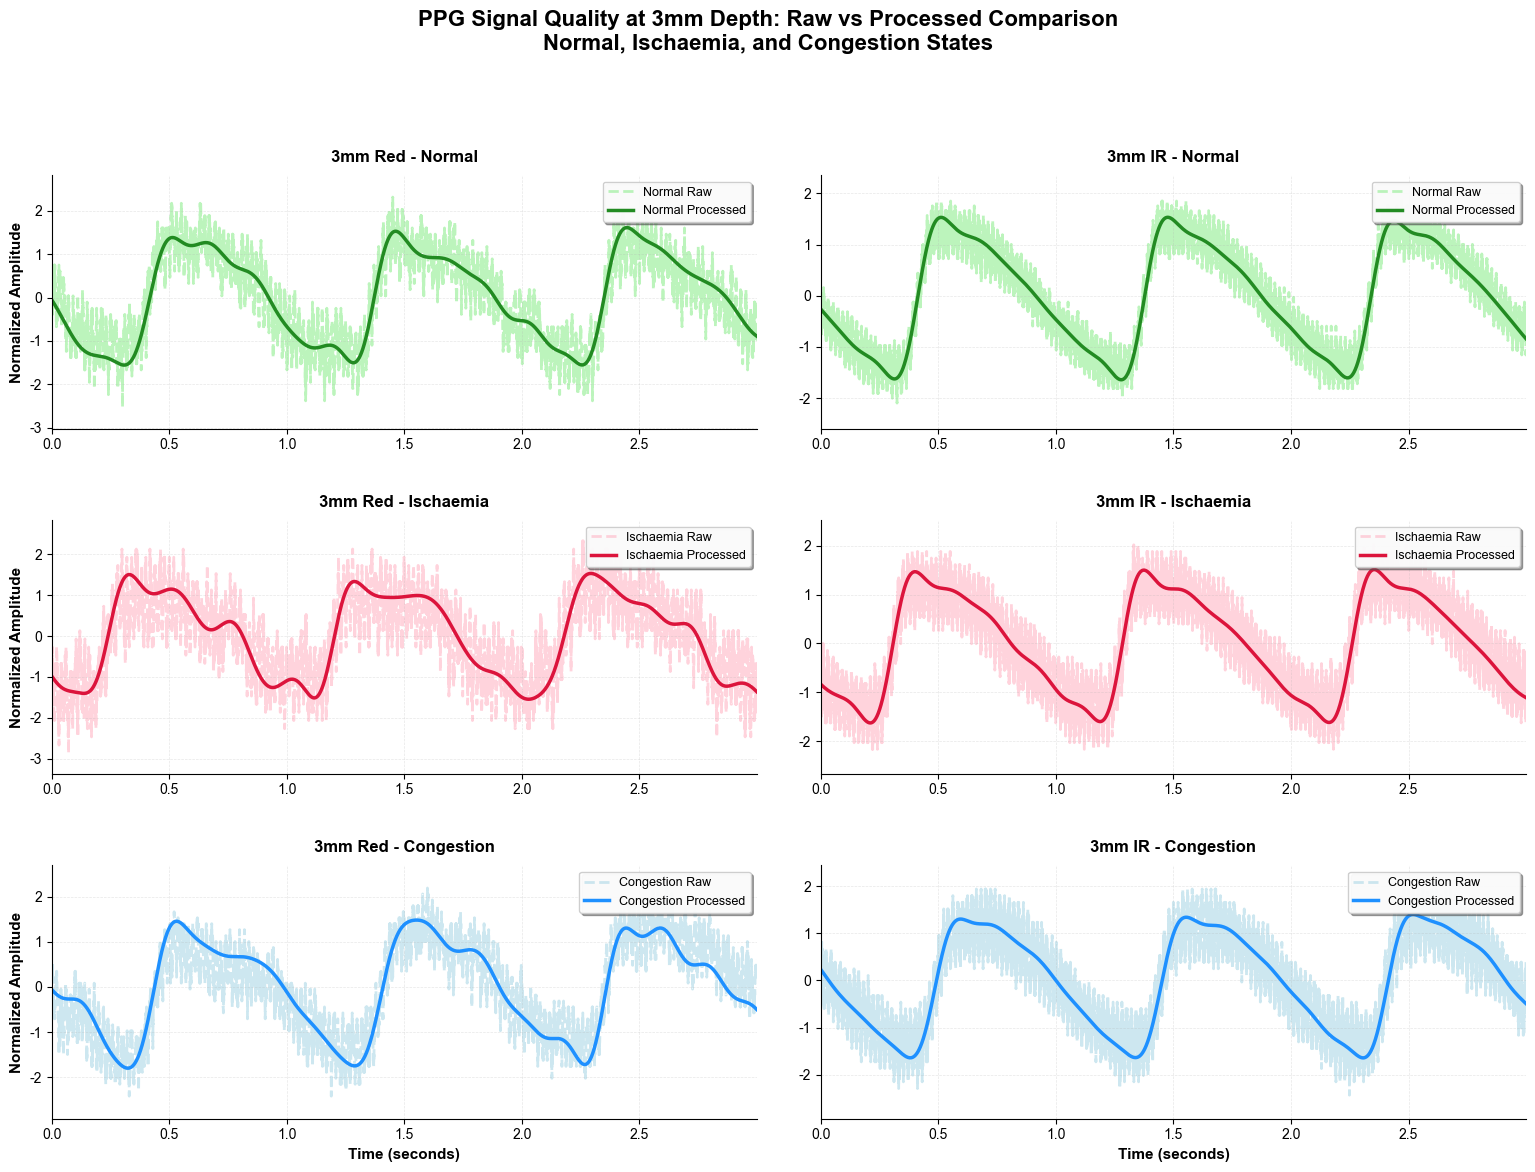


VISUALIZATION COMPLETED

✅ VISUALIZATION COMPLETED

Generated file:
  - PPG_3mm_State_Comparison_Overlay.png
    (State-by-state comparison with manual time alignment)


In [68]:
"""
PPG信号の可視化：3mm深度における状態別比較
正常・虚血・鬱血の3状態を処理前後のオーバーレイで表示

【可視化する内容】
- 3mm深度に特化
- Red/IR各チャンネル
- 各状態（Normal, Ischaemia, Congestion）のRaw vs Processed
- 手動オフセット調整で波形位置を揃える
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import os
import warnings
warnings.filterwarnings('ignore')

# フォント設定
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# パラメータ設定
FS = 2000  # サンプリングレート [Hz]
DISPLAY_DURATION = 3.0  # 表示時間 [秒]
BASE_START_TIME = 5.0  # 基準開始時刻 [秒]
TARGET_DEPTH = 3  # 3mm深度のみ

# 手動オフセット設定（波形位置を揃えるため）
manual_start_offsets_s = {
    3: {
        "Red": {"Normal": 0.0, "Ischaemia": 0.35, "Congestion": 0.7}, 
        "IR": {"Normal": 0.0, "Ischaemia": -0.7, "Congestion": -0.3}
    }
}

state_map = {1: "Normal", 2: "Ischaemia", 3: "Congestion"}
channels = {"Red": "ppgA_Red_raw", "IR": "ppgA_IR_raw"}

# 状態別の色設定
state_colors_raw = {
    "Normal": "#90EE90",      # Light green
    "Ischaemia": "#FFB6C6",   # Light pink
    "Congestion": "#ADD8E6"   # Light blue
}

state_colors_processed = {
    "Normal": "#228B22",      # Forest green
    "Ischaemia": "#DC143C",   # Crimson
    "Congestion": "#1E90FF"   # Dodger blue
}


def load_and_normalize_signal(filename, channel_name, raw_col_name, state_name):
    """
    信号を読み込んで正規化（手動オフセット適用）
    
    Returns:
    --------
    time, raw_signal_norm, processed_signal_norm
    """
    df = pd.read_csv(filename)
    
    # 手動オフセットを取得
    offset_s = manual_start_offsets_s[TARGET_DEPTH][channel_name][state_name]
    actual_start_time = BASE_START_TIME + offset_s
    
    # 表示範囲の計算
    start_sample = int(actual_start_time * FS)
    duration_samples = int(DISPLAY_DURATION * FS)
    end_sample = start_sample + duration_samples
    
    # 時間軸（常に0から開始）
    time = np.arange(duration_samples) / FS
    
    # データ抽出
    processed_col_name = f"{channel_name}_processed"
    raw_signal = df[raw_col_name].values[start_sample:end_sample]
    processed_signal = df[processed_col_name].values[start_sample:end_sample]
    
    # 正規化（表示用）
    raw_signal_norm = (raw_signal - np.mean(raw_signal)) / (np.std(raw_signal) + 1e-10)
    processed_signal_norm = (processed_signal - np.mean(processed_signal)) / (np.std(processed_signal) + 1e-10)
    
    print(f"    Offset applied: {offset_s:+.2f}s (actual start: {actual_start_time:.2f}s)")
    
    return time, raw_signal_norm, processed_signal_norm


def plot_state_overlay(ax, time, signals_dict, state_name, channel_name, 
                       show_xlabel=True, show_ylabel=True, show_legend=True):
    """
    1つの状態のRaw vs Processed オーバーレイプロット
    
    Parameters:
    -----------
    ax : matplotlib axis
    time : array
        時間軸
    signals_dict : dict
        {'raw': raw_signal, 'processed': processed_signal}
    state_name : str
        状態名（Normal, Ischaemia, Congestion）
    channel_name : str
        チャンネル名（Red, IR）
    """
    raw_signal = signals_dict['raw']
    processed_signal = signals_dict['processed']
    
    # Raw信号（薄い色、破線）
    ax.plot(time, raw_signal, 
            color=state_colors_raw[state_name], 
            linewidth=2, 
            linestyle='--',
            alpha=0.6,
            label=f'{state_name} Raw',
            zorder=1)
    
    # Processed信号（濃い色、実線）
    ax.plot(time, processed_signal, 
            color=state_colors_processed[state_name], 
            linewidth=2.5,
            label=f'{state_name} Processed',
            zorder=2)
    
    # タイトル
    title = f'3mm {channel_name} - {state_name}'
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    
    # 軸ラベル
    if show_xlabel:
        ax.set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')
    
    if show_ylabel:
        ax.set_ylabel('Normalized Amplitude', fontsize=11, fontweight='bold')
    
    # グリッド
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # 凡例
    if show_legend:
        ax.legend(loc='upper right', fontsize=9, framealpha=0.95, 
                 shadow=True, fancybox=True)
    
    # 軸の調整
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=10)
    ax.set_xlim([time[0], time[-1]])
    
    # Y軸の範囲を統一（見やすさのため）
    y_margin = 0.5
    y_min = min(raw_signal.min(), processed_signal.min()) - y_margin
    y_max = max(raw_signal.max(), processed_signal.max()) + y_margin
    ax.set_ylim([y_min, y_max])


def create_3mm_state_comparison():
    """
    3mm深度における状態別比較可視化
    2列×3行（Red列とIR列、各3状態）
    """
    print("="*80)
    print("3mm Depth: State-by-State Comparison (Raw vs Processed)")
    print("="*80)
    
    # 図の作成
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    
    # 各状態をループ
    for row_idx, (i_state, state_name) in enumerate(state_map.items()):
        filename = f"{TARGET_DEPTH}mm_processed_data{i_state}.csv"
        
        if not os.path.exists(filename):
            print(f"⚠️  File not found: {filename}")
            continue
        
        print(f"\n📂 Loading: {filename} ({state_name})")
        
        # 各チャンネルをプロット
        for col_idx, (channel_name, raw_col_name) in enumerate(channels.items()):
            try:
                print(f"  Processing: {channel_name}")
                
                # データ読み込みと正規化（手動オフセット適用）
                time, raw_signal_norm, processed_signal_norm = load_and_normalize_signal(
                    filename, channel_name, raw_col_name, state_name
                )
                
                # 信号辞書
                signals_dict = {
                    'raw': raw_signal_norm,
                    'processed': processed_signal_norm
                }
                
                # サブプロット取得
                ax = axes[row_idx, col_idx]
                
                # X軸ラベルは最下行のみ
                show_xlabel = (row_idx == 2)
                # Y軸ラベルは左列のみ
                show_ylabel = (col_idx == 0)
                # 凡例は全て表示
                show_legend = True
                
                # プロット
                plot_state_overlay(ax, time, signals_dict, state_name, channel_name,
                                 show_xlabel, show_ylabel, show_legend)
                
                print(f"    ✓ Plotted: {channel_name} - {state_name}")
                
            except Exception as e:
                print(f"    ✗ Error plotting {channel_name} - {state_name}: {str(e)}")
                continue
    
    # 全体タイトル
    fig.suptitle('PPG Signal Quality at 3mm Depth: Raw vs Processed Comparison\nNormal, Ischaemia, and Congestion States', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    
    # 保存
    output_filename = "PPG_3mm_State_Comparison_Overlay.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"\n✅ Figure saved: {output_filename}")
    
    plt.show()
    
    print("\n" + "="*80)
    print("VISUALIZATION COMPLETED")
    print("="*80)


# ========= メイン実行 =========
if __name__ == "__main__":
    print("\n" + "🎨 " * 30)
    print("3mm DEPTH STATE COMPARISON VISUALIZATION")
    print("🎨 " * 30 + "\n")
    
    # 状態別の個別プロット（2列×3行）
    create_3mm_state_comparison()
    
    print("\n" + "="*80)
    print("✅ VISUALIZATION COMPLETED")
    print("="*80)
    print("\nGenerated file:")
    print("  - PPG_3mm_State_Comparison_Overlay.png")
    print("    (State-by-state comparison with manual time alignment)")
    print("="*80)



2026-01-31 11:09:25,737 - INFO - maxp pruned
2026-01-31 11:09:25,740 - INFO - LTSH dropped
2026-01-31 11:09:25,741 - INFO - cmap pruned
2026-01-31 11:09:25,741 - INFO - kern dropped
2026-01-31 11:09:25,745 - INFO - post pruned
2026-01-31 11:09:25,745 - INFO - PCLT dropped
2026-01-31 11:09:25,746 - INFO - JSTF dropped
2026-01-31 11:09:25,747 - INFO - DSIG dropped
2026-01-31 11:09:25,750 - INFO - GPOS pruned
2026-01-31 11:09:25,752 - INFO - GSUB pruned
2026-01-31 11:09:25,757 - INFO - glyf pruned
2026-01-31 11:09:25,760 - INFO - Added gid0 to subset
2026-01-31 11:09:25,761 - INFO - Added first four glyphs to subset
2026-01-31 11:09:25,762 - INFO - Closing glyph list over 'GSUB': 38 glyphs before
2026-01-31 11:09:25,763 - INFO - Glyph names: ['.notdef', '.null', 'A', 'C', 'I', 'N', 'R', 'T', 'a', 'c', 'd', 'e', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'six', 'space', 't', 'three', 't

✅ 図を保存しました:
  - PPG_waveform_comparison.tiff (600 dpi)
  - PPG_waveform_comparison.pdf (ベクター)
  - PPG_waveform_comparison.eps (ベクター)


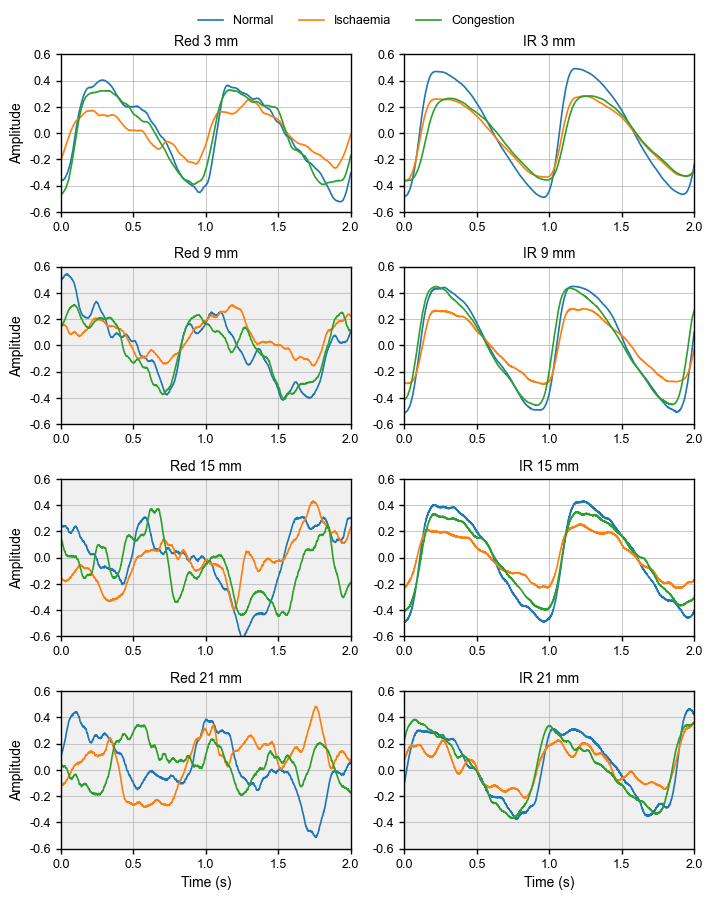

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, savgol_filter
import matplotlib.ticker as ticker
import math

# ========= パラメータ設定 =========
fs = 2000  # サンプリングレート [Hz]
start_time = 15.0    # 基本の表示開始時間 [秒]
display_time = 2.0   # 表示時間 [秒]
OFFSET_SAMPLES = 500 # MA安定化のためのオフセット点数 (0.25s)
OFFSET_TIME = OFFSET_SAMPLES / fs  

depths = [3, 9, 15, 21]
states = ["Normal", "Ischaemia", "Congestion"]
legend_labels = ['Normal', 'Ischaemia', 'Congestion']
channels = {"Red": "ppgA_Red_raw", "IR": "ppgA_IR_raw"} 

# --- フィルタリング＆スムージング設定 ---
BSF_LOW_CUT = 20.0  
BSF_HIGH_CUT = 50.0 
BSF_ORDER = 4       
MA_WINDOW = 200     
SG_WINDOW = 51 
SG_POLY = 3

# --- 手動ピーク位置合わせ設定（★修正: IR 9mm, 15mm の全状態に+0.75s, +0.4s適用） ---
manual_start_offsets_s = {
    3: {"Red": {"Normal": 0.0, "Ischaemia": 0.35, "Congestion": 0.7}, 
        "IR": {"Normal": 0.0, "Ischaemia": -0.7, "Congestion": -0.3}},
    9: {"Red": {"Normal": 0.2, "Ischaemia": 0.0, "Congestion": 0.0}, 
        "IR": {"Normal": 0.75, "Ischaemia": 0.75, "Congestion": 0.75 + 0.2}},  # ★全状態に+0.75s
    15: {"Red": {"Normal": 0.0, "Ischaemia": 0.5, "Congestion": 0.1}, 
         "IR": {"Normal": 0.4, "Ischaemia": 0.4 - 0.5, "Congestion": 0.4 + 0.03}},  # ★全状態に+0.4s
    21: {"Red": {"Normal": 0.0, "Ischaemia": 0.35, "Congestion": 0.0}, 
         "IR": {"Normal": 0.0, "Ischaemia": 0.2, "Congestion": 0.4}},
}

# ========= Sci Rep準拠の設定 =========
# フォント設定（Arial推奨、8-12 pt）
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 9  # 基本フォントサイズ
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# 線幅設定（最低1 pt以上）
plt.rcParams['lines.linewidth'] = 1.2
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0

# PDF出力設定
plt.rcParams['pdf.fonttype'] = 42  # TrueType埋め込み
plt.rcParams['ps.fonttype'] = 42

def calculate_amplitude(signal):
    """信号のPeak-to-Peak振幅を計算 (Max - Min)"""
    return np.max(signal) - np.min(signal)

def bandstop_filter_noise_reduction(sig, fs, low_cutoff, high_cutoff, order=BSF_ORDER):
    nyq = fs / 2
    b, a = butter(order, [low_cutoff / nyq, high_cutoff / nyq], btype='stop')
    return filtfilt(b, a, sig)

def moving_average_smoothing(data, window):
    if len(data) < window: return data
    ret = np.cumsum(data, dtype=float)
    ret[window:] = ret[window:] - ret[:-window]
    smoothed = ret[window - 1:] / window
    padding_val = smoothed[0]
    padded_start = np.full(window - 1, padding_val)
    return np.concatenate((padded_start, smoothed))

def process_signal_and_center(df, ch_col, load_start_index, load_end_index):
    """BSFとMAを適用し、DCゼロセンター化した信号を返す"""
    signal = df[ch_col].values[load_start_index:load_end_index]
    signal_filtered = bandstop_filter_noise_reduction(signal, fs, BSF_LOW_CUT, BSF_HIGH_CUT)
    smoothed = moving_average_smoothing(signal_filtered, window=MA_WINDOW)
    return smoothed - np.mean(smoothed)

# ========= Figure設定（ダブルカラム183mm ≈ 7.2インチ） =========
fig_width_inch = 7.2  # ダブルカラム幅 (183mm)
fig_height_inch = 9.0  # 縦横比を考慮
fig, axes = plt.subplots(len(depths), len(channels), 
                         figsize=(fig_width_inch, fig_height_inch), 
                         sharex=False, sharey=False) 
plot_data_length = int(display_time * fs)

# 1. 最大オフセットの決定
max_abs_offset = 0.0
for d in depths:
    for ch in channels:
        for state in states:
            offset = manual_start_offsets_s[d][ch][state]
            max_abs_offset = max(max_abs_offset, abs(offset))

# 2. 動的な読み込み範囲の決定
load_start_time_final = start_time - OFFSET_TIME - max_abs_offset
load_start_index_final = int(load_start_time_final * fs)
load_end_time_final = start_time + display_time + max_abs_offset
load_end_index_final = int(load_end_time_final * fs)

# 3. 基準となるゼロオフセット
zero_offset_time = OFFSET_TIME + max_abs_offset
zero_offset_samples = int(zero_offset_time * fs)

for row, depth in enumerate(depths):
    for col, (ch_name, ch_col) in enumerate(channels.items()):
        ax = axes[row, col]
        
        # 背景色の設定
        if (ch_name == "Red" and depth in [9, 15, 21]) or (ch_name == "IR" and depth == 21):
            ax.set_facecolor('#F0F0F0')
        
        processed_data = {}
        max_amplitude = 0.0
        
        # 1. 全てのStateのデータを処理
        for i, state in enumerate(states, start=1):
            file = f"{depth}mm_adjusted_data{i}.csv" 
            try:
                df = pd.read_csv(file)
                
                signal_centered = process_signal_and_center(df, ch_col, load_start_index_final, load_end_index_final)
                amplitude = calculate_amplitude(signal_centered)
                
                if amplitude > max_amplitude:
                    max_amplitude = amplitude
                
                processed_data[state] = {
                    'signal': signal_centered,
                    'amplitude': amplitude,
                    'manual_offset_s': manual_start_offsets_s[depth][ch_name][state]
                }
                
            except FileNotFoundError:
                processed_data[state] = None
        
        # 2. 相対振幅スケーリングとプロット
        reference_amplitude = max_amplitude 
        
        for i, state in enumerate(states, start=1):
            data_info = processed_data.get(state)
            if data_info is None:
                continue
                
            sig = data_info['signal']
            amp = data_info['amplitude']
            manual_offset_s = data_info['manual_offset_s']
            
            # 相対振幅正規化
            if reference_amplitude > 1e-12:
                 signal_scaled = sig * (1.0 / reference_amplitude) 
            else:
                 signal_scaled = np.zeros_like(sig)
            
            # プロットデータの切り出し
            manual_offset_samples = int(round(manual_offset_s * fs))
            plot_start_index = zero_offset_samples + manual_offset_samples
            plot_end_index = plot_start_index + plot_data_length
            
            if plot_end_index > len(signal_scaled) or plot_start_index < 0:
                 continue
                 
            signal_norm = signal_scaled[plot_start_index:plot_end_index]
            time = np.arange(0, display_time * fs) / fs 

            # プロット（線幅1.2 pt以上）
            ax.plot(time, signal_norm, label=legend_labels[i-1], linewidth=1.2)

        # 軸ラベルとタイトル
        ax.set_title(f"{ch_name} {depth} mm", fontsize=10)
        ax.tick_params(axis='both', which='major', labelsize=9, width=1.0) 
        
        ax.set_xlim(0, display_time)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5)) 
        ax.set_ylim(-0.6, 0.6)
        ax.grid(True, linewidth=0.5)

        if col == 0:
            ax.set_ylabel('Amplitude', fontsize=10)
        if row == len(depths)-1:
            ax.set_xlabel('Time (s)', fontsize=10)

# 凡例
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=9, 
           bbox_to_anchor=(0.5, 1.00), frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.98])

# ========= 保存（Sci Rep準拠） =========
# 1. TIFF形式（600 dpi推奨）
plt.savefig('PPG_waveform_comparison.tiff', dpi=600, format='tiff', 
            bbox_inches='tight', pil_kwargs={'compression': 'tiff_lzw'})

# 2. PDF形式（ベクター、フォント埋め込み）
plt.savefig('PPG_waveform_comparison.pdf', dpi=600, format='pdf', 
            bbox_inches='tight')

# 3. EPS形式（オプション）
plt.savefig('PPG_waveform_comparison.eps', dpi=600, format='eps', 
            bbox_inches='tight')

print("✅ 図を保存しました:")
print("  - PPG_waveform_comparison.tiff (600 dpi)")
print("  - PPG_waveform_comparison.pdf (ベクター)")
print("  - PPG_waveform_comparison.eps (ベクター)")

plt.show()



In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


# ===========================
# Sci Rep準拠の設定
# ===========================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 8
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.title_fontsize'] = 9


# 線幅設定
plt.rcParams['lines.linewidth'] = 1.0
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['patch.linewidth'] = 1.0


# PDF出力設定
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42


# ===========================
# Configuration
# ===========================
INPUT_FILES = {
    '3mm_Red': 'diagnostic_performance_3mm_Red_all.csv',
    '3mm_IR': 'diagnostic_performance_3mm_IR_all.csv',
    '9mm_IR': 'diagnostic_performance_9mm_IR_all.csv',
    '15mm_IR': 'diagnostic_performance_15mm_IR_all.csv',
    '3mm_Combined': 'diagnostic_performance_3mm_Combined_all.csv'
}


OUTPUT_DIR = Path('integrated_depth_comparison')
OUTPUT_DIR.mkdir(exist_ok=True)


STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}
COMPARISONS = ['Ischaemia', 'Congestion']


# Category colors
CATEGORY_COLORS = {
    'Intensity': '#FFB74D',
    'Area': '#FFF176',
    'Time': '#4FC3F7',
    'Slope': '#BA68C8',
    'SDPPG': '#81C784',
    'Shape & Stats': '#BDBDBD',
    'Combined': "#fcf6dc"
}


# Wavelength colors
WAVELENGTH_COLORS = {
    'Red': '#D32F2F',
    'IR': '#1976D2',
    'Red&IR': '#7B1FA2'
}


# ===========================
# Helper Functions
# ===========================
def get_category(feature_name):
    intensity_keywords = ['PI', 'AC_Component', 'DC_Component', 'Amplitude']
    area_keywords = ['AUC', 'Area', 'Datum']
    time_keywords = ['Time', 'Width', 'PW50']
    slope_keywords = ['slope', 'Slope']
    sdppg_keywords = ['SDPPG', 'DNP']
    shape_keywords = ['Skewness', 'Kurtosis', 'Variance', 'RWI', 'IPAR']
    
    fname = feature_name
    if any(k in fname for k in intensity_keywords):
        return 'Intensity'
    elif any(k in fname for k in area_keywords):
        return 'Area'
    elif any(k in fname for k in time_keywords):
        return 'Time'
    elif any(k in fname for k in slope_keywords):
        return 'Slope'
    elif any(k in fname for k in sdppg_keywords):
        return 'SDPPG'
    elif any(k in fname for k in shape_keywords):
        return 'Shape & Stats'
    else:
        return 'Combined'


def clean_feature_name(feature_name):
    for comp in COMPARISONS:
        if feature_name.endswith(f'_{comp}'):
            return feature_name[:-len(f'_{comp}')]
    return feature_name


def load_and_filter_data(file_path, depth, source, comparison):
    df = pd.read_csv(file_path)
    df = df[df['Comparison'] == comparison].copy()
    
    df['Depth'] = depth
    df['Source'] = source
    df['Category'] = df['Feature'].apply(get_category)
    df['Clean_Feature'] = df['Feature'].apply(clean_feature_name)
    df['Display_Name'] = df['Clean_Feature']
    
    # Exclude DC_Component
    df = df[~df['Clean_Feature'].str.contains('DC_Component', na=False)]
    
    return df


# ===========================
# Load Data
# ===========================
print("Loading diagnostic performance files...")


all_data = []


if Path(INPUT_FILES['3mm_Red']).exists():
    for comp in COMPARISONS:
        df_red = load_and_filter_data(INPUT_FILES['3mm_Red'], depth=3, source='Red', comparison=comp)
        all_data.append(df_red)


if Path(INPUT_FILES['3mm_IR']).exists():
    for comp in COMPARISONS:
        df_ir = load_and_filter_data(INPUT_FILES['3mm_IR'], depth=3, source='IR', comparison=comp)
        all_data.append(df_ir)


if Path(INPUT_FILES['3mm_Combined']).exists():
    for comp in COMPARISONS:
        df_comb = load_and_filter_data(INPUT_FILES['3mm_Combined'], depth=3, source='Red&IR', comparison=comp)
        all_data.append(df_comb)


if Path(INPUT_FILES['9mm_IR']).exists():
    for comp in COMPARISONS:
        df_9ir = load_and_filter_data(INPUT_FILES['9mm_IR'], depth=9, source='IR', comparison=comp)
        all_data.append(df_9ir)


if Path(INPUT_FILES['15mm_IR']).exists():
    for comp in COMPARISONS:
        df_15ir = load_and_filter_data(INPUT_FILES['15mm_IR'], depth=15, source='IR', comparison=comp)
        all_data.append(df_15ir)


df_all = pd.concat(all_data, ignore_index=True)


# ===========================
# Visualization
# ===========================
print("\nGenerating Depth Comparison Visualization...")


def plot_combined_depth_comparison():
    # ダブルカラム幅、より広く調整
    fig_width = 7.2
    fig_height = 6.5
    
    fig, axes = plt.subplots(2, 3, figsize=(fig_width, fig_height))
    
    depths = [3, 9, 15]
    comparisons_plot = ['Ischaemia', 'Congestion']
    
    all_handles = []
    all_labels = []
    
    # 注釈を格納する辞書（グラフ外出力用）
    annotations_dict = {}
    
    for row_idx, comp in enumerate(comparisons_plot):
        for col_idx, depth in enumerate(depths):
            ax = axes[row_idx, col_idx]
            
            df_plot = df_all[(df_all['Depth'] == depth) & (df_all['Comparison'] == comp)].copy()
            
            if len(df_plot) == 0:
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=8)
                ax.set_xlim(0.5, 1.0)
                ax.set_ylim(0, 1)
                ax.set_title(f'{depth} mm - {comp}', fontsize=10)
                continue
            
            # Group by AUC + Category + Source
            df_plot['AUC_rounded'] = df_plot['AUC'].round(4)
            
            df_cat = df_plot.groupby(['AUC_rounded', 'Category', 'Source']).agg({
                'AUC': 'mean',
                'CI_Lower': 'mean',
                'CI_Upper': 'mean',
                'Clean_Feature': lambda x: ', '.join(sorted(x)),
                'Feature': 'count'
            }).reset_index()
            df_cat.rename(columns={'Feature': 'N_Features', 'Clean_Feature': 'Feature_List'}, inplace=True)
            
            df_cat = df_cat.sort_values('AUC', ascending=False).head(10).reset_index(drop=True)
            
            # Display names (n>1の場合は注釈を別ファイルに保存)
            display_names = []
            key = f"{depth}mm_{comp}"
            annotations_dict[key] = []
            
            for idx, row in df_cat.iterrows():
                n = int(row['N_Features'])
                category = row['Category']
                source = row['Source']
                feature_list = row['Feature_List']
                
                if n == 1:
                    display_name = feature_list
                else:
                    display_name = f"{category} (n={n})"
                    # 注釈を辞書に保存
                    annotations_dict[key].append(f"{category} {source}: {feature_list}")
                
                display_names.append(display_name)
            
            df_cat['Display_Name'] = display_names
            
            # X-axis range
            ci_lower_min = df_cat['CI_Lower'].min()
            x_min = max(0.5, ci_lower_min - 0.05)
            x_min = np.floor(x_min * 10) / 10
            x_max = 1.0
            
            # Plot bars
            y_positions = np.arange(len(df_cat))
            
            for i, row in df_cat.iterrows():
                category = row['Category']
                source = row['Source']
                auc = row['AUC']
                ci_lower = max(row['CI_Lower'], x_min)
                ci_upper = min(row['CI_Upper'], x_max)
                
                bar_color = CATEGORY_COLORS.get(category, CATEGORY_COLORS['Combined'])
                ax.barh(i, auc - x_min, left=x_min, height=0.6, 
                       color=bar_color, alpha=0.7, edgecolor='black', linewidth=1.0)
                
                xerr = [[auc - ci_lower], [ci_upper - auc]]
                marker_color = WAVELENGTH_COLORS.get(source, '#000000')
                ax.errorbar(auc, i, xerr=xerr, fmt='o', color=marker_color, 
                           markersize=4, capsize=3, capthick=1.0, elinewidth=1.0)
            
            # Y-axis labels
            ax.set_yticks(y_positions)
            ax.set_yticklabels(df_cat['Display_Name'], fontsize=7)
            ax.invert_yaxis()
            
            # X-axis - 15mm Congestion のみ 0.25 刻み、それ以外は 0.1 刻み
            ax.set_xlim(x_min, x_max)
            
            if depth == 15 and comp == 'Congestion':
                # 0.25 刻み（15mm Congestion のみ）
                # x_min を 0.25 の倍数に切り下げ
                x_min_adjusted = np.floor(x_min * 4) / 4
                x_ticks = np.arange(x_min_adjusted, x_max + 0.01, 0.25)
                # 小数点第2位を表示しないフォーマット（0.5, 0.75, 1.0）
                ax.set_xticklabels([f'{x:.2f}'.rstrip('0').rstrip('.') if x != int(x) else f'{int(x)}' 
                                   for x in x_ticks], fontsize=8)
            else:
                # 0.1 刻み（その他全て）
                x_ticks = np.arange(x_min, x_max + 0.01, 0.1)
                # 小数点第1位のみ表示（0.5, 0.6, ..., 1.0）
                ax.set_xticklabels([f'{x:.1f}' for x in x_ticks], fontsize=8)
            
            ax.set_xticks(x_ticks)
            ax.set_xlabel('AUC', fontsize=9)
            
            # Title
            ax.set_title(f'{depth} mm - {comp}', fontsize=10, loc='right')
            ax.grid(axis='x', linestyle='--', alpha=0.3, linewidth=0.5)
            
            # Collect legend handles
            if row_idx == 0 and col_idx == 0:
                for cat, color in CATEGORY_COLORS.items():
                    handle = plt.Line2D([0], [0], marker='s', color='w', 
                                       markerfacecolor=color, markersize=8, label=cat,
                                       markeredgewidth=1.0, markeredgecolor='black')
                    all_handles.append(handle)
                    all_labels.append(cat)
                
                for source, color in WAVELENGTH_COLORS.items():
                    handle = plt.Line2D([0], [0], marker='o', color='w', 
                                       markerfacecolor=color, markersize=6, 
                                       markeredgecolor='black', markeredgewidth=1.0, label=source)
                    all_handles.append(handle)
                    all_labels.append(source)
    
    # Legend
    fig.legend(all_handles, all_labels, loc='center left', bbox_to_anchor=(0.90, 0.5), 
              frameon=True, fontsize=8, title='Legend', title_fontsize=9)
    
    # より広いスペーシングで重なりを防止
    plt.tight_layout(rect=[0, 0, 0.89, 1.0])
    
    # 注釈をテキストファイルに出力
    annotation_file = OUTPUT_DIR / 'feature_annotations.txt'
    with open(annotation_file, 'w', encoding='utf-8') as f:
        f.write("Feature Annotations for Grouped Categories (n>1)\n")
        f.write("=" * 80 + "\n\n")
        for key, annots in annotations_dict.items():
            if annots:
                f.write(f"{key}:\n")
                for annot in annots:
                    f.write(f"  - {annot}\n")
                f.write("\n")
    
    print(f"Feature annotations saved to: {annotation_file}")
    
    # Save in multiple formats
    output_tiff = OUTPUT_DIR / 'depth_comparison_combined_all_bar.tiff'
    plt.savefig(output_tiff, dpi=600, format='tiff', bbox_inches='tight',
                pil_kwargs={'compression': 'tiff_lzw'})
    print(f"Saved: {output_tiff}")
    
    output_pdf = OUTPUT_DIR / 'depth_comparison_combined_all_bar.pdf'
    plt.savefig(output_pdf, dpi=600, format='pdf', bbox_inches='tight')
    print(f"Saved: {output_pdf}")
    
    output_eps = OUTPUT_DIR / 'depth_comparison_combined_all_bar.eps'
    plt.savefig(output_eps, dpi=600, format='eps', bbox_inches='tight')
    print(f"Saved: {output_eps}")
    
    plt.close()


plot_combined_depth_comparison()


print("\n" + "="*60)
print("All tasks completed successfully!")
print(f"Output directory: {OUTPUT_DIR}")
print("Files generated:")
print("  - depth_comparison_combined_all_bar.tiff/pdf/eps")
print("  - feature_annotations.txt (grouped feature details)")
print("="*60)

Loading diagnostic performance files...

Generating Depth Comparison Visualization...
Feature annotations saved to: integrated_depth_comparison/feature_annotations.txt
Saved: integrated_depth_comparison/depth_comparison_combined_all_bar.tiff


2026-02-02 13:34:12,207 - INFO - maxp pruned
2026-02-02 13:34:12,211 - INFO - LTSH dropped
2026-02-02 13:34:12,213 - INFO - cmap pruned
2026-02-02 13:34:12,214 - INFO - kern dropped
2026-02-02 13:34:12,222 - INFO - post pruned
2026-02-02 13:34:12,223 - INFO - PCLT dropped
2026-02-02 13:34:12,225 - INFO - JSTF dropped
2026-02-02 13:34:12,226 - INFO - DSIG dropped
2026-02-02 13:34:12,234 - INFO - GPOS pruned
2026-02-02 13:34:12,237 - INFO - GSUB pruned
2026-02-02 13:34:12,245 - INFO - glyf pruned
2026-02-02 13:34:12,250 - INFO - Added gid0 to subset
2026-02-02 13:34:12,251 - INFO - Added first four glyphs to subset
2026-02-02 13:34:12,252 - INFO - Closing glyph list over 'GSUB': 56 glyphs before
2026-02-02 13:34:12,252 - INFO - Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'E', 'G', 'I', 'L', 'M', 'N', 'P', 'R', 'S', 'T', 'U', 'W', 'a', 'ampersand', 'b', 'c', 'd', 'e', 'eight', 'equal', 'f', 'five', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', '

Saved: integrated_depth_comparison/depth_comparison_combined_all_bar.pdf


2026-02-02 13:34:12,808 - INFO - maxp pruned
2026-02-02 13:34:12,808 - INFO - LTSH dropped
2026-02-02 13:34:12,809 - INFO - cmap pruned
2026-02-02 13:34:12,810 - INFO - kern dropped
2026-02-02 13:34:12,813 - INFO - post pruned
2026-02-02 13:34:12,814 - INFO - PCLT dropped
2026-02-02 13:34:12,814 - INFO - JSTF dropped
2026-02-02 13:34:12,815 - INFO - DSIG dropped
2026-02-02 13:34:12,818 - INFO - GPOS pruned
2026-02-02 13:34:12,820 - INFO - GSUB pruned
2026-02-02 13:34:12,823 - INFO - glyf pruned
2026-02-02 13:34:12,826 - INFO - Added gid0 to subset
2026-02-02 13:34:12,826 - INFO - Added first four glyphs to subset
2026-02-02 13:34:12,827 - INFO - Closing glyph list over 'GSUB': 56 glyphs before
2026-02-02 13:34:12,827 - INFO - Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'E', 'G', 'I', 'L', 'M', 'N', 'P', 'R', 'S', 'T', 'U', 'W', 'a', 'ampersand', 'b', 'c', 'd', 'e', 'eight', 'equal', 'f', 'five', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', '

Saved: integrated_depth_comparison/depth_comparison_combined_all_bar.eps

All tasks completed successfully!
Output directory: integrated_depth_comparison
Files generated:
  - depth_comparison_combined_all_bar.tiff/pdf/eps
  - feature_annotations.txt (grouped feature details)


✅ Saved: vascular_compliance_combined.tiff (600 dpi)


2026-02-02 12:50:37,487 - INFO - maxp pruned
2026-02-02 12:50:37,489 - INFO - LTSH dropped
2026-02-02 12:50:37,491 - INFO - cmap pruned
2026-02-02 12:50:37,491 - INFO - kern dropped
2026-02-02 12:50:37,499 - INFO - post pruned
2026-02-02 12:50:37,500 - INFO - PCLT dropped
2026-02-02 12:50:37,500 - INFO - JSTF dropped
2026-02-02 12:50:37,500 - INFO - DSIG dropped
2026-02-02 12:50:37,520 - INFO - GPOS pruned
2026-02-02 12:50:37,522 - INFO - GSUB pruned
2026-02-02 12:50:37,539 - INFO - glyf pruned
2026-02-02 12:50:37,545 - INFO - Added gid0 to subset
2026-02-02 12:50:37,546 - INFO - Added first four glyphs to subset
2026-02-02 12:50:37,546 - INFO - Closing glyph list over 'GSUB': 8 glyphs before
2026-02-02 12:50:37,547 - INFO - Glyph names: ['.notdef', '.null', 'four', 'nonmarkingreturn', 'period', 'six', 'space', 'zero']
2026-02-02 12:50:37,548 - INFO - Glyph IDs:   [0, 1, 2, 3, 17, 19, 23, 25]
2026-02-02 12:50:37,554 - INFO - Closed glyph list over 'GSUB': 8 glyphs after
2026-02-02 12:5

✅ Saved: vascular_compliance_combined.pdf (vector)


2026-02-02 12:50:38,167 - INFO - maxp pruned
2026-02-02 12:50:38,168 - INFO - LTSH dropped
2026-02-02 12:50:38,169 - INFO - cmap pruned
2026-02-02 12:50:38,169 - INFO - kern dropped
2026-02-02 12:50:38,172 - INFO - post pruned
2026-02-02 12:50:38,173 - INFO - PCLT dropped
2026-02-02 12:50:38,173 - INFO - JSTF dropped
2026-02-02 12:50:38,174 - INFO - DSIG dropped
2026-02-02 12:50:38,178 - INFO - GPOS pruned
2026-02-02 12:50:38,180 - INFO - GSUB pruned
2026-02-02 12:50:38,183 - INFO - glyf pruned
2026-02-02 12:50:38,187 - INFO - Added gid0 to subset
2026-02-02 12:50:38,187 - INFO - Added first four glyphs to subset
2026-02-02 12:50:38,188 - INFO - Closing glyph list over 'GSUB': 51 glyphs before
2026-02-02 12:50:38,188 - INFO - Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'Delta', 'H', 'R', 'S', 'V', 'a', 'b', 'c', 'd', 'e', 'eight', 'endash', 'equal', 'five', 'four', 'g', 'greater', 'h', 'i', 'l', 'less', 'm', 'multiply', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'paren

✅ Saved: vascular_compliance_combined.eps (vector)


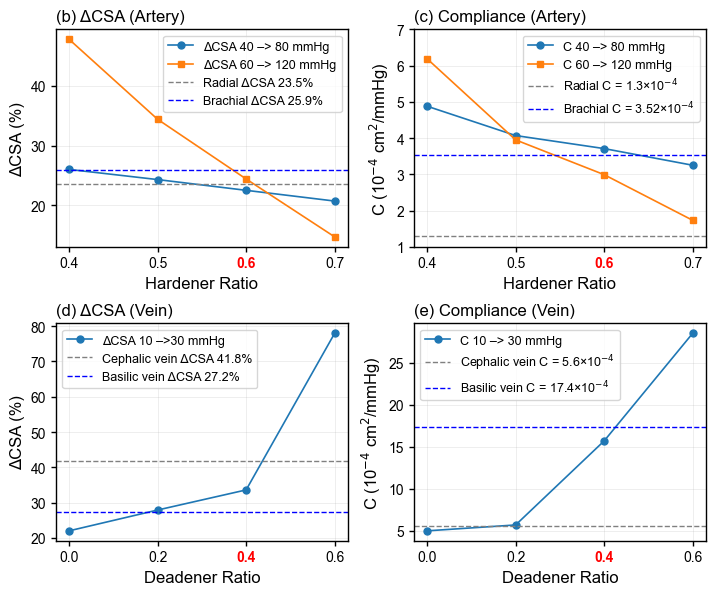


✅ All graphs combined into single Sci Rep-compliant figure


In [ ]:
#血管機械的特性

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl

# ===========================
# Sci Rep準拠の設定
# ===========================
# フォント設定（Arialを推奨、Times New Romanはオプション）
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
mpl.rcParams['font.size'] = 8  # 基本8-12 pt

# 線幅設定（最低1 pt以上）
mpl.rcParams['lines.linewidth'] = 1.2
mpl.rcParams['axes.linewidth'] = 1.0
mpl.rcParams['grid.linewidth'] = 0.5
mpl.rcParams['xtick.major.width'] = 1.0
mpl.rcParams['ytick.major.width'] = 1.0
mpl.rcParams['lines.markersize'] = 5

# PDF出力設定（フォント埋め込み）
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# LaTeX表記設定
mpl.rcParams['mathtext.fontset'] = 'dejavusans'

# ===========================
# データ準備
# ===========================
# 動脈データ
df_artery = pd.DataFrame({
    "H": [0.4, 0.5, 0.6, 0.7],
    "ΔCSA40_80": [26.0, 24.3, 22.5, 20.7],
    "ΔCSA60_120": [47.8, 34.4, 24.4, 14.7],
    "C40_80": [4.88, 4.07, 3.71, 3.25],
    "C60_120": [6.19, 3.95, 2.99, 1.73]
})

# 静脈データ
df_vein = pd.DataFrame({
    "D": [0.6, 0.4, 0.2, 0.0],
    "ΔCSA": [78.0, 33.6, 27.9, 22.0],
    "C": [28.5, 15.7, 5.7, 5.0]
})
df_vein = df_vein.sort_values("D", ascending=False)

# ===========================
# 統合Figure作成（2行2列）
# ===========================
# ダブルカラム幅: 183mm ≈ 7.2インチ
fig_width = 7.2
fig_height = 6.0

fig, axes = plt.subplots(2, 2, figsize=(fig_width, fig_height))

# ===========================
# (a) ΔCSA (Artery)
# ===========================
ax1 = axes[0, 0]
ax1.plot(df_artery["H"], df_artery["ΔCSA40_80"], marker='o', 
         label="ΔCSA 40 –> 80 mmHg", linewidth=1.2)
ax1.plot(df_artery["H"], df_artery["ΔCSA60_120"], marker='s', 
         label="ΔCSA 60 –> 120 mmHg", linewidth=1.2)
ax1.axhline(23.5, color='gray', linestyle='--', linewidth=1.0, 
            label="Radial ΔCSA 23.5%")
ax1.axhline(25.9, color='blue', linestyle='--', linewidth=1.0, 
            label="Brachial ΔCSA 25.9%")
ax1.set_xlabel("Hardener Ratio", fontsize=12)
ax1.set_ylabel("ΔCSA (%)", fontsize=12)
ax1.set_title("(b) ΔCSA (Artery)", fontsize=12, loc='left')
ax1.set_xticks(np.arange(0.4, 0.71, 0.1))
ax1.legend(fontsize=9, frameon=True, loc='best')
ax1.grid(True, linewidth=0.5, alpha=0.3)
ax1.tick_params(labelsize=10)
for label in ax1.get_xticklabels():
    if label.get_text() == '0.6':
        label.set_weight('bold')
        label.set_color('red')

# ===========================
# (b) Compliance (Artery)
# ===========================
ax2 = axes[0, 1]
ax2.plot(df_artery["H"], df_artery["C40_80"], marker='o', 
         label="C 40 –> 80 mmHg", linewidth=1.2)
ax2.plot(df_artery["H"], df_artery["C60_120"], marker='s', 
         label="C 60 –> 120 mmHg", linewidth=1.2)
ax2.axhline(1.3, color='gray', linestyle='--', linewidth=1.0, 
            label=r"Radial C = 1.3×10$^{-4}$")
ax2.axhline(3.52, color='blue', linestyle='--', linewidth=1.0, 
            label=r"Brachial C = 3.52×10$^{-4}$")
ax2.set_xlabel("Hardener Ratio", fontsize=12)
ax2.set_ylabel(r"C (10$^{-4}$ cm$^2$/mmHg)", fontsize=12)
ax2.set_title("(c) Compliance (Artery)", fontsize=12, loc='left')
ax2.set_xticks(np.arange(0.4, 0.71, 0.1))
ax2.set_ylim(1.0, 7.0)
ax2.legend(fontsize=9, frameon=True, loc='upper right')
ax2.grid(True, linewidth=0.5, alpha=0.3)
ax2.tick_params(labelsize=10)
for label in ax2.get_xticklabels():
    if label.get_text() == '0.6':
        label.set_weight('bold')
        label.set_color('red')

# ===========================
# (c) ΔCSA (Vein)
# ===========================
ax3 = axes[1, 0]
ax3.plot(df_vein["D"], df_vein["ΔCSA"], marker='o', 
         label="ΔCSA 10 –>30 mmHg", linewidth=1.2)
ax3.axhline(41.8, color='gray', linestyle='--', linewidth=1.0, 
            label="Cephalic vein ΔCSA 41.8%")
ax3.axhline(27.2, color='blue', linestyle='--', linewidth=1.0, 
            label="Basilic vein ΔCSA 27.2%")
ax3.set_xlabel("Deadener Ratio", fontsize=12)
ax3.set_ylabel("ΔCSA (%)", fontsize=12)
ax3.set_title("(d) ΔCSA (Vein)", fontsize=12, loc='left')
ax3.set_xticks(sorted(df_vein["D"], reverse=True))
ax3.legend(fontsize=9, frameon=True, loc='best')
ax3.grid(True, linewidth=0.5, alpha=0.3)
ax3.tick_params(labelsize=10)
for label in ax3.get_xticklabels():
    if label.get_text() == '0.4':
        label.set_weight('bold')
        label.set_color('red')

# ===========================
# (d) Compliance (Vein)
# ===========================
ax4 = axes[1, 1]
ax4.plot(df_vein["D"], df_vein["C"], marker='o', 
         label="C 10 –> 30 mmHg", linewidth=1.2)
ax4.axhline(5.6, color='gray', linestyle='--', linewidth=1.0, 
            label=r"Cephalic vein C = 5.6×10$^{-4}$")
ax4.axhline(17.4, color='blue', linestyle='--', linewidth=1.0, 
            label=r"Basilic vein C = 17.4×10$^{-4}$")
ax4.set_xlabel("Deadener Ratio", fontsize=12)
ax4.set_ylabel(r"C (10$^{-4}$ cm$^2$/mmHg)", fontsize=12)
ax4.set_title("(e) Compliance (Vein)", fontsize=12, loc='left')
ax4.set_xticks(sorted(df_vein["D"], reverse=True))
ax4.legend(fontsize=9, frameon=True, loc='best')
ax4.grid(True, linewidth=0.5, alpha=0.3)
ax4.tick_params(labelsize=10)
for label in ax4.get_xticklabels():
    if label.get_text() == '0.4':
        label.set_weight('bold')
        label.set_color('red')

# ===========================
# レイアウト調整と保存
# ===========================
plt.tight_layout()

# TIFF形式（600 dpi推奨）
plt.savefig('vascular_compliance_combined.tiff', dpi=600, format='tiff', 
            bbox_inches='tight', pil_kwargs={'compression': 'tiff_lzw'})
print("✅ Saved: vascular_compliance_combined.tiff (600 dpi)")

# PDF形式（ベクター）
plt.savefig('vascular_compliance_combined.pdf', dpi=600, format='pdf', 
            bbox_inches='tight')
print("✅ Saved: vascular_compliance_combined.pdf (vector)")

# EPS形式（オプション）
plt.savefig('vascular_compliance_combined.eps', dpi=600, format='eps', 
            bbox_inches='tight')
print("✅ Saved: vascular_compliance_combined.eps (vector)")

plt.show()

print("\n" + "="*60)
print("✅ All graphs combined into single Sci Rep-compliant figure")
print("="*60)


2026-02-02 12:50:45,903 - INFO - maxp pruned
2026-02-02 12:50:45,906 - INFO - LTSH dropped
2026-02-02 12:50:45,906 - INFO - cmap pruned
2026-02-02 12:50:45,907 - INFO - kern dropped
2026-02-02 12:50:45,910 - INFO - post pruned
2026-02-02 12:50:45,911 - INFO - PCLT dropped
2026-02-02 12:50:45,911 - INFO - JSTF dropped
2026-02-02 12:50:45,911 - INFO - DSIG dropped
2026-02-02 12:50:45,916 - INFO - GPOS pruned
2026-02-02 12:50:45,917 - INFO - GSUB pruned
2026-02-02 12:50:45,920 - INFO - glyf pruned
2026-02-02 12:50:45,925 - INFO - Added gid0 to subset
2026-02-02 12:50:45,925 - INFO - Added first four glyphs to subset
2026-02-02 12:50:45,926 - INFO - Closing glyph list over 'GSUB': 41 glyphs before
2026-02-02 12:50:45,926 - INFO - Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'E', 'F', 'G', 'I', 'L', 'M', 'N', 'P', 'R', 'S', 'T', 'U', 'W', 'a', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'p', 'r', 's', 'space', 't', 'u', 'underscore', 'w', 'x', 'y']
2026-02

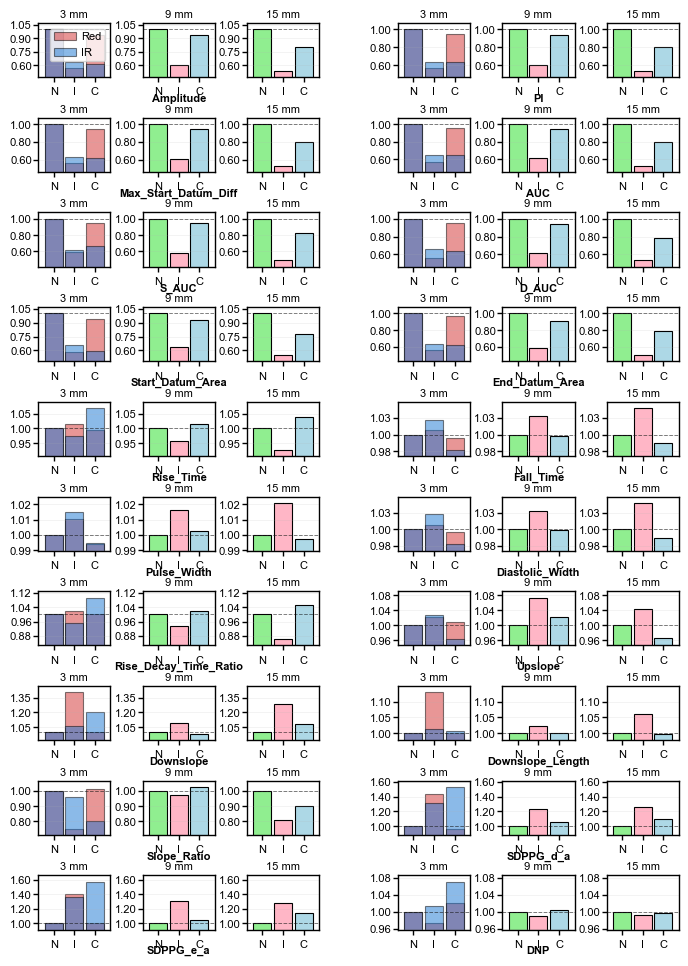

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from matplotlib.ticker import MaxNLocator
import warnings

warnings.filterwarnings('ignore')

# ===========================
# Sci Rep 準拠：視認性強化設定
# ===========================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 8           # 基本サイズを8ptに（規定の最小限）
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['axes.titlesize'] = 8
plt.rcParams['xtick.labelsize'] = 8     # 7pt以下にはしない
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8

plt.rcParams['lines.linewidth'] = 1.2    # 1pt以上を確保
plt.rcParams['axes.linewidth'] = 1.0    # 枠線を太くして視認性向上
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# ===========================
# 対象特徴量リスト
# ===========================
TARGET_FEATURES = [
    'Amplitude', 'PI', 'Max_Start_Datum_Diff', 'AUC',
    'S_AUC', 'D_AUC', 'Start_Datum_Area', 'End_Datum_Area',
    'Rise_Time', 'Fall_Time', 'Pulse_Width', 'Diastolic_Width',
    'Rise_Decay_Time_Ratio', 'Upslope', 'Downslope', 'Downslope_Length',
    'Slope_Ratio', 'SDPPG_d_a', 'SDPPG_e_a', 'DNP'
]

OUTPUT_DIR = Path('integrated_depth_comparison')
OUTPUT_DIR.mkdir(exist_ok=True)

# ===========================
# データ計算（関数の定義）
# ===========================
def calculate_state_means(df, features):
    state_map = {'Normal': 1, 'Ischaemia': 2, 'Congestion': 3}
    results = {}
    for feature in features:
        if feature not in df.columns: continue
        means = {}
        for state_name in state_map.keys():
            subset = df[df['State'] == state_name]
            means[state_name] = subset[feature].mean() if len(subset) > 0 else np.nan
        results[feature] = means
    return results

# ダミーデータ読み込み（パスは既存環境に合わせてください）
# df_3mm_red = pd.read_csv('...') 
# 等が実行されている前提です。

# ===========================
# 可視化レイアウト設定
# ===========================
n_features = len(TARGET_FEATURES)
n_features_per_row = 2 
n_cols = 7 
n_rows = int(np.ceil(n_features / n_features_per_row))

# Figureサイズ：ダブルカラム幅(183mm = 7.2inch) 
# 高さを1.3 -> 1.8に拡大してy軸の潰れを解消
fig_width = 7.2
fig_height = n_rows * 1.0 

fig = plt.figure(figsize=(fig_width, fig_height))

# wspaceを0.25 -> 0.45に拡大（y軸ラベルのスペース確保）
gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, 
                       width_ratios=[1, 1, 1, 0.2, 1, 1, 1], 
                       wspace=0.5, hspace=0.4,
                       left=0.08, right=0.97, top=0.97, bottom=0.05)

state_colors = {'Normal': '#90EE90', 'Ischaemia': '#FFB6C6', 'Congestion': '#ADD8E6'}
color_3mm_red = '#D32F2F'
color_3mm_ir = '#1976D2'

# ===========================
# 描画ループ
# ===========================
for feat_idx, feature in enumerate(TARGET_FEATURES):
    row = feat_idx // n_features_per_row
    col_offset = 4 if (feat_idx % n_features_per_row) == 1 else 0
    
    # 各深度のグラフ用リスト
    depth_axes = []
    
    # 3mm, 9mm, 15mm のサブプロット作成
    for i, title in enumerate(["3 mm", "9 mm", "15 mm"]):
        ax = fig.add_subplot(gs[row, col_offset + i])
        ax.set_title(title, fontsize=8, pad=4)
        depth_axes.append(ax)
        
    ax_3mm, ax_9mm, ax_15mm = depth_axes
    all_values = []

    # --- 3mm 描画 ---
    x_pos = np.array([0, 0.4, 0.8])
    bar_w = 0.35 # 少し太くして視認性アップ
    
    # Red & IR for 3mm
    for color, m_data, lbl in zip([color_3mm_red, color_3mm_ir], [means_3mm_red, means_3mm_ir], ['Red', 'IR']):
        if feature in m_data:
            ref = m_data[feature].get('Normal', np.nan)
            if not np.isnan(ref) and abs(ref) > 1e-10:
                vals = [1.0, m_data[feature].get('Ischaemia', 0)/ref, m_data[feature].get('Congestion', 0)/ref]
                ax_3mm.bar(x_pos, vals, color=color, alpha=0.5, edgecolor='black', linewidth=0.8, width=bar_w, label=lbl)
                all_values.extend(vals)

    # --- 9mm / 15mm 描画 ---
    for ax, m_data in zip([ax_9mm, ax_15mm], [means_9mm_ir, means_15mm_ir]):
        if feature in m_data:
            ref = m_data[feature].get('Normal', np.nan)
            if not np.isnan(ref) and abs(ref) > 1e-10:
                vals = [1.0, m_data[feature].get('Ischaemia', 0)/ref, m_data[feature].get('Congestion', 0)/ref]
                colors = [state_colors['Normal'], state_colors['Ischaemia'], state_colors['Congestion']]
                ax.bar(x_pos, vals, color=colors, edgecolor='black', linewidth=0.8, width=bar_w)
                all_values.extend(vals)

    # --- 軸の微調整（全グラフ共通） ---
    for ax in depth_axes:
        ax.axhline(1.0, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(['N', 'I', 'C'], fontsize=8)
        ax.grid(axis='y', alpha=0.2, linewidth=0.5)
        ax.set_xlim(-0.3, 1.1)
        # y軸の目盛り数を制限して重なりを防止
        from matplotlib.ticker import FormatStrFormatter # (ファイルの冒頭に追記)
        ax.tick_params(axis='y', pad=1)
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))

    # --- 動的Y軸範囲 ---
    if all_values:
        v_min, v_max = min(all_values), max(all_values)
        margin = (v_max - v_min) * 0.15
        ax_3mm.set_ylim(max(0, v_min - margin), v_max + margin)
        # 3mmの範囲を他の深度にも適用（比較のため）
        ax_9mm.set_ylim(ax_3mm.get_ylim())
        ax_15mm.set_ylim(ax_3mm.get_ylim())
        
    for ax in [ax_3mm, ax_9mm, ax_15mm]:
        pos = ax.get_position()
        ax.set_position([pos.x0, pos.y0, pos.width, pos.height * 0.8])

    # --- 特徴量ラベル（中央のグラフの下） ---
    ax_9mm.text(0.5, -0.30, feature, transform=ax_9mm.transAxes,
               fontsize=8, ha='center', va='top', weight='bold')

    if row == 0 and col_offset == 0:
        ax_3mm.legend(loc='upper right', frameon=True, borderpad=0.3, handletextpad=0.5)

# 保存設定
save_params = {'dpi': 600, 'bbox_inches': 'tight'}
plt.savefig(OUTPUT_DIR / 'feature_comparison_final.tiff', format='tiff', pil_kwargs={'compression': 'tiff_lzw'}, **save_params)
plt.savefig(OUTPUT_DIR / 'feature_comparison_final.pdf', format='pdf', **save_params)

plt.show()
